# Developed CNN 5 conv 256 & Dense 256 CV - 5 Fold CV

### 1.1 Libraries

In [2]:
%%time

import os
import pickle
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Importar librerias de tensorflow
import tensorflow as tf
from tensorflow.keras.models import load_model
#from tensorflow.keras.applications import DenseNet201
#from tensorflow.keras.applications import DenseNet169
#from tensorflow.keras.applications import Xception
#from tensorflow.keras.applications import VGG16
#from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import BatchNormalization, Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from keras.regularizers import l2

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

#import tensorflow.keras.backend as K
#import gc

CPU times: user 1.14 ms, sys: 574 µs, total: 1.71 ms
Wall time: 1.57 ms


In [3]:
# Activar allocator más eficiente
#os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [4]:
!nvidia-smi

Fri May 23 12:39:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5500               Off |   00000000:1D:00.0 Off |                  Off |
| 30%   32C    P8             22W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.config.experimental.get_visible_devices())

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2. Sound and Source

In [6]:
from IPython.display import Audio
import time

def sound():
    beep_07a_path = '/notebooks/beep-07a.wav'
    beep_08b_path = '/notebooks/beep-08b.wav'

    for _ in range(2):
        sound_beep_07a = Audio(beep_07a_path, autoplay=True)
        display(sound_beep_07a)
        time.sleep(0.3)
        sound_beep_08b = Audio(beep_08b_path, autoplay=True)
        display(sound_beep_08b)
        time.sleep(0.3)
sound()

### 1.3. Create a dictionary to store samples by malware families

In [7]:
source = '/notebooks/train3/'
# Inicializar un diccionario para almacenar la cantidad de muestras por familia
malware_families_train, malware_families_valid, malware_families_test, malware_families = {}, {}, {}, {}
train_data_dir = os.path.join(source, 'centum_1500/train/')
valid_data_dir = os.path.join(source, 'centum_1500/valid/')
test_data_dir = os.path.join(source, 'centum_1500/test/')
# Recorrer los directorios de las familias de malware
for familia in os.listdir(train_data_dir):
    # Comprobar si es un directorio
    if os.path.isdir(os.path.join(train_data_dir, familia)):
        # Contar la cantidad de archivos en el directorio de la familia
        cantidad_muestras_train = len(os.listdir(os.path.join(train_data_dir, familia)))
        cantidad_muestras_valid = len(os.listdir(os.path.join(valid_data_dir, familia)))
        cantidad_muestras_test = len(os.listdir(os.path.join(test_data_dir, familia)))
        # Agregar la cantidad al diccionario con el nombre de la familia como clave
        malware_families_train[familia] = cantidad_muestras_train
        malware_families_valid[familia] = cantidad_muestras_valid
        malware_families_test[familia] = cantidad_muestras_test

for d in (malware_families_train, malware_families_valid, malware_families_test):
    for key, value in d.items():
        if key in malware_families:
            malware_families[key] += value
        else:
            malware_families[key] = value

# Ordenar las familias de mayor a menor según la cantidad de muestras
sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)
# Imprimir el diccionario resultante
sorted_families

[('sfone', 1500),
 ('sillyp2p', 1500),
 ('Allaple.A', 1500),
 ('Ramnit', 1500),
 ('wabot', 1500),
 ('mira', 1500),
 ('Kelihos_ver3', 1500),
 ('ganelp', 1500),
 ('Allaple.L', 1500),
 ('wacatac', 1500),
 ('dinwod', 1500),
 ('Lollipop', 1500),
 ('berbew', 1500),
 ('small', 1500),
 ('upatre', 1500)]

### 1.3. Create a dictionary to store samples by malware families

In [8]:
%%time

def copy_malware_families(source, num_experiments, sorted_families):
    
    # Crea el directorio que contendrá el malware
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    os.makedirs(experiment_dir, exist_ok=True)

    # Ordenar las familias de mayor a menor según la cantidad de muestras
    #sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)

    # Crear directorios train, test, y valid del experimento
    for data_type in ['train', 'test', 'valid']:
        data_dir = os.path.join(experiment_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        # Copiar las familias correspondientes
        for j in range(num_experiments):
            family_name, num_samples = sorted_families[j]
            family_dir = os.path.join(data_dir, family_name)
            os.makedirs(family_dir, exist_ok=True)
            source_dir = os.path.join(source, 'centum_1500', data_type, family_name)
            
            # Copiar las num_samples muestras de cada familia
            for filename in os.listdir(source_dir)[:num_samples]:
                source_path = os.path.join(source_dir, filename)
                dest_path = os.path.join(family_dir, filename)
                shutil.copy(source_path, dest_path)
    print("Familias de malware copiadas")
    #sound()

def delete_experiment_dir(source, num_experiments):
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    shutil.rmtree(experiment_dir)
    print(f"La carpeta {str(num_experiments)} fue eliminada.")
    #sound()

CPU times: user 11 µs, sys: 0 ns, total: 11 µs
Wall time: 23.8 µs


## 2. Convolutional Neural Network Decay Evaluation Metrics by Increase in Malware Families

### 2.1. Calculate Weights by Class

In [9]:
%%time

def weights_by_class(train_generator):
    # Calculate class weights using compute_class_weight
    class_weights = compute_class_weight(class_weight = 'balanced',
                         classes = np.unique(train_generator.classes), 
                         y = train_generator.classes)
    # Create a dictionary of class weights
    class_weight_dict = dict(enumerate(class_weights))
    # Print class weights
    print("Class Weights:", class_weight_dict)
    return class_weight_dict

CPU times: user 8 µs, sys: 4 µs, total: 12 µs
Wall time: 18.8 µs


### 2.2. Image generator (Training, validation, and testing)

In [10]:
%%time

def data_gen(source_cnn, train_data_dir, validation_data_dir, test_data_dir):
    # Settings for Data Generator
    train_datagen = ImageDataGenerator(rescale=1./255)
    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
            train_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    validation_generator = validation_datagen.flow_from_directory(
            validation_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    test_generator = test_datagen.flow_from_directory(
            test_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')
    return (train_generator, validation_generator, test_generator)

CPU times: user 246 µs, sys: 0 ns, total: 246 µs
Wall time: 268 µs


### 2.3. Creation of the Model Based on the Architecture

In [11]:
%%time

def new_model(num_classes):
    # Definición del modelo optimizado
    model = Sequential()
    
    # Bloque convolucional 1 con menos filtros
    model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(224, 224, 3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    
    # Bloque convolucional 2
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    
    # Bloque convolucional 3 (reducido)
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    
    # Capas fully connected más reducidas
    model.add(Flatten())
    model.add(Dropout(0.5))
    
    # Solo una capa densa intermedia
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    
    # Capa de salida
    model.add(Dense(num_classes, activation='softmax'))
    
    # Cálculo de parámetros
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    
    print(f"Total params: {total_params}")
    print(f"Trainable params: {trainable_params}")
    print(f"Non-trainable params: {non_trainable_params}")

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    return model

CPU times: user 4 µs, sys: 2 µs, total: 6 µs
Wall time: 12.9 µs


### 2.4. Evaluate the model and graphs

#### 2.4.1. Get the accuracy and log loss of the model (Train, Validation and Test)

In [12]:
%%time

def prediction(model, train_generator, validation_generator, test_generator):
    # Obtener la precisión y la pérdida en el conjunto de datos de entrenamiento
    train_loss, train_acc = model.evaluate(train_generator, verbose=1)
    print('Train Accuracy:', train_acc)
    print('Train Log Loss:', train_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de validación
    val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
    print('Validation Accuracy:', val_acc)
    print('Validation Log Loss:', val_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de prueba
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print('Test Accuracy:', test_acc)
    print('Test Log Loss:', test_loss)
    
    # Return test_loss and test_acc
    return(test_acc, test_loss)

CPU times: user 5 µs, sys: 2 µs, total: 7 µs
Wall time: 13.1 µs


#### 2.4.2. Precision, Recall, Confusion Matrix and  AUC

In [13]:
%%time

def confu_matrix(model, test_generator):
# Get the total number of samples in the test builder
    total_samples = len(test_generator)
    print(f"Test labels: {test_generator.class_indices}")

    # Get test builder batch size
    batch_size = test_generator.batch_size

    # Create lists to store the actual and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over all batches in the test builder
    for batch_index in range(total_samples):
        # Get a batch of data from the test builder
        batch_images, batch_labels = test_generator[batch_index]

        # Make predictions on the current batch
        batch_predictions = model.predict_on_batch(batch_images)

        # Get the actual labels of the current batch
        true_labels.extend(np.argmax(batch_labels, axis=1))

        # Get the predicted labels of the current batch
        predicted_labels.extend(np.argmax(batch_predictions, axis=1))

    # Convert lists of labels to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Calculate the confusion matrix
    confusion_mtx = confusion_matrix(true_labels, predicted_labels)

    print("\nMatriz de Confusión:")
    print(confusion_mtx)
    print(f"True labels: {len(true_labels)}")
    print(f"Predicted labels: len(predicted_labels)")

    # Get the classification report
    class_report = classification_report(true_labels, predicted_labels)

    # Print the classification report
    print('\nClassification report:')
    print(class_report)

    # Get the predictions for the test dataset
    y_test_pred = model.predict(test_generator)

    # Get the AUC
    #test_auc = roc_auc_score(true_labels, y_test_pred, multi_class='ovr')
    #print('AUC:', test_auc)
    
    # Normalize the confusion matrix
    cm_norm = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

    # Set up plot with 12x12 inch figure
    plt.figure(figsize=(18, 18))
    #sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f', annot_kws={"size": 8})
    plt.show()
    
    crd = classification_report(true_labels, predicted_labels, output_dict=True)
    
    return crd['macro avg']['precision'], crd['macro avg']['recall'], crd['macro avg']['f1-score']
    

CPU times: user 7 µs, sys: 0 ns, total: 7 µs
Wall time: 12.2 µs


## 3. Decay Evaluation Metrics by Increase in Malware Families in CNN 5 Architecture

### 3.1. Settings (Configurar)

In [14]:
%%time

# Experiment dir 
source = '/notebooks/train3/'

# Cambiar el nombre del modelo, empieza con ´fusion_'
nombre_modelo = 'fusion_'+'cnn_basic_1500'
save_model = source + 'layer_contribution/transfer_basic_1500/'
os.makedirs(save_model, exist_ok=True)

# Resize all images to 224x224
img_width, img_height = 224, 224

# Configuring the hyperparameters
batch_size = 32
num_epochs = 50
learning_rate = 0.0001
num_folds = 5

test_acc_list_all = []
test_loss_list_all = []
precision_list_all = []
recall_list_all = []
f1_score_list_all = []

sound()

CPU times: user 17.1 ms, sys: 5.21 ms, total: 22.3 ms
Wall time: 1.22 s


In [15]:
%%time

def exp(num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all):
    # Copiar las familias a ser clasificadas
    copy_malware_families(source, num_classes, sorted_families)
    
    ### SETTINGS ###
    source2 = os.path.join(source, 'all_malware',str(num_classes))
    print(f"source2: {source2}")
    name_save_model = nombre_modelo + str(num_classes)
    print(f"name_save_model: {name_save_model}")
    
    train_data_dir = source2 + '/train/'
    validation_data_dir = source2 + '/valid/'
    test_data_dir = source2 + '/test/'

    # Settings for Data Generator
    train_generator, validation_generator, test_generator = data_gen(source2, train_data_dir, 
                                                                     validation_data_dir, test_data_dir)

    # Print the familias to be classified
    print("Lista de clases de malware a ser analizadas:")
    source_dir = os.path.join(source2, 'train/')
    for  dir in os.listdir(source_dir):
        print("- "+dir)

    # Calculate class weights using compute_class_weight
    #class_weight_dict = weights_by_class(train_generator)

    # Calculate the callback ReduceLROnPlateau
    #reduce_lr = ReduceLROnPlateau(factor=0.1, patience=3)

    # Defines the number of folds for cross validation
    num_folds = 5

    # Split the data set into folds
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # Lists to store the metrics of each fold
    fold_train_histories, fold_val_histories = [], []
    test_loss_list, test_acc_list = [], []
    precision_list, recall_list, f1_score_list = [], [], []

    for fold_idx, (train_index, val_index) in enumerate(skf.split(train_generator.filenames, train_generator.classes)):
        print('')
        print('=' * 100)
        print(f'TRAINING AND EVALUATING FOLD {fold_idx + 1}/{num_folds}...\n')

        # Create and Compile model with an optimizer and learning rate
        model = new_model(num_classes)

        early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)

        # Training the malware classification layer with the ReduceLROnPlateau callback
        history_model = model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // batch_size,
            epochs=num_epochs,
            validation_data=validation_generator,
            #validation_steps=validation_generator.samples // batch_size,
            validation_batch_size=batch_size,
            #callbacks=[reduce_lr],
            #class_weight=class_weight_dict,
            #verbose=0,
            callbacks=[early_stopping],
        )

        sound()

        ##### SAVE MODEL, HISTORY AND METRICS #####
        #model.save(save_model+name_save_model+'_'+str(fold_idx + 1)+'.h5')
        # Save history
        with open(save_model+'history_'+name_save_model+'_'+str(fold_idx + 1)+'.pkl', 'wb') as file:
            pickle.dump(history_model.history, file)
        print("Model and History saved...")

        # Store training and validation metrics for this fold
        fold_train_histories.append(history_model.history['accuracy'])
        fold_val_histories.append(history_model.history['val_accuracy'])

        # Store Metrics
        test_acc, test_loss = prediction(model, train_generator, validation_generator, test_generator)
        test_acc_list.append(test_acc)
        test_loss_list.append(test_loss)
        precision, recall, f1_score = confu_matrix(model, test_generator)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)

        # Liberar memoria GPU
        # tf.keras.backend.clear_session()
        # del model
        # gc.collect()
        # print("Liberar memoria GPU")

    # Calcula el promedio de las métricas de todos los pliegues
    avg_train_accuracy = sum([max(hist) for hist in fold_train_histories]) / num_folds
    avg_val_accuracy = sum([max(hist) for hist in fold_val_histories]) / num_folds
    # Imprime el promedio de las métricas de entrenamiento y validación
    print(f'Average training accuracy in {num_folds}-fold: {avg_train_accuracy}')
    print(f'Average validation precision in {num_folds}-fold: {avg_val_accuracy}')

    print("/nTest Metrics")
    print(f"test_acc_list: {test_acc_list}")
    print(f'Average Test Accuracy with {num_folds}-fold: {sum(test_acc_list)/len(test_acc_list)}')
    print(f"test_loss_list: {test_loss_list}")
    print(f'Average Test Log Loss with {num_folds}-fold: {sum(test_loss_list)/len(test_loss_list)}')
    print(f'\nPrecision List: {precision_list}')
    print(f'Average Precision List with {num_folds}-fold: {sum(precision_list)/len(precision_list)}')
    print(f'Recall List: {recall_list}')
    print(f'Average Recall List with {num_folds}-fold: {sum(recall_list)/len(recall_list)}')
    print(f'F1 Score List: {f1_score_list}')
    print(f'Average F1 Score List with {num_folds}-fold: {sum(f1_score_list)/len(f1_score_list)}')

    print("\nMetrics List Store")
    test_acc_list_all.append(sum(test_acc_list)/len(test_acc_list))
    print(f'\ntest_acc_list_all = {test_acc_list_all}')
    test_loss_list_all.append(sum(test_loss_list)/len(test_loss_list))
    print(f'test_loss_list_all = {test_loss_list_all}')
    precission_list_all.append(sum(precision_list)/len(precision_list))
    print(f'precision_list_all = {precission_list_all}')
    recall_list_all.append(sum(recall_list)/len(recall_list))
    print(f'recall_list_all = {recall_list_all}')
    f1_score_list_all.append(sum(f1_score_list)/len(f1_score_list))
    print(f'f1_score_list_all = {f1_score_list_all}')

    # Eliminamos el directorio del experimento
    delete_experiment_dir(source, num_classes)

    return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all


CPU times: user 6 µs, sys: 4 µs, total: 10 µs
Wall time: 12.9 µs


## 4. Experiments

Familias de malware copiadas
source2: /notebooks/train3/all_malware/2
name_save_model: fusion_cnn_basic_15002
Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p

TRAINING AND EVALUATING FOLD 1/5...



2025-05-22 16:50:17.929572: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1017 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1a:00.0, compute capability: 8.6
2025-05-22 16:50:17.930648: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 1439 MB memory:  -> device: 1, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6
2025-05-22 16:50:17.931374: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 3386 MB memory:  -> device: 2, name: NVIDIA GeForce GTX 980, pci bus id: 0000:1b:00.0, compute capability: 5.2
2025-05-22 16:50:17.931987: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 3386 MB memory:  -> device: 3, name: NVIDIA GeForce GTX 980, pci bus id: 0000:1

Total params: 2793378
Trainable params: 2793026
Non-trainable params: 352
Epoch 1/50


2025-05-22 16:50:25.093577: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-05-22 16:50:30.376483: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ff1f6d69450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-22 16:50:30.376524: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-22 16:50:30.376533: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-22 16:50:30.376553: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA GeForce GTX 980, Compute Capability 5.2
2025-05-22 16:50:30.376560: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (3): NVIDIA GeForce GTX 980, Compute Capability 5.2
2025-05-22 16:50:30.376567: I external/local_xla/xla/service/service.cc:176]   StreamExecut

65/65 [==============================] - 32s 229ms/step - loss: 1.2719 - accuracy: 0.9797 - val_loss: 3.0453 - val_accuracy: 0.5000
Epoch 2/50
65/65 [==============================] - 13s 199ms/step - loss: 1.0035 - accuracy: 0.9952 - val_loss: 2.3351 - val_accuracy: 0.5000
Epoch 3/50
65/65 [==============================] - 13s 196ms/step - loss: 0.8360 - accuracy: 0.9971 - val_loss: 1.5964 - val_accuracy: 0.5533
Epoch 4/50
65/65 [==============================] - 13s 191ms/step - loss: 0.6945 - accuracy: 0.9985 - val_loss: 1.3586 - val_accuracy: 0.6133
Epoch 5/50
65/65 [==============================] - 13s 202ms/step - loss: 0.5926 - accuracy: 0.9981 - val_loss: 0.7068 - val_accuracy: 0.9356
Epoch 6/50
65/65 [==============================] - 10s 152ms/step - loss: 0.5032 - accuracy: 0.9990 - val_loss: 0.5750 - val_accuracy: 0.9822
Epoch 7/50
65/65 [==============================] - 8s 124ms/step - loss: 0.4273 - accuracy: 1.0000 - val_loss: 0.4227 - val_accuracy: 0.9956
Epoch 8/50


Model and History saved...
66/66 [==============================] - 9s 131ms/step - loss: 0.0074 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00737398024648428
15/15 [==============================] - 1s 79ms/step - loss: 0.0082 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.008235384710133076
15/15 [==============================] - 2s 79ms/step - loss: 0.0102 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.01018615998327732
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  1 224]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [===============

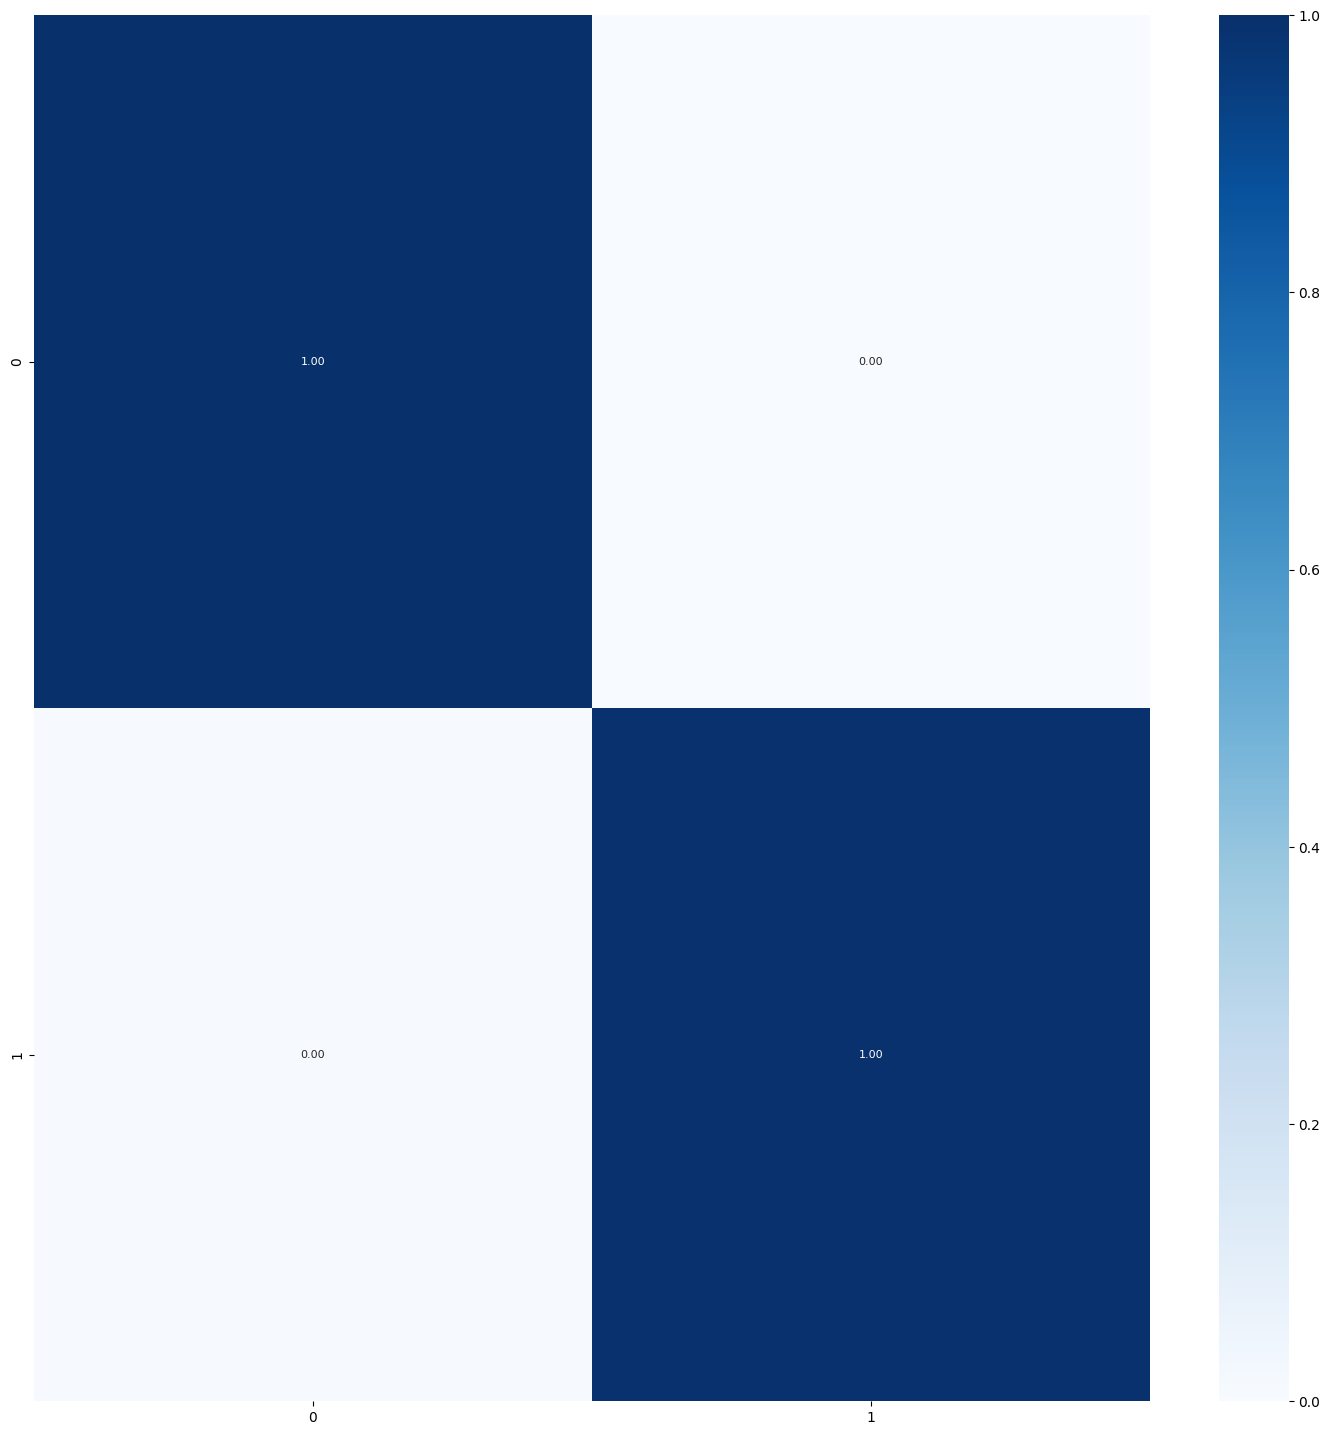


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793378
Trainable params: 2793026
Non-trainable params: 352
Epoch 1/50
65/65 [==============================] - 15s 163ms/step - loss: 1.2205 - accuracy: 0.9860 - val_loss: 2.6839 - val_accuracy: 0.5000
Epoch 2/50
65/65 [==============================] - 12s 176ms/step - loss: 0.9514 - accuracy: 0.9961 - val_loss: 2.4353 - val_accuracy: 0.5000
Epoch 3/50
65/65 [==============================] - 11s 172ms/step - loss: 0.7735 - accuracy: 0.9981 - val_loss: 1.4927 - val_accuracy: 0.5000
Epoch 4/50
65/65 [==============================] - 12s 189ms/step - loss: 0.6323 - accuracy: 0.9990 - val_loss: 0.9206 - val_accuracy: 0.7511
Epoch 5/50
65/65 [==============================] - 11s 172ms/step - loss: 0.5308 - accuracy: 0.9985 - val_loss: 0.6709 - val_accuracy: 0.9933
Epoch 6/50
65/65 [==============================] - 12s 164ms/step - loss: 0.4402 - accuracy: 0.9995 - val_loss: 0.4290 - val_accuracy: 0.9956
Epoch 7/50
65/65 [============

Model and History saved...
66/66 [==============================] - 5s 79ms/step - loss: 0.0438 - accuracy: 0.9986
Train Accuracy: 0.9985714554786682
Train Log Loss: 0.04382998123764992
15/15 [==============================] - 1s 74ms/step - loss: 0.0437 - accuracy: 0.9978
Validation Accuracy: 0.9977777600288391
Validation Log Loss: 0.04366471990942955
15/15 [==============================] - 1s 81ms/step - loss: 0.0416 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.04163483530282974
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[224   1]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00      

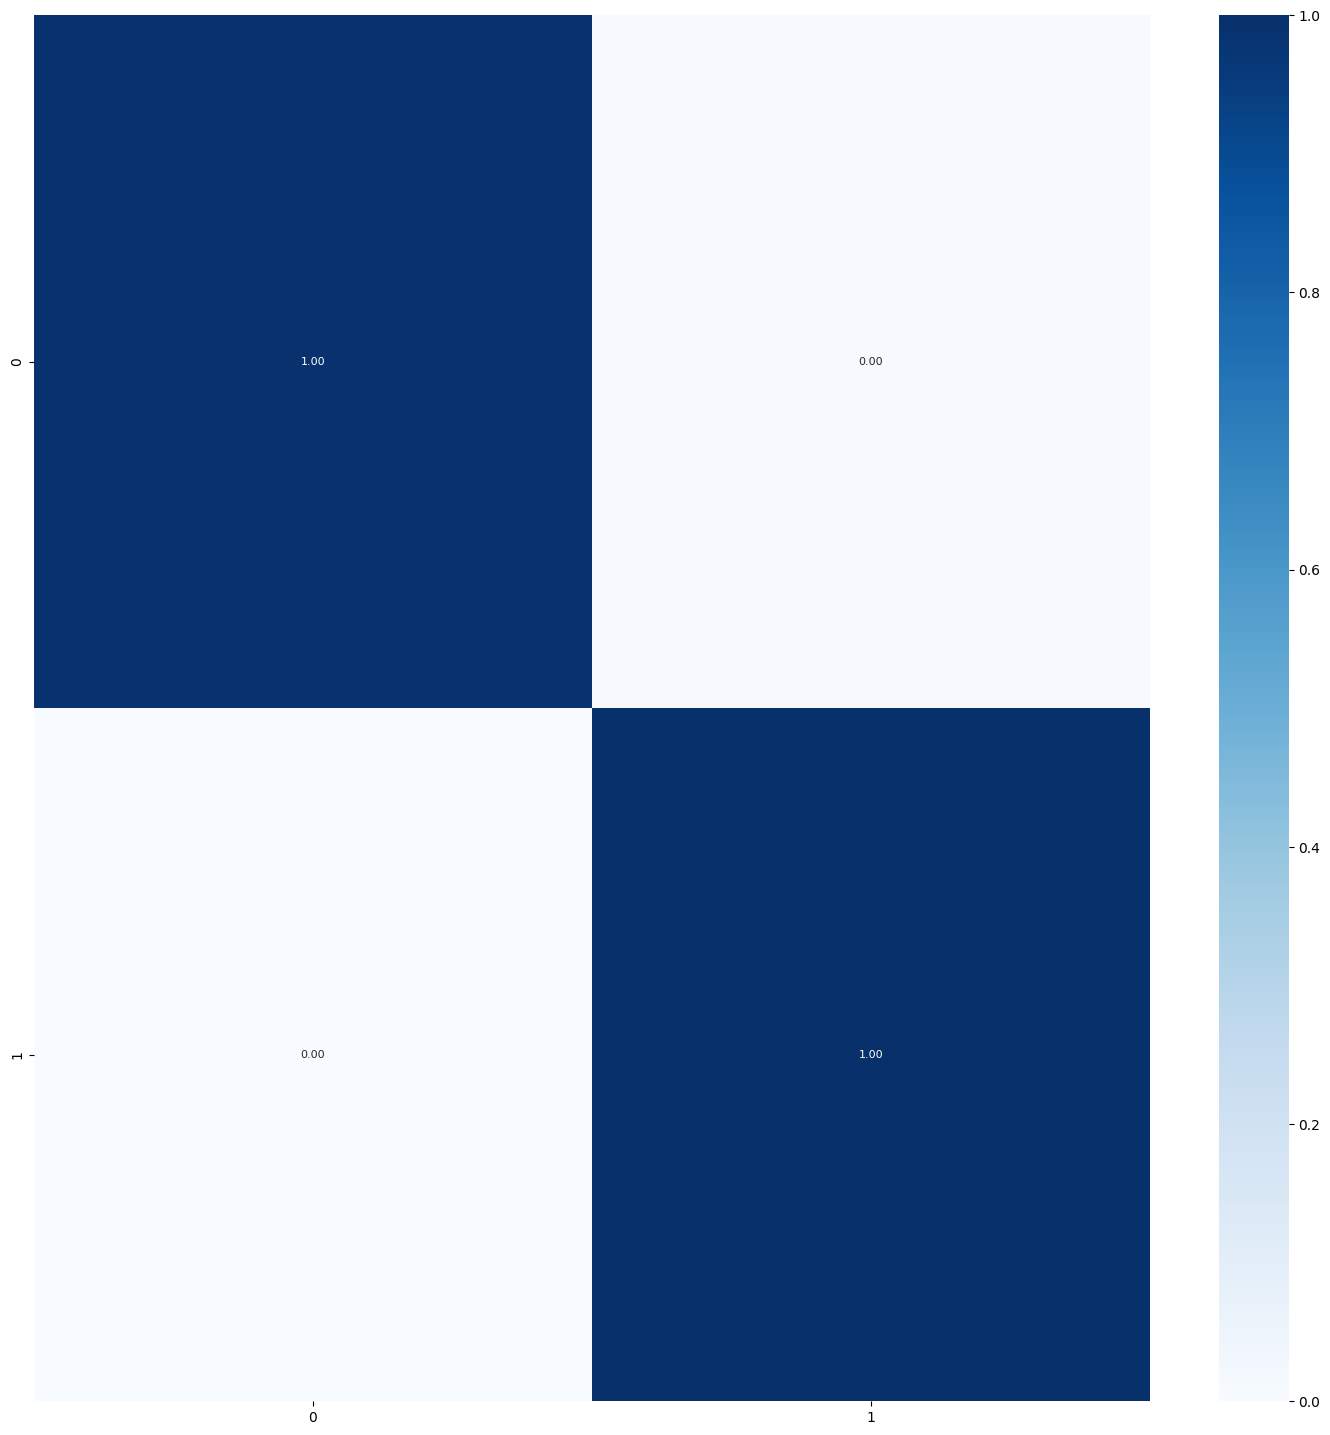


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793378
Trainable params: 2793026
Non-trainable params: 352
Epoch 1/50
65/65 [==============================] - 12s 110ms/step - loss: 1.2110 - accuracy: 0.9869 - val_loss: 1.9409 - val_accuracy: 0.5000
Epoch 2/50
65/65 [==============================] - 7s 101ms/step - loss: 0.9158 - accuracy: 0.9981 - val_loss: 1.4382 - val_accuracy: 0.5156
Epoch 3/50
65/65 [==============================] - 7s 100ms/step - loss: 0.7256 - accuracy: 0.9990 - val_loss: 1.0466 - val_accuracy: 0.6778
Epoch 4/50
65/65 [==============================] - 7s 100ms/step - loss: 0.5832 - accuracy: 0.9985 - val_loss: 1.1217 - val_accuracy: 0.6156
Epoch 5/50
65/65 [==============================] - 6s 95ms/step - loss: 0.4752 - accuracy: 0.9985 - val_loss: 0.9860 - val_accuracy: 0.6689
Epoch 6/50
65/65 [==============================] - 7s 104ms/step - loss: 0.3827 - accuracy: 1.0000 - val_loss: 0.3738 - val_accuracy: 0.9956
Epoch 7/50
65/65 [==================

Model and History saved...
66/66 [==============================] - 9s 131ms/step - loss: 0.0415 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.04152999073266983
15/15 [==============================] - 2s 127ms/step - loss: 0.0630 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.06302042305469513
15/15 [==============================] - 2s 129ms/step - loss: 0.0531 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.05308616906404495
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  1 224]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [

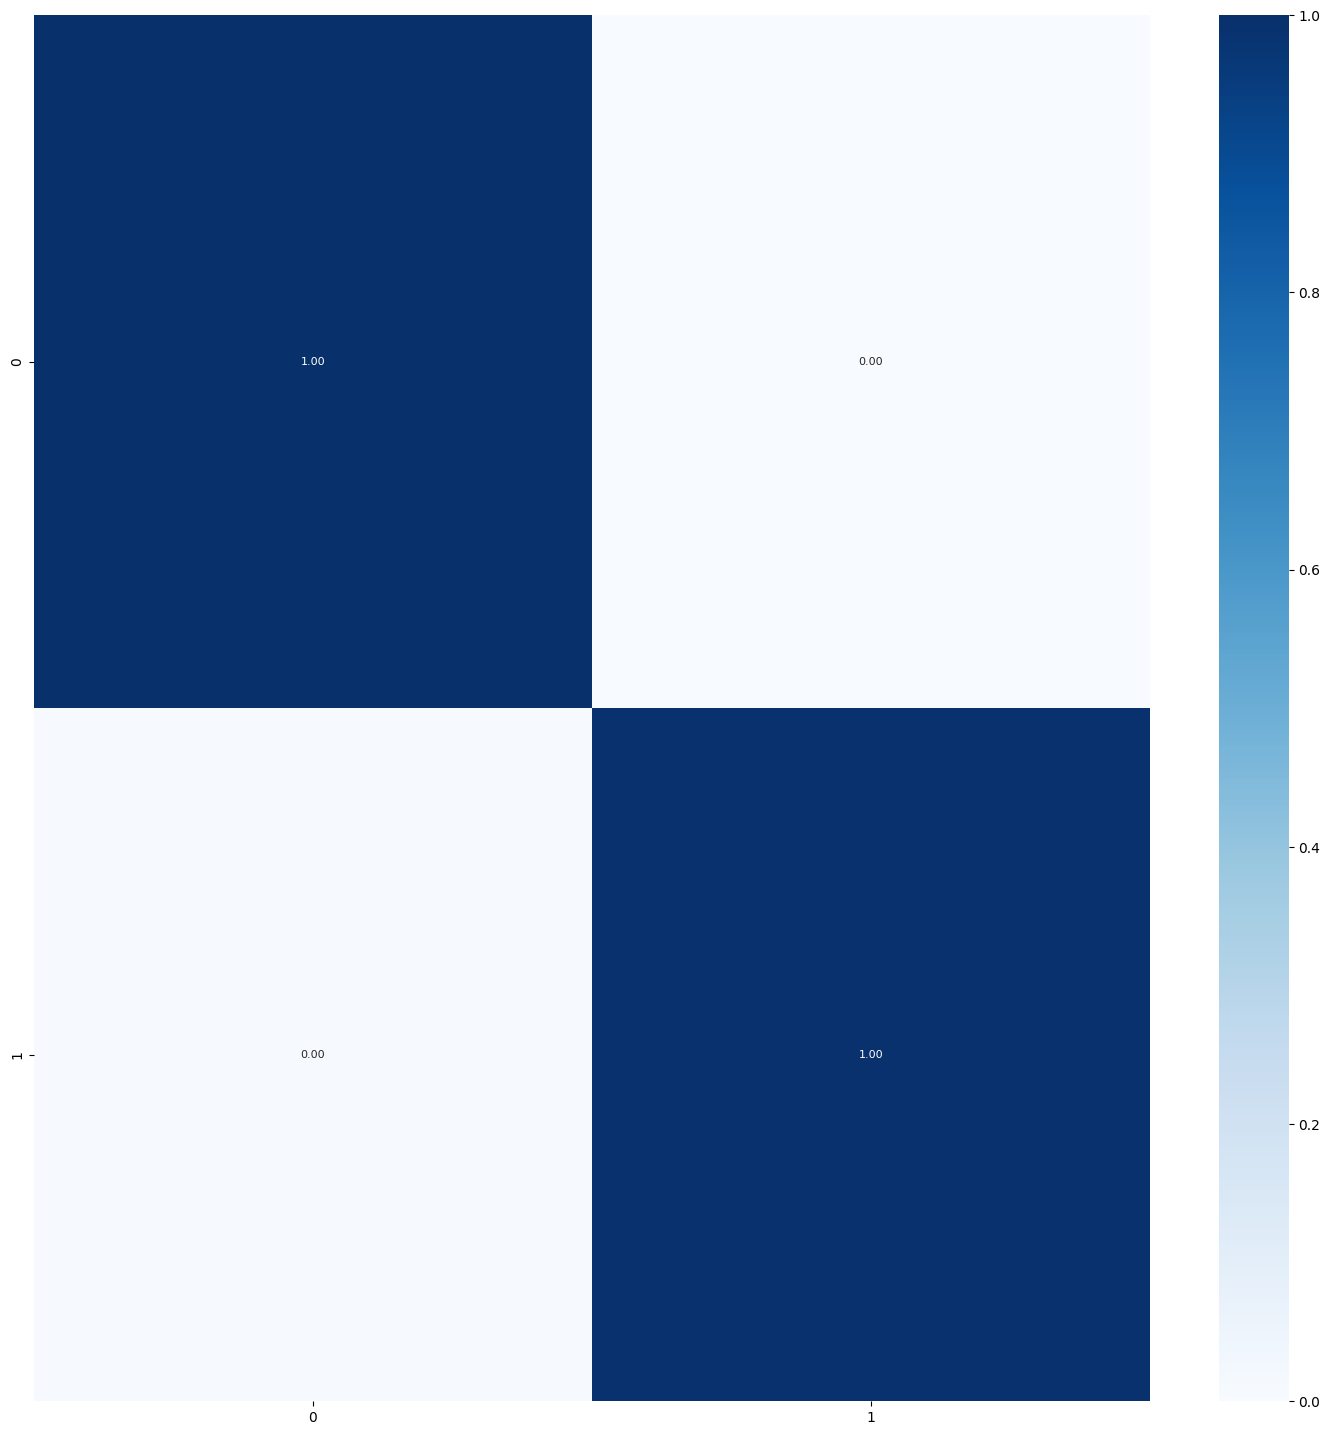


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793378
Trainable params: 2793026
Non-trainable params: 352
Epoch 1/50
65/65 [==============================] - 21s 194ms/step - loss: 1.2257 - accuracy: 0.9860 - val_loss: 3.0046 - val_accuracy: 0.5000
Epoch 2/50
65/65 [==============================] - 11s 163ms/step - loss: 0.9634 - accuracy: 0.9981 - val_loss: 2.0468 - val_accuracy: 0.5000
Epoch 3/50
65/65 [==============================] - 11s 170ms/step - loss: 0.7873 - accuracy: 0.9976 - val_loss: 1.0658 - val_accuracy: 0.8511
Epoch 4/50
65/65 [==============================] - 12s 181ms/step - loss: 0.6477 - accuracy: 0.9990 - val_loss: 0.6877 - val_accuracy: 0.9956
Epoch 5/50
65/65 [==============================] - 12s 186ms/step - loss: 0.5390 - accuracy: 0.9995 - val_loss: 0.5378 - val_accuracy: 0.9956
Epoch 6/50
65/65 [==============================] - 12s 176ms/step - loss: 0.4493 - accuracy: 0.9995 - val_loss: 0.4445 - val_accuracy: 0.9956
Epoch 7/50
65/65 [============

Model and History saved...
66/66 [==============================] - 10s 143ms/step - loss: 0.0826 - accuracy: 0.9748
Train Accuracy: 0.9747619032859802
Train Log Loss: 0.0825505256652832
15/15 [==============================] - 2s 126ms/step - loss: 0.1426 - accuracy: 0.9578
Validation Accuracy: 0.9577777981758118
Validation Log Loss: 0.14255449175834656
15/15 [==============================] - 2s 138ms/step - loss: 0.0620 - accuracy: 0.9822
Test Accuracy: 0.9822221994400024
Test Log Loss: 0.06201469525694847
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[217   8]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       225
           1       0.97      1.00      0.98       225

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98   

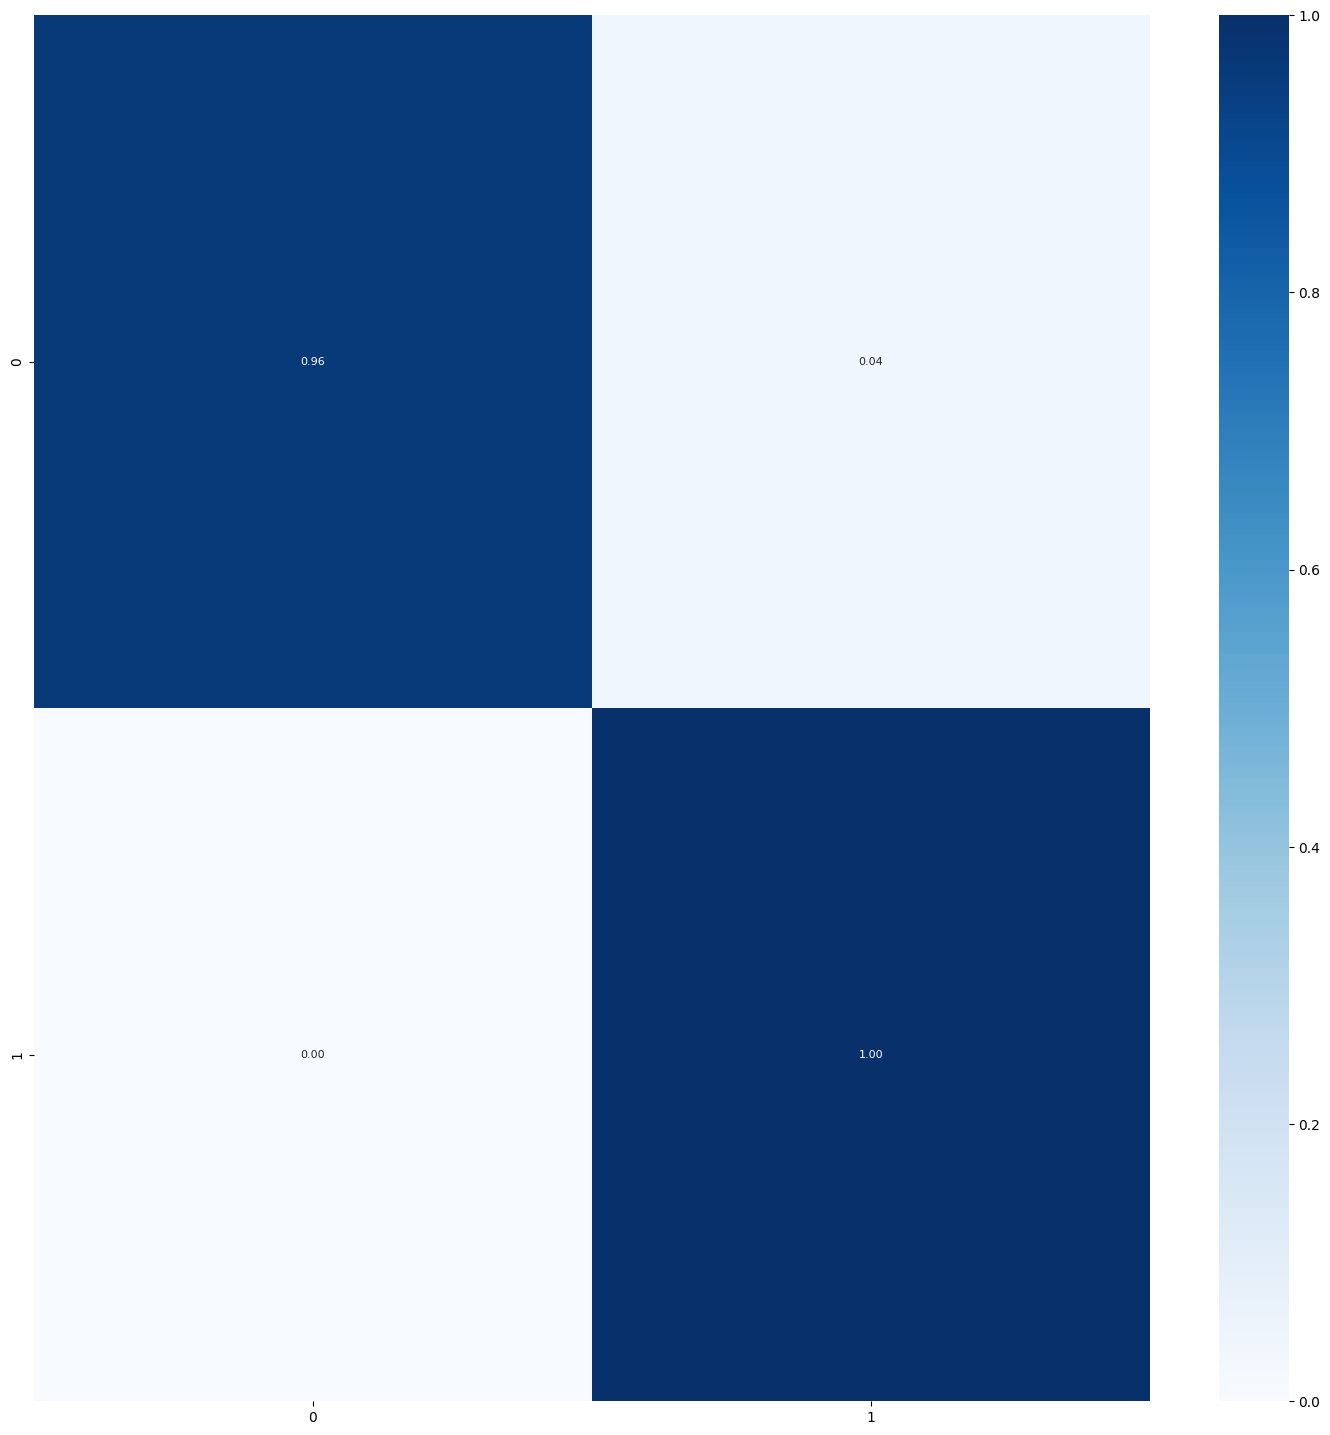


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793378
Trainable params: 2793026
Non-trainable params: 352
Epoch 1/50
65/65 [==============================] - 20s 187ms/step - loss: 1.2085 - accuracy: 0.9850 - val_loss: 2.0320 - val_accuracy: 0.5000
Epoch 2/50
65/65 [==============================] - 9s 140ms/step - loss: 0.9126 - accuracy: 0.9966 - val_loss: 1.2570 - val_accuracy: 0.6622
Epoch 3/50
65/65 [==============================] - 7s 103ms/step - loss: 0.7095 - accuracy: 0.9990 - val_loss: 1.0968 - val_accuracy: 0.5022
Epoch 4/50
65/65 [==============================] - 7s 111ms/step - loss: 0.5653 - accuracy: 0.9990 - val_loss: 0.8813 - val_accuracy: 0.9622
Epoch 5/50
65/65 [==============================] - 12s 184ms/step - loss: 0.4553 - accuracy: 0.9985 - val_loss: 0.6436 - val_accuracy: 0.9956
Epoch 6/50
65/65 [==============================] - 12s 191ms/step - loss: 0.3774 - accuracy: 0.9995 - val_loss: 0.4760 - val_accuracy: 0.9956
Epoch 7/50
65/65 [===============

Model and History saved...
66/66 [==============================] - 9s 125ms/step - loss: 0.0163 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.01627609319984913
15/15 [==============================] - 2s 126ms/step - loss: 0.0275 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.02752440795302391
15/15 [==============================] - 2s 121ms/step - loss: 0.0165 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.01652921736240387
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

15/15 [===============

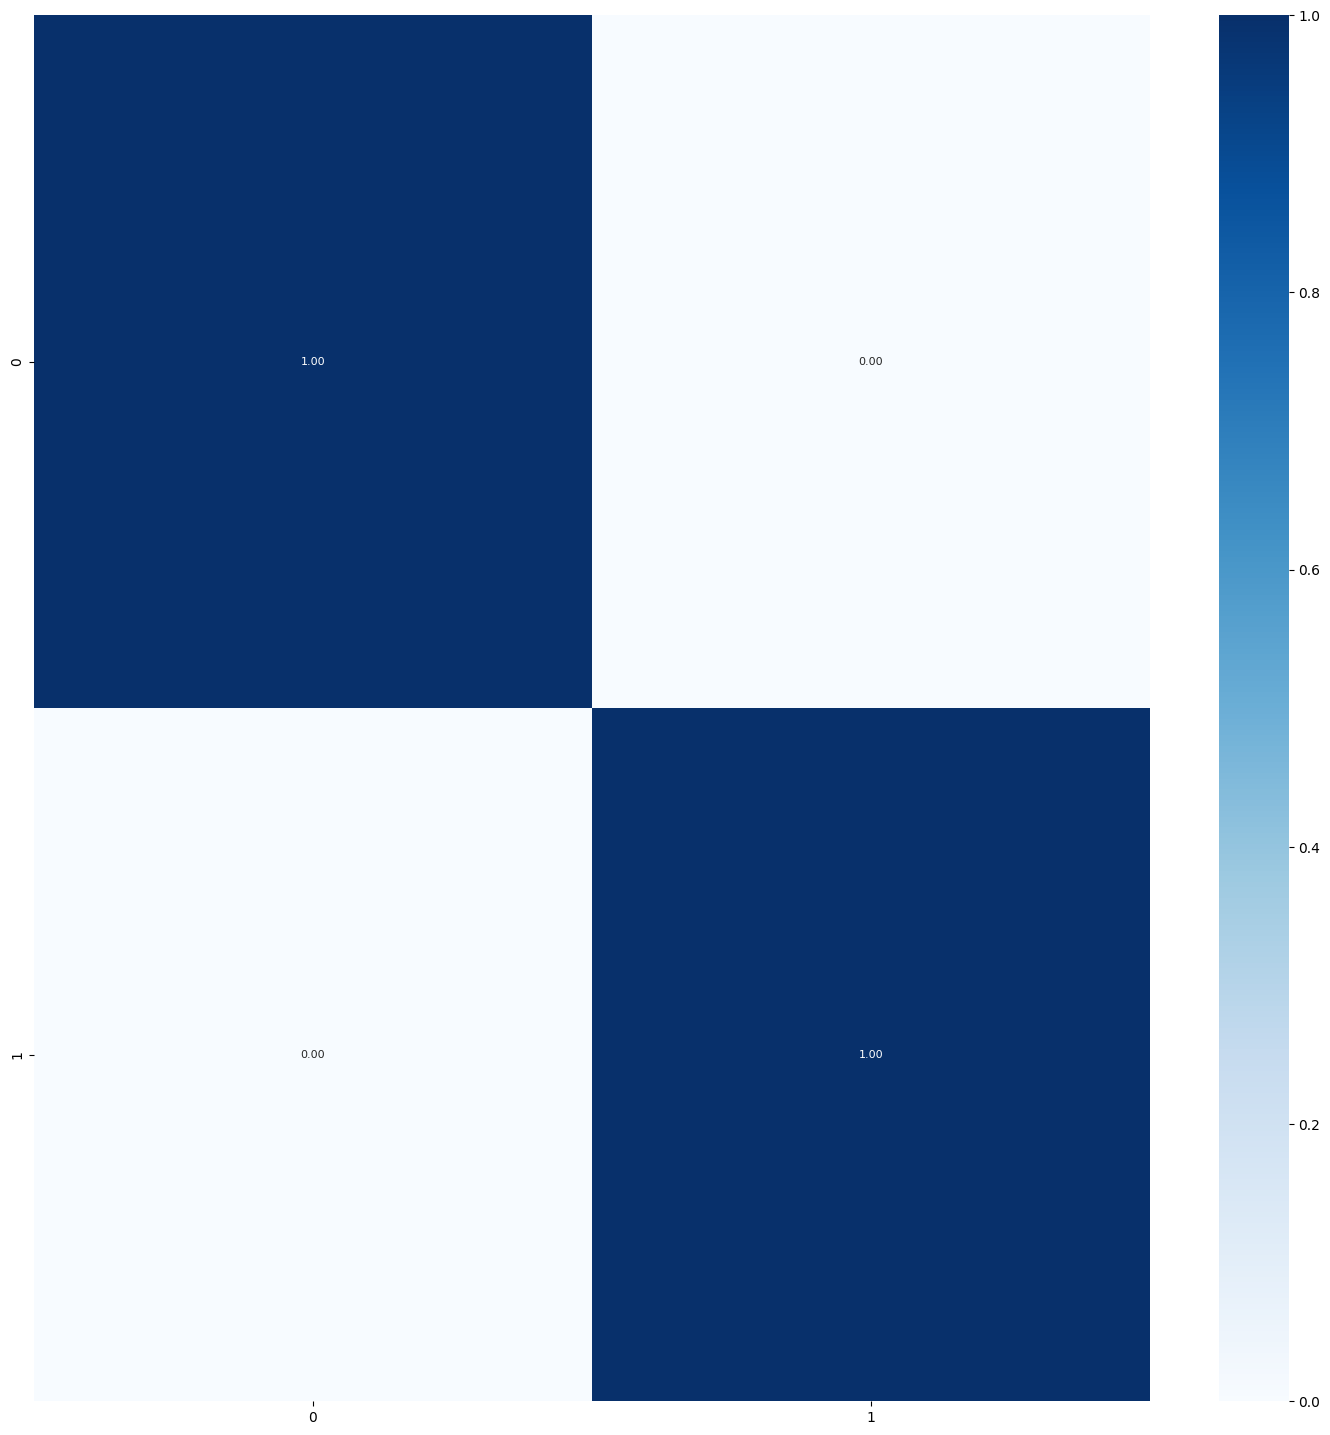

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9995555520057678
/nTest Metrics
test_acc_list: [0.9977777600288391, 0.9977777600288391, 0.9977777600288391, 0.9822221994400024, 1.0]
Average Test Accuracy with 5-fold: 0.995111095905304
test_loss_list: [0.01018615998327732, 0.04163483530282974, 0.05308616906404495, 0.06201469525694847, 0.01652921736240387]
Average Test Log Loss with 5-fold: 0.03669021539390087

Precision List: [0.997787610619469, 0.997787610619469, 0.997787610619469, 0.9828326180257511, 1.0]
Average Precision List with 5-fold: 0.9952390899768316
Recall List: [0.9977777777777778, 0.9977777777777778, 0.9977777777777778, 0.9822222222222222, 1.0]
Average Recall List with 5-fold: 0.9951111111111111
F1 Score List: [0.9977777668037867, 0.9977777668037867, 0.9977777668037867, 0.9822166017901954, 1.0]
Average F1 Score List with 5-fold: 0.9951099804403111

Metrics List Store

test_acc_list_all = [0.995111095905304]
test_loss_list_all = [0.03669021

In [18]:
%%time

num_classes = 2
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/3
name_save_model: fusion_cnn_basic_15003
Found 3150 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2793443
Trainable params: 2793091
Non-trainable params: 352
Epoch 1/50
98/98 [==============================] - 27s 190ms/step - loss: 1.1930 - accuracy: 0.9894 - val_loss: 3.0502 - val_accuracy: 0.3333
Epoch 2/50
98/98 [==============================] - 16s 164ms/step - loss: 0.8650 - accuracy: 0.9978 - val_loss: 1.9292 - val_accuracy: 0.6622
Epoch 3/50
98/98 [==============================] - 16s 163ms/step - loss: 0.6266 - accuracy: 0.9994 - val_loss: 0.8720 - val_accuracy: 0.9956
Epoch 4/50
98/98 [==============================] - 19s 197ms/step - loss: 0.4637 - accuracy: 0.9990 - val_loss: 0.4609 - val_accuracy: 0.9956
Epoch 

Model and History saved...
99/99 [==============================] - 8s 82ms/step - loss: 0.0081 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.008075390942394733
22/22 [==============================] - 2s 85ms/step - loss: 0.0141 - accuracy: 0.9970
Validation Accuracy: 0.9970370531082153
Validation Log Loss: 0.01414577942341566
22/22 [==============================] - 2s 103ms/step - loss: 0.0149 - accuracy: 0.9985
Test Accuracy: 0.9985185265541077
Test Log Loss: 0.01487757544964552
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   1 224]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00

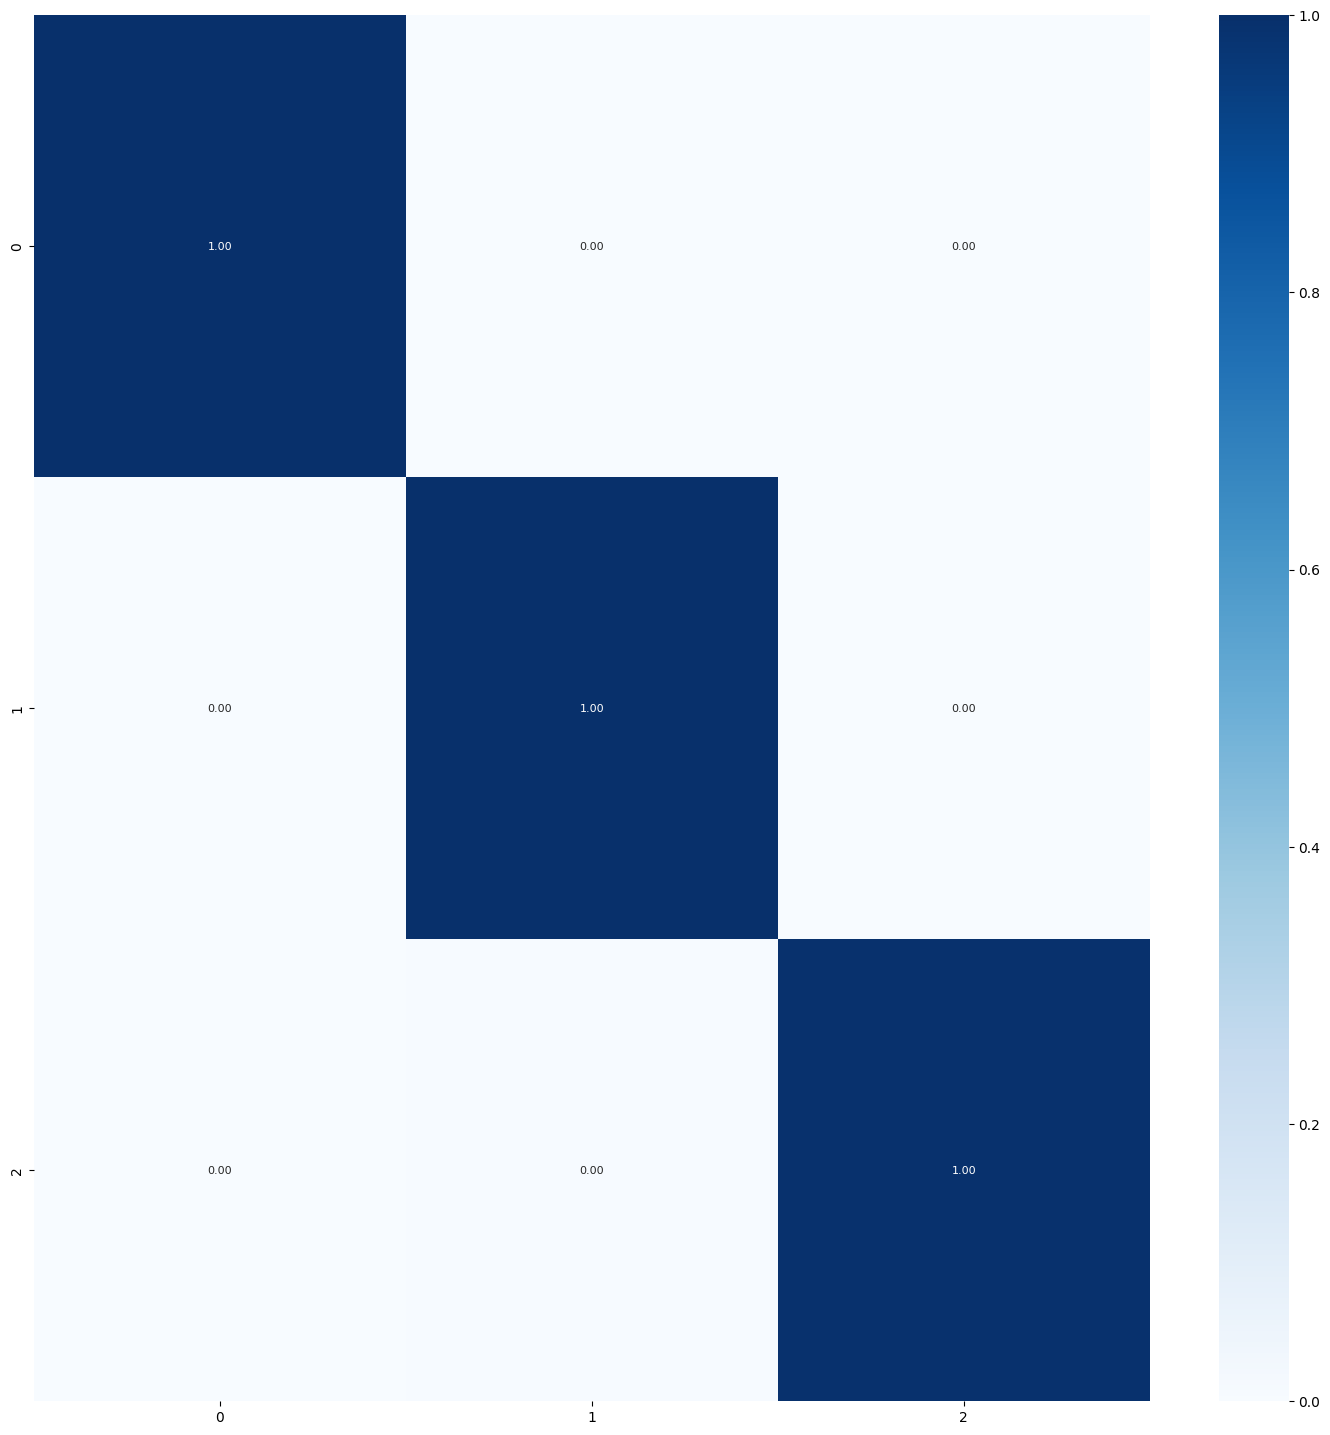


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793443
Trainable params: 2793091
Non-trainable params: 352
Epoch 1/50
98/98 [==============================] - 26s 182ms/step - loss: 1.2410 - accuracy: 0.9840 - val_loss: 3.3218 - val_accuracy: 0.3333
Epoch 2/50
98/98 [==============================] - 16s 164ms/step - loss: 0.9575 - accuracy: 0.9955 - val_loss: 1.6638 - val_accuracy: 0.6504
Epoch 3/50
98/98 [==============================] - 17s 168ms/step - loss: 0.7463 - accuracy: 0.9978 - val_loss: 1.1138 - val_accuracy: 0.7496
Epoch 4/50
98/98 [==============================] - 16s 164ms/step - loss: 0.5773 - accuracy: 0.9984 - val_loss: 0.5487 - val_accuracy: 0.9941
Epoch 5/50
98/98 [==============================] - 16s 165ms/step - loss: 0.4442 - accuracy: 0.9994 - val_loss: 0.4261 - val_accuracy: 0.9956
Epoch 6/50
98/98 [==============================] - 16s 163ms/step - loss: 0.3421 - accuracy: 0.9987 - val_loss: 0.3166 - val_accuracy: 0.9970
Epoch 7/50
98/98 [============

Model and History saved...
99/99 [==============================] - 14s 139ms/step - loss: 0.0344 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.03438267111778259
22/22 [==============================] - 3s 138ms/step - loss: 0.0368 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.03683466091752052
22/22 [==============================] - 3s 140ms/step - loss: 0.0357 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.035740699619054794
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1.00      1.00  

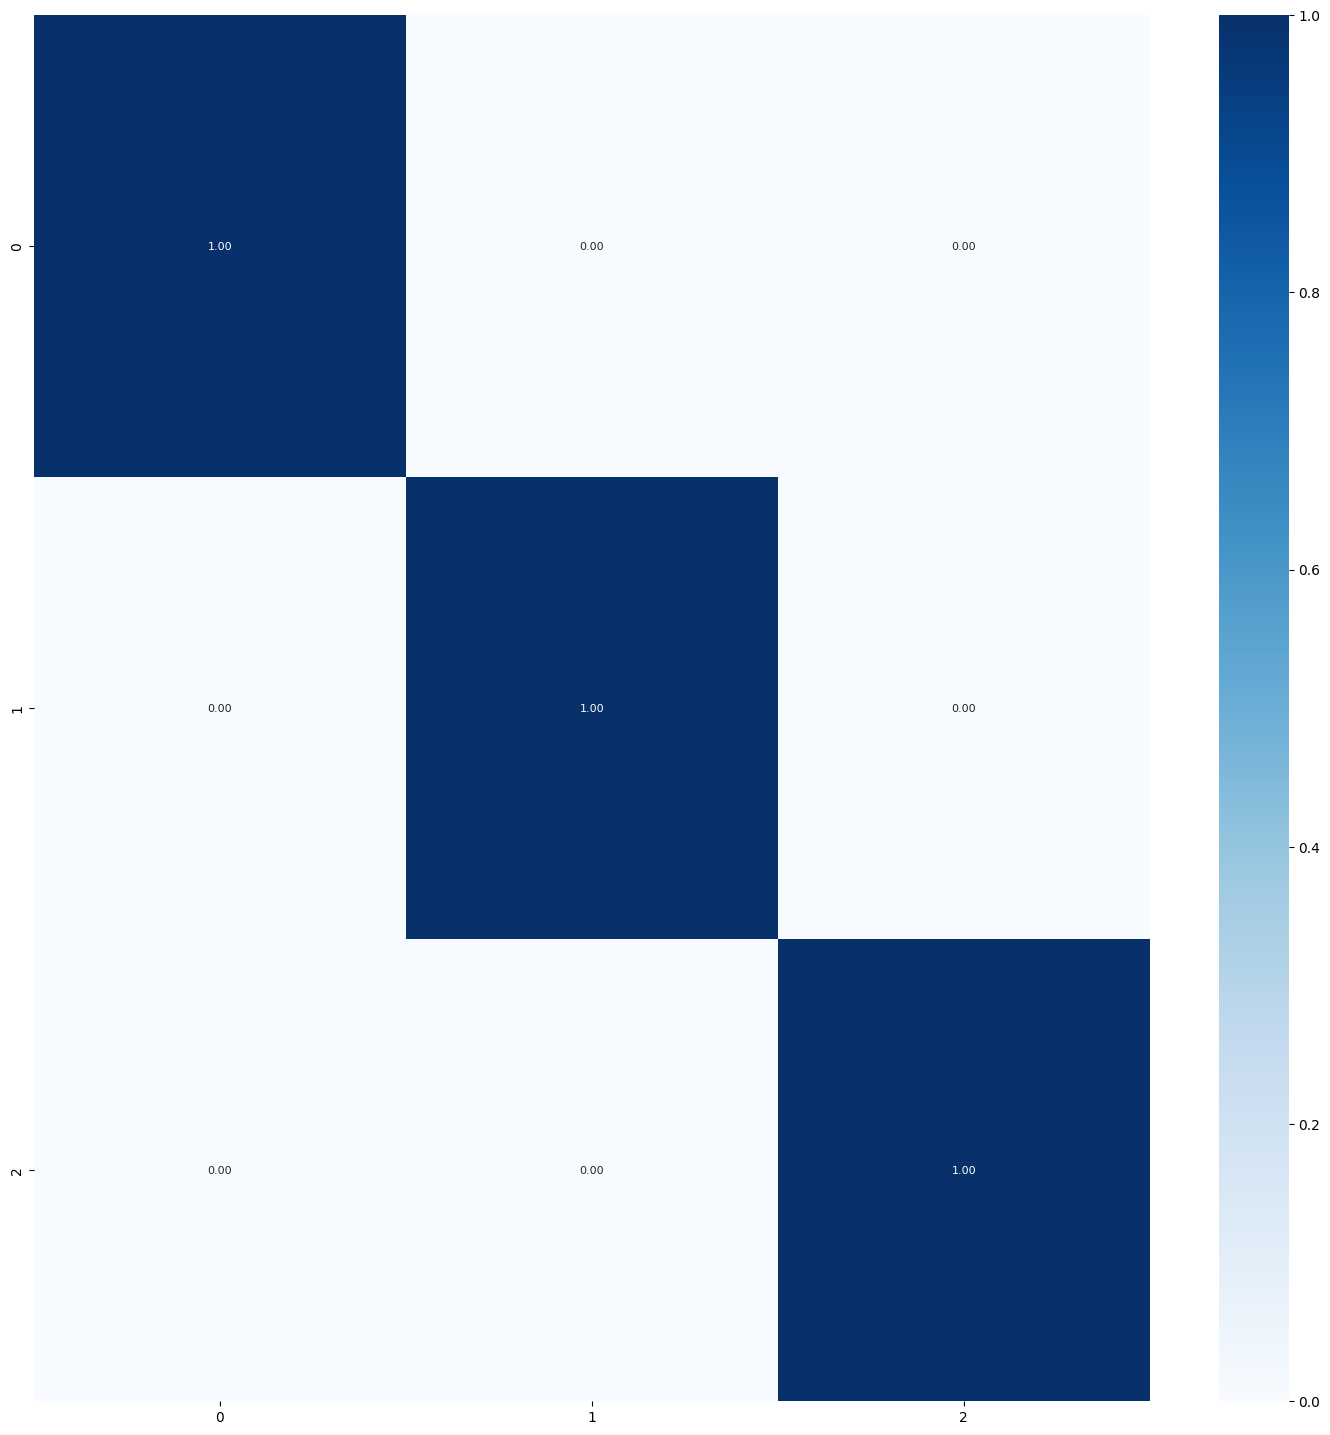


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793443
Trainable params: 2793091
Non-trainable params: 352
Epoch 1/50
98/98 [==============================] - 19s 114ms/step - loss: 1.2456 - accuracy: 0.9833 - val_loss: 2.9048 - val_accuracy: 0.3333
Epoch 2/50
98/98 [==============================] - 14s 144ms/step - loss: 0.9713 - accuracy: 0.9978 - val_loss: 1.7177 - val_accuracy: 0.6474
Epoch 3/50
98/98 [==============================] - 17s 176ms/step - loss: 0.7449 - accuracy: 0.9990 - val_loss: 0.8237 - val_accuracy: 0.9941
Epoch 4/50
98/98 [==============================] - 17s 172ms/step - loss: 0.5771 - accuracy: 0.9984 - val_loss: 0.5450 - val_accuracy: 0.9941
Epoch 5/50
98/98 [==============================] - 19s 189ms/step - loss: 0.4429 - accuracy: 0.9984 - val_loss: 0.4140 - val_accuracy: 0.9941
Epoch 6/50
98/98 [==============================] - 20s 203ms/step - loss: 0.3451 - accuracy: 0.9981 - val_loss: 0.3187 - val_accuracy: 0.9970
Epoch 7/50
98/98 [============

Model and History saved...
99/99 [==============================] - 14s 141ms/step - loss: 0.2788 - accuracy: 0.8835
Train Accuracy: 0.8834920525550842
Train Log Loss: 0.27881693840026855
22/22 [==============================] - 3s 136ms/step - loss: 0.2608 - accuracy: 0.8933
Validation Accuracy: 0.8933333158493042
Validation Log Loss: 0.26081588864326477
22/22 [==============================] - 3s 141ms/step - loss: 0.3290 - accuracy: 0.8652
Test Accuracy: 0.8651852011680603
Test Log Loss: 0.3290490508079529
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 134  91]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      0.60      0.75       225
           2       0.71      1.00      0.83       225

    accuracy                           0.87       675
   macr

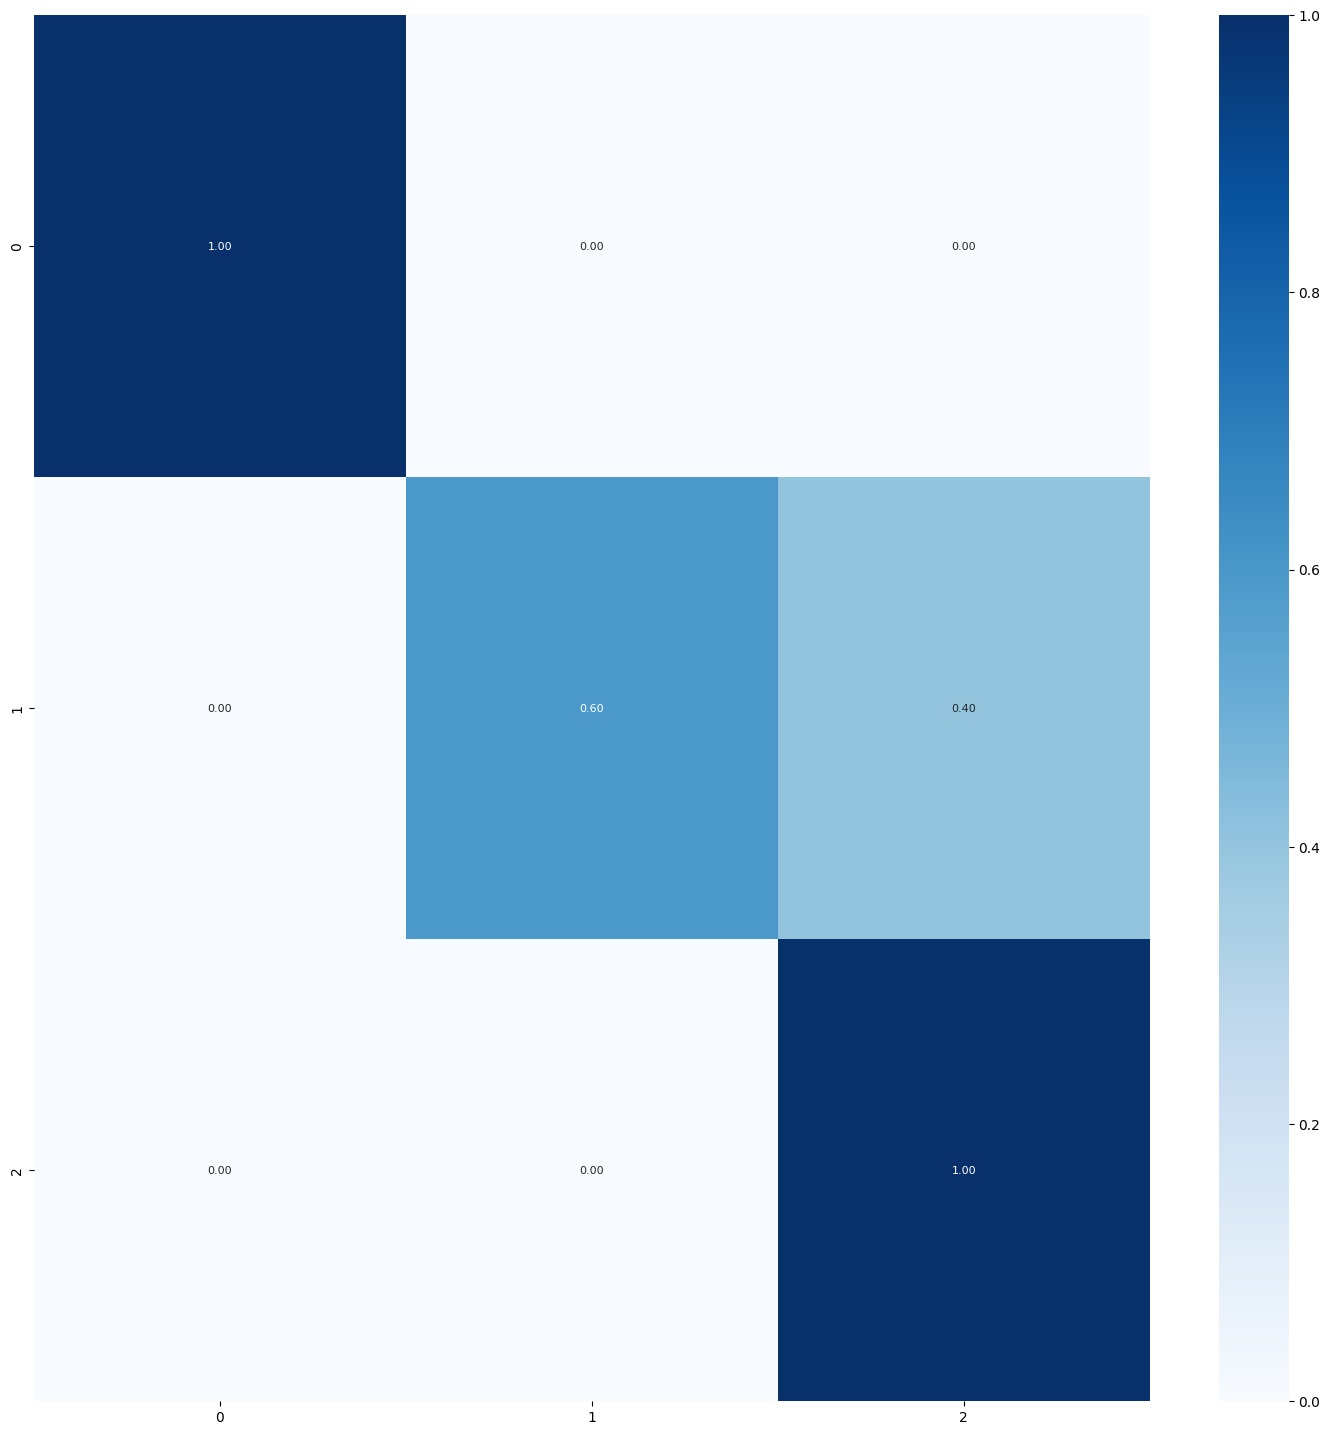


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793443
Trainable params: 2793091
Non-trainable params: 352
Epoch 1/50
98/98 [==============================] - 27s 190ms/step - loss: 1.1901 - accuracy: 0.9885 - val_loss: 2.7250 - val_accuracy: 0.3333
Epoch 2/50
98/98 [==============================] - 17s 177ms/step - loss: 0.8770 - accuracy: 0.9971 - val_loss: 1.7206 - val_accuracy: 0.6607
Epoch 3/50
98/98 [==============================] - 16s 165ms/step - loss: 0.6512 - accuracy: 0.9978 - val_loss: 1.1992 - val_accuracy: 0.6696
Epoch 4/50
98/98 [==============================] - 11s 106ms/step - loss: 0.4832 - accuracy: 0.9987 - val_loss: 0.4579 - val_accuracy: 0.9970
Epoch 5/50
98/98 [==============================] - 10s 103ms/step - loss: 0.3661 - accuracy: 0.9984 - val_loss: 0.3334 - val_accuracy: 0.9970
Epoch 6/50
98/98 [==============================] - 10s 105ms/step - loss: 0.2750 - accuracy: 0.9997 - val_loss: 0.2526 - val_accuracy: 0.9941
Epoch 7/50
98/98 [============

Model and History saved...
99/99 [==============================] - 14s 136ms/step - loss: 0.0176 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.017615383490920067
22/22 [==============================] - 4s 150ms/step - loss: 0.0234 - accuracy: 0.9970
Validation Accuracy: 0.9970370531082153
Validation Log Loss: 0.02339763566851616
22/22 [==============================] - 3s 130ms/step - loss: 0.0203 - accuracy: 0.9985
Test Accuracy: 0.9985185265541077
Test Log Loss: 0.02025756798684597
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   1 224]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1

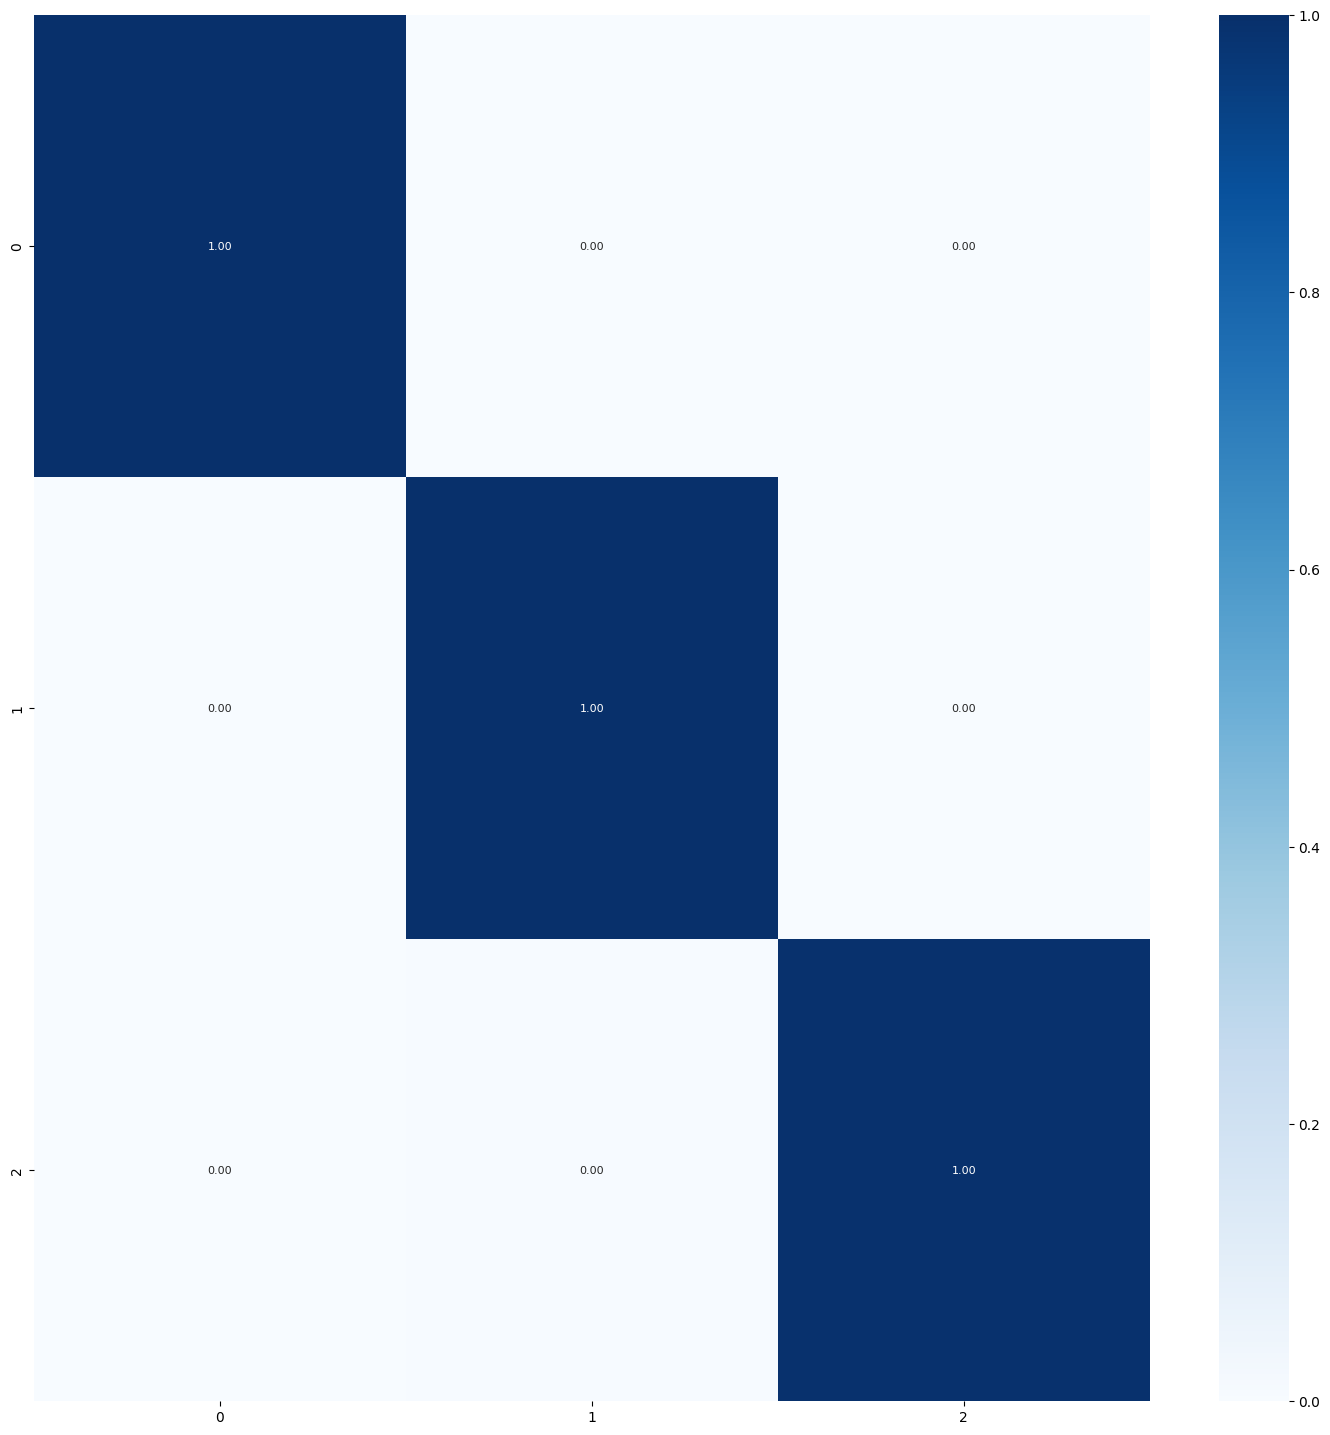


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793443
Trainable params: 2793091
Non-trainable params: 352
Epoch 1/50
98/98 [==============================] - 26s 184ms/step - loss: 1.2109 - accuracy: 0.9875 - val_loss: 3.3055 - val_accuracy: 0.3333
Epoch 2/50
98/98 [==============================] - 16s 160ms/step - loss: 0.8952 - accuracy: 0.9974 - val_loss: 2.5650 - val_accuracy: 0.3333
Epoch 3/50
98/98 [==============================] - 17s 173ms/step - loss: 0.6595 - accuracy: 0.9984 - val_loss: 1.5148 - val_accuracy: 0.3867
Epoch 4/50
98/98 [==============================] - 17s 175ms/step - loss: 0.4852 - accuracy: 0.9987 - val_loss: 0.9870 - val_accuracy: 0.7733
Epoch 5/50
98/98 [==============================] - 18s 183ms/step - loss: 0.3653 - accuracy: 0.9974 - val_loss: 0.3523 - val_accuracy: 0.9970
Epoch 6/50
98/98 [==============================] - 17s 176ms/step - loss: 0.2764 - accuracy: 0.9984 - val_loss: 0.2522 - val_accuracy: 0.9941
Epoch 7/50
98/98 [============

Model and History saved...
99/99 [==============================] - 17s 166ms/step - loss: 0.0249 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.024931149557232857
22/22 [==============================] - 4s 151ms/step - loss: 0.0333 - accuracy: 0.9970
Validation Accuracy: 0.9970370531082153
Validation Log Loss: 0.0332782045006752
22/22 [==============================] - 3s 136ms/step - loss: 0.0301 - accuracy: 0.9985
Test Accuracy: 0.9985185265541077
Test Log Loss: 0.030086686834692955
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   1 224]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                           1.00       675
   macro avg       1

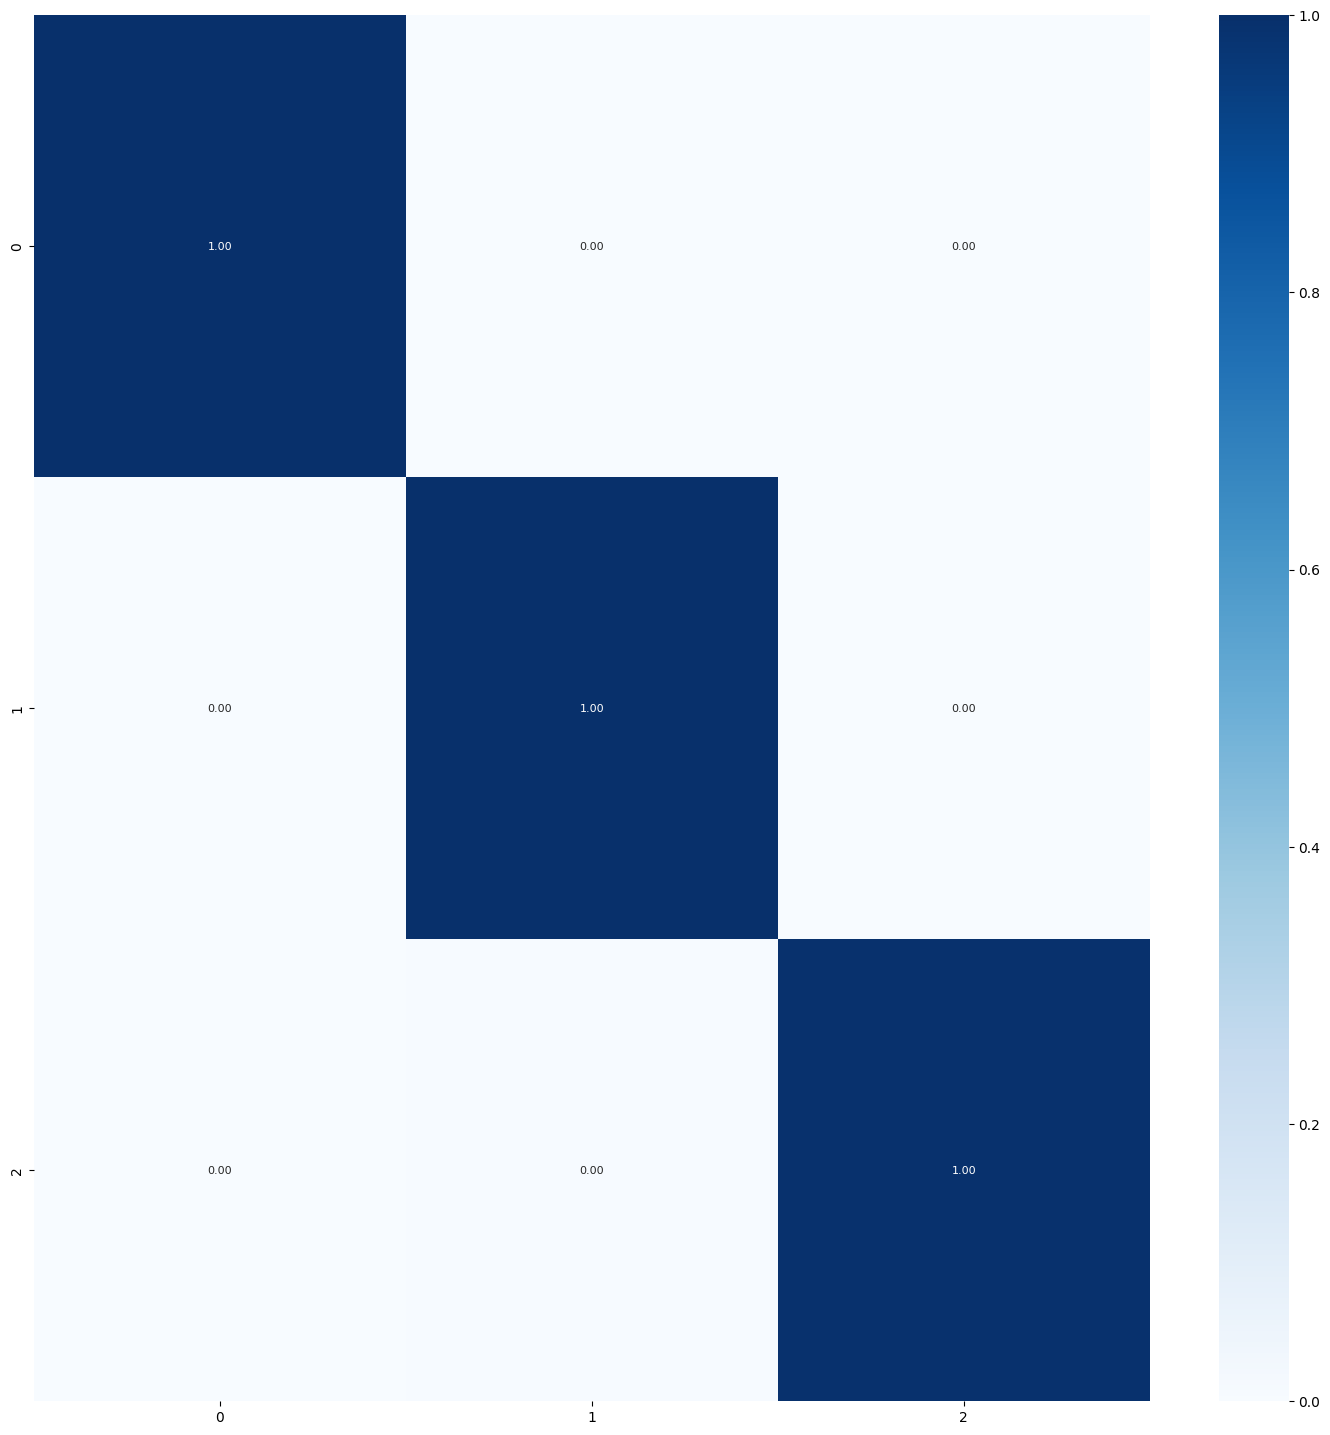

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0
/nTest Metrics
test_acc_list: [0.9985185265541077, 1.0, 0.8651852011680603, 0.9985185265541077, 0.9985185265541077]
Average Test Accuracy with 5-fold: 0.9721481561660766
test_loss_list: [0.01487757544964552, 0.035740699619054794, 0.3290490508079529, 0.02025756798684597, 0.030086686834692955]
Average Test Log Loss with 5-fold: 0.08600231613963842

Precision List: [0.9985250737463126, 1.0, 0.9040084388185653, 0.9985250737463126, 0.9985250737463126]
Average Precision List with 5-fold: 0.9799167320115005
Recall List: [0.9985185185185186, 1.0, 0.8651851851851852, 0.9985185185185186, 0.9985185185185186]
Average Recall List with 5-fold: 0.9721481481481483
F1 Score List: [0.9985185112025246, 1.0, 0.8594370272733358, 0.9985185112025246, 0.9985185112025246]
Average F1 Score List with 5-fold: 0.9709985121761818

Metrics List Store

test_acc_list_all = [0.995111095905304, 0.9721481561660766]
test_loss_list_all = [

In [19]:
%%time

num_classes = 3
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/4
name_save_model: fusion_cnn_basic_15004
Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit

TRAINING AND EVALUATING FOLD 1/5...



2025-05-22 22:46:42.177499: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1017 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1a:00.0, compute capability: 8.6
2025-05-22 22:46:42.184625: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 1439 MB memory:  -> device: 1, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6
2025-05-22 22:46:42.189343: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 3386 MB memory:  -> device: 2, name: NVIDIA GeForce GTX 980, pci bus id: 0000:1b:00.0, compute capability: 5.2
2025-05-22 22:46:42.200433: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 3386 MB memory:  -> device: 3, name: NVIDIA GeForce GTX 980, pci bus id: 0000:1

Total params: 2793508
Trainable params: 2793156
Non-trainable params: 352
Epoch 1/50


2025-05-22 22:46:46.009736: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-05-22 22:46:48.729606: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ff3c364ef50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-22 22:46:48.730290: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-22 22:46:48.730337: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-22 22:46:48.730363: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA GeForce GTX 980, Compute Capability 5.2
2025-05-22 22:46:48.730380: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (3): NVIDIA GeForce GTX 980, Compute Capability 5.2
2025-05-22 22:46:48.730392: I external/local_xla/xla/service/service.cc:176]   StreamExecut

131/131 [==============================] - 27s 136ms/step - loss: 1.2851 - accuracy: 0.9702 - val_loss: 4.2789 - val_accuracy: 0.2500
Epoch 2/50
131/131 [==============================] - 20s 155ms/step - loss: 0.9479 - accuracy: 0.9964 - val_loss: 2.9659 - val_accuracy: 0.4956
Epoch 3/50
131/131 [==============================] - 21s 159ms/step - loss: 0.7004 - accuracy: 0.9964 - val_loss: 1.0131 - val_accuracy: 0.8511
Epoch 4/50
131/131 [==============================] - 21s 160ms/step - loss: 0.5136 - accuracy: 0.9971 - val_loss: 0.5061 - val_accuracy: 0.9811
Epoch 5/50
131/131 [==============================] - 20s 154ms/step - loss: 0.3732 - accuracy: 0.9978 - val_loss: 0.3320 - val_accuracy: 0.9967
Epoch 6/50
131/131 [==============================] - 20s 153ms/step - loss: 0.2747 - accuracy: 0.9976 - val_loss: 0.2517 - val_accuracy: 0.9944
Epoch 7/50
131/131 [==============================] - 14s 108ms/step - loss: 0.2004 - accuracy: 0.9993 - val_loss: 0.1929 - val_accuracy: 0.9

Model and History saved...
132/132 [==============================] - 24s 176ms/step - loss: 0.0276 - accuracy: 0.9998
Train Accuracy: 0.9997618794441223
Train Log Loss: 0.02761193923652172
29/29 [==============================] - 6s 212ms/step - loss: 0.0480 - accuracy: 0.9978
Validation Accuracy: 0.9977777600288391
Validation Log Loss: 0.04803382605314255
29/29 [==============================] - 5s 168ms/step - loss: 0.0416 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.04156821221113205
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 224   1]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3    

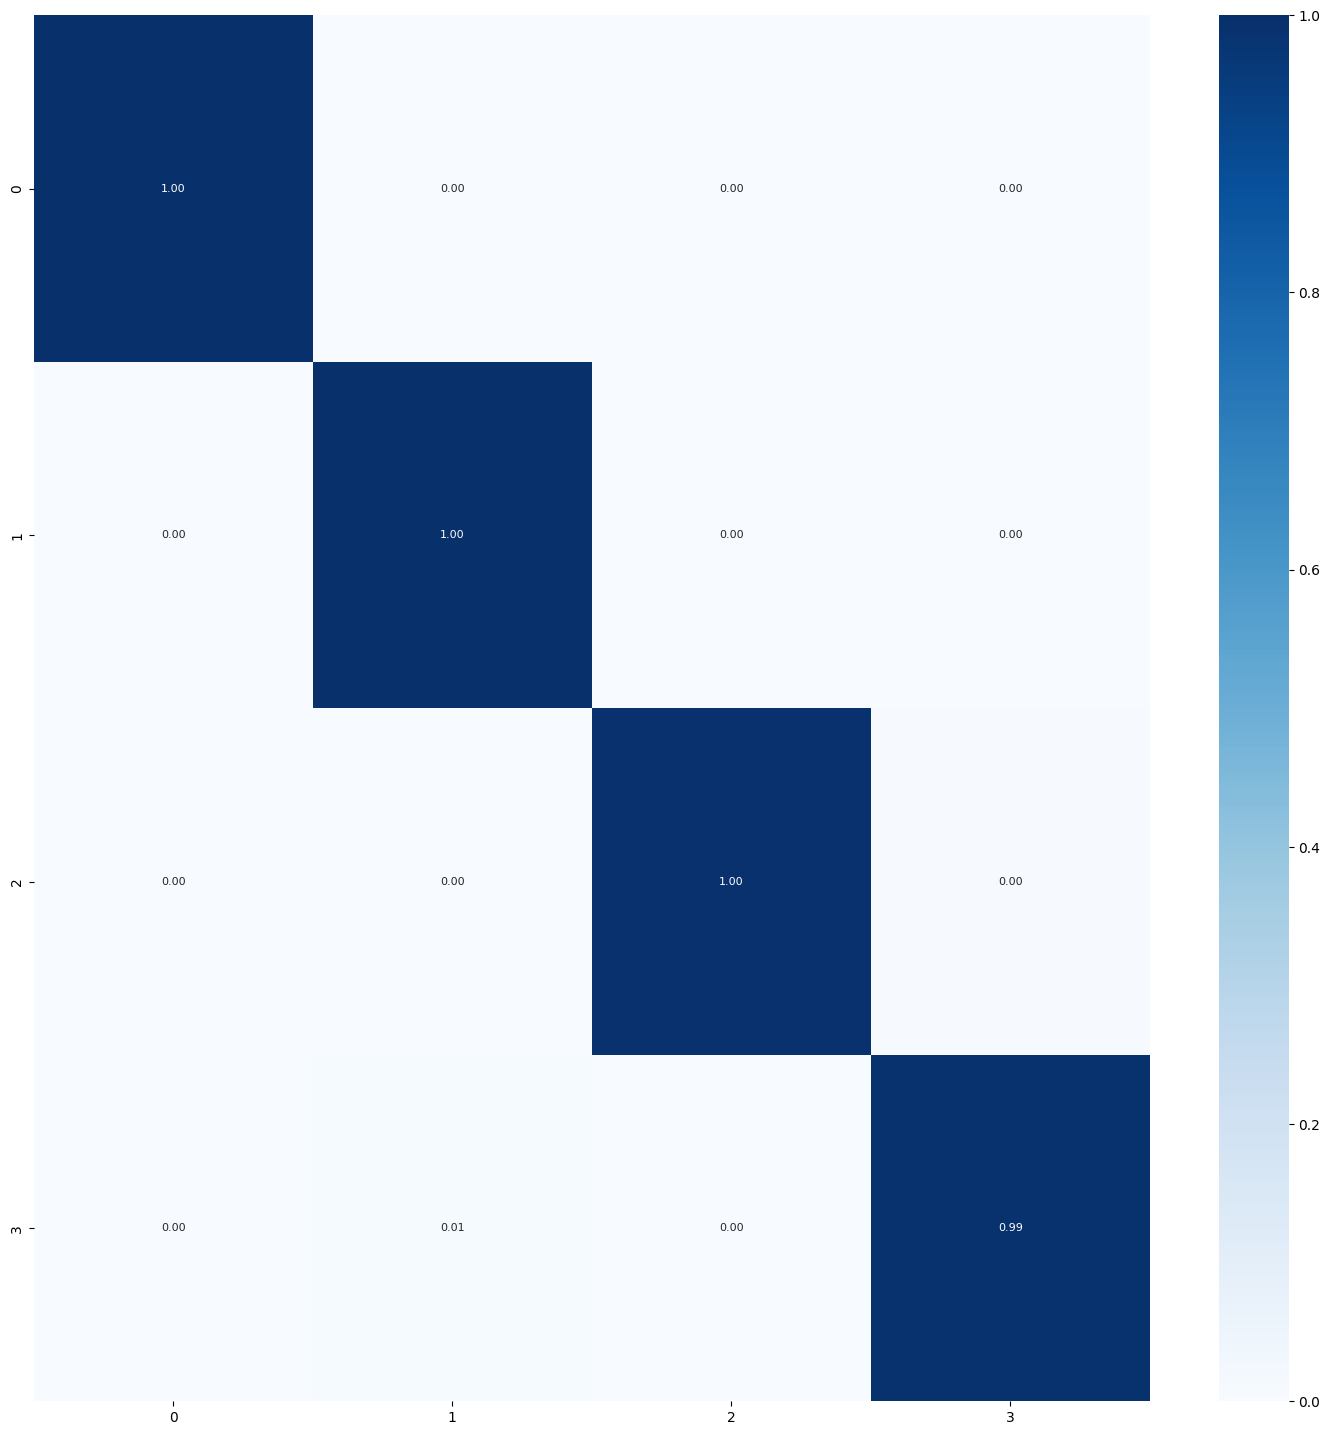


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793508
Trainable params: 2793156
Non-trainable params: 352
Epoch 1/50
131/131 [==============================] - 40s 237ms/step - loss: 1.2788 - accuracy: 0.9746 - val_loss: 3.4109 - val_accuracy: 0.2500
Epoch 2/50
131/131 [==============================] - 17s 125ms/step - loss: 0.9485 - accuracy: 0.9959 - val_loss: 1.8339 - val_accuracy: 0.5100
Epoch 3/50
131/131 [==============================] - 23s 174ms/step - loss: 0.7130 - accuracy: 0.9964 - val_loss: 0.7975 - val_accuracy: 0.9400
Epoch 4/50
131/131 [==============================] - 25s 186ms/step - loss: 0.5388 - accuracy: 0.9971 - val_loss: 0.4844 - val_accuracy: 0.9956
Epoch 5/50
131/131 [==============================] - 28s 209ms/step - loss: 0.4037 - accuracy: 0.9976 - val_loss: 0.3546 - val_accuracy: 0.9967
Epoch 6/50
131/131 [==============================] - 26s 200ms/step - loss: 0.2984 - accuracy: 0.9993 - val_loss: 0.2670 - val_accuracy: 0.9967
Epoch 7/50
131/131

Model and History saved...
132/132 [==============================] - 17s 128ms/step - loss: 0.0288 - accuracy: 0.9998
Train Accuracy: 0.9997618794441223
Train Log Loss: 0.028817053884267807
29/29 [==============================] - 4s 134ms/step - loss: 0.0470 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.04700630158185959
29/29 [==============================] - 4s 126ms/step - loss: 0.0474 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.04740705341100693
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   1 223   1]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      0.99      1.00       225
           3    

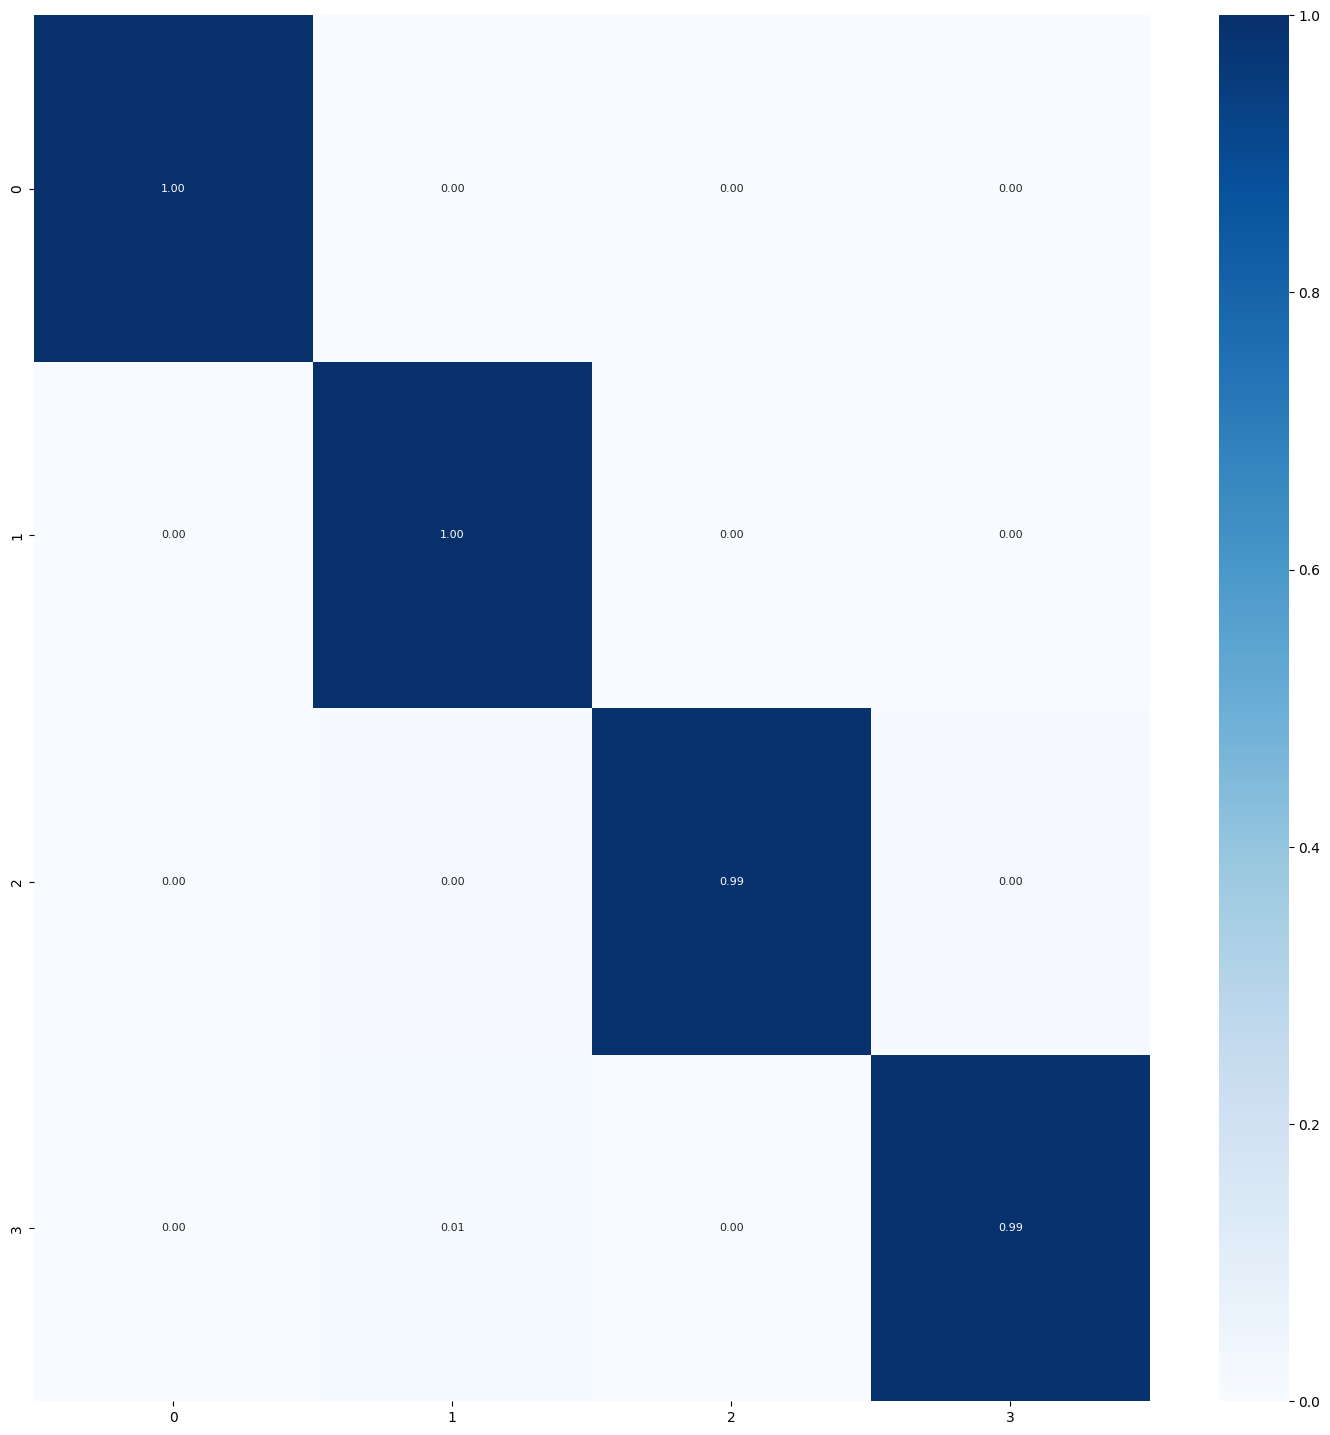


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793508
Trainable params: 2793156
Non-trainable params: 352
Epoch 1/50
131/131 [==============================] - 29s 157ms/step - loss: 1.2570 - accuracy: 0.9779 - val_loss: 3.1120 - val_accuracy: 0.2500
Epoch 2/50
131/131 [==============================] - 20s 153ms/step - loss: 0.9248 - accuracy: 0.9966 - val_loss: 2.2906 - val_accuracy: 0.2611
Epoch 3/50
131/131 [==============================] - 20s 155ms/step - loss: 0.6686 - accuracy: 0.9974 - val_loss: 0.7254 - val_accuracy: 0.9800
Epoch 4/50
131/131 [==============================] - 14s 108ms/step - loss: 0.4712 - accuracy: 0.9981 - val_loss: 0.4361 - val_accuracy: 0.9911
Epoch 5/50
131/131 [==============================] - 18s 138ms/step - loss: 0.3323 - accuracy: 0.9983 - val_loss: 0.2883 - val_accuracy: 0.9967
Epoch 6/50
131/131 [==============================] - 21s 160ms/step - loss: 0.2276 - accuracy: 0.9993 - val_loss: 0.2014 - val_accuracy: 0.9967
Epoch 7/50
131/131

Model and History saved...
132/132 [==============================] - 12s 87ms/step - loss: 0.0231 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.023104222491383553
29/29 [==============================] - 3s 86ms/step - loss: 0.0452 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.04516482353210449
29/29 [==============================] - 3s 100ms/step - loss: 0.0375 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.037461601197719574
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3       1.00      0.

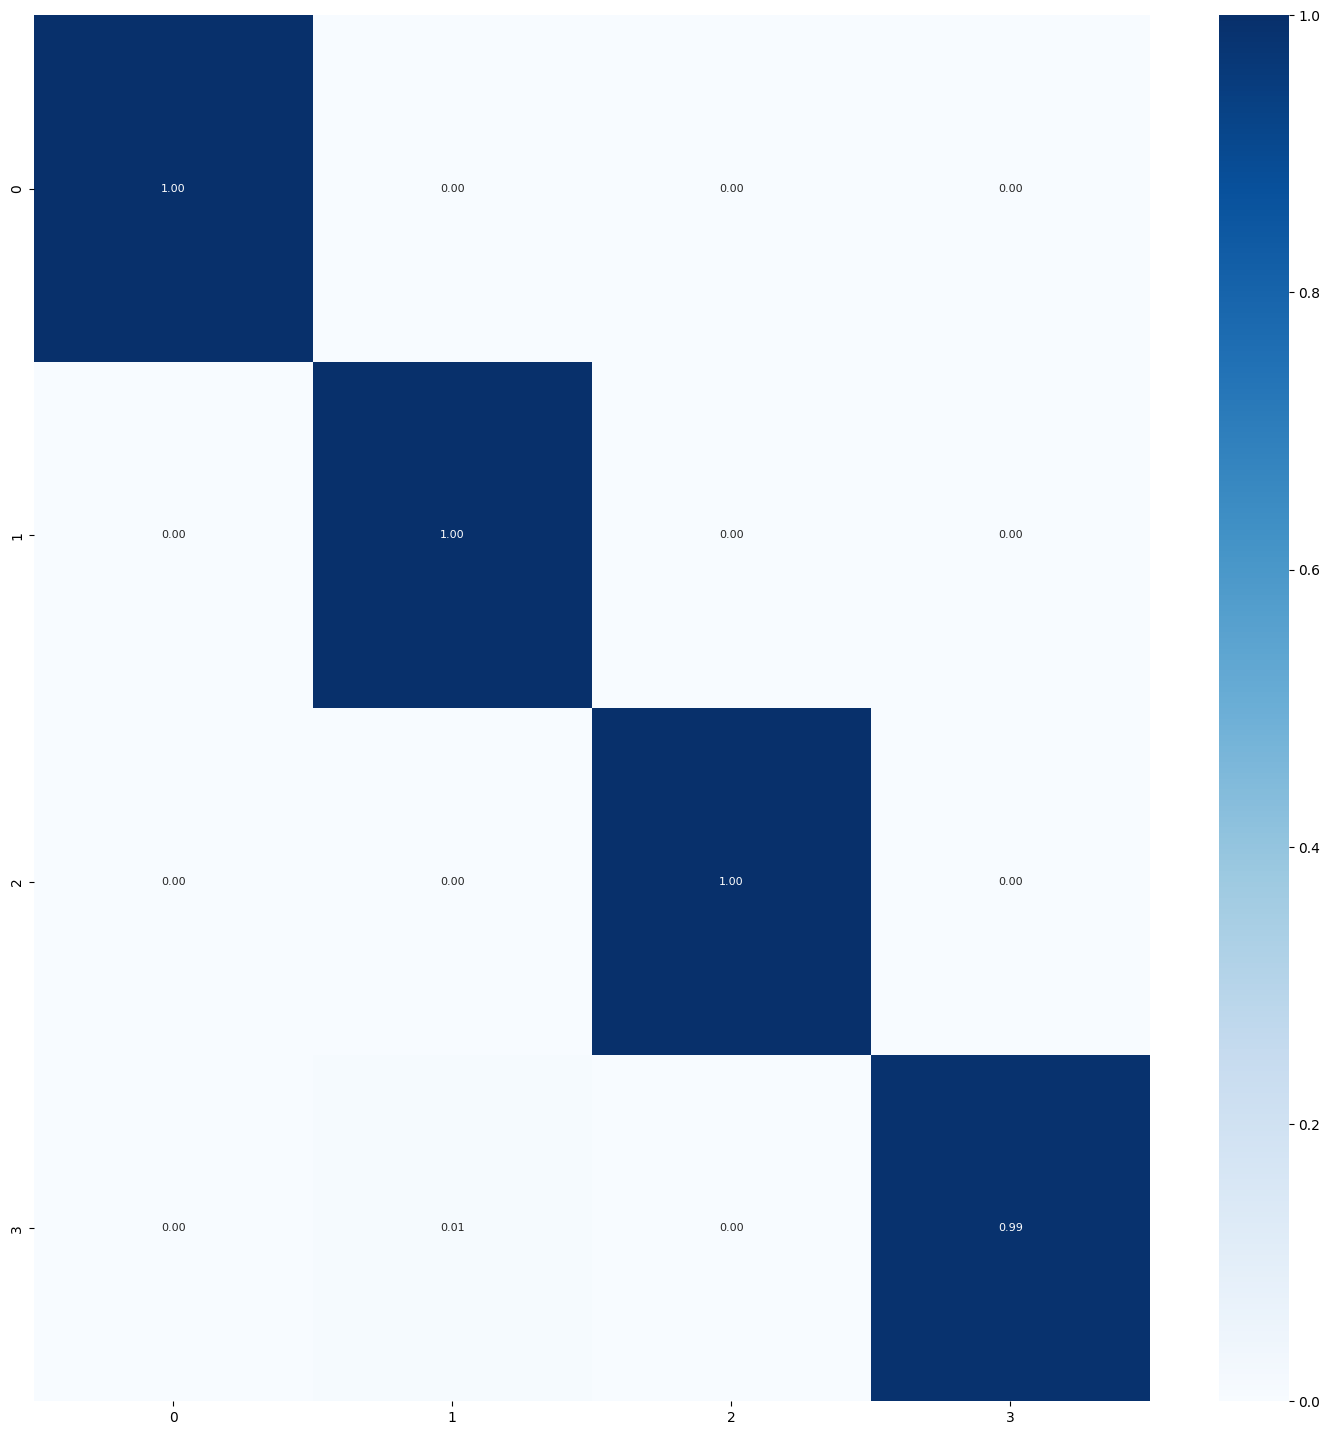


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793508
Trainable params: 2793156
Non-trainable params: 352
Epoch 1/50
131/131 [==============================] - 28s 161ms/step - loss: 1.2671 - accuracy: 0.9762 - val_loss: 3.3683 - val_accuracy: 0.4822
Epoch 2/50
131/131 [==============================] - 21s 158ms/step - loss: 0.9619 - accuracy: 0.9942 - val_loss: 2.8487 - val_accuracy: 0.2578
Epoch 3/50
131/131 [==============================] - 22s 167ms/step - loss: 0.7159 - accuracy: 0.9974 - val_loss: 1.4972 - val_accuracy: 0.6611
Epoch 4/50
131/131 [==============================] - 22s 168ms/step - loss: 0.5202 - accuracy: 0.9981 - val_loss: 0.5083 - val_accuracy: 0.9956
Epoch 5/50
131/131 [==============================] - 14s 105ms/step - loss: 0.3767 - accuracy: 0.9993 - val_loss: 0.3389 - val_accuracy: 0.9922
Epoch 6/50
131/131 [==============================] - 20s 150ms/step - loss: 0.2781 - accuracy: 0.9986 - val_loss: 0.2700 - val_accuracy: 0.9956
Epoch 7/50
131/131

Model and History saved...
132/132 [==============================] - 11s 85ms/step - loss: 0.0290 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.02896798960864544
29/29 [==============================] - 3s 86ms/step - loss: 0.0504 - accuracy: 0.9944
Validation Accuracy: 0.9944444298744202
Validation Log Loss: 0.0504307858645916
29/29 [==============================] - 3s 86ms/step - loss: 0.0414 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.041359275579452515
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00      1.00      1.00       225
           3      

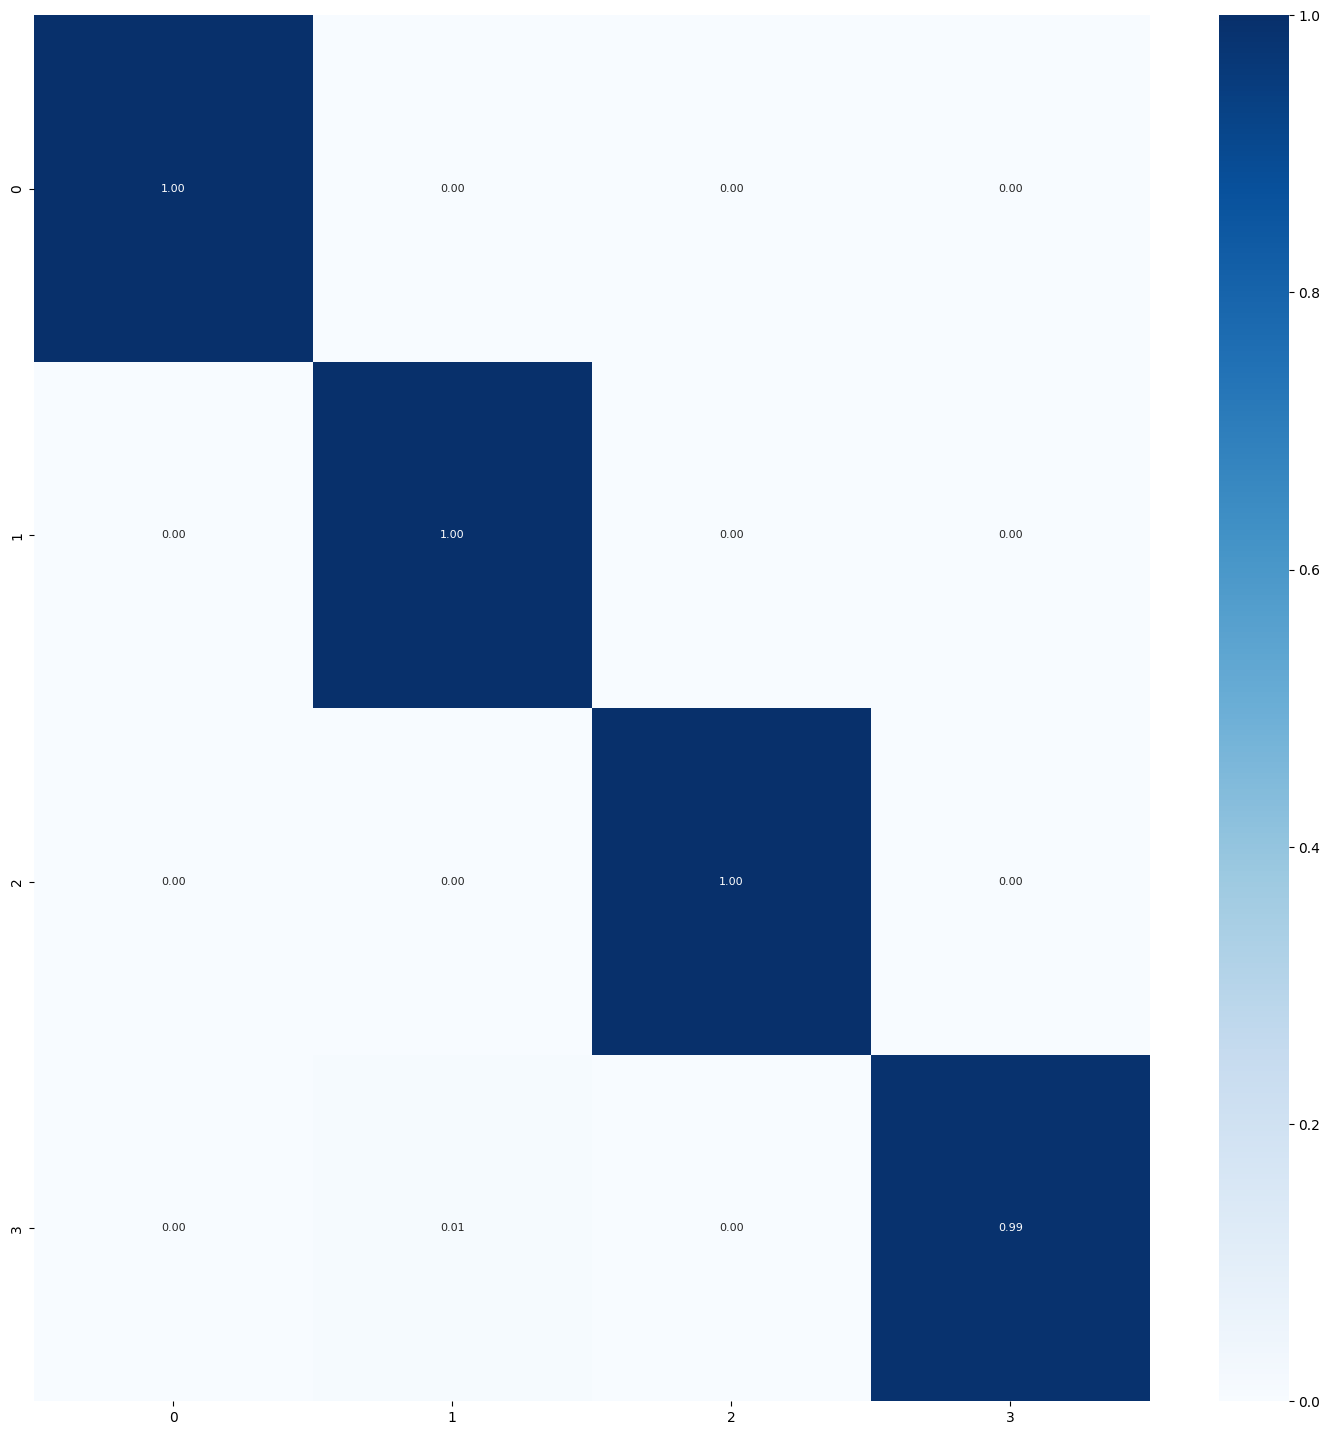


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793508
Trainable params: 2793156
Non-trainable params: 352
Epoch 1/50
131/131 [==============================] - 31s 173ms/step - loss: 1.3096 - accuracy: 0.9679 - val_loss: 5.1427 - val_accuracy: 0.2511
Epoch 2/50
131/131 [==============================] - 22s 166ms/step - loss: 1.0019 - accuracy: 0.9950 - val_loss: 3.8692 - val_accuracy: 0.4922
Epoch 3/50
131/131 [==============================] - 22s 169ms/step - loss: 0.7967 - accuracy: 0.9935 - val_loss: 1.6904 - val_accuracy: 0.5178
Epoch 4/50
131/131 [==============================] - 21s 161ms/step - loss: 0.6170 - accuracy: 0.9986 - val_loss: 0.7087 - val_accuracy: 0.9711
Epoch 5/50
131/131 [==============================] - 15s 110ms/step - loss: 0.4800 - accuracy: 0.9976 - val_loss: 0.4888 - val_accuracy: 0.9956
Epoch 6/50
131/131 [==============================] - 19s 141ms/step - loss: 0.3779 - accuracy: 0.9964 - val_loss: 0.3398 - val_accuracy: 0.9967
Epoch 7/50
131/131

Model and History saved...
132/132 [==============================] - 19s 144ms/step - loss: 0.0545 - accuracy: 0.9993
Train Accuracy: 0.9992856979370117
Train Log Loss: 0.054456427693367004
29/29 [==============================] - 5s 154ms/step - loss: 0.0728 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.07284380495548248
29/29 [==============================] - 4s 120ms/step - loss: 0.0699 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.06992119550704956
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   1 224   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00      1.00      1.00       225
           3    

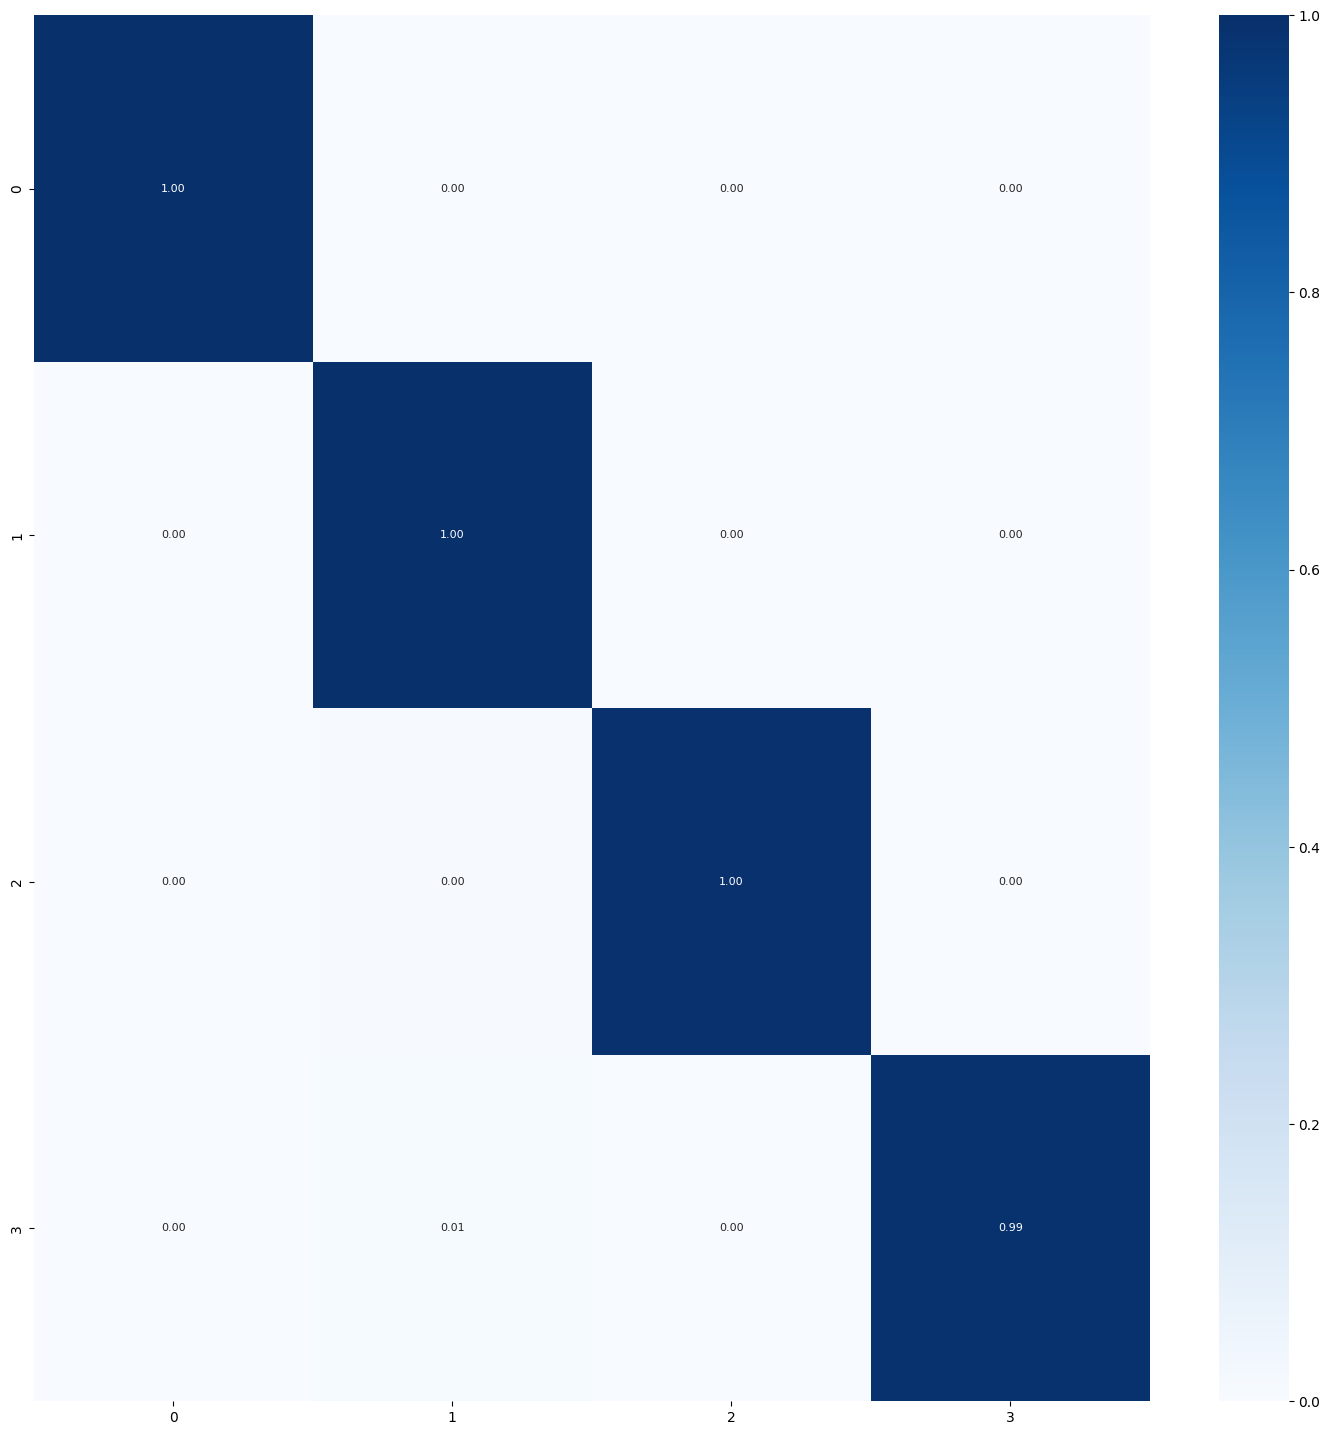

Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9975555419921875
/nTest Metrics
test_acc_list: [0.996666669845581, 0.995555579662323, 0.9977777600288391, 0.9977777600288391, 0.996666669845581]
Average Test Accuracy with 5-fold: 0.9968888878822326
test_loss_list: [0.04156821221113205, 0.04740705341100693, 0.037461601197719574, 0.041359275579452515, 0.06992119550704956]
Average Test Log Loss with 5-fold: 0.04754346758127213

Precision List: [0.9966812853996224, 0.9955944548872181, 0.9977973568281938, 0.9977973568281938, 0.9967105263157895]
Average Precision List with 5-fold: 0.9969161960518036
Recall List: [0.9966666666666667, 0.9955555555555555, 0.9977777777777778, 0.9977777777777778, 0.9966666666666667]
Average Recall List with 5-fold: 0.9968888888888889
F1 Score List: [0.9966666338175296, 0.995557920813202, 0.9977777338811631, 0.9977777338811631, 0.9966715065593046]
Average F1 Score List with 5-fold: 0.9968903057904726

Metrics List Store

test_acc_l

In [17]:
%%time

num_classes = 4
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/5
name_save_model: fusion_cnn_basic_15005
Found 5250 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2793573
Trainable params: 2793221
Non-trainable params: 352
Epoch 1/50
164/164 [==============================] - 31s 143ms/step - loss: 1.3514 - accuracy: 0.9546 - val_loss: 2.6577 - val_accuracy: 0.4062
Epoch 2/50
164/164 [==============================] - 23s 139ms/step - loss: 0.9929 - accuracy: 0.9895 - val_loss: 1.6461 - val_accuracy: 0.7253
Epoch 3/50
164/164 [==============================] - 25s 155ms/step - loss: 0.7414 - accuracy: 0.9923 - val_loss: 0.6844 - val_accuracy: 0.9849
Epoch 4/50
164/164 [==============================] - 26s 156ms/step - loss: 0.5468 - accuracy: 0.9960 - val_loss: 0.4739 - 

Model and History saved...
165/165 [==============================] - 23s 141ms/step - loss: 0.0950 - accuracy: 0.9990
Train Accuracy: 0.9990476369857788
Train Log Loss: 0.09503033012151718
36/36 [==============================] - 5s 130ms/step - loss: 0.1330 - accuracy: 0.9920
Validation Accuracy: 0.9919999837875366
Validation Log Loss: 0.1329711377620697
36/36 [==============================] - 5s 131ms/step - loss: 0.1176 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.11758182942867279
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   0   1]
 [  0   1 223   0   1]
 [  0   2   0 223   0]
 [  0   1   0   0 224]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.98      1.00      0.99       225
           2      

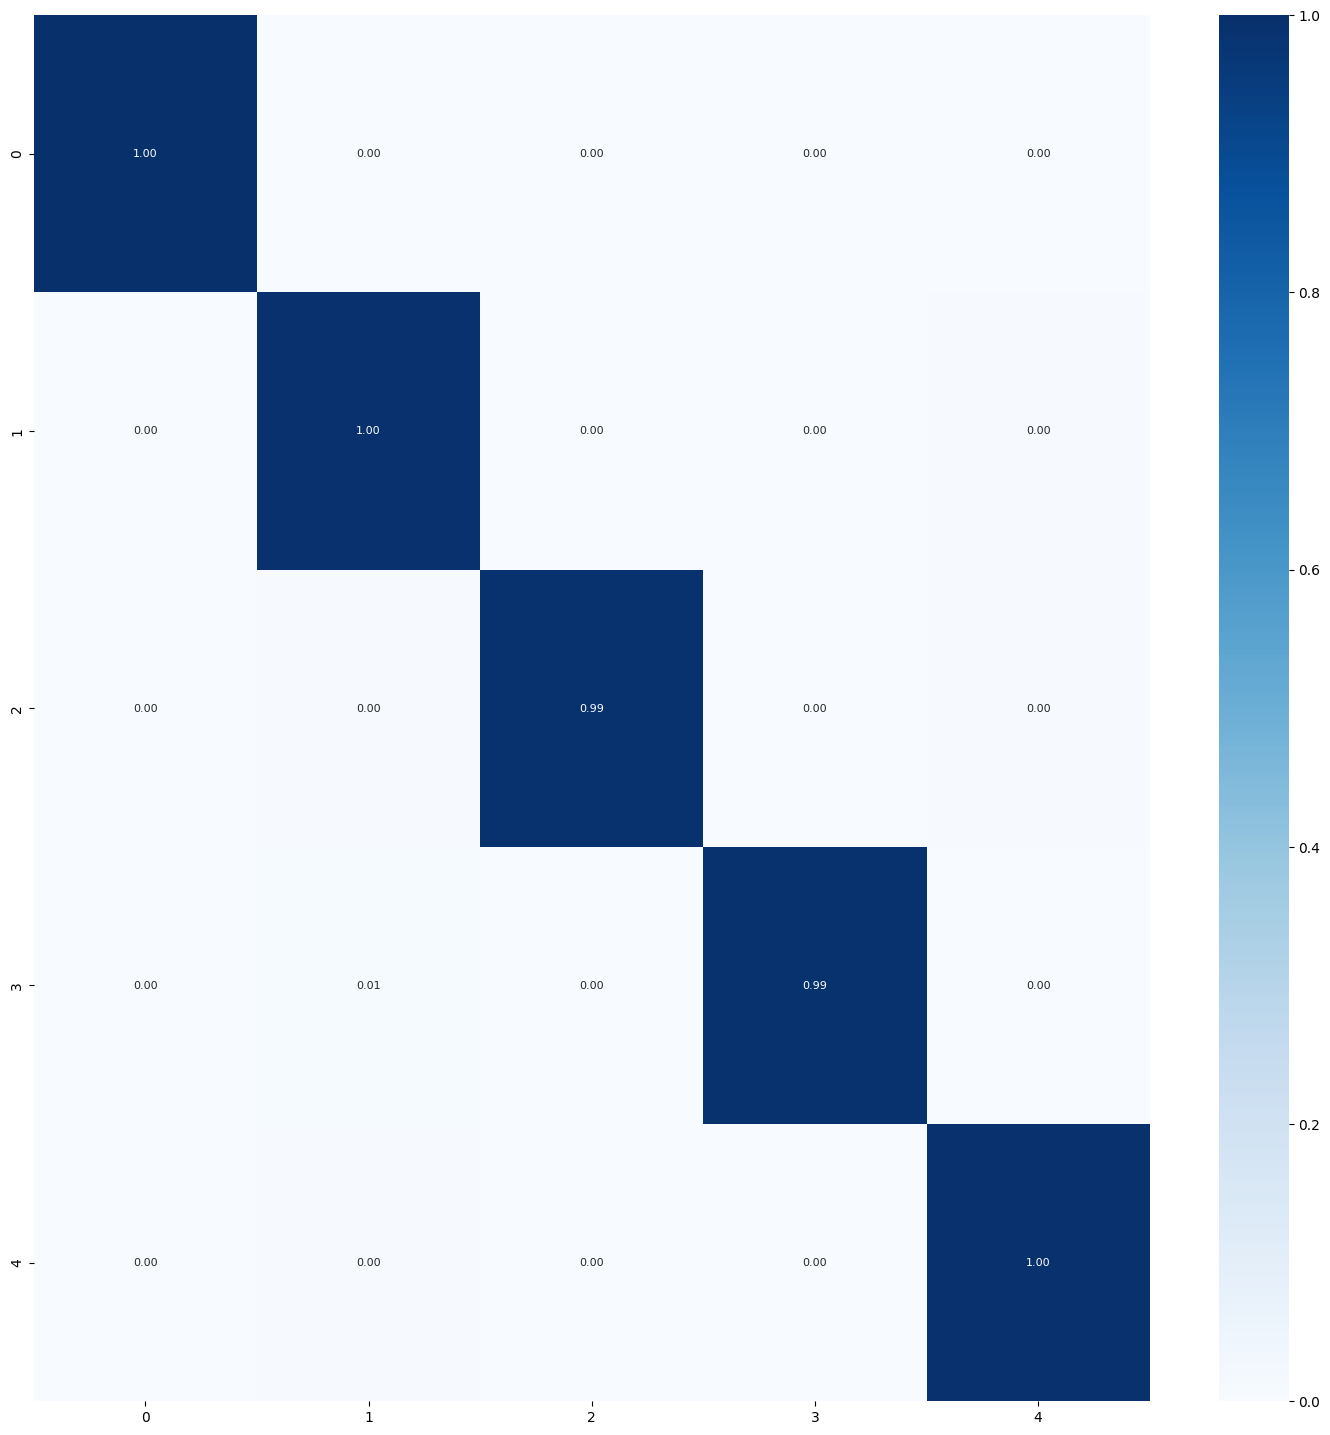


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793573
Trainable params: 2793221
Non-trainable params: 352
Epoch 1/50
164/164 [==============================] - 37s 171ms/step - loss: 1.3088 - accuracy: 0.9682 - val_loss: 2.9287 - val_accuracy: 0.3991
Epoch 2/50
164/164 [==============================] - 29s 174ms/step - loss: 0.9575 - accuracy: 0.9927 - val_loss: 1.6051 - val_accuracy: 0.5013
Epoch 3/50
164/164 [==============================] - 29s 173ms/step - loss: 0.7031 - accuracy: 0.9943 - val_loss: 0.6977 - val_accuracy: 0.9884
Epoch 4/50
164/164 [==============================] - 29s 176ms/step - loss: 0.5145 - accuracy: 0.9962 - val_loss: 0.4494 - val_accuracy: 0.9956
Epoch 5/50
164/164 [==============================] - 23s 140ms/step - loss: 0.3892 - accuracy: 0.9935 - val_loss: 0.3416 - val_accuracy: 0.9956
Epoch 6/50
164/164 [==============================] - 28s 173ms/step - loss: 0.3084 - accuracy: 0.9935 - val_loss: 1.6894 - val_accuracy: 0.8124
Epoch 7/50
164/164

Model and History saved...
165/165 [==============================] - 22s 134ms/step - loss: 0.1400 - accuracy: 0.9973
Train Accuracy: 0.9973333477973938
Train Log Loss: 0.1400253027677536
36/36 [==============================] - 5s 125ms/step - loss: 0.1582 - accuracy: 0.9938
Validation Accuracy: 0.9937777519226074
Validation Log Loss: 0.1582024097442627
36/36 [==============================] - 5s 128ms/step - loss: 0.1634 - accuracy: 0.9964
Test Accuracy: 0.9964444637298584
Test Log Loss: 0.1633802205324173
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   0   0 224]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1

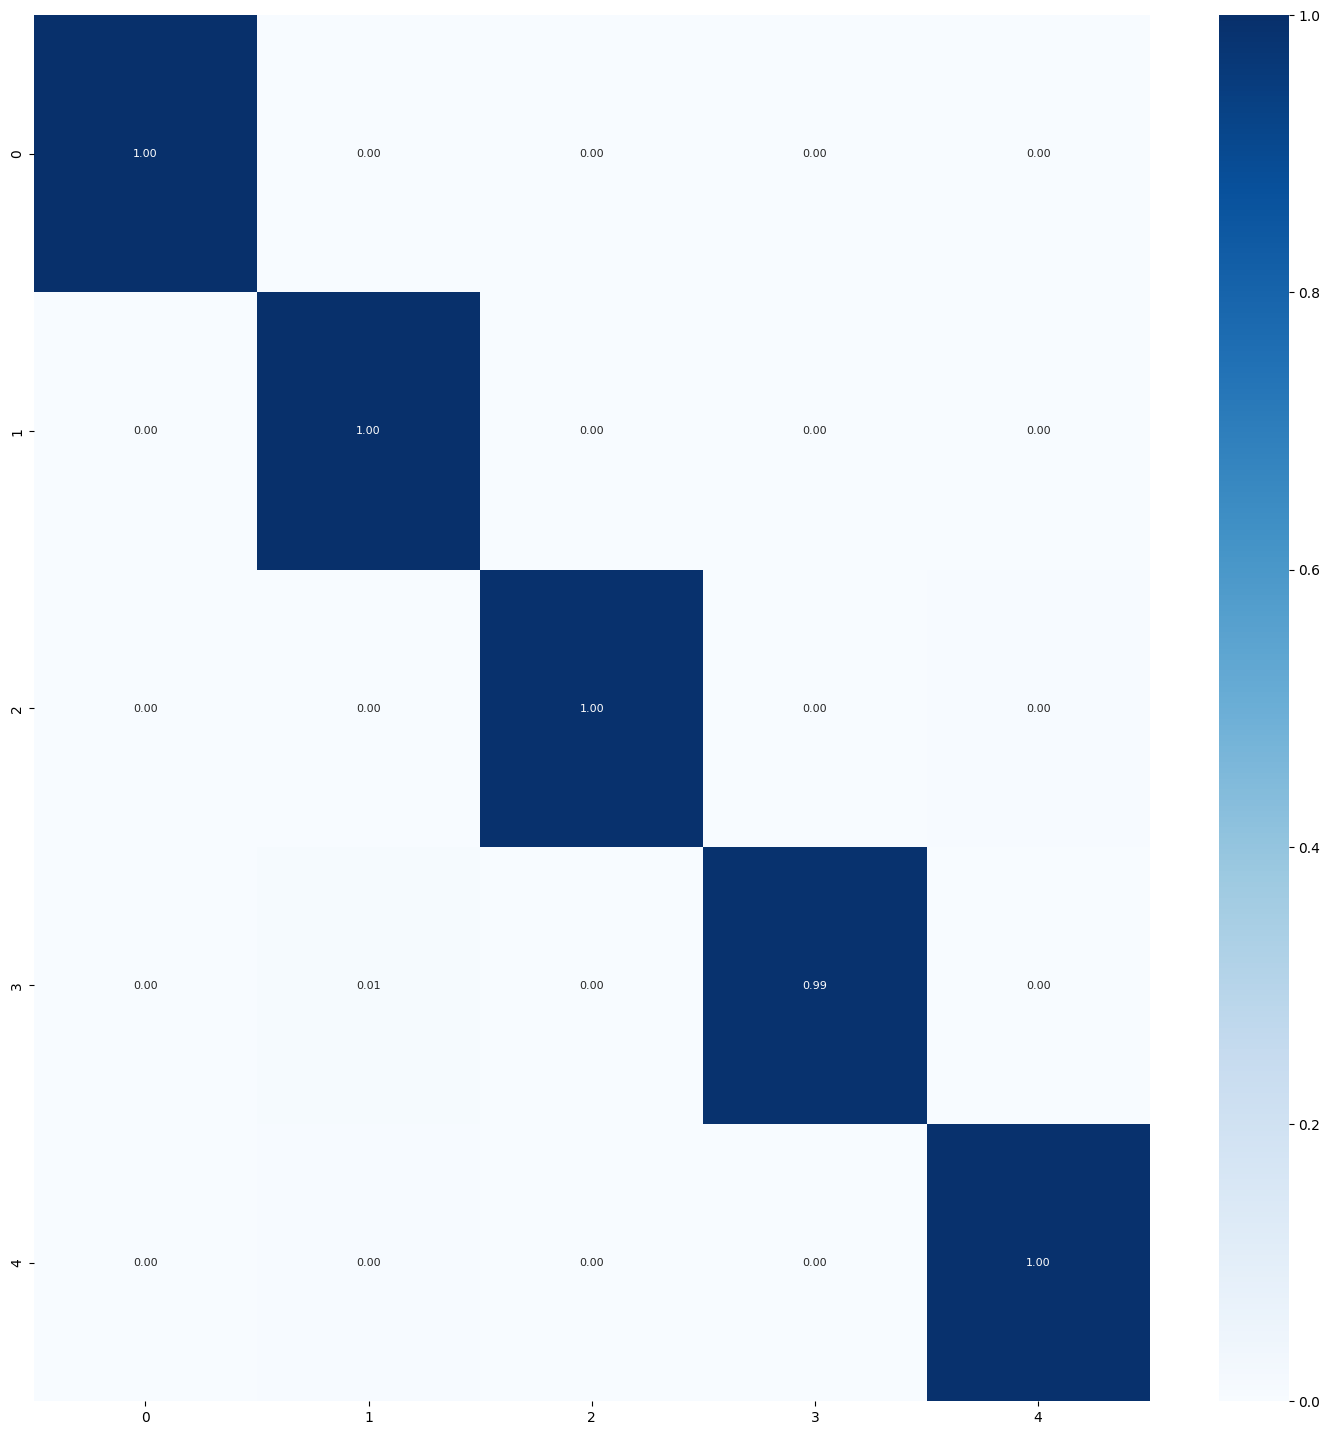


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793573
Trainable params: 2793221
Non-trainable params: 352
Epoch 1/50
164/164 [==============================] - 37s 174ms/step - loss: 1.3763 - accuracy: 0.9525 - val_loss: 2.7386 - val_accuracy: 0.2169
Epoch 2/50
164/164 [==============================] - 23s 141ms/step - loss: 1.0084 - accuracy: 0.9883 - val_loss: 1.2239 - val_accuracy: 0.7920
Epoch 3/50
164/164 [==============================] - 28s 170ms/step - loss: 0.7434 - accuracy: 0.9954 - val_loss: 0.6526 - val_accuracy: 0.9938
Epoch 4/50
164/164 [==============================] - 27s 167ms/step - loss: 0.5438 - accuracy: 0.9960 - val_loss: 0.4705 - val_accuracy: 0.9947
Epoch 5/50
164/164 [==============================] - 28s 171ms/step - loss: 0.3900 - accuracy: 0.9969 - val_loss: 0.3675 - val_accuracy: 0.9956
Epoch 6/50
164/164 [==============================] - 33s 198ms/step - loss: 0.3029 - accuracy: 0.9948 - val_loss: 0.2959 - val_accuracy: 0.9929
Epoch 7/50
164/164

Model and History saved...
165/165 [==============================] - 22s 131ms/step - loss: 0.0715 - accuracy: 0.9992
Train Accuracy: 0.9992380738258362
Train Log Loss: 0.07148858159780502
36/36 [==============================] - 5s 138ms/step - loss: 0.0958 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.0958145260810852
36/36 [==============================] - 5s 136ms/step - loss: 0.0948 - accuracy: 0.9964
Test Accuracy: 0.9964444637298584
Test Log Loss: 0.09476938843727112
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   0   0 224]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       

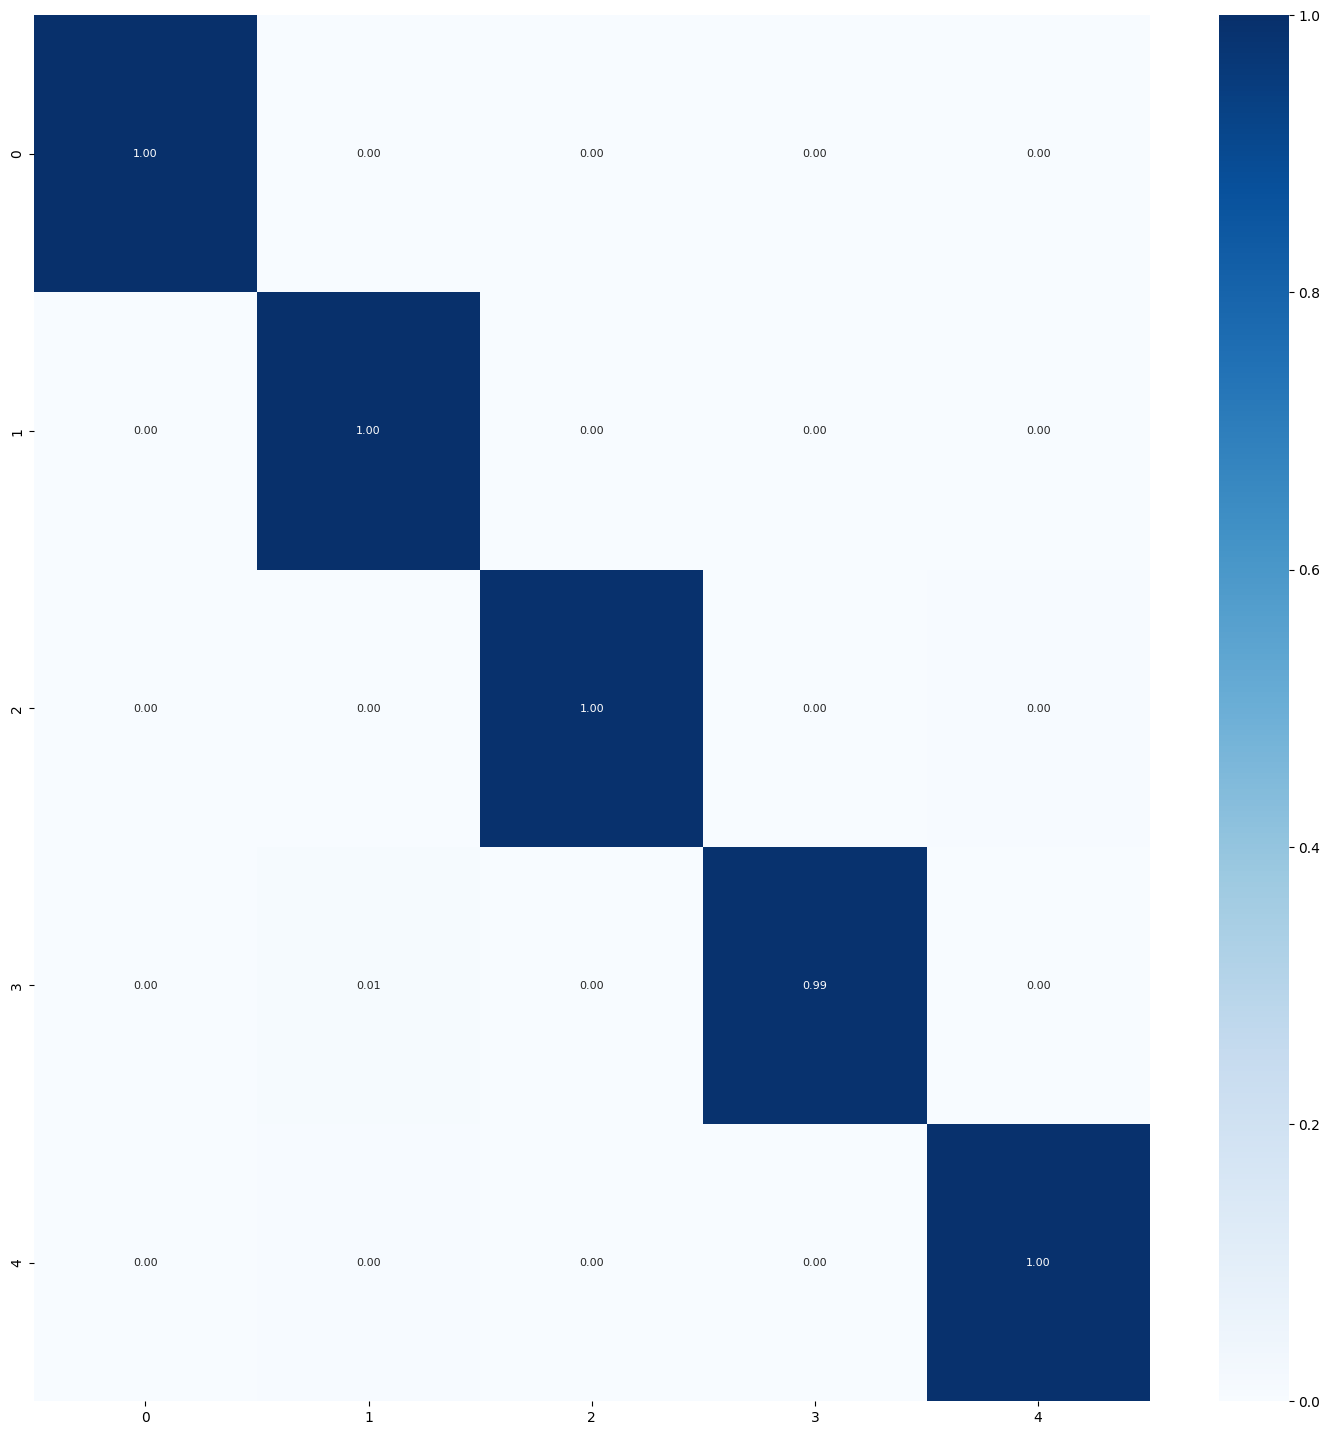


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793573
Trainable params: 2793221
Non-trainable params: 352
Epoch 1/50
164/164 [==============================] - 35s 170ms/step - loss: 1.3828 - accuracy: 0.9504 - val_loss: 3.0937 - val_accuracy: 0.2311
Epoch 2/50
164/164 [==============================] - 27s 165ms/step - loss: 1.0235 - accuracy: 0.9923 - val_loss: 1.8340 - val_accuracy: 0.4978
Epoch 3/50
164/164 [==============================] - 26s 158ms/step - loss: 0.7833 - accuracy: 0.9954 - val_loss: 1.1192 - val_accuracy: 0.7804
Epoch 4/50
164/164 [==============================] - 27s 165ms/step - loss: 0.6025 - accuracy: 0.9952 - val_loss: 0.5493 - val_accuracy: 0.9902
Epoch 5/50
164/164 [==============================] - 27s 165ms/step - loss: 0.4561 - accuracy: 0.9958 - val_loss: 0.4032 - val_accuracy: 0.9964
Epoch 6/50
164/164 [==============================] - 27s 162ms/step - loss: 0.3595 - accuracy: 0.9941 - val_loss: 0.6109 - val_accuracy: 0.7973
Epoch 7/50
164/164

Model and History saved...
165/165 [==============================] - 24s 138ms/step - loss: 0.0673 - accuracy: 0.9992
Train Accuracy: 0.9992380738258362
Train Log Loss: 0.06727677583694458
36/36 [==============================] - 5s 133ms/step - loss: 0.0852 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.08515936136245728
36/36 [==============================] - 5s 132ms/step - loss: 0.0929 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.09294085204601288
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 223   0   0   2]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   0   1   0 224]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      0.99      0.99       225
           2      

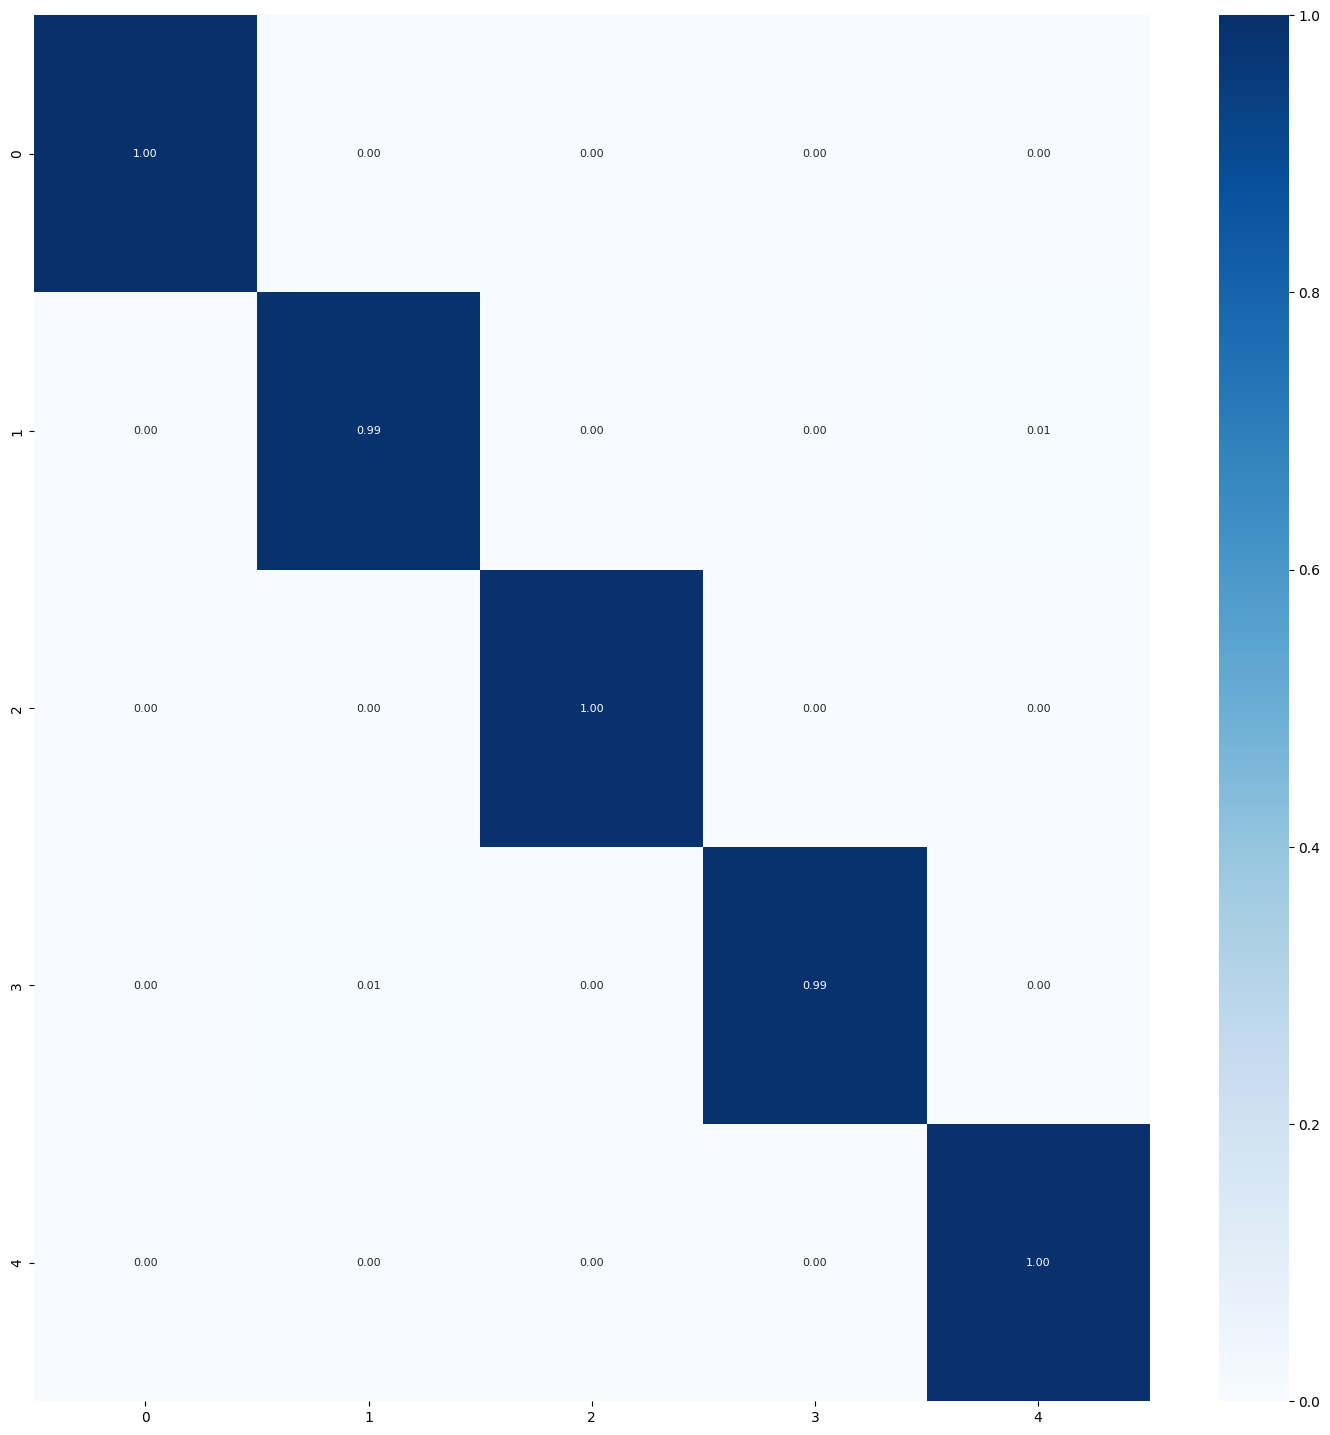


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793573
Trainable params: 2793221
Non-trainable params: 352
Epoch 1/50
164/164 [==============================] - 35s 167ms/step - loss: 1.3878 - accuracy: 0.9481 - val_loss: 3.0464 - val_accuracy: 0.2000
Epoch 2/50
164/164 [==============================] - 19s 116ms/step - loss: 1.0381 - accuracy: 0.9893 - val_loss: 1.7010 - val_accuracy: 0.5707
Epoch 3/50
164/164 [==============================] - 27s 162ms/step - loss: 0.7998 - accuracy: 0.9935 - val_loss: 0.7914 - val_accuracy: 0.9920
Epoch 4/50
164/164 [==============================] - 26s 158ms/step - loss: 0.6197 - accuracy: 0.9939 - val_loss: 0.5450 - val_accuracy: 0.9964
Epoch 5/50
164/164 [==============================] - 26s 160ms/step - loss: 0.4761 - accuracy: 0.9960 - val_loss: 0.4194 - val_accuracy: 0.9938
Epoch 6/50
164/164 [==============================] - 32s 196ms/step - loss: 0.3633 - accuracy: 0.9971 - val_loss: 0.3205 - val_accuracy: 0.9938
Epoch 7/50
164/164

Model and History saved...
165/165 [==============================] - 22s 130ms/step - loss: 0.1349 - accuracy: 0.9983
Train Accuracy: 0.998285710811615
Train Log Loss: 0.13488833606243134
36/36 [==============================] - 5s 127ms/step - loss: 0.1574 - accuracy: 0.9938
Validation Accuracy: 0.9937777519226074
Validation Log Loss: 0.1573813408613205
36/36 [==============================] - 6s 160ms/step - loss: 0.1691 - accuracy: 0.9938
Test Accuracy: 0.9937777519226074
Test Log Loss: 0.16908669471740723
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   1 223   0   1]
 [  0   2   0 223   0]
 [  0   3   0   0 222]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.97      1.00      0.99       225
           2       

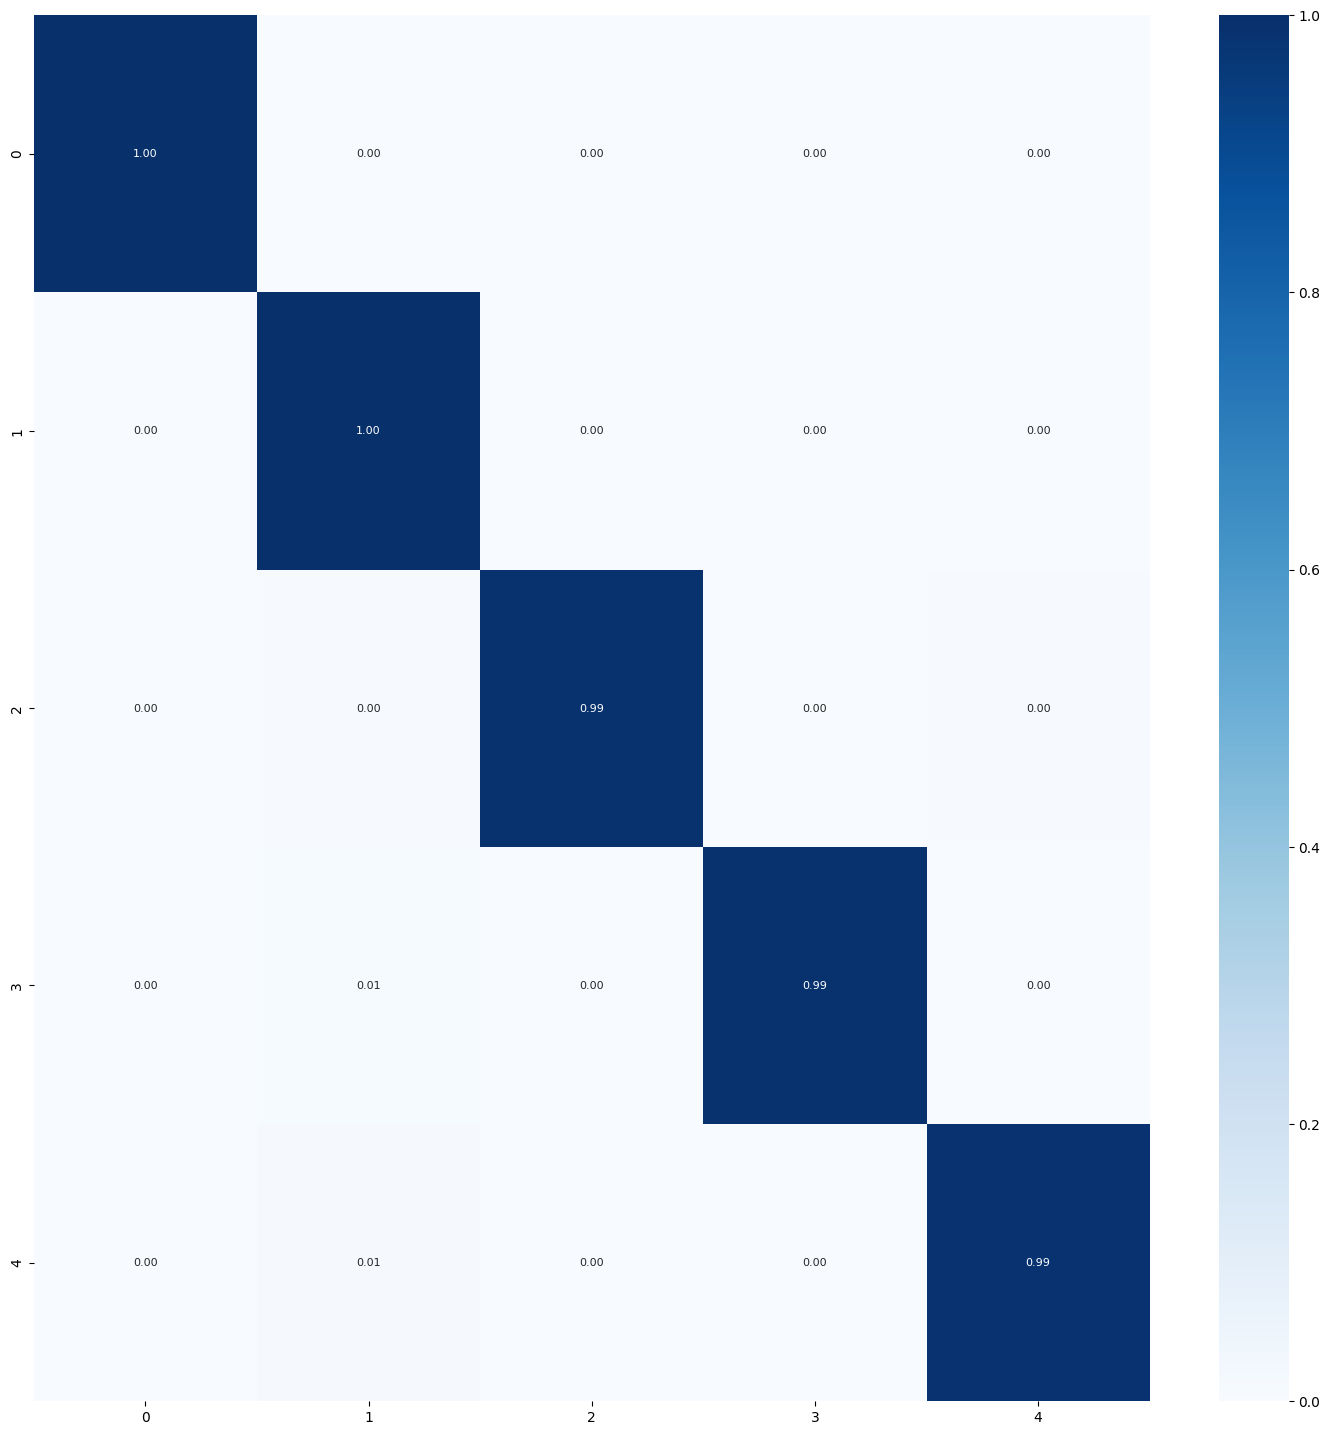

Average training accuracy in 5-fold: 0.9989267826080322
Average validation precision in 5-fold: 0.9964444637298584
/nTest Metrics
test_acc_list: [0.9946666955947876, 0.9964444637298584, 0.9964444637298584, 0.9946666955947876, 0.9937777519226074]
Average Test Accuracy with 5-fold: 0.9952000141143799
test_loss_list: [0.11758182942867279, 0.1633802205324173, 0.09476938843727112, 0.09294085204601288, 0.16908669471740723]
Average Test Log Loss with 5-fold: 0.12755179703235625

Precision List: [0.9947213165657507, 0.9964795321637426, 0.9964795321637426, 0.9946901615271658, 0.9939083338186476]
Average Precision List with 5-fold: 0.99525577524781
Recall List: [0.9946666666666667, 0.9964444444444445, 0.9964444444444445, 0.9946666666666666, 0.9937777777777776]
Average Recall List with 5-fold: 0.9952
F1 Score List: [0.994676403255389, 0.9964483163585548, 0.9964483163585548, 0.9946705646860513, 0.993796992481203]
Average F1 Score List with 5-fold: 0.9952081186279506

Metrics List Store

test_acc_l

In [18]:
%%time

num_classes = 5
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

In [16]:
test_acc_list_all = [0.995111095905304, 0.9721481561660766, 0.9968888878822326, 0.9952000141143799]
test_loss_list_all = [0.03669021539390087, 0.08600231613963842, 0.04754346758127213, 0.12755179703235625]
precision_list_all = [0.9952390899768316, 0.9799167320115005, 0.9969161960518036, 0.99525577524781]
recall_list_all = [0.9951111111111111, 0.9721481481481483, 0.9968888888888889, 0.9952]
f1_score_list_all = [0.9951099804403111, 0.9709985121761818, 0.9968903057904726, 0.9952081186279506]

Familias de malware copiadas
source2: /notebooks/train3/all_malware/6
name_save_model: fusion_cnn_basic_15006
Found 6300 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira

TRAINING AND EVALUATING FOLD 1/5...



2025-05-23 12:41:05.991458: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22449 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6


Total params: 2793638
Trainable params: 2793286
Non-trainable params: 352
Epoch 1/50


2025-05-23 12:41:08.580073: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-05-23 12:41:10.421350: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f011de5bb10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-23 12:41:10.421387: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-23 12:41:10.427598: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748004070.570323     438 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


196/196 [==============================] - 22s 80ms/step - loss: 1.3825 - accuracy: 0.9485 - val_loss: 3.2234 - val_accuracy: 0.3319
Epoch 2/50
196/196 [==============================] - 15s 77ms/step - loss: 1.0046 - accuracy: 0.9868 - val_loss: 1.3531 - val_accuracy: 0.8674
Epoch 3/50
196/196 [==============================] - 15s 75ms/step - loss: 0.7624 - accuracy: 0.9880 - val_loss: 0.7613 - val_accuracy: 0.9770
Epoch 4/50
196/196 [==============================] - 15s 75ms/step - loss: 0.5655 - accuracy: 0.9935 - val_loss: 0.5390 - val_accuracy: 0.9933
Epoch 5/50
196/196 [==============================] - 15s 76ms/step - loss: 0.4062 - accuracy: 0.9960 - val_loss: 0.3506 - val_accuracy: 0.9933
Epoch 6/50
196/196 [==============================] - 15s 74ms/step - loss: 0.2974 - accuracy: 0.9949 - val_loss: 0.2755 - val_accuracy: 0.9904
Epoch 7/50
196/196 [==============================] - 16s 82ms/step - loss: 0.2186 - accuracy: 0.9968 - val_loss: 0.2133 - val_accuracy: 0.9904
Epo

Model and History saved...
197/197 [==============================] - 18s 92ms/step - loss: 0.0891 - accuracy: 0.9946
Train Accuracy: 0.994603157043457
Train Log Loss: 0.08913008123636246
43/43 [==============================] - 6s 134ms/step - loss: 0.1289 - accuracy: 0.9874
Validation Accuracy: 0.987407386302948
Validation Log Loss: 0.12892459332942963
43/43 [==============================] - 6s 125ms/step - loss: 0.1454 - accuracy: 0.9770
Test Accuracy: 0.9770370125770569
Test Log Loss: 0.14536382257938385
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 212   3   8   0   2]
 [  0   1 212   9   0   3]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   0   0   2   0 223]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1    

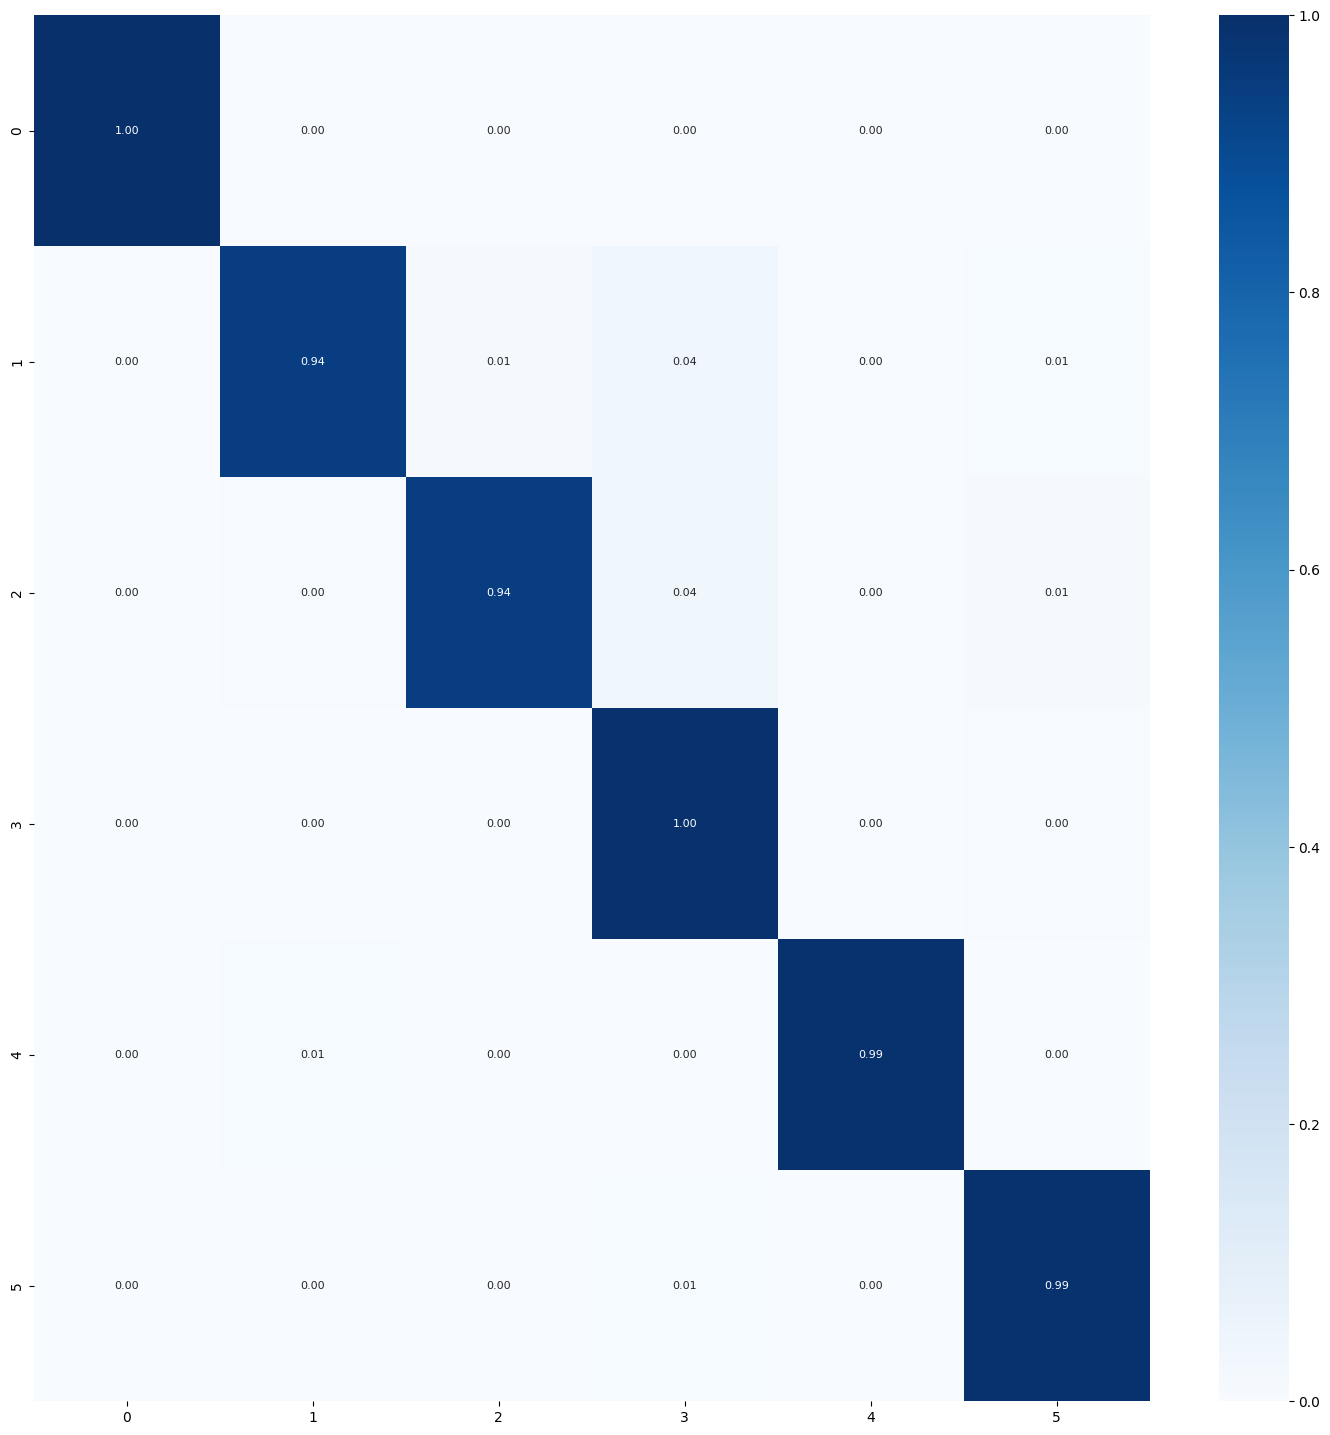


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793638
Trainable params: 2793286
Non-trainable params: 352
Epoch 1/50
196/196 [==============================] - 40s 164ms/step - loss: 1.4137 - accuracy: 0.9434 - val_loss: 3.0340 - val_accuracy: 0.3296
Epoch 2/50
196/196 [==============================] - 32s 162ms/step - loss: 1.0070 - accuracy: 0.9869 - val_loss: 1.5765 - val_accuracy: 0.6763
Epoch 3/50
196/196 [==============================] - 32s 161ms/step - loss: 0.7631 - accuracy: 0.9899 - val_loss: 0.7342 - val_accuracy: 0.9867
Epoch 4/50
196/196 [==============================] - 32s 161ms/step - loss: 0.5512 - accuracy: 0.9954 - val_loss: 0.4872 - val_accuracy: 0.9919
Epoch 5/50
196/196 [==============================] - 31s 159ms/step - loss: 0.4036 - accuracy: 0.9955 - val_loss: 0.3668 - val_accuracy: 0.9904
Epoch 6/50
196/196 [==============================] - 30s 151ms/step - loss: 0.2944 - accuracy: 0.9970 - val_loss: 0.2728 - val_accuracy: 0.9919
Epoch 7/50
196/196

Model and History saved...
197/197 [==============================] - 24s 124ms/step - loss: 0.0502 - accuracy: 0.9997
Train Accuracy: 0.9996825456619263
Train Log Loss: 0.05016852170228958
43/43 [==============================] - 6s 134ms/step - loss: 0.0806 - accuracy: 0.9926
Validation Accuracy: 0.9925925731658936
Validation Log Loss: 0.0805799663066864
43/43 [==============================] - 5s 123ms/step - loss: 0.0812 - accuracy: 0.9941
Test Accuracy: 0.9940740466117859
Test Log Loss: 0.08122991770505905
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   1 222   1   0   1]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   0   0 224]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1  

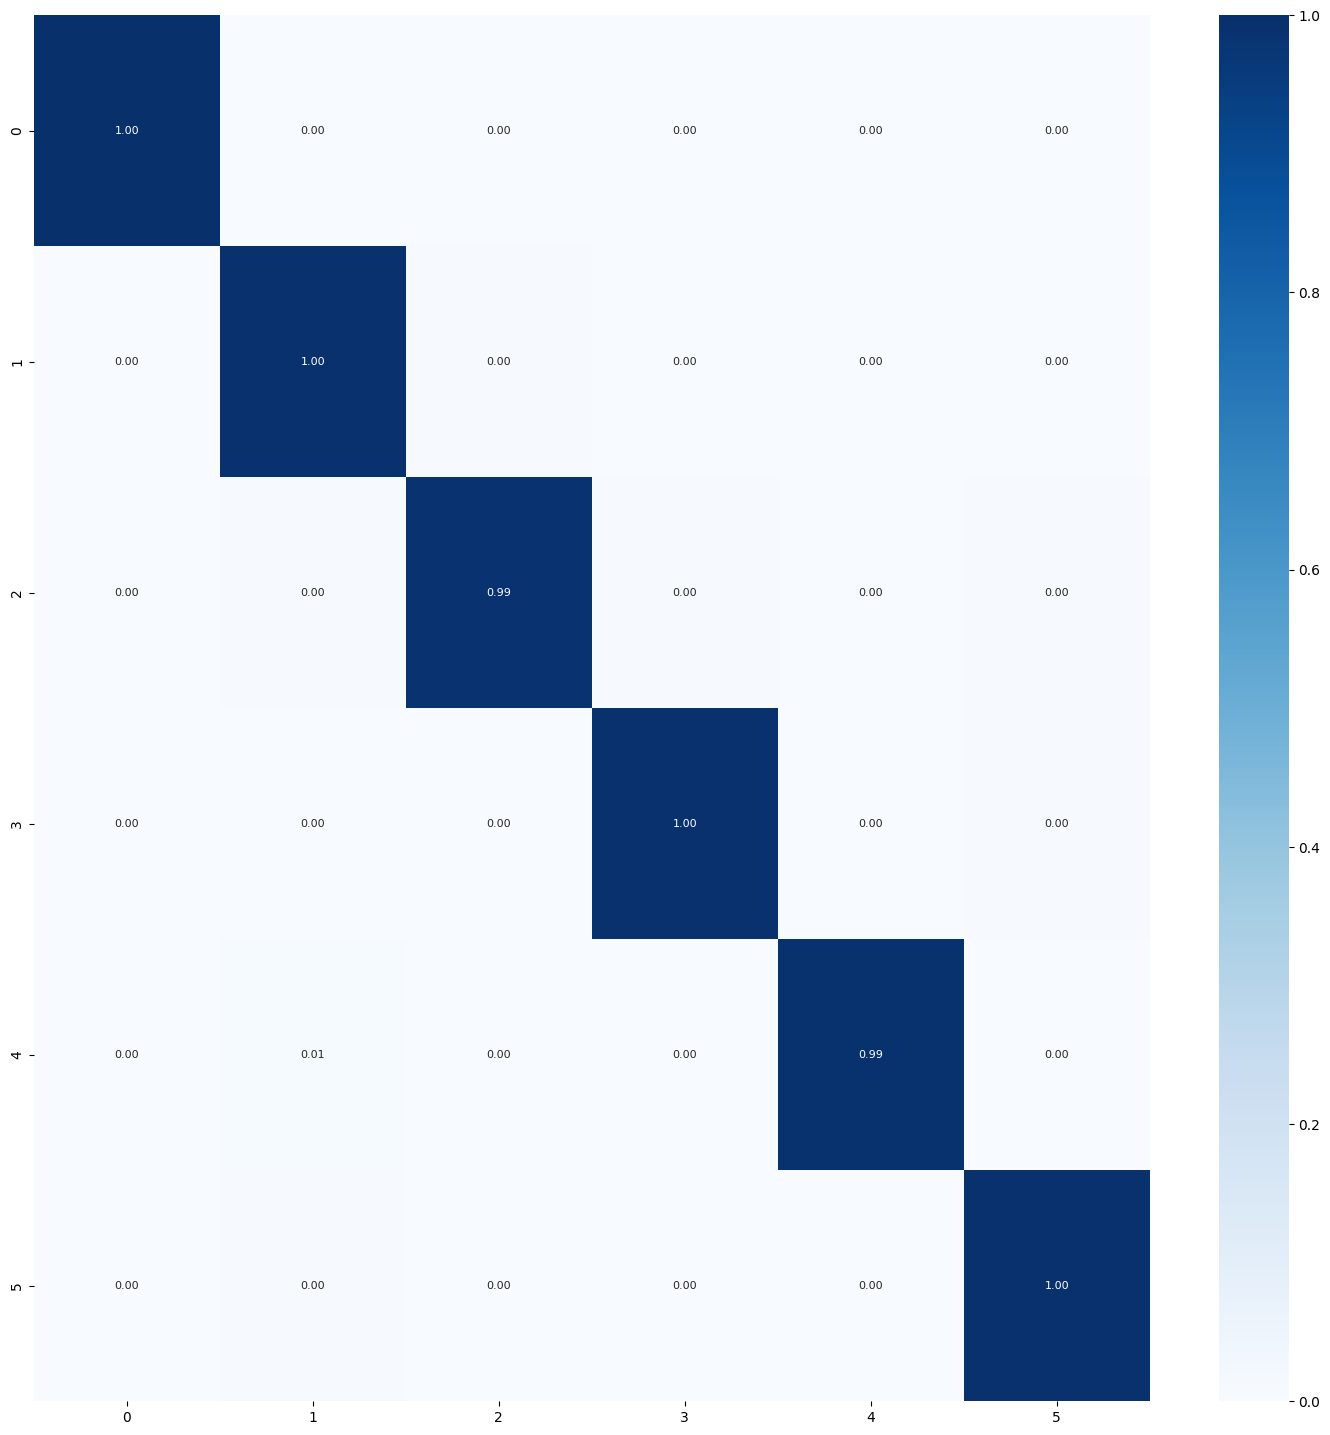


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793638
Trainable params: 2793286
Non-trainable params: 352
Epoch 1/50
196/196 [==============================] - 45s 189ms/step - loss: 1.4279 - accuracy: 0.9383 - val_loss: 3.0226 - val_accuracy: 0.3459
Epoch 2/50
196/196 [==============================] - 30s 153ms/step - loss: 1.0282 - accuracy: 0.9874 - val_loss: 1.4141 - val_accuracy: 0.7652
Epoch 3/50
196/196 [==============================] - 30s 153ms/step - loss: 0.7729 - accuracy: 0.9930 - val_loss: 0.7539 - val_accuracy: 0.9726
Epoch 4/50
196/196 [==============================] - 30s 151ms/step - loss: 0.5703 - accuracy: 0.9935 - val_loss: 0.5048 - val_accuracy: 0.9911
Epoch 5/50
196/196 [==============================] - 30s 155ms/step - loss: 0.4160 - accuracy: 0.9954 - val_loss: 0.3759 - val_accuracy: 0.9896
Epoch 6/50
196/196 [==============================] - 30s 150ms/step - loss: 0.3021 - accuracy: 0.9976 - val_loss: 0.2846 - val_accuracy: 0.9904
Epoch 7/50
196/196

Model and History saved...
197/197 [==============================] - 25s 126ms/step - loss: 0.0770 - accuracy: 0.9997
Train Accuracy: 0.9996825456619263
Train Log Loss: 0.07698584347963333
43/43 [==============================] - 5s 124ms/step - loss: 0.1022 - accuracy: 0.9933
Validation Accuracy: 0.9933333396911621
Validation Log Loss: 0.10224056988954544
43/43 [==============================] - 6s 124ms/step - loss: 0.1082 - accuracy: 0.9926
Test Accuracy: 0.9925925731658936
Test Log Loss: 0.10819704085588455
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   0   0   1   0]
 [  0   2 221   1   0   1]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   0   0   2   0 223]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1 

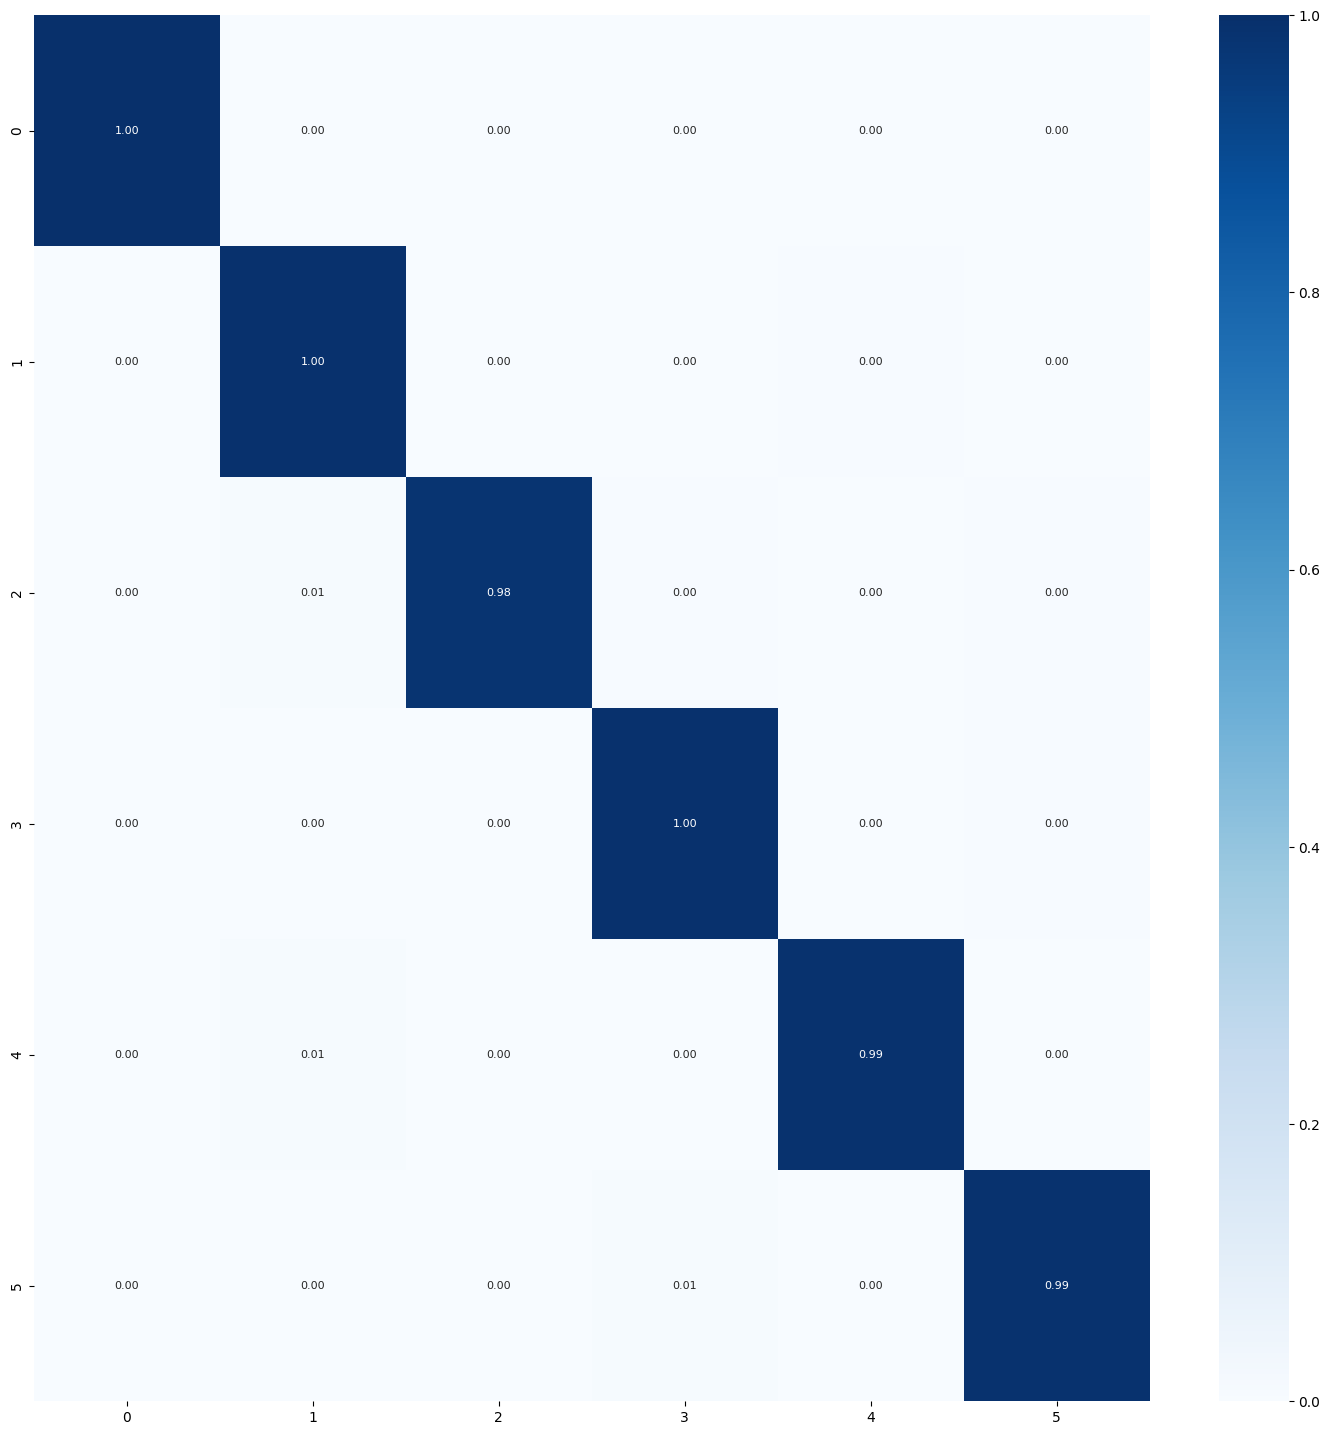


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793638
Trainable params: 2793286
Non-trainable params: 352
Epoch 1/50
196/196 [==============================] - 38s 156ms/step - loss: 1.4374 - accuracy: 0.9300 - val_loss: 2.8524 - val_accuracy: 0.3437
Epoch 2/50
196/196 [==============================] - 30s 153ms/step - loss: 1.0277 - accuracy: 0.9884 - val_loss: 2.0987 - val_accuracy: 0.6785
Epoch 3/50
196/196 [==============================] - 29s 150ms/step - loss: 0.7806 - accuracy: 0.9909 - val_loss: 0.7611 - val_accuracy: 0.9852
Epoch 4/50
196/196 [==============================] - 30s 151ms/step - loss: 0.5718 - accuracy: 0.9957 - val_loss: 0.5094 - val_accuracy: 0.9896
Epoch 5/50
196/196 [==============================] - 30s 152ms/step - loss: 0.4283 - accuracy: 0.9951 - val_loss: 0.3797 - val_accuracy: 0.9904
Epoch 6/50
196/196 [==============================] - 31s 160ms/step - loss: 0.3035 - accuracy: 0.9981 - val_loss: 0.2948 - val_accuracy: 0.9919
Epoch 7/50
196/196

Model and History saved...
197/197 [==============================] - 24s 123ms/step - loss: 0.0712 - accuracy: 0.9986
Train Accuracy: 0.9985714554786682
Train Log Loss: 0.07120730727910995
43/43 [==============================] - 6s 125ms/step - loss: 0.1164 - accuracy: 0.9911
Validation Accuracy: 0.9911110997200012
Validation Log Loss: 0.11636282503604889
43/43 [==============================] - 6s 124ms/step - loss: 0.1048 - accuracy: 0.9904
Test Accuracy: 0.9903703927993774
Test Log Loss: 0.10477499663829803
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   0   0   0   1]
 [  0   4 219   2   0   0]
 [  0   1   0 223   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   1   0 223]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1 

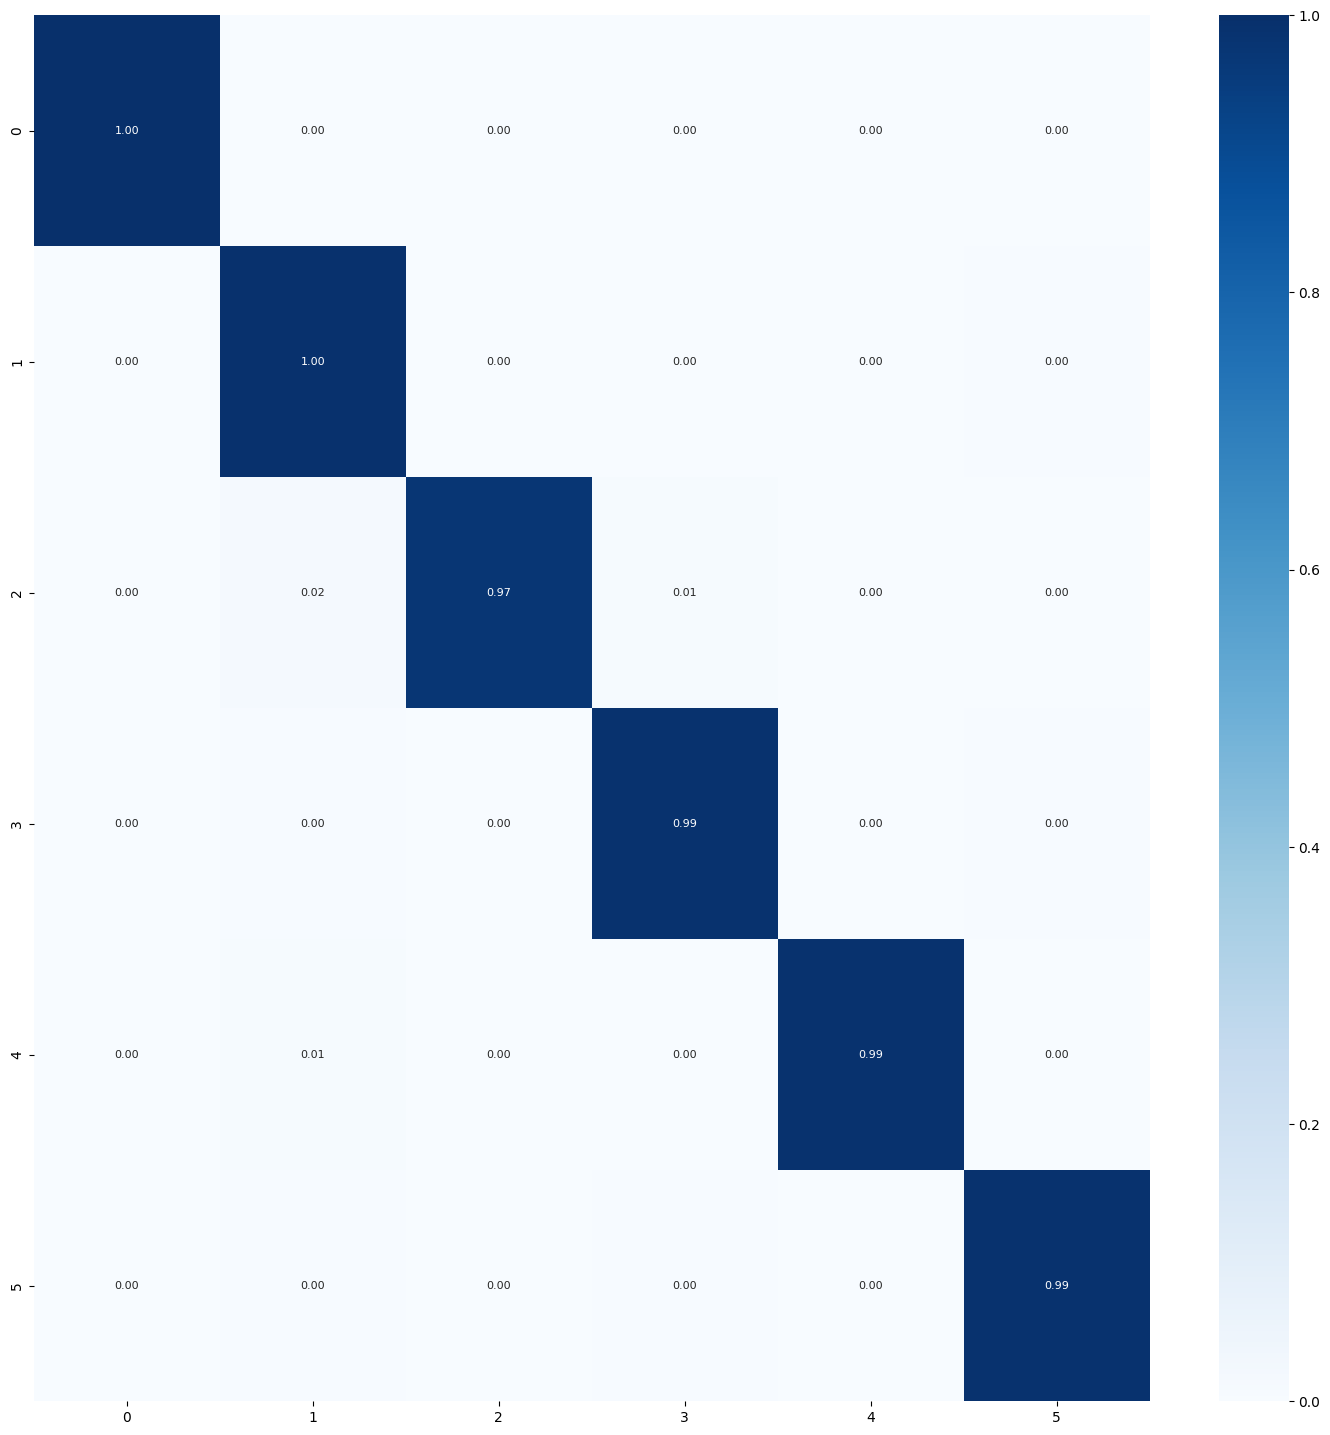


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793638
Trainable params: 2793286
Non-trainable params: 352
Epoch 1/50
196/196 [==============================] - 43s 183ms/step - loss: 1.3898 - accuracy: 0.9437 - val_loss: 3.0721 - val_accuracy: 0.3059
Epoch 2/50
196/196 [==============================] - 30s 155ms/step - loss: 1.0004 - accuracy: 0.9840 - val_loss: 1.9281 - val_accuracy: 0.4970
Epoch 3/50
196/196 [==============================] - 30s 154ms/step - loss: 0.7351 - accuracy: 0.9936 - val_loss: 0.6696 - val_accuracy: 0.9844
Epoch 4/50
196/196 [==============================] - 31s 156ms/step - loss: 0.5326 - accuracy: 0.9946 - val_loss: 0.4659 - val_accuracy: 0.9933
Epoch 5/50
196/196 [==============================] - 30s 151ms/step - loss: 0.3790 - accuracy: 0.9973 - val_loss: 0.3377 - val_accuracy: 0.9919
Epoch 6/50
196/196 [==============================] - 28s 141ms/step - loss: 0.2713 - accuracy: 0.9978 - val_loss: 0.2510 - val_accuracy: 0.9919
Epoch 7/50
196/196

Model and History saved...
197/197 [==============================] - 25s 125ms/step - loss: 0.0725 - accuracy: 0.9973
Train Accuracy: 0.9973015785217285
Train Log Loss: 0.07249415665864944
43/43 [==============================] - 5s 122ms/step - loss: 0.1091 - accuracy: 0.9852
Validation Accuracy: 0.9851852059364319
Validation Log Loss: 0.10907575488090515
43/43 [==============================] - 6s 126ms/step - loss: 0.1034 - accuracy: 0.9874
Test Accuracy: 0.987407386302948
Test Log Loss: 0.10341403633356094
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 221   1   2   0   1]
 [  0   5 218   1   0   1]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  1   0   1   1   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1  

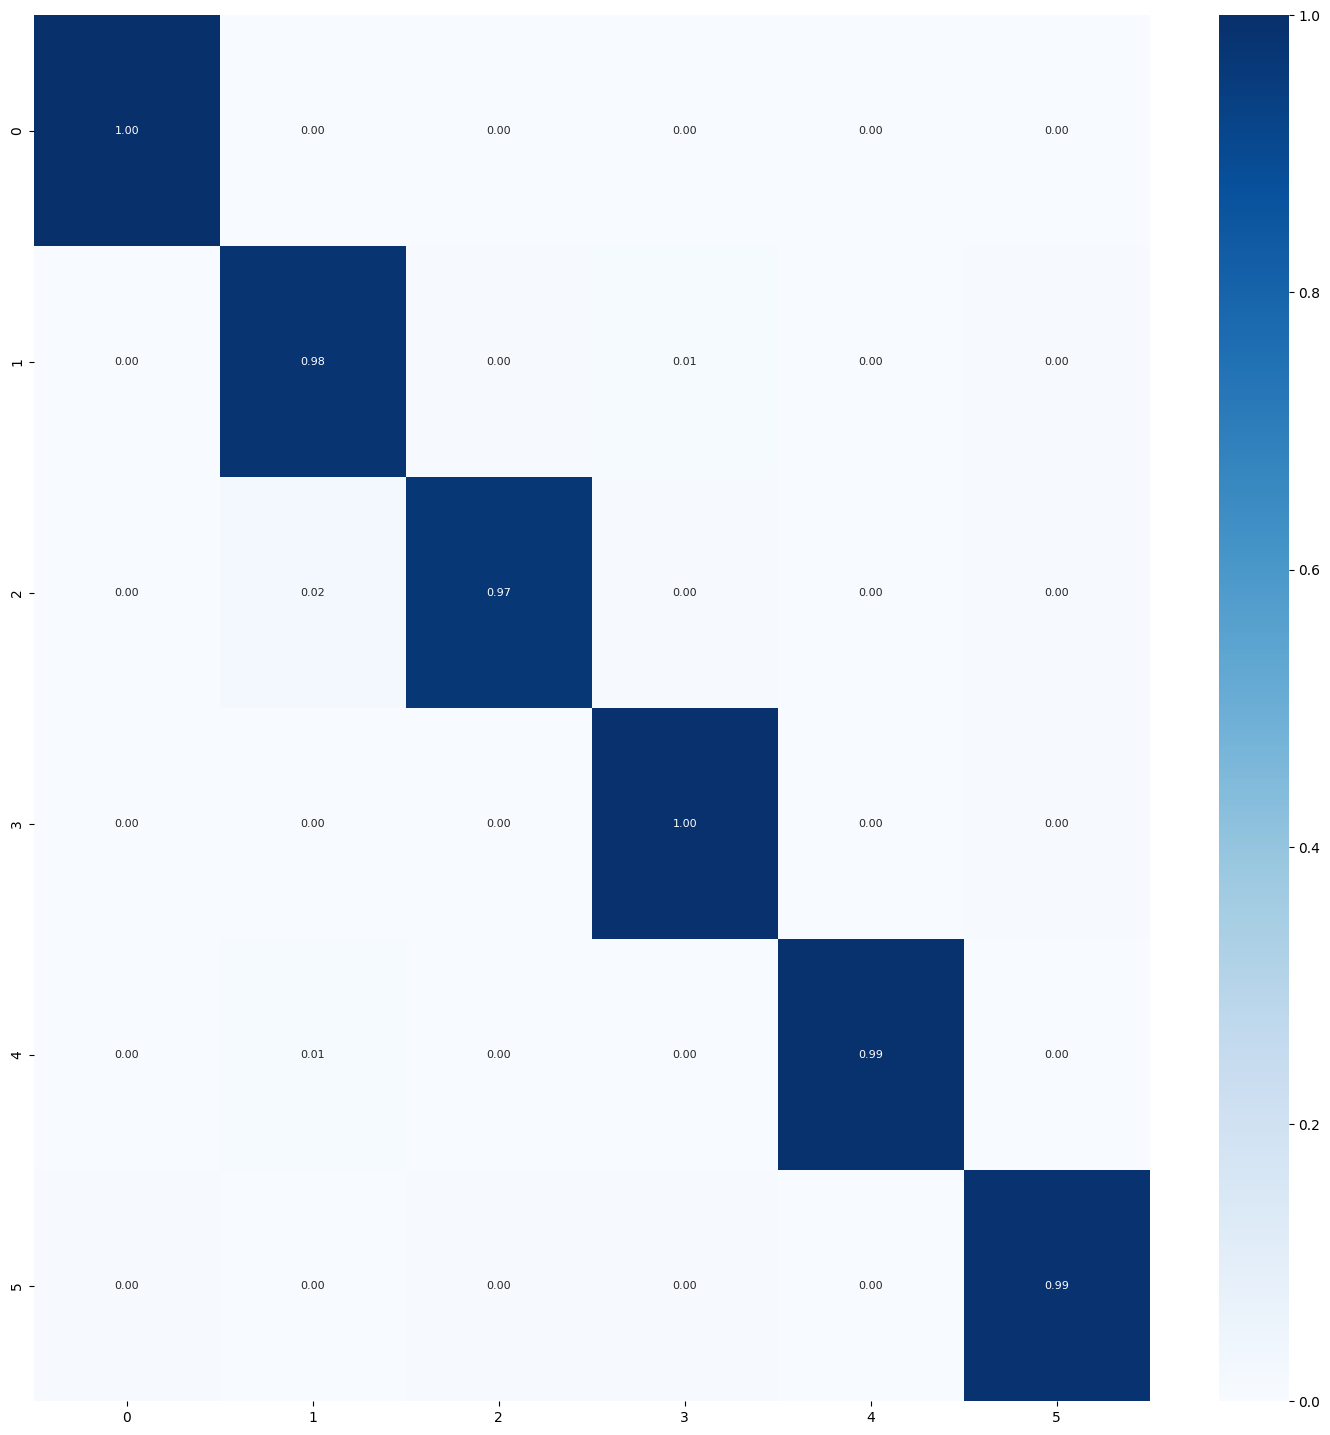

Average training accuracy in 5-fold: 0.99907466173172
Average validation precision in 5-fold: 0.9949629664421081
/nTest Metrics
test_acc_list: [0.9770370125770569, 0.9940740466117859, 0.9925925731658936, 0.9903703927993774, 0.987407386302948]
Average Test Accuracy with 5-fold: 0.9882962822914123
test_loss_list: [0.14536382257938385, 0.08122991770505905, 0.10819704085588455, 0.10477499663829803, 0.10341403633356094]
Average Test Log Loss with 5-fold: 0.10859596282243729

Precision List: [0.9779504749136411, 0.994112972241929, 0.9926478511194777, 0.990559002701206, 0.987484227463268]
Average Precision List with 5-fold: 0.9885509056879045
Recall List: [0.9770370370370371, 0.9940740740740742, 0.9925925925925928, 0.9903703703703705, 0.9874074074074074]
Average Recall List with 5-fold: 0.9882962962962963
F1 Score List: [0.9770753755748248, 0.9940788810197024, 0.9925956502755139, 0.9903921971858741, 0.9874067131084691]
Average F1 Score List with 5-fold: 0.9883097634328768

Metrics List Store


In [17]:
%%time

num_classes = 6
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/7
name_save_model: fusion_cnn_basic_15007
Found 7350 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2793703
Trainable params: 2793351
Non-trainable params: 352
Epoch 1/50
229/229 [==============================] - 44s 160ms/step - loss: 1.4160 - accuracy: 0.9377 - val_loss: 3.0231 - val_accuracy: 0.1429
Epoch 2/50
229/229 [==============================] - 35s 153ms/step - loss: 0.9653 - accuracy: 0.9870 - val_loss: 1.1107 - val_accuracy: 0.9587
Epoch 3/50
229/229 [==============================] - 34s 149ms/step - loss: 0.6904 - accuracy: 0.9940 - val_loss: 0.6043 - val_accuracy: 0.9905
Epoch 4/50
229/229 [==============================] - 35s 152ms/step - loss: 0.4845 - accuracy: 0.9956

Model and History saved...
230/230 [==============================] - 28s 122ms/step - loss: 0.1176 - accuracy: 0.9980
Train Accuracy: 0.9979591965675354
Train Log Loss: 0.11760080605745316
50/50 [==============================] - 6s 120ms/step - loss: 0.1599 - accuracy: 0.9879
Validation Accuracy: 0.9879364967346191
Validation Log Loss: 0.15991440415382385
50/50 [==============================] - 6s 122ms/step - loss: 0.1599 - accuracy: 0.9879
Test Accuracy: 0.9879364967346191
Test Log Loss: 0.15990641713142395
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   1 224   0   0   0   0]
 [  0   0   3 222   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   4   0   0 221   0]
 [  0   0   1   7   1   0 216]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   su

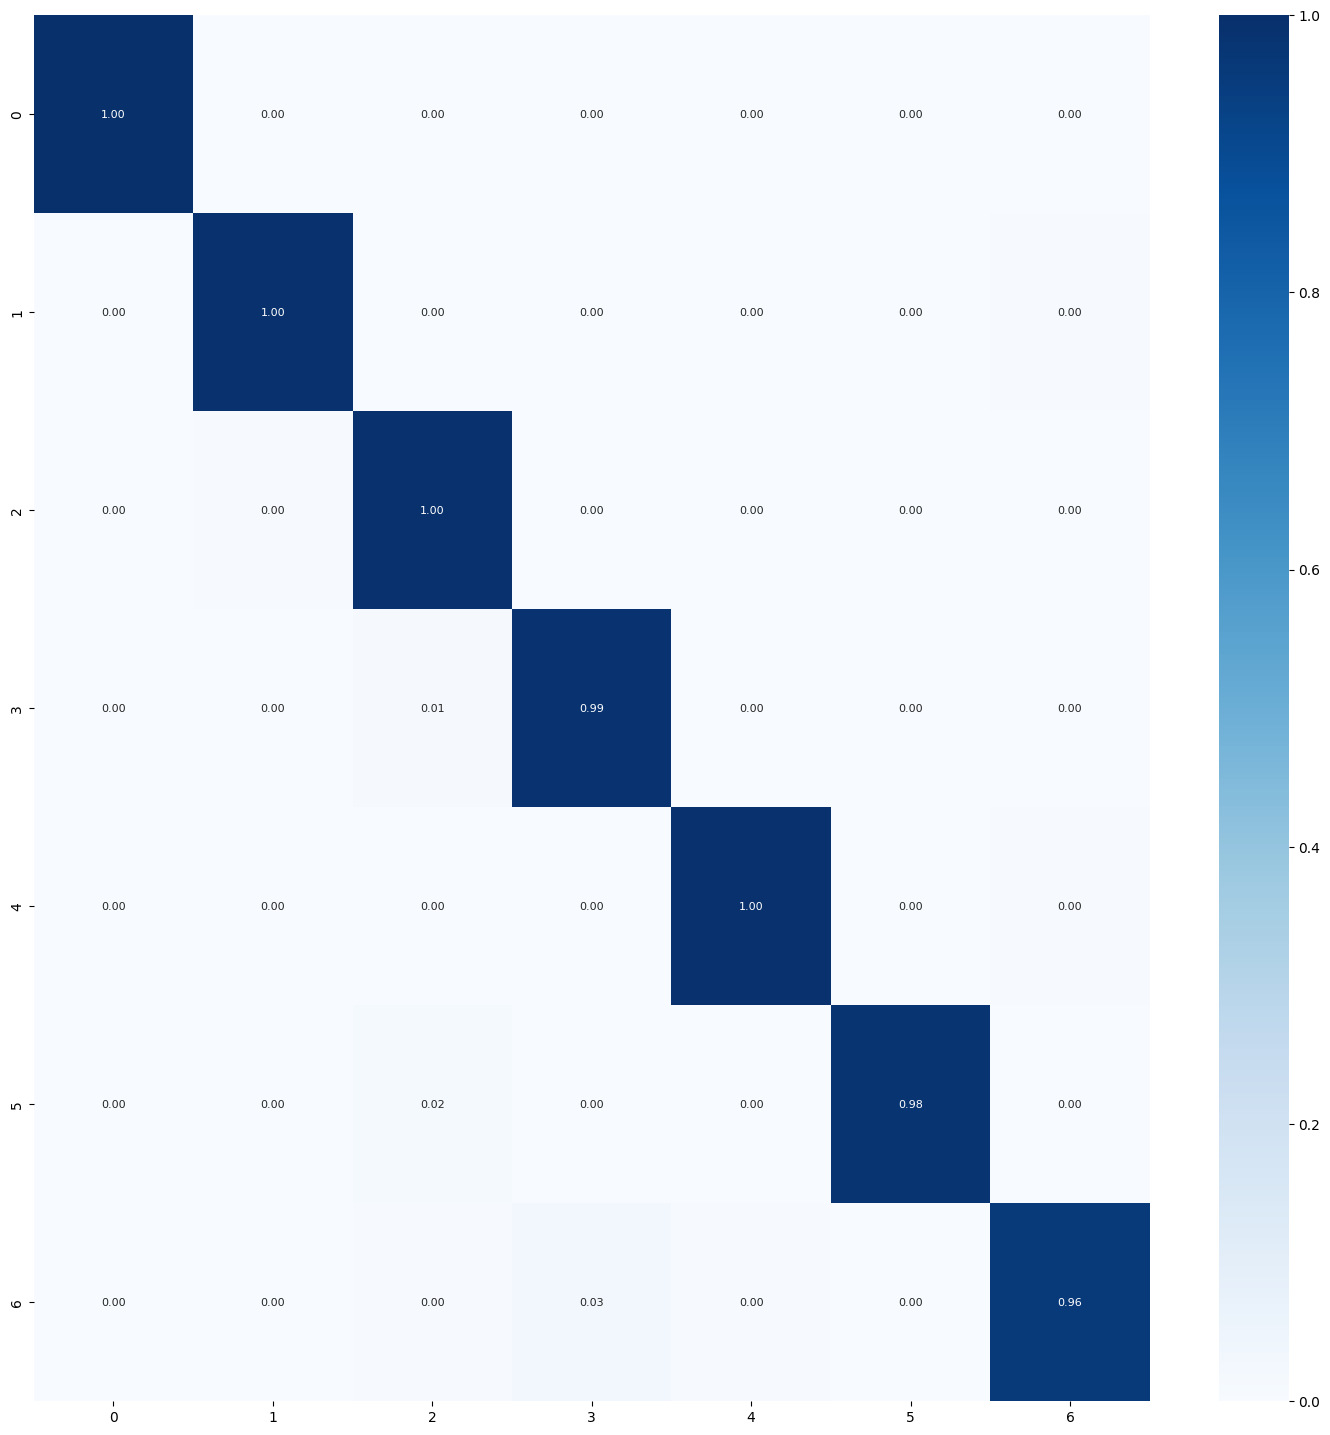


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793703
Trainable params: 2793351
Non-trainable params: 352
Epoch 1/50
229/229 [==============================] - 43s 153ms/step - loss: 1.3804 - accuracy: 0.9429 - val_loss: 2.7640 - val_accuracy: 0.4197
Epoch 2/50
229/229 [==============================] - 35s 154ms/step - loss: 0.9198 - accuracy: 0.9891 - val_loss: 1.0707 - val_accuracy: 0.9403
Epoch 3/50
229/229 [==============================] - 35s 153ms/step - loss: 0.6356 - accuracy: 0.9956 - val_loss: 0.5684 - val_accuracy: 0.9886
Epoch 4/50
229/229 [==============================] - 35s 151ms/step - loss: 0.4390 - accuracy: 0.9945 - val_loss: 0.3912 - val_accuracy: 0.9898
Epoch 5/50
229/229 [==============================] - 39s 169ms/step - loss: 0.3025 - accuracy: 0.9964 - val_loss: 0.2778 - val_accuracy: 0.9905
Epoch 6/50
229/229 [==============================] - 35s 150ms/step - loss: 0.2056 - accuracy: 0.9984 - val_loss: 0.2069 - val_accuracy: 0.9886
Epoch 7/50
229/229

Model and History saved...
230/230 [==============================] - 28s 123ms/step - loss: 0.0891 - accuracy: 0.9963
Train Accuracy: 0.9963265061378479
Train Log Loss: 0.0891205295920372
50/50 [==============================] - 6s 118ms/step - loss: 0.1495 - accuracy: 0.9848
Validation Accuracy: 0.9847618937492371
Validation Log Loss: 0.14951251447200775
50/50 [==============================] - 7s 127ms/step - loss: 0.1471 - accuracy: 0.9816
Test Accuracy: 0.981587290763855
Test Log Loss: 0.14710277318954468
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   1 221   1   0   1   1]
 [  0   0   2 206  12   0   5]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   1   0 223]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   supp

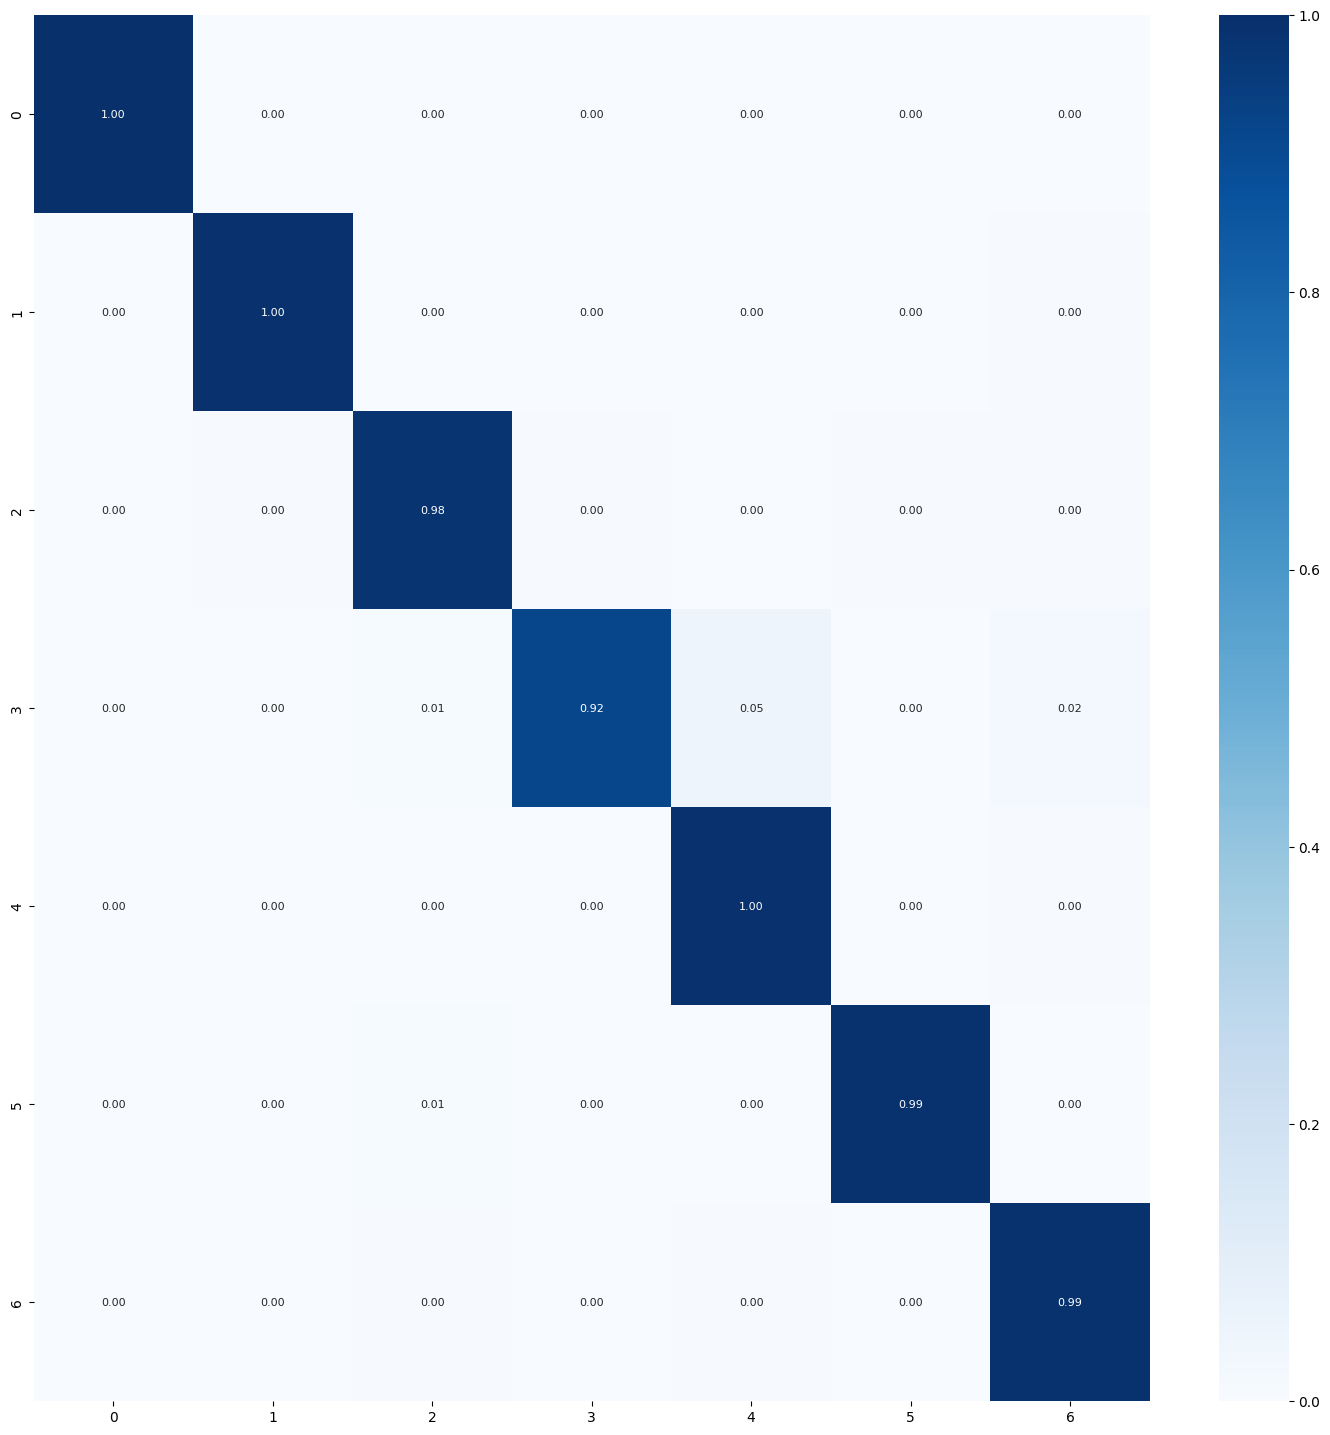


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793703
Trainable params: 2793351
Non-trainable params: 352
Epoch 1/50
229/229 [==============================] - 33s 111ms/step - loss: 1.3645 - accuracy: 0.9498 - val_loss: 4.9570 - val_accuracy: 0.1429
Epoch 2/50
229/229 [==============================] - 34s 150ms/step - loss: 0.9372 - accuracy: 0.9885 - val_loss: 1.0049 - val_accuracy: 0.9060
Epoch 3/50
229/229 [==============================] - 35s 151ms/step - loss: 0.6554 - accuracy: 0.9952 - val_loss: 0.5803 - val_accuracy: 0.9892
Epoch 4/50
229/229 [==============================] - 39s 168ms/step - loss: 0.4543 - accuracy: 0.9956 - val_loss: 0.4037 - val_accuracy: 0.9911
Epoch 5/50
229/229 [==============================] - 35s 153ms/step - loss: 0.3126 - accuracy: 0.9969 - val_loss: 0.2936 - val_accuracy: 0.9892
Epoch 6/50
229/229 [==============================] - 35s 152ms/step - loss: 0.2274 - accuracy: 0.9959 - val_loss: 0.2520 - val_accuracy: 0.9822
Epoch 7/50
229/229

Model and History saved...
230/230 [==============================] - 28s 119ms/step - loss: 0.0747 - accuracy: 0.9995
Train Accuracy: 0.9994558095932007
Train Log Loss: 0.07472363114356995
50/50 [==============================] - 6s 122ms/step - loss: 0.1068 - accuracy: 0.9924
Validation Accuracy: 0.9923809766769409
Validation Log Loss: 0.10675149410963058
50/50 [==============================] - 6s 119ms/step - loss: 0.1124 - accuracy: 0.9898
Test Accuracy: 0.9898412823677063
Test Log Loss: 0.11244869977235794
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 221   3   0   1   0]
 [  0   0   3 221   1   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   0   2   2   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   su

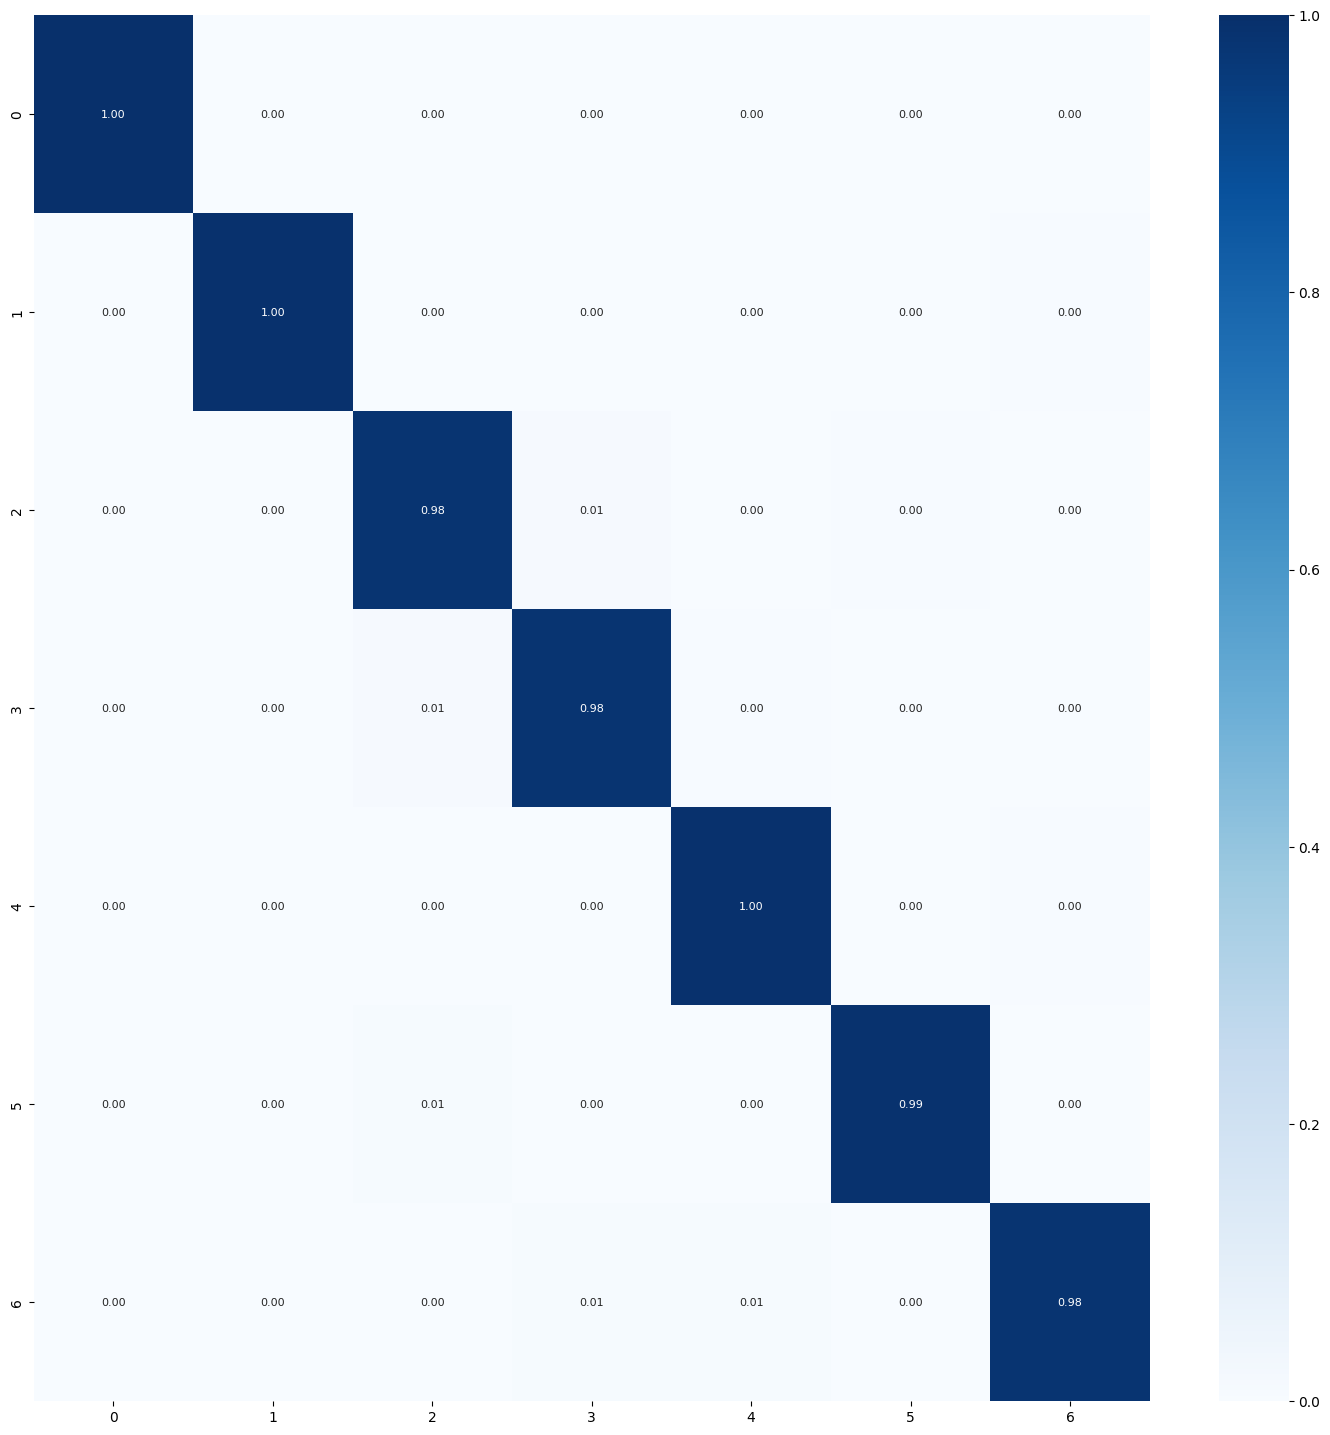


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793703
Trainable params: 2793351
Non-trainable params: 352
Epoch 1/50
229/229 [==============================] - 43s 153ms/step - loss: 1.3751 - accuracy: 0.9459 - val_loss: 2.8590 - val_accuracy: 0.2762
Epoch 2/50
229/229 [==============================] - 34s 149ms/step - loss: 0.9521 - accuracy: 0.9867 - val_loss: 1.0109 - val_accuracy: 0.9530
Epoch 3/50
229/229 [==============================] - 34s 149ms/step - loss: 0.6697 - accuracy: 0.9936 - val_loss: 0.5813 - val_accuracy: 0.9873
Epoch 4/50
229/229 [==============================] - 34s 150ms/step - loss: 0.4610 - accuracy: 0.9959 - val_loss: 0.4091 - val_accuracy: 0.9911
Epoch 5/50
229/229 [==============================] - 34s 149ms/step - loss: 0.3240 - accuracy: 0.9948 - val_loss: 0.3106 - val_accuracy: 0.9898
Epoch 6/50
229/229 [==============================] - 35s 154ms/step - loss: 0.2384 - accuracy: 0.9952 - val_loss: 0.2851 - val_accuracy: 0.9867
Epoch 7/50
229/229

Model and History saved...
230/230 [==============================] - 28s 123ms/step - loss: 0.0691 - accuracy: 0.9986
Train Accuracy: 0.9986394643783569
Train Log Loss: 0.06906823813915253
50/50 [==============================] - 6s 121ms/step - loss: 0.1129 - accuracy: 0.9892
Validation Accuracy: 0.9892063736915588
Validation Log Loss: 0.11293826252222061
50/50 [==============================] - 6s 123ms/step - loss: 0.1208 - accuracy: 0.9905
Test Accuracy: 0.9904761910438538
Test Log Loss: 0.1207549050450325
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 221   3   0   0   0   1]
 [  0   0 224   1   0   0   0]
 [  0   0   3 221   0   0   1]
 [  0   0   0   0 224   0   1]
 [  0   0   3   0   0 222   0]
 [  0   0   1   0   1   0 223]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   sup

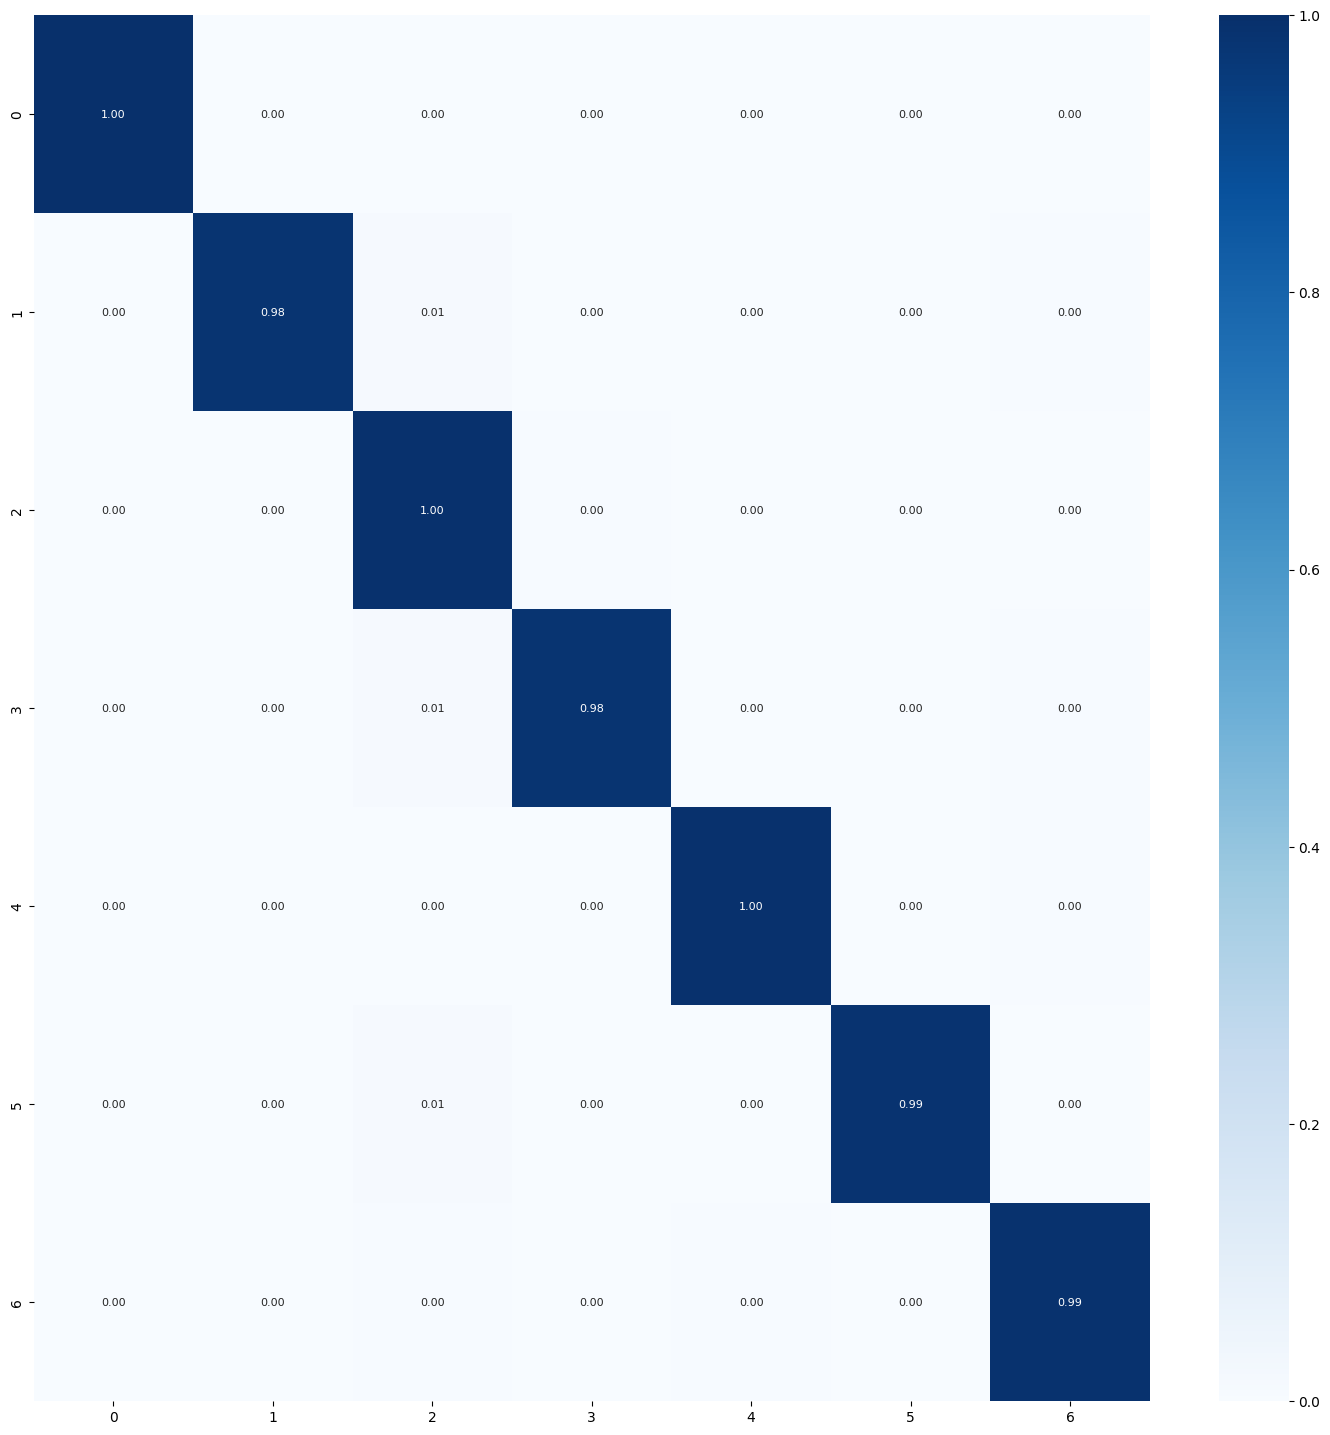


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793703
Trainable params: 2793351
Non-trainable params: 352
Epoch 1/50
229/229 [==============================] - 43s 156ms/step - loss: 1.4382 - accuracy: 0.9298 - val_loss: 3.1252 - val_accuracy: 0.2978
Epoch 2/50
229/229 [==============================] - 35s 150ms/step - loss: 0.9771 - accuracy: 0.9900 - val_loss: 1.2192 - val_accuracy: 0.9143
Epoch 3/50
229/229 [==============================] - 35s 152ms/step - loss: 0.7002 - accuracy: 0.9936 - val_loss: 0.6235 - val_accuracy: 0.9873
Epoch 4/50
229/229 [==============================] - 40s 174ms/step - loss: 0.5051 - accuracy: 0.9939 - val_loss: 0.4501 - val_accuracy: 0.9898
Epoch 5/50
229/229 [==============================] - 35s 153ms/step - loss: 0.3425 - accuracy: 0.9985 - val_loss: 0.3104 - val_accuracy: 0.9879
Epoch 6/50
229/229 [==============================] - 35s 152ms/step - loss: 0.2650 - accuracy: 0.9937 - val_loss: 0.2507 - val_accuracy: 0.9911
Epoch 7/50
229/229

Model and History saved...
230/230 [==============================] - 29s 126ms/step - loss: 0.0571 - accuracy: 0.9990
Train Accuracy: 0.9990476369857788
Train Log Loss: 0.057116635143756866
50/50 [==============================] - 6s 122ms/step - loss: 0.1043 - accuracy: 0.9905
Validation Accuracy: 0.9904761910438538
Validation Log Loss: 0.10428731888532639
50/50 [==============================] - 7s 132ms/step - loss: 0.0985 - accuracy: 0.9898
Test Accuracy: 0.9898412823677063
Test Log Loss: 0.09850922971963882
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 223   1   0   0   0   1]
 [  0   1 224   0   0   0   0]
 [  0   0   4 217   1   0   3]
 [  0   0   1   0 223   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   0   0   1   0 224]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   s

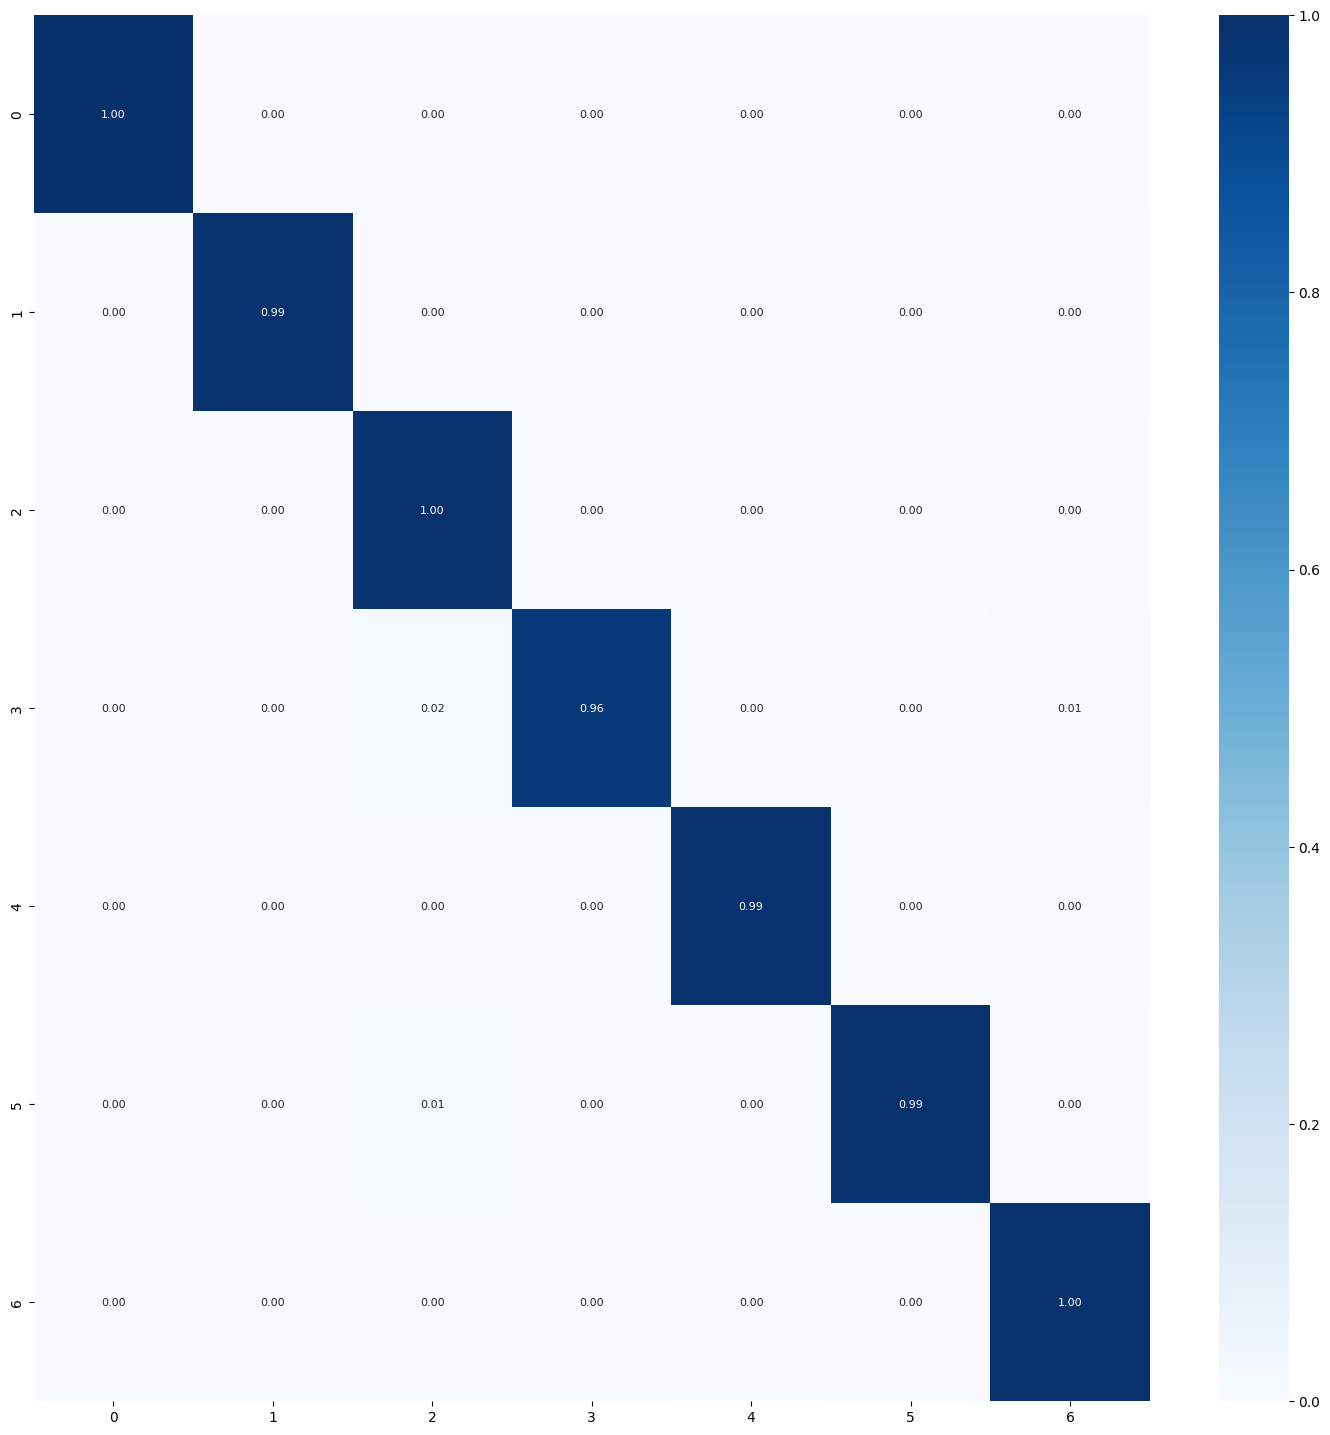

Average training accuracy in 5-fold: 0.9992347598075867
Average validation precision in 5-fold: 0.9935238122940063
/nTest Metrics
test_acc_list: [0.9879364967346191, 0.981587290763855, 0.9898412823677063, 0.9904761910438538, 0.9898412823677063]
Average Test Accuracy with 5-fold: 0.987936508655548
test_loss_list: [0.15990641713142395, 0.14710277318954468, 0.11244869977235794, 0.1207549050450325, 0.09850922971963882]
Average Test Log Loss with 5-fold: 0.12774440497159958

Precision List: [0.9881266221391852, 0.982093157550632, 0.9898719225398267, 0.9907202388618318, 0.9900471436629664]
Average Precision List with 5-fold: 0.9881718169508884
Recall List: [0.987936507936508, 0.9815873015873018, 0.9898412698412699, 0.9904761904761905, 0.9898412698412699]
Average Recall List with 5-fold: 0.987936507936508
F1 Score List: [0.9879416736409077, 0.9814841765451737, 0.9898482273088869, 0.990519748264883, 0.9898508928730146]
Average F1 Score List with 5-fold: 0.9879289437265731

Metrics List Store



In [18]:
%%time

num_classes = 7
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/8
name_save_model: fusion_cnn_basic_15008
Found 8400 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2793768
Trainable params: 2793416
Non-trainable params: 352
Epoch 1/50
262/262 [==============================] - 51s 164ms/step - loss: 1.3792 - accuracy: 0.9411 - val_loss: 2.7543 - val_accuracy: 0.3856
Epoch 2/50
262/262 [==============================] - 43s 164ms/step - loss: 0.9159 - accuracy: 0.9895 - val_loss: 1.2714 - val_accuracy: 0.8539
Epoch 3/50
262/262 [==============================] - 42s 159ms/step - loss: 0.6147 - accuracy: 0.9940 - val_loss: 0.5469 - val_accuracy: 0.9861
Epoch 4/50
262/262 [==============================] - 37s 143ms/step - loss: 0.4080 - accurac

Model and History saved...
263/263 [==============================] - 34s 129ms/step - loss: 0.0939 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.09386992454528809
57/57 [==============================] - 8s 130ms/step - loss: 0.1324 - accuracy: 0.9922
Validation Accuracy: 0.992222249507904
Validation Log Loss: 0.13244637846946716
57/57 [==============================] - 8s 131ms/step - loss: 0.1228 - accuracy: 0.9939
Test Accuracy: 0.9938889145851135
Test Log Loss: 0.1227673664689064
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 223   1   0   0   0   0   1]
 [  0   0 223   0   1   0   1   0]
 [  0   0   0 224   0   0   0   1]
 [  0   0   1   0 223   0   0   1]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   0   0   0   1   0 224]]
True labels: 1800
Predicted labels: len(predicted_labels

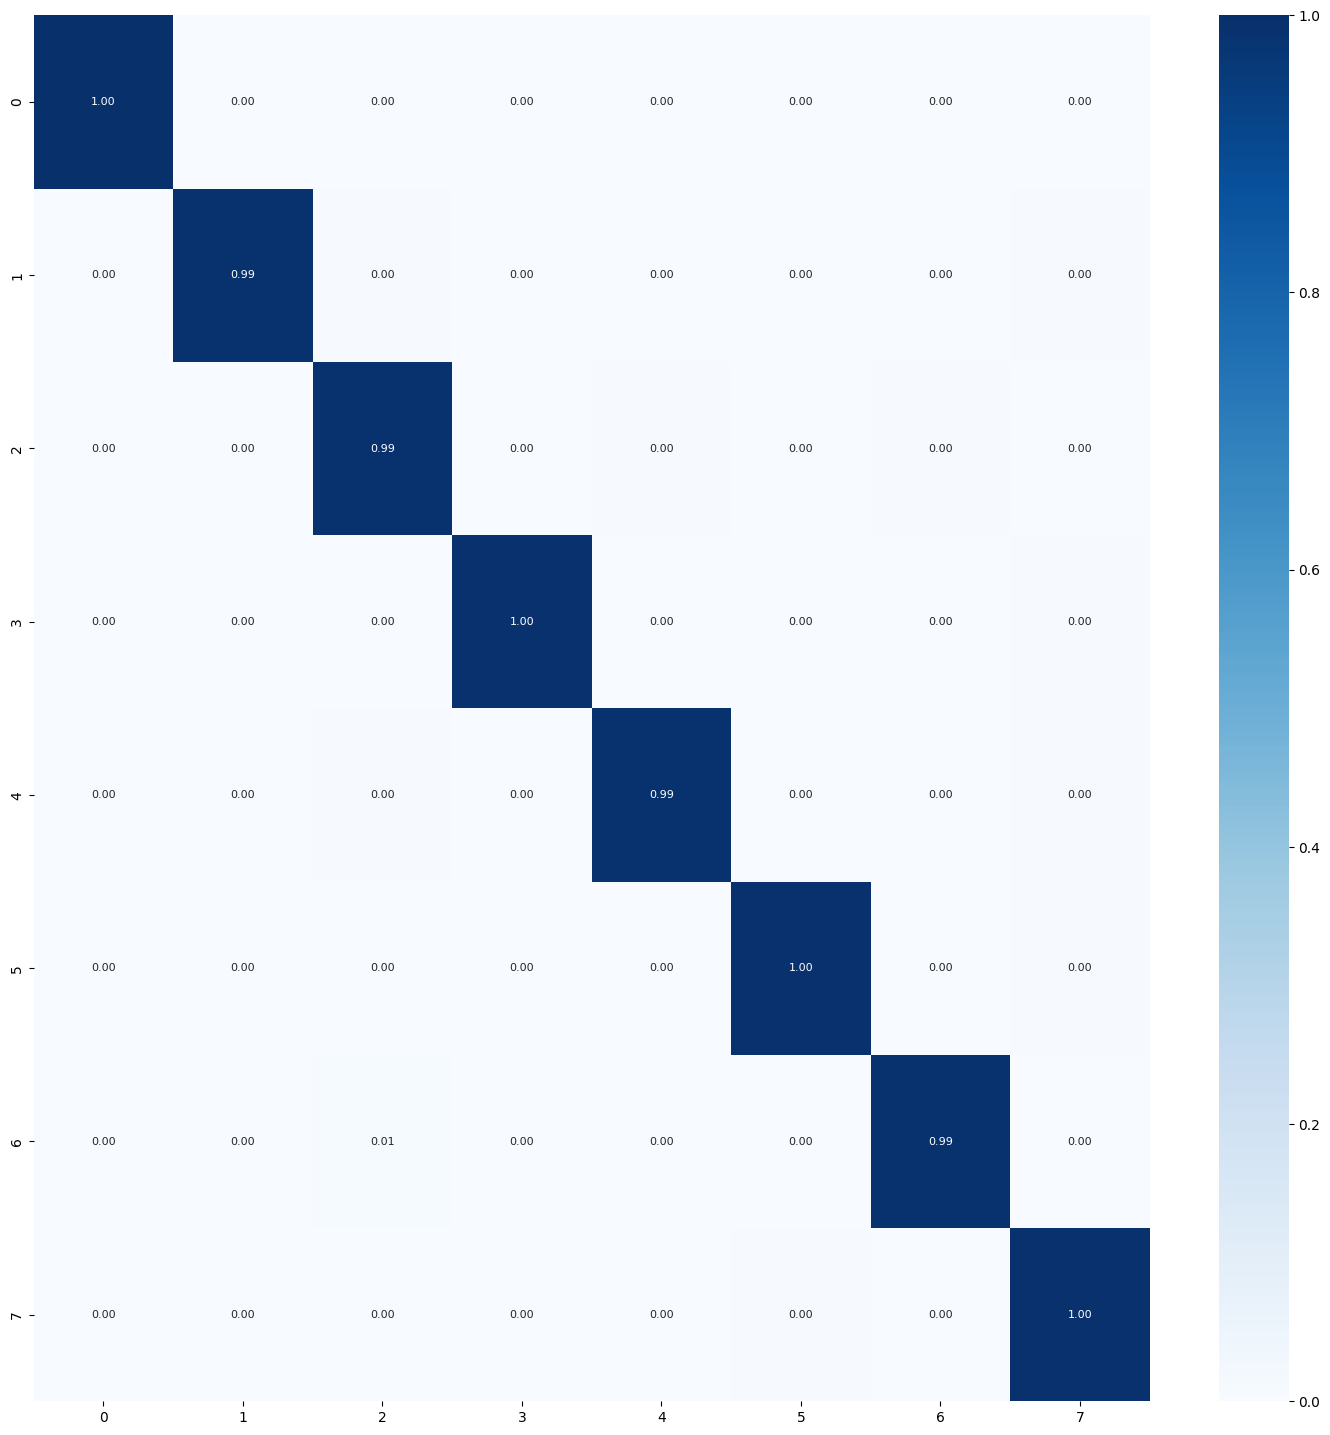


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793768
Trainable params: 2793416
Non-trainable params: 352
Epoch 1/50
262/262 [==============================] - 51s 163ms/step - loss: 1.4037 - accuracy: 0.9410 - val_loss: 2.5061 - val_accuracy: 0.4656
Epoch 2/50
262/262 [==============================] - 41s 158ms/step - loss: 0.9423 - accuracy: 0.9897 - val_loss: 0.9918 - val_accuracy: 0.9211
Epoch 3/50
262/262 [==============================] - 44s 168ms/step - loss: 0.6527 - accuracy: 0.9941 - val_loss: 0.5544 - val_accuracy: 0.9900
Epoch 4/50
262/262 [==============================] - 43s 164ms/step - loss: 0.4475 - accuracy: 0.9949 - val_loss: 0.3784 - val_accuracy: 0.9922
Epoch 5/50
262/262 [==============================] - 42s 159ms/step - loss: 0.3045 - accuracy: 0.9956 - val_loss: 0.2743 - val_accuracy: 0.9922
Epoch 6/50
262/262 [==============================] - 43s 164ms/step - loss: 0.2183 - accuracy: 0.9961 - val_loss: 0.2033 - val_accuracy: 0.9922
Epoch 7/50
262/262

Model and History saved...
263/263 [==============================] - 35s 132ms/step - loss: 0.1107 - accuracy: 0.9983
Train Accuracy: 0.9983333349227905
Train Log Loss: 0.1106681227684021
57/57 [==============================] - 8s 130ms/step - loss: 0.1469 - accuracy: 0.9906
Validation Accuracy: 0.9905555844306946
Validation Log Loss: 0.1469031125307083
57/57 [==============================] - 8s 130ms/step - loss: 0.1521 - accuracy: 0.9917
Test Accuracy: 0.9916666746139526
Test Log Loss: 0.15208208560943604
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   1 218   0   5   0   1   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   1   0 223   1   0   0]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   1   0   0 222   0]
 [  0   0   0   0   0   1   0 224]]
True labels: 1800
Predicted labels: len(predicted_labels

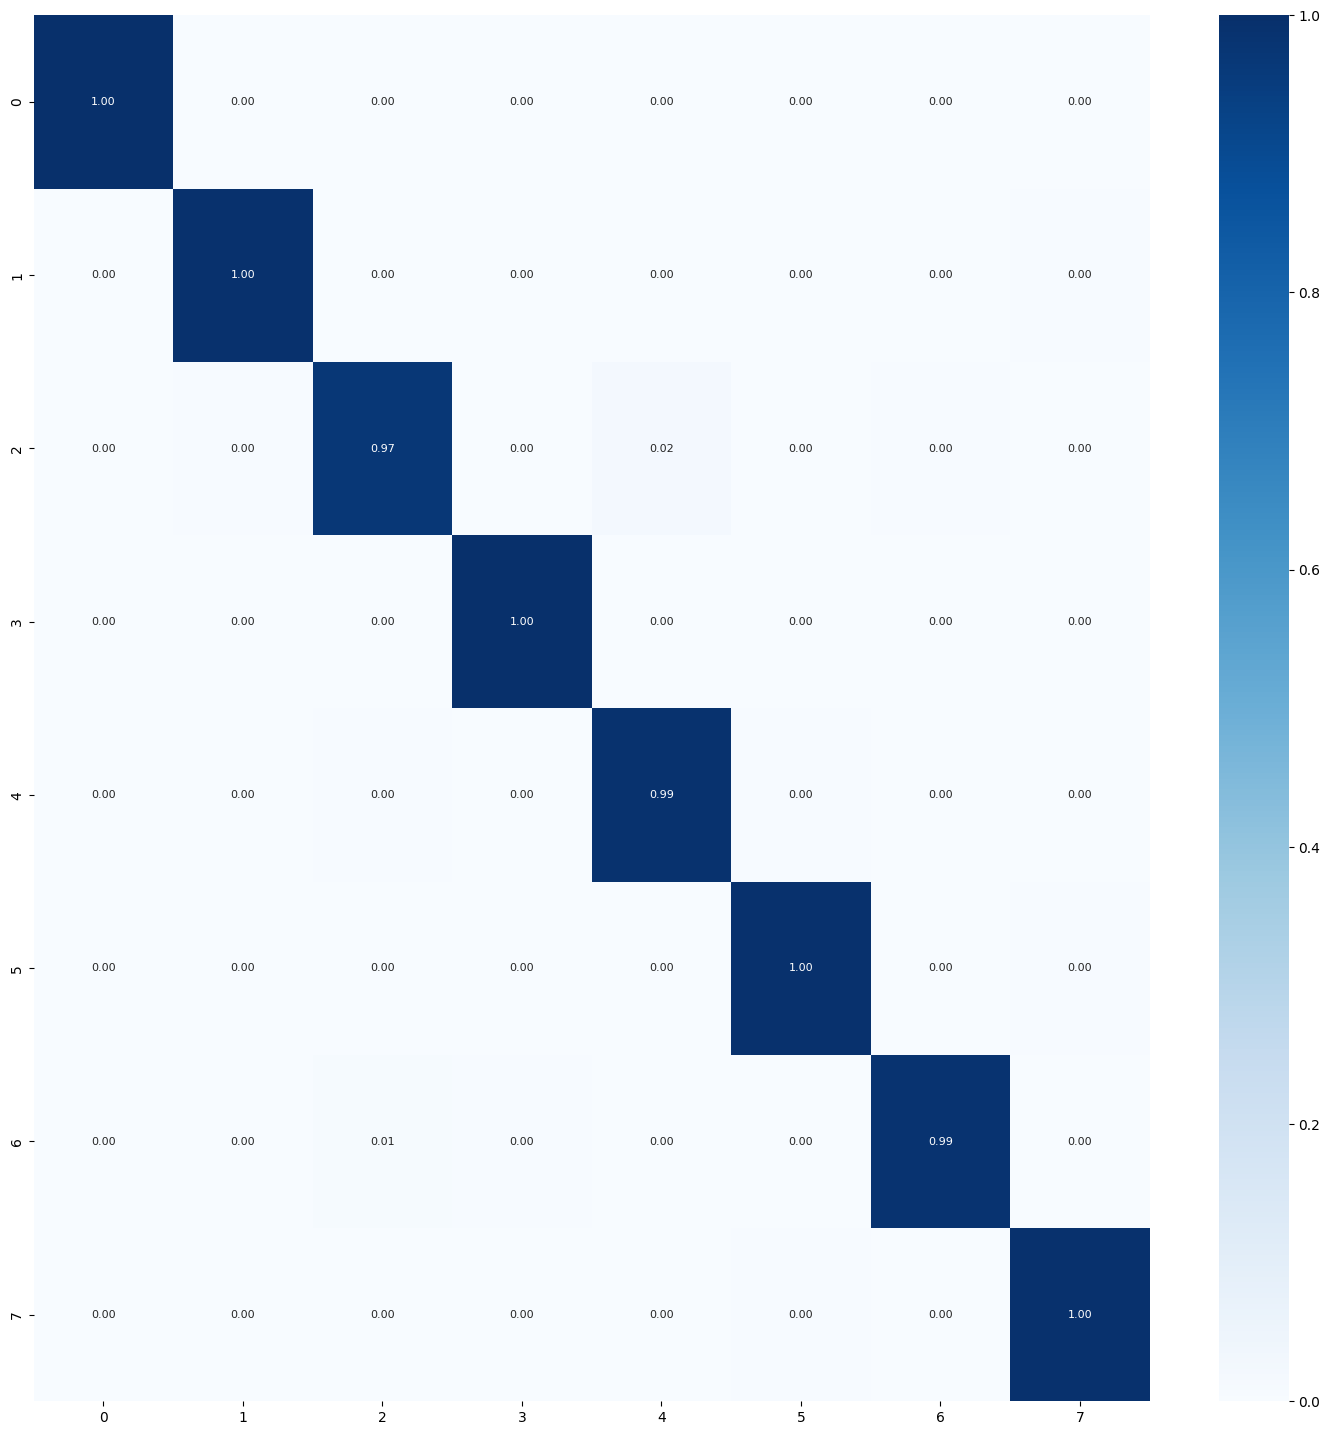


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793768
Trainable params: 2793416
Non-trainable params: 352
Epoch 1/50
262/262 [==============================] - 55s 182ms/step - loss: 1.4343 - accuracy: 0.9299 - val_loss: 2.7783 - val_accuracy: 0.2622
Epoch 2/50
262/262 [==============================] - 44s 169ms/step - loss: 0.9664 - accuracy: 0.9869 - val_loss: 0.9298 - val_accuracy: 0.9822
Epoch 3/50
262/262 [==============================] - 43s 163ms/step - loss: 0.6752 - accuracy: 0.9944 - val_loss: 0.5803 - val_accuracy: 0.9894
Epoch 4/50
262/262 [==============================] - 42s 162ms/step - loss: 0.4668 - accuracy: 0.9957 - val_loss: 0.4010 - val_accuracy: 0.9900
Epoch 5/50
262/262 [==============================] - 43s 163ms/step - loss: 0.3178 - accuracy: 0.9955 - val_loss: 0.2881 - val_accuracy: 0.9900
Epoch 6/50
262/262 [==============================] - 42s 160ms/step - loss: 0.2178 - accuracy: 0.9969 - val_loss: 0.2312 - val_accuracy: 0.9828
Epoch 7/50
262/262

Model and History saved...
263/263 [==============================] - 33s 126ms/step - loss: 0.1018 - accuracy: 0.9993
Train Accuracy: 0.9992856979370117
Train Log Loss: 0.10181562602519989
57/57 [==============================] - 7s 125ms/step - loss: 0.1347 - accuracy: 0.9933
Validation Accuracy: 0.9933333396911621
Validation Log Loss: 0.13467873632907867
57/57 [==============================] - 7s 125ms/step - loss: 0.1361 - accuracy: 0.9917
Test Accuracy: 0.9916666746139526
Test Log Loss: 0.1361316591501236
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   1 222   0   0   1   0   1]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 220   2   0   3]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   2   0 222]]
True labels: 1800
Predicted labels: len(predicted_label

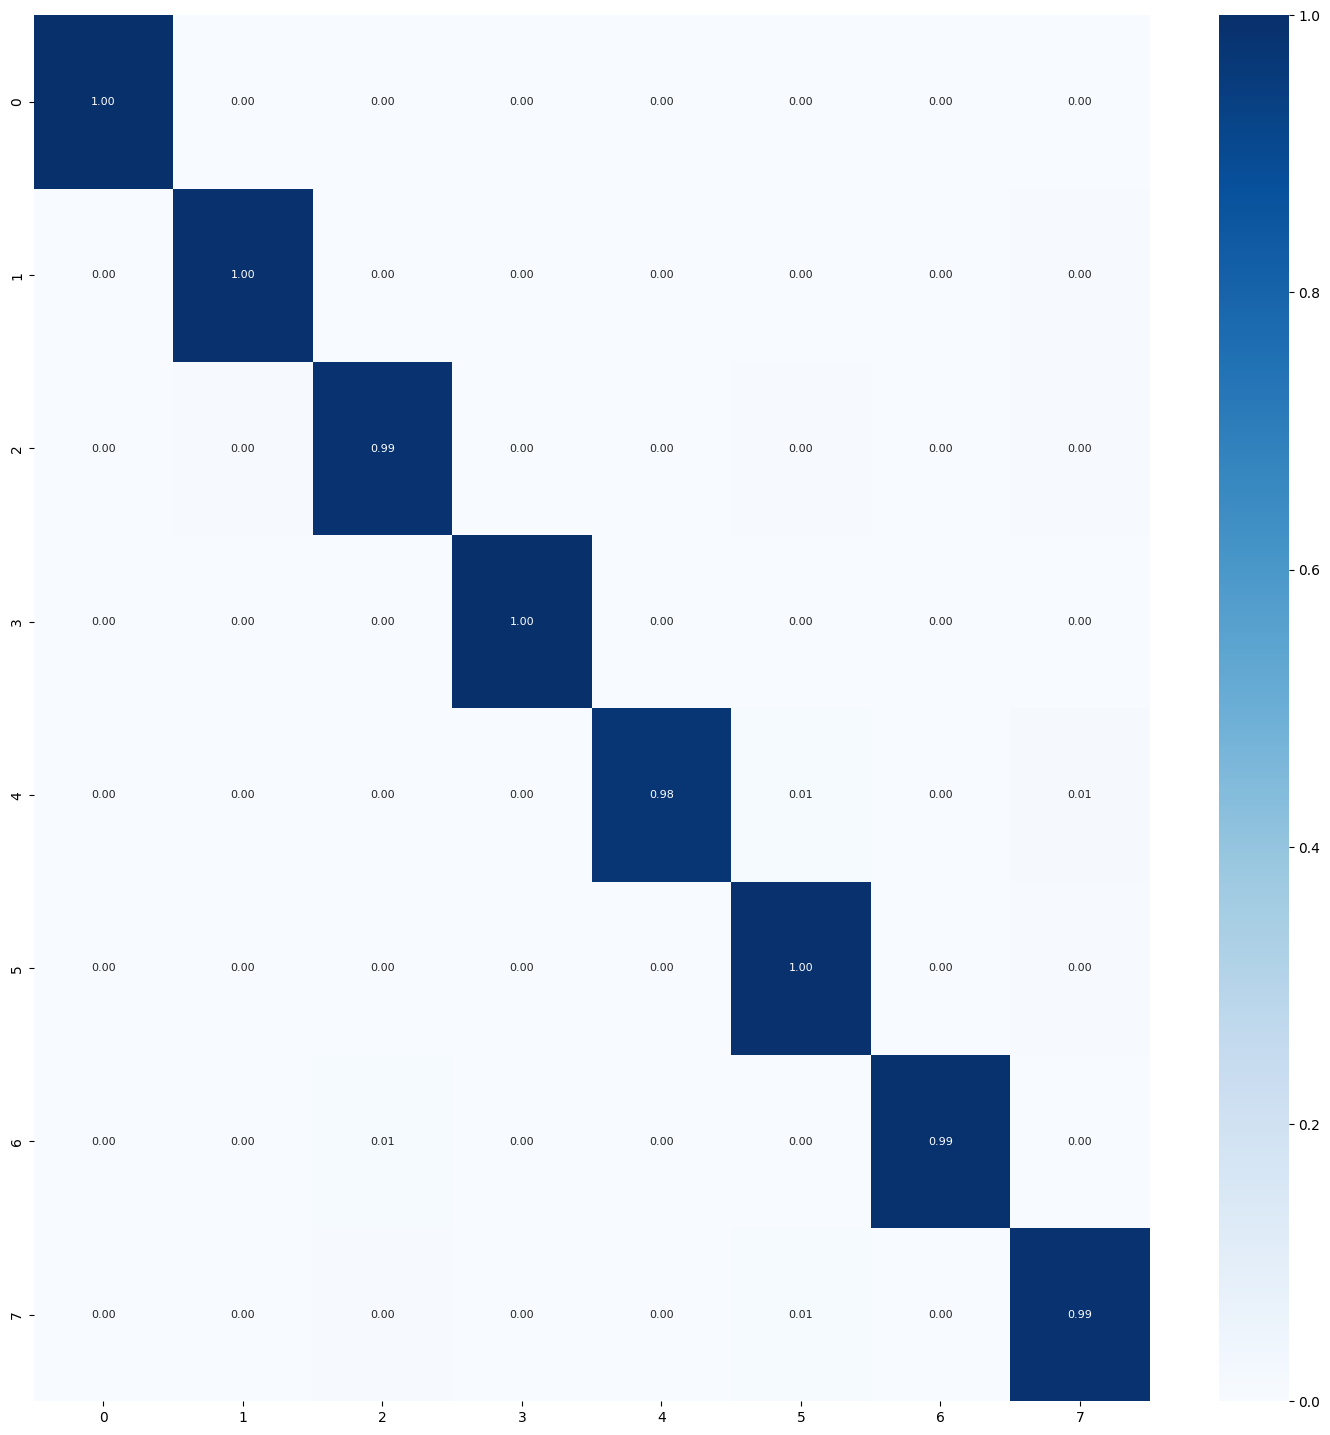


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793768
Trainable params: 2793416
Non-trainable params: 352
Epoch 1/50
262/262 [==============================] - 50s 160ms/step - loss: 1.4012 - accuracy: 0.9393 - val_loss: 2.2888 - val_accuracy: 0.4444
Epoch 2/50
262/262 [==============================] - 49s 188ms/step - loss: 0.9452 - accuracy: 0.9902 - val_loss: 0.9697 - val_accuracy: 0.9228
Epoch 3/50
262/262 [==============================] - 51s 194ms/step - loss: 0.6662 - accuracy: 0.9922 - val_loss: 0.5832 - val_accuracy: 0.9861
Epoch 4/50
262/262 [==============================] - 49s 187ms/step - loss: 0.4541 - accuracy: 0.9957 - val_loss: 0.3865 - val_accuracy: 0.9911
Epoch 5/50
262/262 [==============================] - 53s 203ms/step - loss: 0.3107 - accuracy: 0.9961 - val_loss: 0.2842 - val_accuracy: 0.9917
Epoch 6/50
262/262 [==============================] - 41s 155ms/step - loss: 0.2181 - accuracy: 0.9953 - val_loss: 0.2236 - val_accuracy: 0.9844
Epoch 7/50
262/262

Model and History saved...
263/263 [==============================] - 25s 93ms/step - loss: 0.0769 - accuracy: 0.9980
Train Accuracy: 0.9979761838912964
Train Log Loss: 0.0769163966178894
57/57 [==============================] - 7s 120ms/step - loss: 0.1065 - accuracy: 0.9917
Validation Accuracy: 0.9916666746139526
Validation Log Loss: 0.10654478520154953
57/57 [==============================] - 7s 122ms/step - loss: 0.1099 - accuracy: 0.9900
Test Accuracy: 0.9900000095367432
Test Log Loss: 0.109888955950737
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 222   0   0   0   0   3]
 [  0   0   0 225   0   0   0   0]
 [  0   0   7   0 216   0   1   1]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   0   0   0   2   0 223]]
True labels: 1800
Predicted labels: len(predicted_labels)


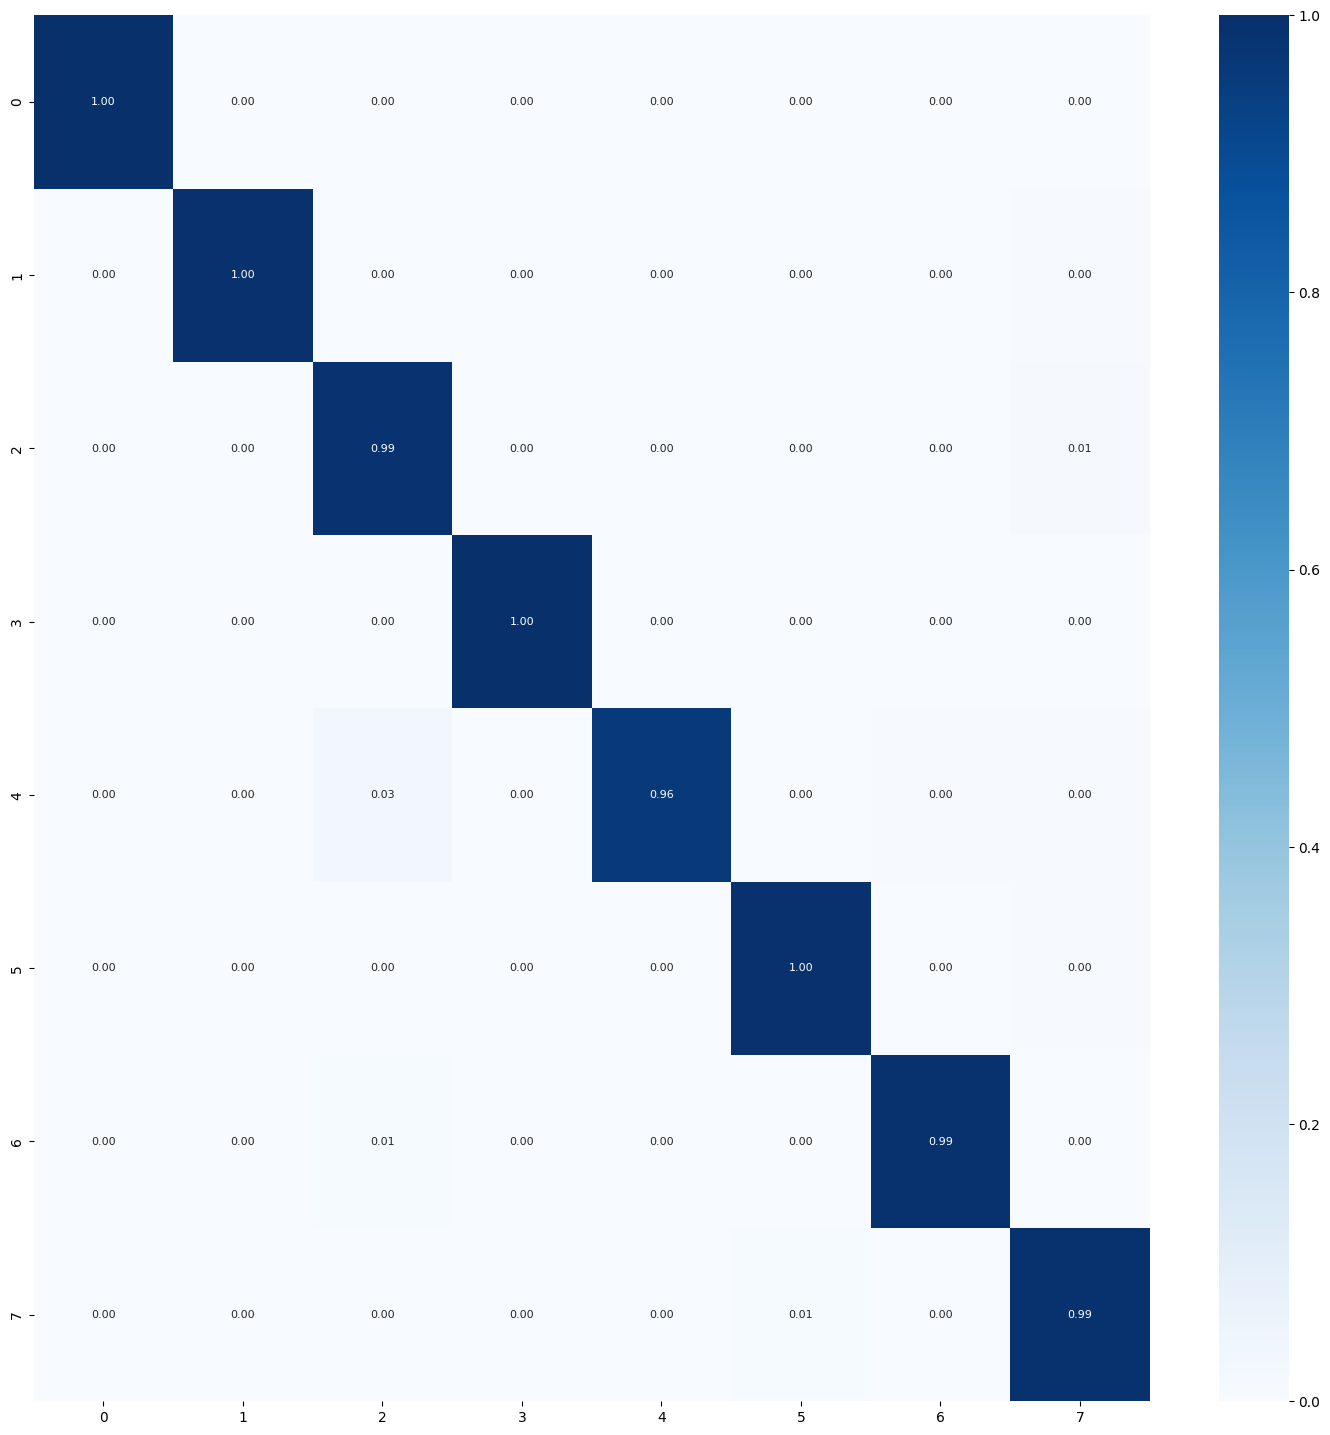


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793768
Trainable params: 2793416
Non-trainable params: 352
Epoch 1/50
262/262 [==============================] - 50s 157ms/step - loss: 1.4296 - accuracy: 0.9325 - val_loss: 2.5607 - val_accuracy: 0.4544
Epoch 2/50
262/262 [==============================] - 40s 154ms/step - loss: 0.9540 - accuracy: 0.9902 - val_loss: 0.9248 - val_accuracy: 0.9644
Epoch 3/50
262/262 [==============================] - 42s 162ms/step - loss: 0.6711 - accuracy: 0.9922 - val_loss: 0.5759 - val_accuracy: 0.9883
Epoch 4/50
262/262 [==============================] - 47s 179ms/step - loss: 0.4587 - accuracy: 0.9963 - val_loss: 0.4081 - val_accuracy: 0.9878
Epoch 5/50
262/262 [==============================] - 46s 174ms/step - loss: 0.3166 - accuracy: 0.9957 - val_loss: 0.2854 - val_accuracy: 0.9900
Epoch 6/50
262/262 [==============================] - 47s 178ms/step - loss: 0.2189 - accuracy: 0.9968 - val_loss: 0.2191 - val_accuracy: 0.9889
Epoch 7/50
262/262

Model and History saved...
263/263 [==============================] - 33s 126ms/step - loss: 0.0977 - accuracy: 0.9960
Train Accuracy: 0.9959523677825928
Train Log Loss: 0.09772016108036041
57/57 [==============================] - 7s 125ms/step - loss: 0.1456 - accuracy: 0.9867
Validation Accuracy: 0.9866666793823242
Validation Log Loss: 0.14555208384990692
57/57 [==============================] - 8s 131ms/step - loss: 0.1336 - accuracy: 0.9844
Test Accuracy: 0.9844444394111633
Test Log Loss: 0.13361404836177826
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 218   1   0   0   1   5]
 [  0   0   0 225   0   0   0   0]
 [  0   0  12   0 209   2   0   2]
 [  0   0   0   0   0 224   0   1]
 [  0   0   1   0   0   0 224   0]
 [  0   0   0   1   0   1   0 223]]
True labels: 1800
Predicted labels: len(predicted_labe

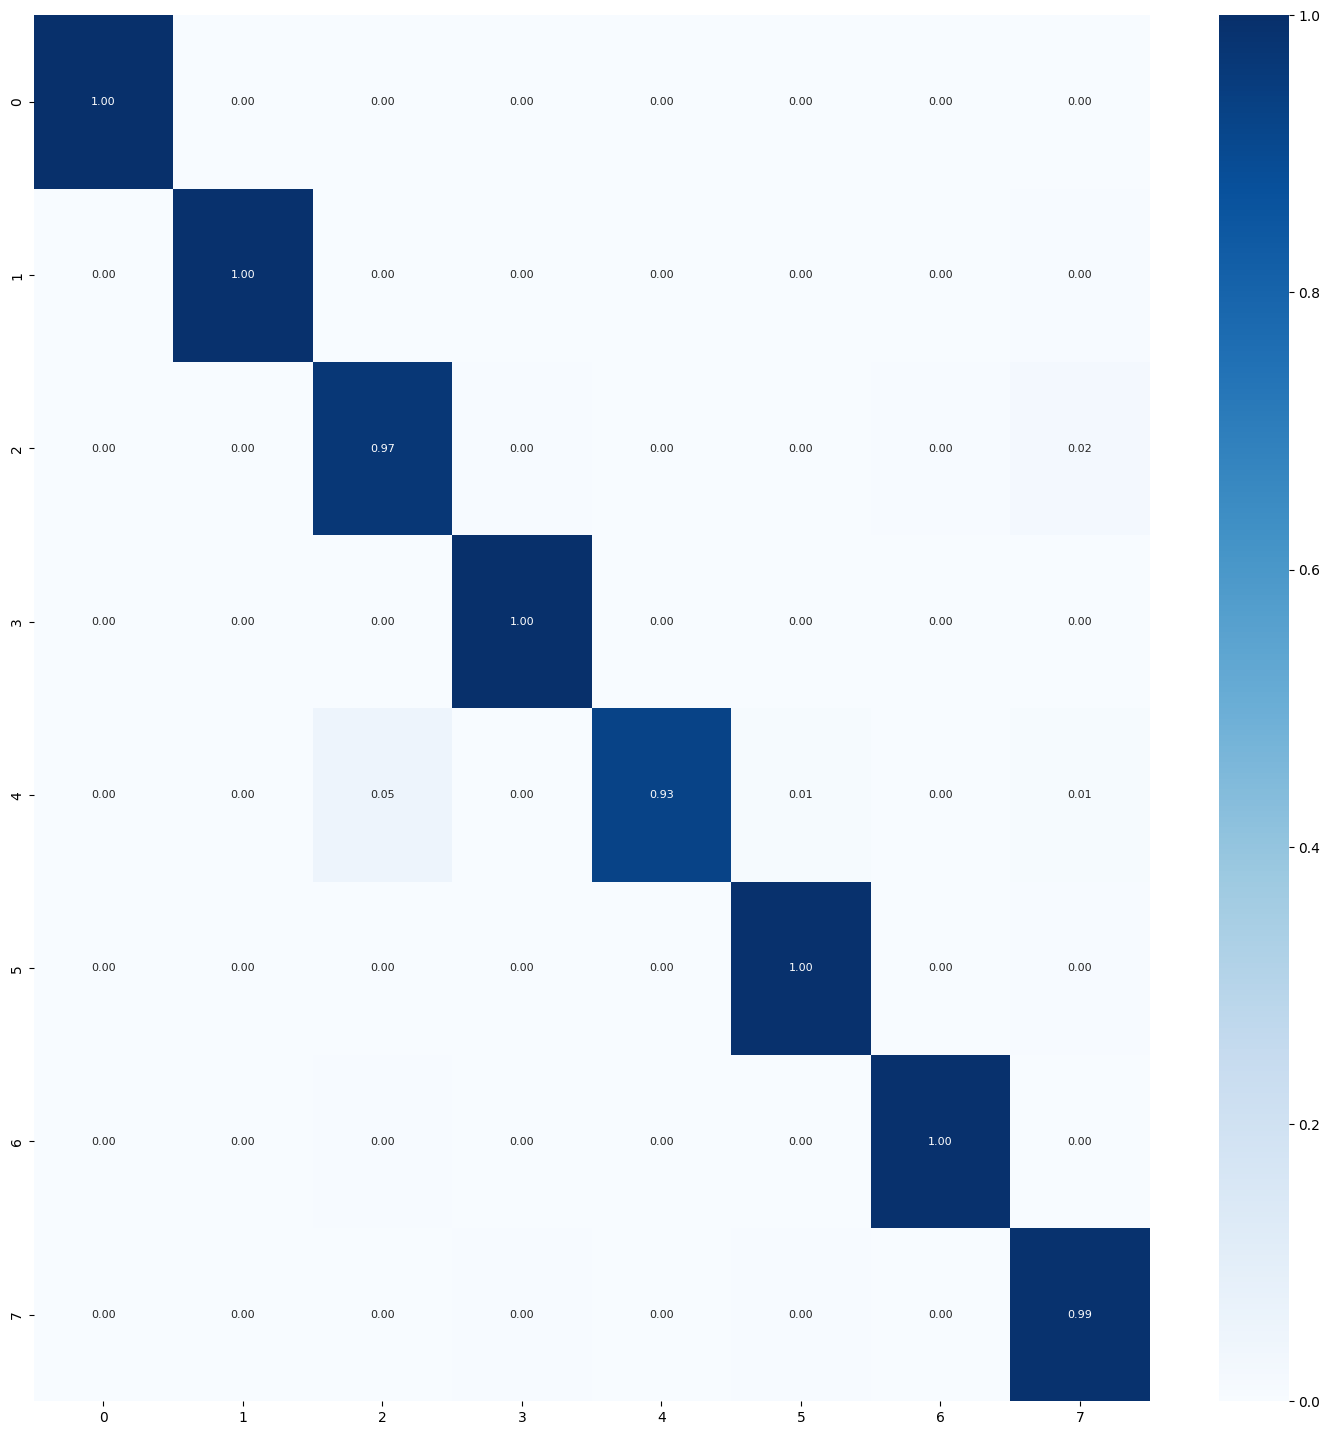

Average training accuracy in 5-fold: 0.9990917921066285
Average validation precision in 5-fold: 0.9944444417953491
/nTest Metrics
test_acc_list: [0.9938889145851135, 0.9916666746139526, 0.9916666746139526, 0.9900000095367432, 0.9844444394111633]
Average Test Accuracy with 5-fold: 0.9903333425521851
test_loss_list: [0.1227673664689064, 0.15208208560943604, 0.1361316591501236, 0.109888955950737, 0.13361404836177826]
Average Test Log Loss with 5-fold: 0.13089682310819625

Precision List: [0.9939327473879265, 0.9916803589528278, 0.9917590464516459, 0.9901905305550133, 0.9848073705140202]
Average Precision List with 5-fold: 0.9904740107722867
Recall List: [0.9938888888888889, 0.9916666666666667, 0.9916666666666667, 0.99, 0.9844444444444445]
Average Recall List with 5-fold: 0.9903333333333334
F1 Score List: [0.993898650689854, 0.9916539820663011, 0.9916798215940057, 0.9900117914021345, 0.9844072521660644]
Average F1 Score List with 5-fold: 0.990330299583672

Metrics List Store

test_acc_list

In [19]:
%%time

num_classes = 8
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/9
name_save_model: fusion_cnn_basic_15009
Found 9450 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2793833
Trainable params: 2793481
Non-trainable params: 352
Epoch 1/50
295/295 [==============================] - 59s 172ms/step - loss: 1.3968 - accuracy: 0.9378 - val_loss: 3.1075 - val_accuracy: 0.3580
Epoch 2/50
295/295 [==============================] - 50s 168ms/step - loss: 0.9084 - accuracy: 0.9889 - val_loss: 0.7942 - val_accuracy: 0.9867
Epoch 3/50
295/295 [==============================] - 49s 167ms/step - loss: 0.5945 - accuracy: 0.9942 - val_loss: 0.5083 - val_accuracy: 0.9886
Epoch 4/50
295/295 [==============================] - 49s 166ms/step - loss: 0.39

Model and History saved...
296/296 [==============================] - 40s 135ms/step - loss: 0.1120 - accuracy: 0.9948
Train Accuracy: 0.9948148131370544
Train Log Loss: 0.11198820918798447
64/64 [==============================] - 9s 137ms/step - loss: 0.1533 - accuracy: 0.9886
Validation Accuracy: 0.9886419773101807
Validation Log Loss: 0.15325164794921875
64/64 [==============================] - 9s 137ms/step - loss: 0.1534 - accuracy: 0.9891
Test Accuracy: 0.9891358017921448
Test Log Loss: 0.15337595343589783
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 222   0   0   3   0   0]
 [  0   0   0   1 224   0   0   0   0]
 [  0   0   0   1   0 223   1   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0   0   2   0   0   0 223   0]
 [  0  

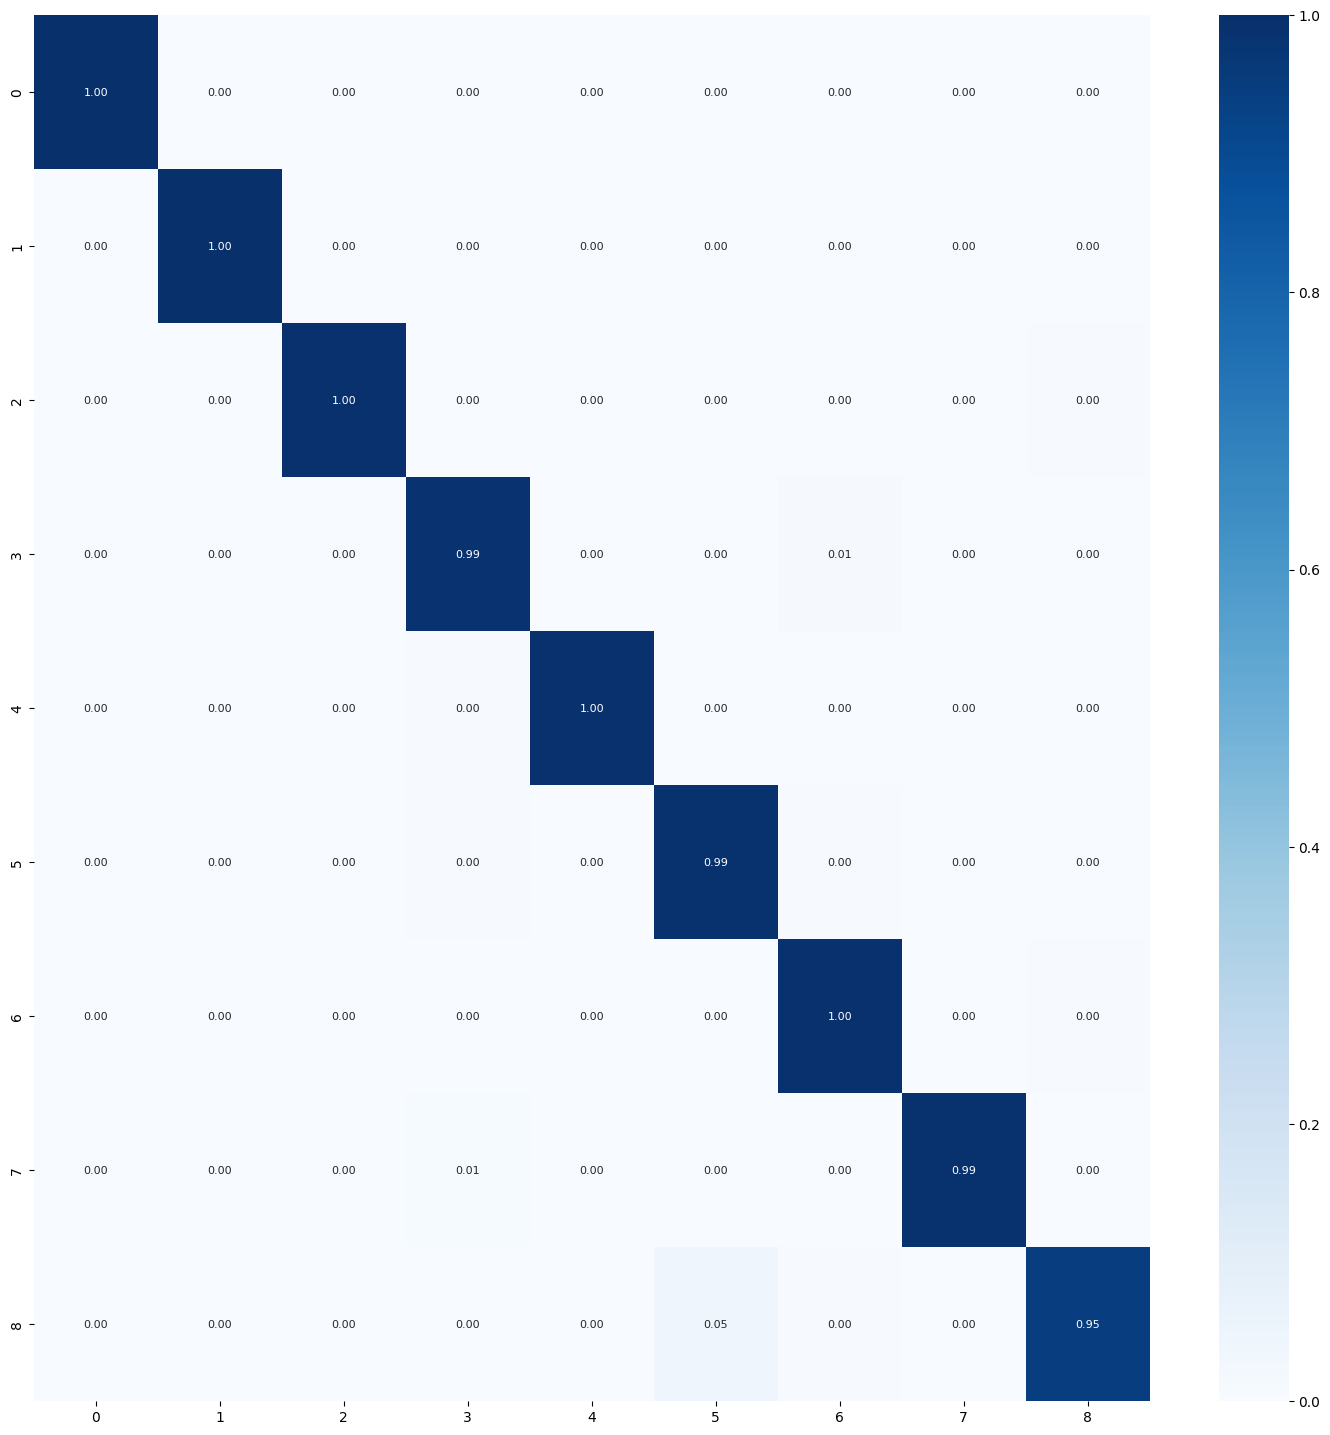


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793833
Trainable params: 2793481
Non-trainable params: 352
Epoch 1/50
295/295 [==============================] - 58s 168ms/step - loss: 1.3815 - accuracy: 0.9434 - val_loss: 2.7261 - val_accuracy: 0.4074
Epoch 2/50
295/295 [==============================] - 50s 169ms/step - loss: 0.9100 - accuracy: 0.9907 - val_loss: 0.7986 - val_accuracy: 0.9847
Epoch 3/50
295/295 [==============================] - 49s 167ms/step - loss: 0.6031 - accuracy: 0.9953 - val_loss: 0.5008 - val_accuracy: 0.9916
Epoch 4/50
295/295 [==============================] - 48s 164ms/step - loss: 0.3931 - accuracy: 0.9956 - val_loss: 0.3443 - val_accuracy: 0.9886
Epoch 5/50
295/295 [==============================] - 48s 163ms/step - loss: 0.2754 - accuracy: 0.9943 - val_loss: 0.2488 - val_accuracy: 0.9891
Epoch 6/50
295/295 [==============================] - 50s 170ms/step - loss: 0.1833 - accuracy: 0.9962 - val_loss: 0.1794 - val_accuracy: 0.9921
Epoch 7/50
295/295

Model and History saved...
296/296 [==============================] - 37s 125ms/step - loss: 0.0746 - accuracy: 0.9997
Train Accuracy: 0.9996825456619263
Train Log Loss: 0.07457596063613892
64/64 [==============================] - 8s 128ms/step - loss: 0.1045 - accuracy: 0.9946
Validation Accuracy: 0.9945679306983948
Validation Log Loss: 0.1044672280550003
64/64 [==============================] - 8s 123ms/step - loss: 0.0982 - accuracy: 0.9931
Test Accuracy: 0.9930863976478577
Test Log Loss: 0.09824543446302414
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 223   2   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   4   0 220   0   0   1]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0   0   2   1   0   0 222   0]
 [  0   

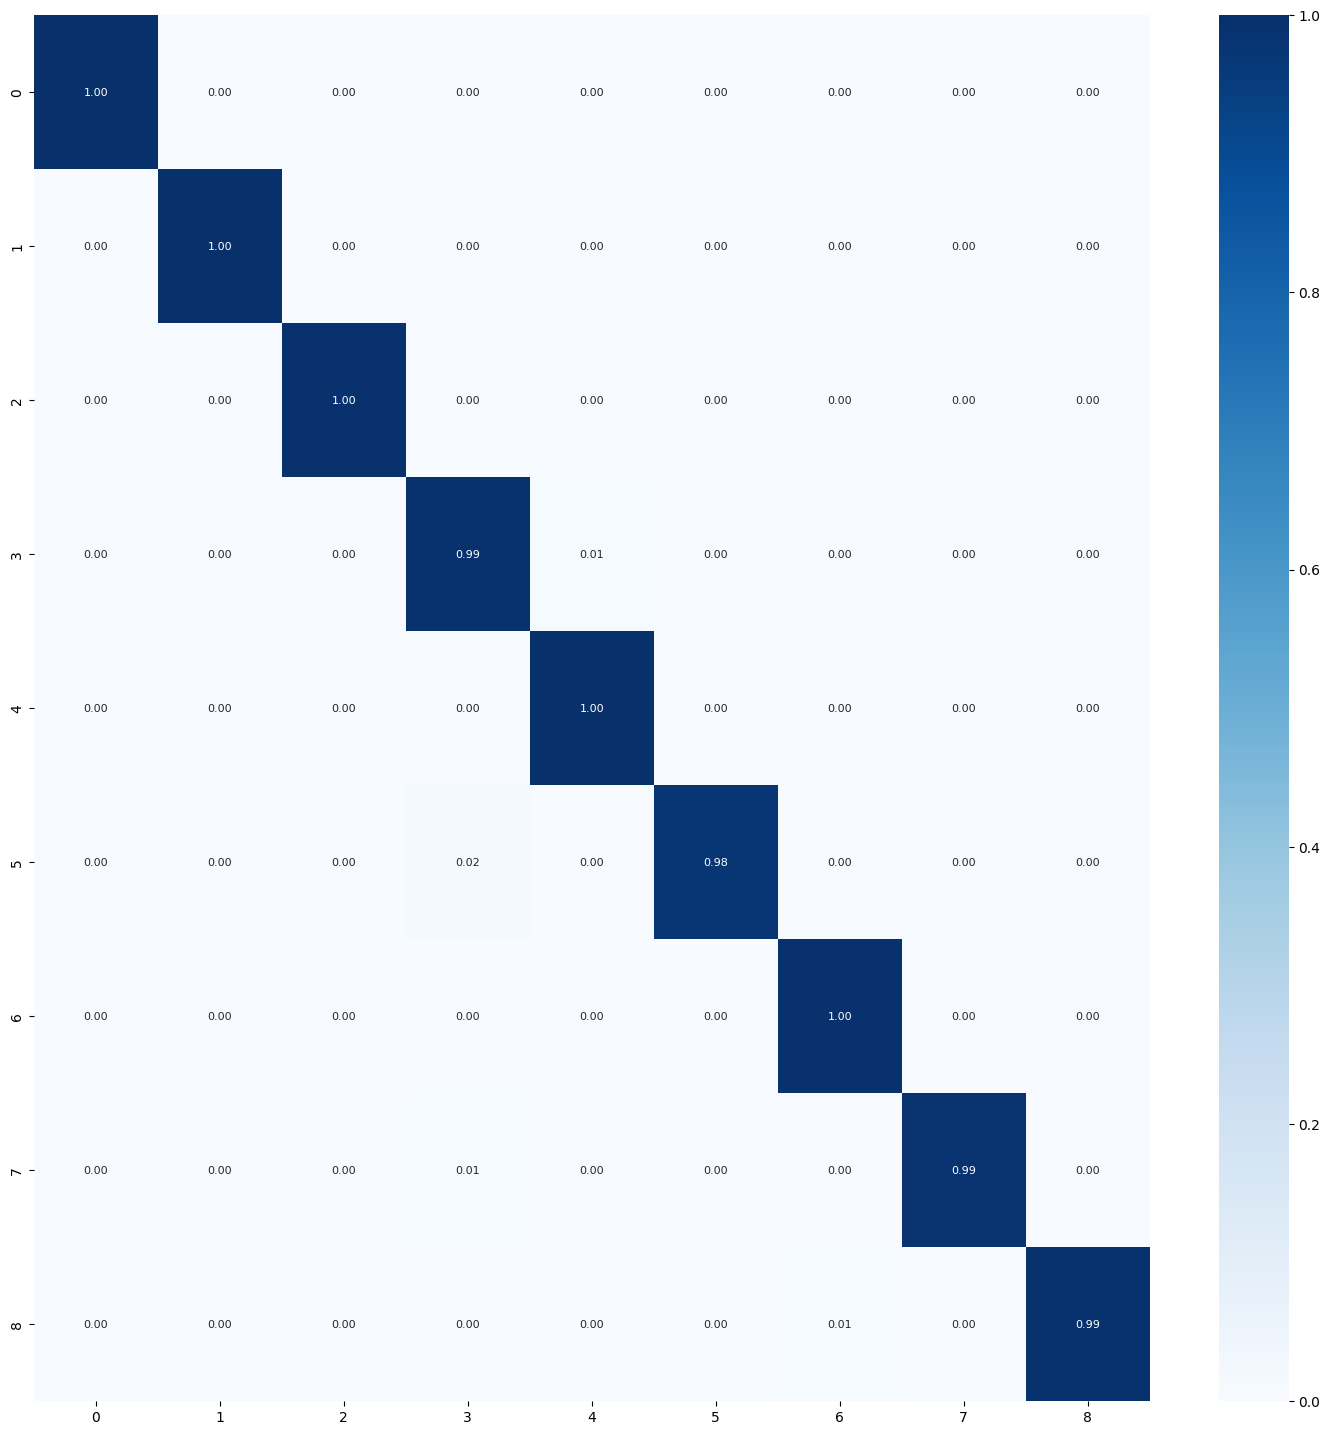


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793833
Trainable params: 2793481
Non-trainable params: 352
Epoch 1/50
295/295 [==============================] - 55s 161ms/step - loss: 1.4006 - accuracy: 0.9355 - val_loss: 2.9685 - val_accuracy: 0.4356
Epoch 2/50
295/295 [==============================] - 46s 157ms/step - loss: 0.9161 - accuracy: 0.9867 - val_loss: 0.8393 - val_accuracy: 0.9837
Epoch 3/50
295/295 [==============================] - 44s 150ms/step - loss: 0.5995 - accuracy: 0.9944 - val_loss: 0.5042 - val_accuracy: 0.9901
Epoch 4/50
295/295 [==============================] - 45s 153ms/step - loss: 0.3950 - accuracy: 0.9937 - val_loss: 0.3460 - val_accuracy: 0.9911
Epoch 5/50
295/295 [==============================] - 46s 155ms/step - loss: 0.2596 - accuracy: 0.9951 - val_loss: 0.2297 - val_accuracy: 0.9941
Epoch 6/50
295/295 [==============================] - 48s 162ms/step - loss: 0.1744 - accuracy: 0.9969 - val_loss: 0.1877 - val_accuracy: 0.9901
Epoch 7/50
295/295

Model and History saved...
296/296 [==============================] - 37s 125ms/step - loss: 0.0916 - accuracy: 0.9995
Train Accuracy: 0.9994708895683289
Train Log Loss: 0.09157201647758484
64/64 [==============================] - 8s 126ms/step - loss: 0.1134 - accuracy: 0.9951
Validation Accuracy: 0.9950617551803589
Validation Log Loss: 0.11343584954738617
64/64 [==============================] - 8s 129ms/step - loss: 0.1270 - accuracy: 0.9931
Test Accuracy: 0.9930863976478577
Test Log Loss: 0.12695001065731049
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 221   3   1   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   1   0 221   1   0   2]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0   0   2   0   0   0 223   0]
 [  0  

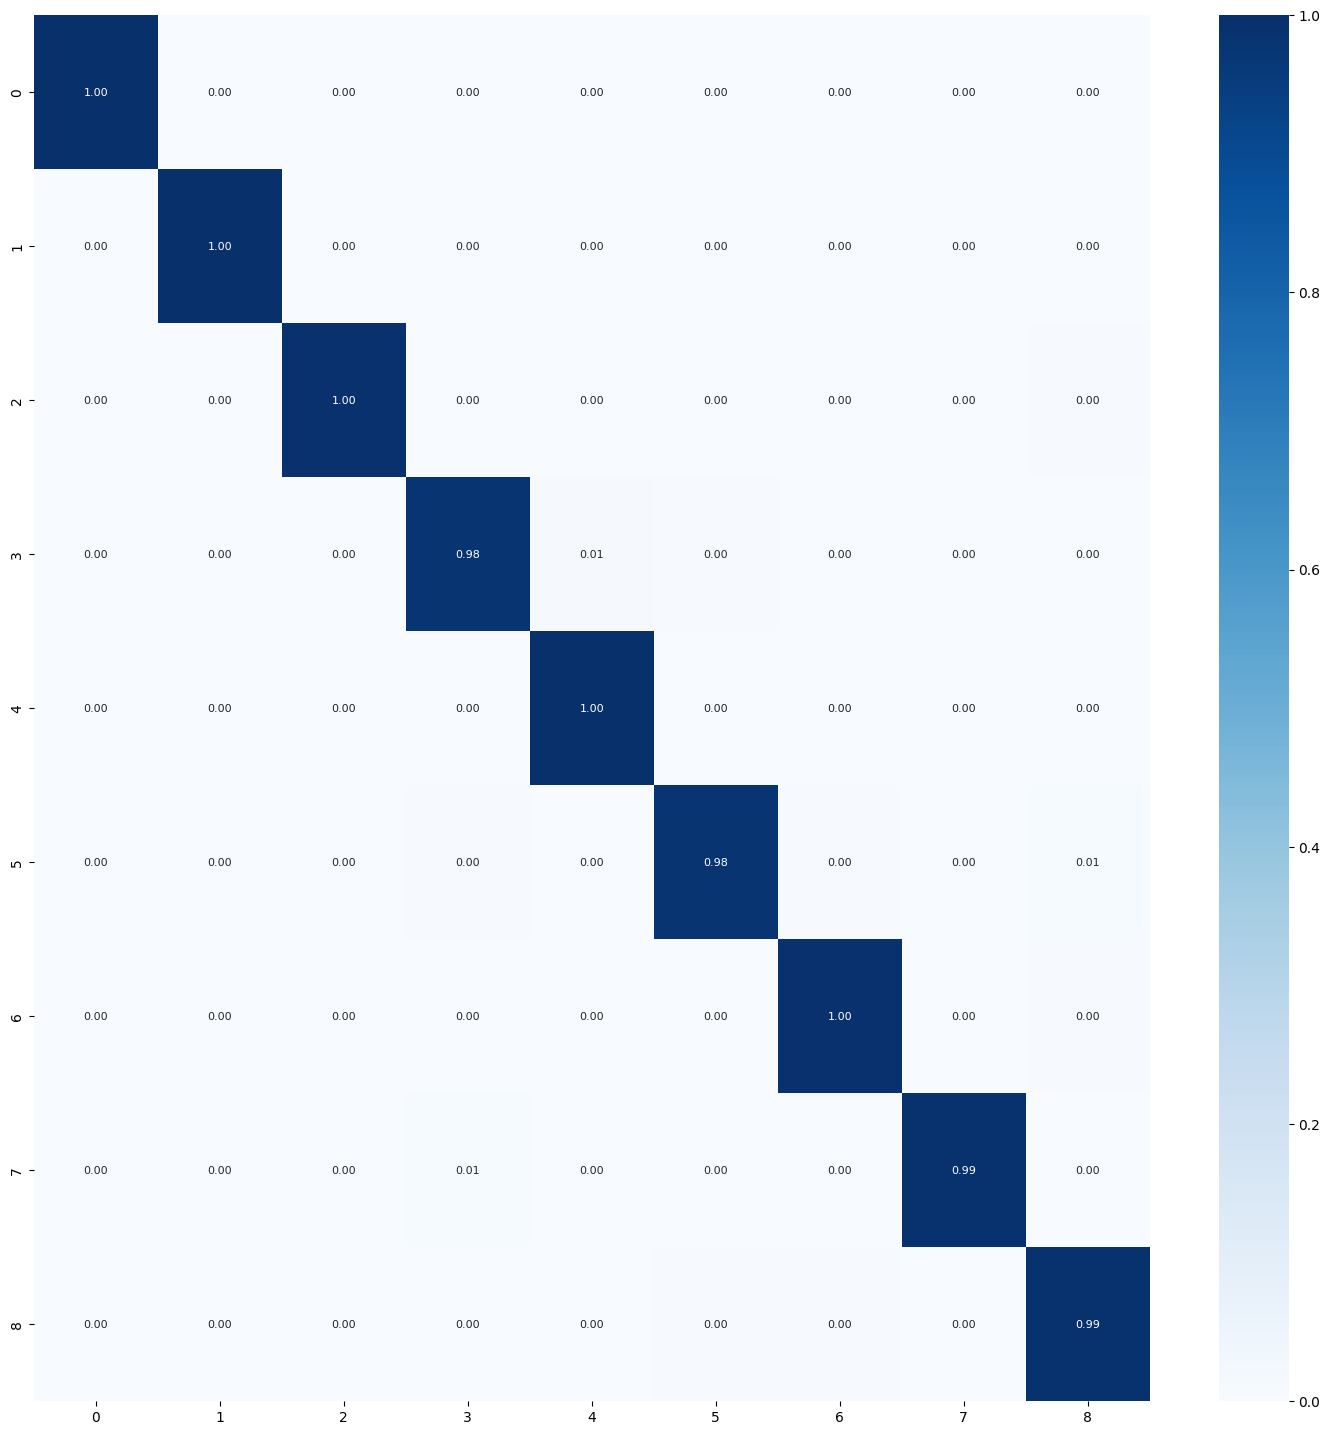


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793833
Trainable params: 2793481
Non-trainable params: 352
Epoch 1/50
295/295 [==============================] - 57s 165ms/step - loss: 1.4084 - accuracy: 0.9371 - val_loss: 2.3249 - val_accuracy: 0.3620
Epoch 2/50
295/295 [==============================] - 46s 155ms/step - loss: 0.9066 - accuracy: 0.9856 - val_loss: 0.7981 - val_accuracy: 0.9862
Epoch 3/50
295/295 [==============================] - 48s 161ms/step - loss: 0.5891 - accuracy: 0.9941 - val_loss: 0.4808 - val_accuracy: 0.9911
Epoch 4/50
295/295 [==============================] - 46s 155ms/step - loss: 0.3864 - accuracy: 0.9939 - val_loss: 0.3272 - val_accuracy: 0.9906
Epoch 5/50
295/295 [==============================] - 45s 154ms/step - loss: 0.2602 - accuracy: 0.9952 - val_loss: 0.2222 - val_accuracy: 0.9931
Epoch 6/50
295/295 [==============================] - 48s 162ms/step - loss: 0.1669 - accuracy: 0.9978 - val_loss: 0.1713 - val_accuracy: 0.9867
Epoch 7/50
295/295

Model and History saved...
296/296 [==============================] - 39s 133ms/step - loss: 0.0875 - accuracy: 0.9993
Train Accuracy: 0.9992592334747314
Train Log Loss: 0.08753011375665665
64/64 [==============================] - 8s 128ms/step - loss: 0.1235 - accuracy: 0.9936
Validation Accuracy: 0.9935802221298218
Validation Log Loss: 0.12354354560375214
64/64 [==============================] - 8s 127ms/step - loss: 0.1217 - accuracy: 0.9916
Test Accuracy: 0.9916049242019653
Test Log Loss: 0.12173335254192352
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 224   1   0   0   0   0]
 [  0   0   0   1 224   0   0   0   0]
 [  0   0   0   3   0 216   2   0   4]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0   0   2   0   0   0 223   0]
 [  0  

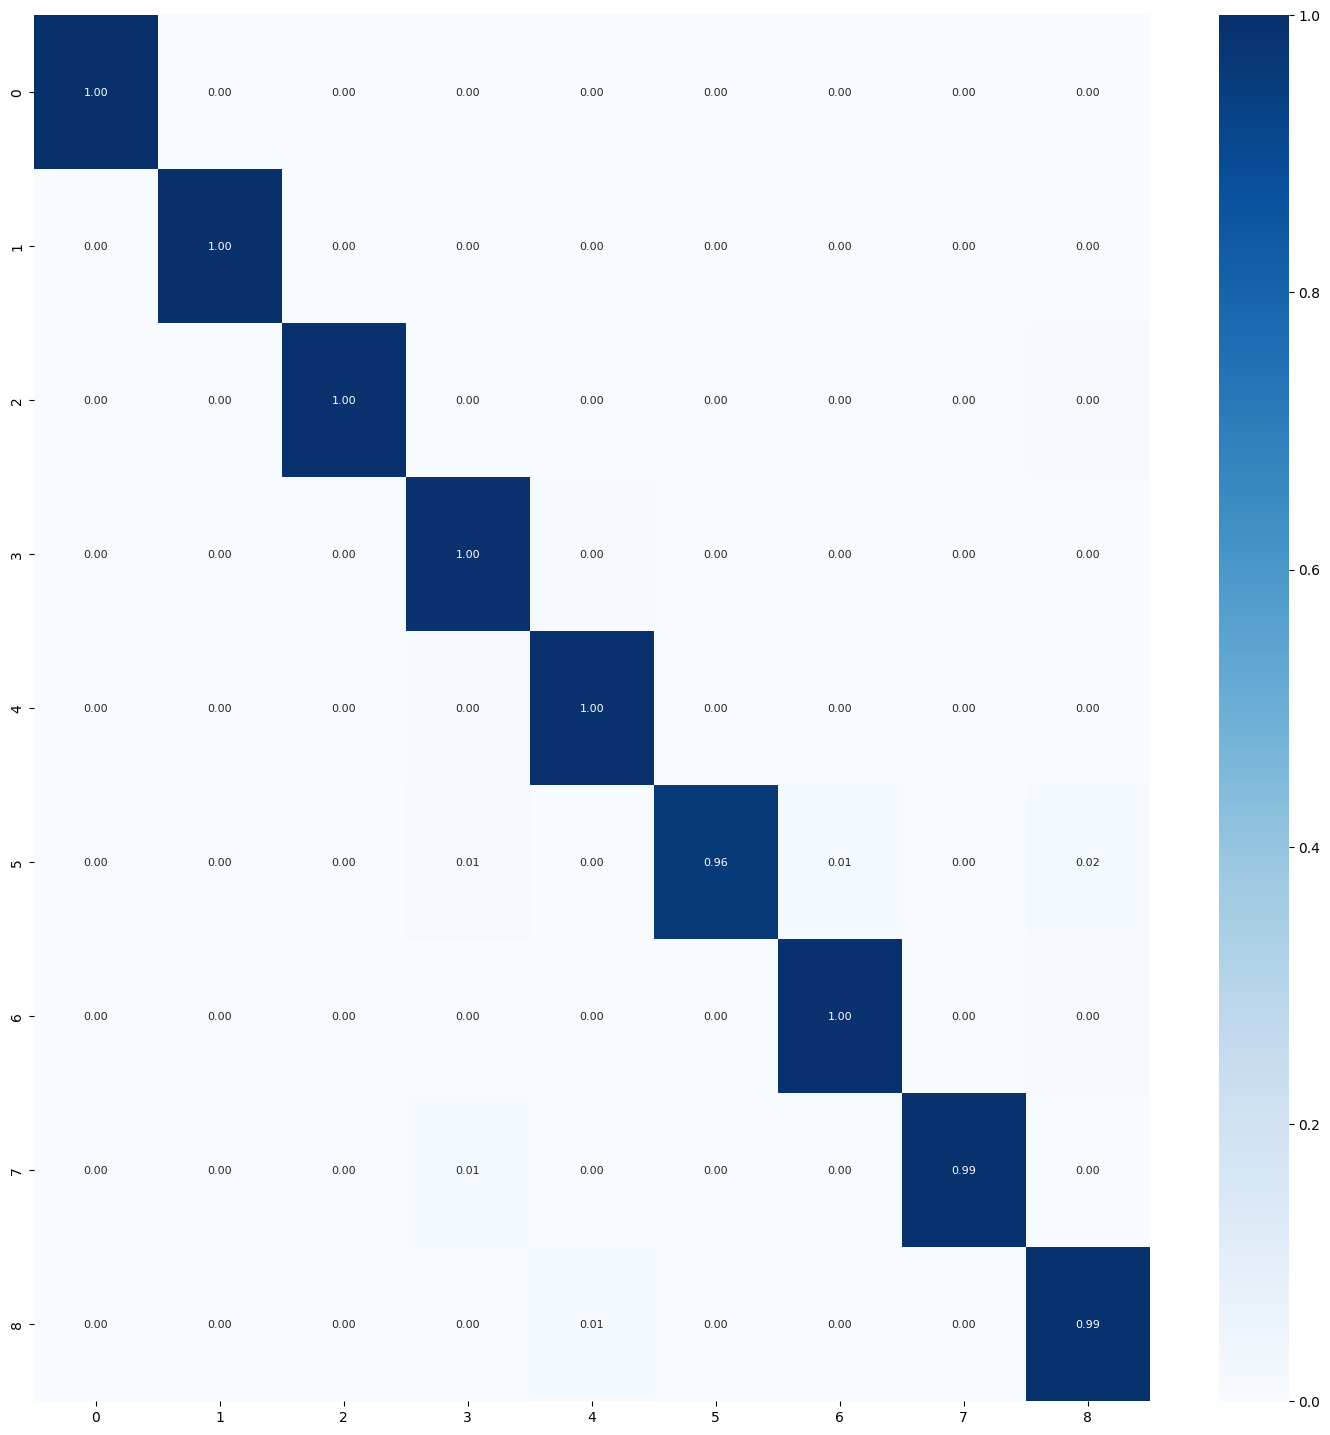


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793833
Trainable params: 2793481
Non-trainable params: 352
Epoch 1/50
295/295 [==============================] - 56s 163ms/step - loss: 1.4032 - accuracy: 0.9398 - val_loss: 2.5633 - val_accuracy: 0.4746
Epoch 2/50
295/295 [==============================] - 45s 153ms/step - loss: 0.9104 - accuracy: 0.9897 - val_loss: 0.8009 - val_accuracy: 0.9862
Epoch 3/50
295/295 [==============================] - 45s 151ms/step - loss: 0.6153 - accuracy: 0.9926 - val_loss: 0.6333 - val_accuracy: 0.9269
Epoch 4/50
295/295 [==============================] - 48s 163ms/step - loss: 0.4045 - accuracy: 0.9953 - val_loss: 0.3351 - val_accuracy: 0.9936
Epoch 5/50
295/295 [==============================] - 49s 166ms/step - loss: 0.2557 - accuracy: 0.9973 - val_loss: 0.2509 - val_accuracy: 0.9881
Epoch 6/50
295/295 [==============================] - 49s 167ms/step - loss: 0.1759 - accuracy: 0.9967 - val_loss: 0.1956 - val_accuracy: 0.9837
Epoch 7/50
295/295

Model and History saved...
296/296 [==============================] - 44s 147ms/step - loss: 0.1290 - accuracy: 0.9956
Train Accuracy: 0.995555579662323
Train Log Loss: 0.12900127470493317
64/64 [==============================] - 9s 133ms/step - loss: 0.1732 - accuracy: 0.9862
Validation Accuracy: 0.9861728549003601
Validation Log Loss: 0.1731756627559662
64/64 [==============================] - 9s 130ms/step - loss: 0.1689 - accuracy: 0.9857
Test Accuracy: 0.985679030418396
Test Log Loss: 0.16893768310546875
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 205   3  15   1   0   1]
 [  0   0   0   0 224   1   0   0   0]
 [  0   0   0   0   0 223   1   0   1]
 [  0   0   0   0   0   0 224   0   1]
 [  0   0   0   2   0   0   0 223   0]
 [  0   0 

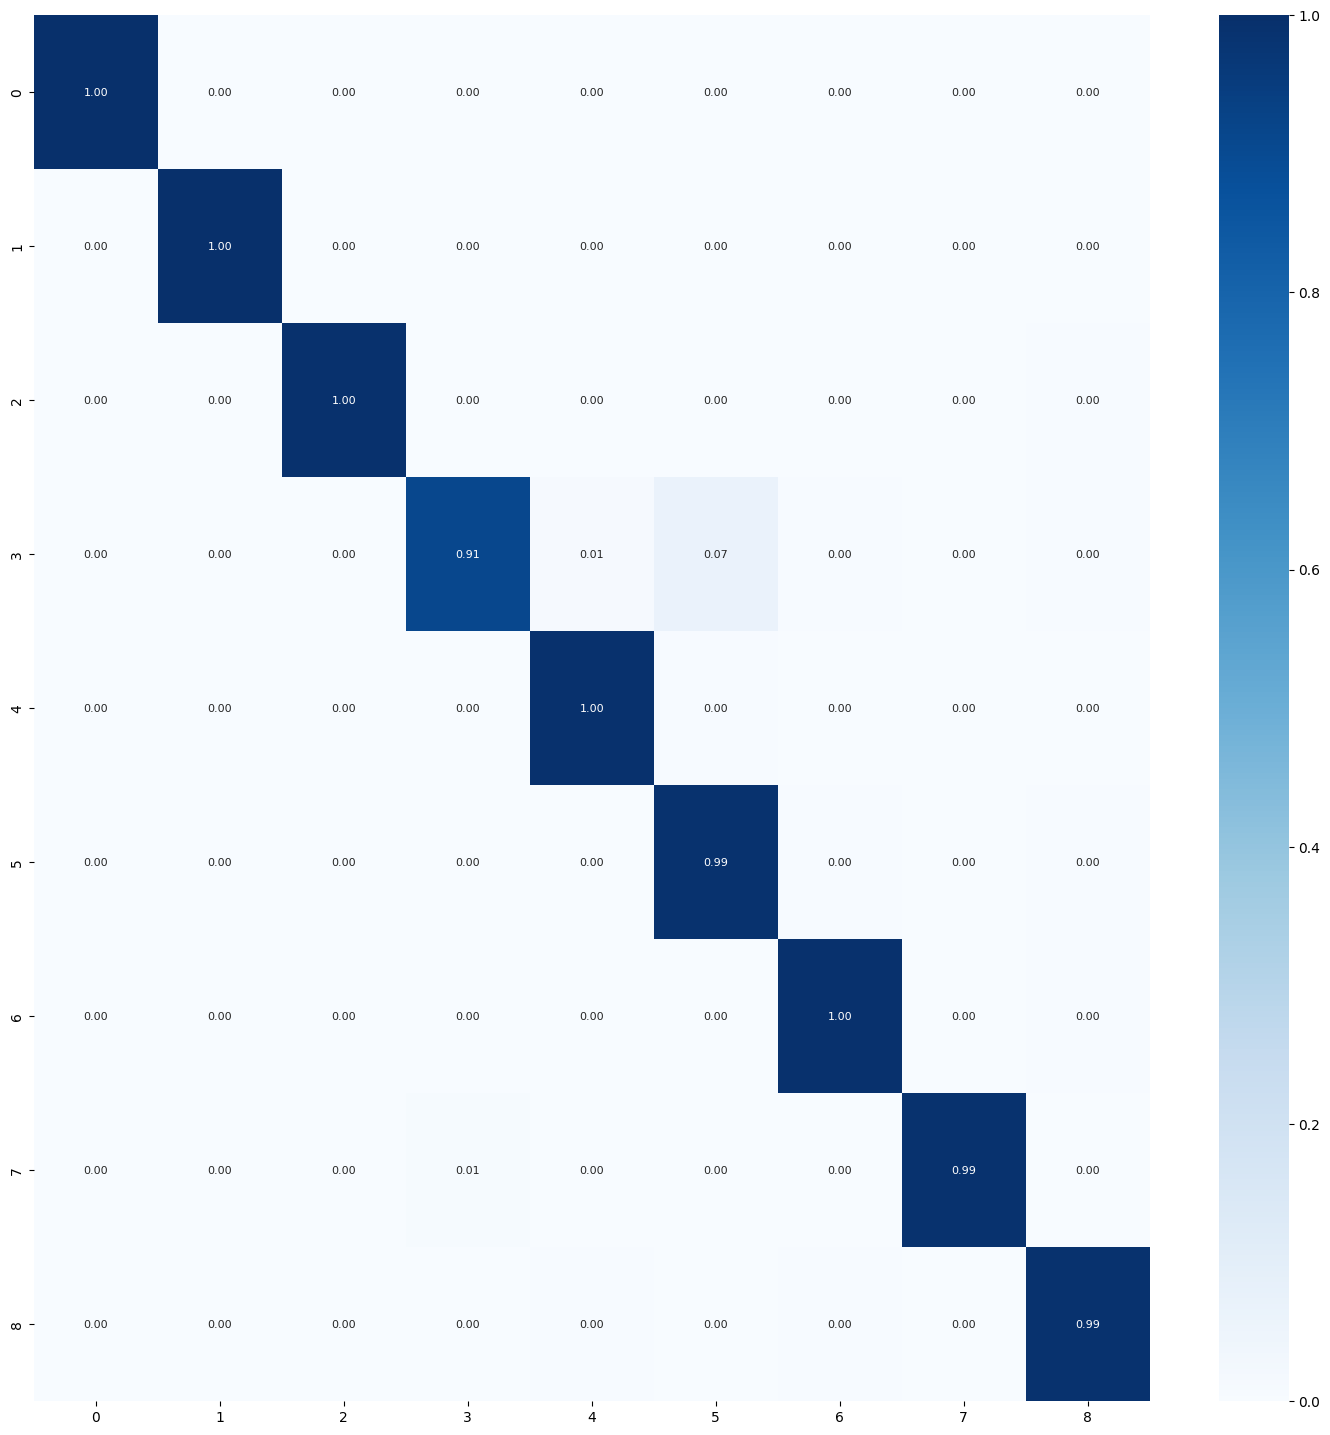

Average training accuracy in 5-fold: 0.9989594340324401
Average validation precision in 5-fold: 0.9953580498695374
/nTest Metrics
test_acc_list: [0.9891358017921448, 0.9930863976478577, 0.9930863976478577, 0.9916049242019653, 0.985679030418396]
Average Test Accuracy with 5-fold: 0.9905185103416443
test_loss_list: [0.15337595343589783, 0.09824543446302414, 0.12695001065731049, 0.12173335254192352, 0.16893768310546875]
Average Test Log Loss with 5-fold: 0.13384848684072495

Precision List: [0.9893506612478267, 0.9931685931217115, 0.9931122150398064, 0.9917385281736506, 0.9861124103891376]
Average Precision List with 5-fold: 0.9906964815944266
Recall List: [0.9891358024691359, 0.9930864197530865, 0.9930864197530865, 0.991604938271605, 0.9856790123456791]
Average Recall List with 5-fold: 0.9905185185185186
F1 Score List: [0.9891337584515097, 0.9930937158803474, 0.9930863052961195, 0.9915992418384832, 0.9856031213355754]
Average F1 Score List with 5-fold: 0.9905032285604071

Metrics List St

In [20]:
%%time

num_classes = 9
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/10
name_save_model: fusion_cnn_basic_150010
Found 10500 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2793898
Trainable params: 2793546
Non-trainable params: 352
Epoch 1/50
328/328 [==============================] - 82s 225ms/step - loss: 1.6418 - accuracy: 0.8639 - val_loss: 2.6996 - val_accuracy: 0.3018
Epoch 2/50
328/328 [==============================] - 53s 160ms/step - loss: 1.1217 - accuracy: 0.9399 - val_loss: 1.1109 - val_accuracy: 0.9044
Epoch 3/50
328/328 [==============================] - 53s 162ms/step - loss: 0.8333 - accuracy: 0.9573 - val_loss: 0.7622 - val_accuracy: 0.9560
Epoch 4/50
328/328 [==============================] - 52s 158ms/s

Model and History saved...
329/329 [==============================] - 42s 128ms/step - loss: 0.2074 - accuracy: 0.9930
Train Accuracy: 0.9930475950241089
Train Log Loss: 0.20743276178836823
71/71 [==============================] - 9s 125ms/step - loss: 0.3694 - accuracy: 0.9538
Validation Accuracy: 0.9537777900695801
Validation Log Loss: 0.3693976104259491
71/71 [==============================] - 9s 125ms/step - loss: 0.3895 - accuracy: 0.9427
Test Accuracy: 0.9426666498184204
Test Log Loss: 0.3895278871059418
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 217   1   0   3   0   0   4]
 [  0   0   0   1 205   0   0   0   0  19]
 [  0   0   0   5   0 208   6   0   2   4]
 [  0   0   0   0   0   0 223   0   1   1]
 [  0 

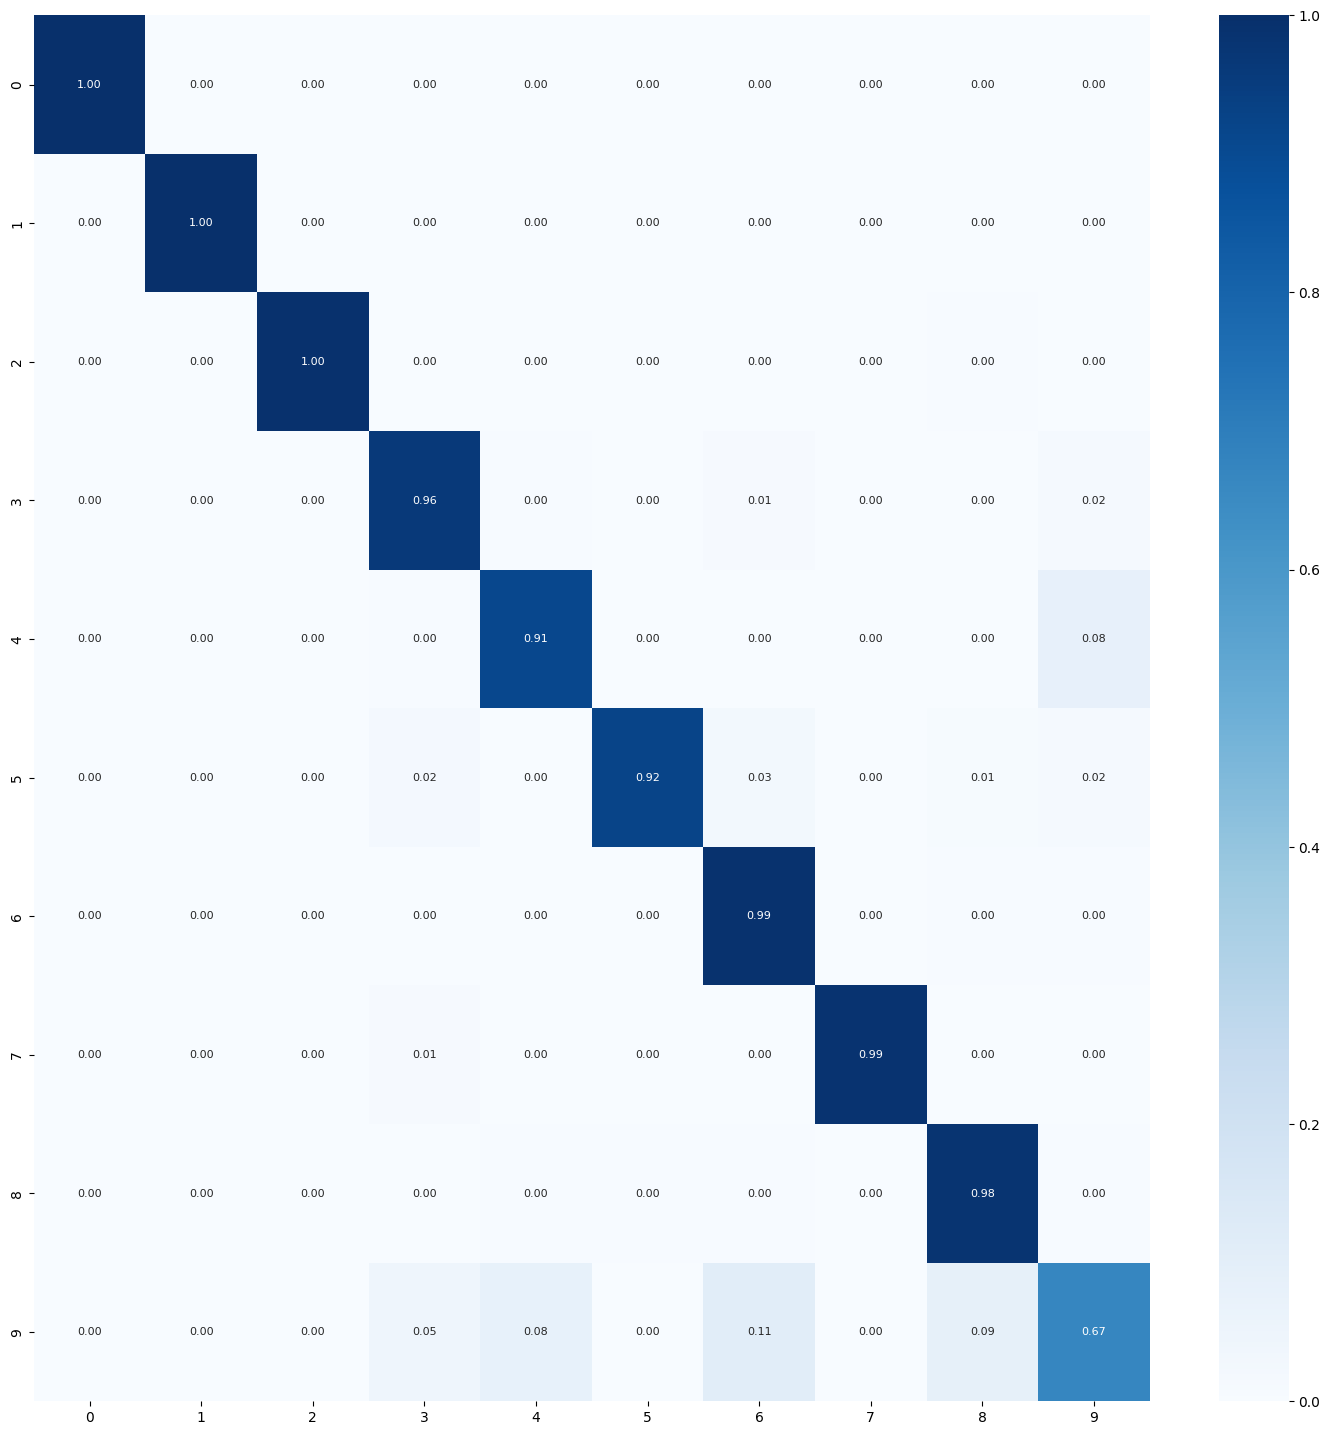


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793898
Trainable params: 2793546
Non-trainable params: 352
Epoch 1/50
328/328 [==============================] - 58s 153ms/step - loss: 1.6313 - accuracy: 0.8654 - val_loss: 2.5114 - val_accuracy: 0.4498
Epoch 2/50
328/328 [==============================] - 51s 154ms/step - loss: 1.1359 - accuracy: 0.9394 - val_loss: 0.9967 - val_accuracy: 0.9529
Epoch 3/50
328/328 [==============================] - 55s 168ms/step - loss: 0.8405 - accuracy: 0.9547 - val_loss: 0.7708 - val_accuracy: 0.9493
Epoch 4/50
328/328 [==============================] - 51s 155ms/step - loss: 0.6330 - accuracy: 0.9645 - val_loss: 0.5821 - val_accuracy: 0.9622
Epoch 5/50
328/328 [==============================] - 50s 153ms/step - loss: 0.4865 - accuracy: 0.9696 - val_loss: 0.4811 - val_accuracy: 0.9524
Epoch 6/50
328/328 [==============================] - 50s 152ms/step - loss: 0.4213 - accuracy: 0.9690 - val_loss: 0.4397 - val_accuracy: 0.9516
Epoch 7/50
328/328

Model and History saved...
329/329 [==============================] - 46s 138ms/step - loss: 0.1799 - accuracy: 0.9961
Train Accuracy: 0.9960952401161194
Train Log Loss: 0.1798698455095291
71/71 [==============================] - 10s 136ms/step - loss: 0.3110 - accuracy: 0.9636
Validation Accuracy: 0.9635555744171143
Validation Log Loss: 0.3109555244445801
71/71 [==============================] - 10s 143ms/step - loss: 0.3518 - accuracy: 0.9516
Test Accuracy: 0.9515555500984192
Test Log Loss: 0.35176199674606323
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 211   1   1   0   0   0  12]
 [  0   0   0   0 214   0   0   0   0  11]
 [  0   0   0   0   0 221   0   0   1   3]
 [  0   0   0   1   0   0 220   0   1   3]
 [  

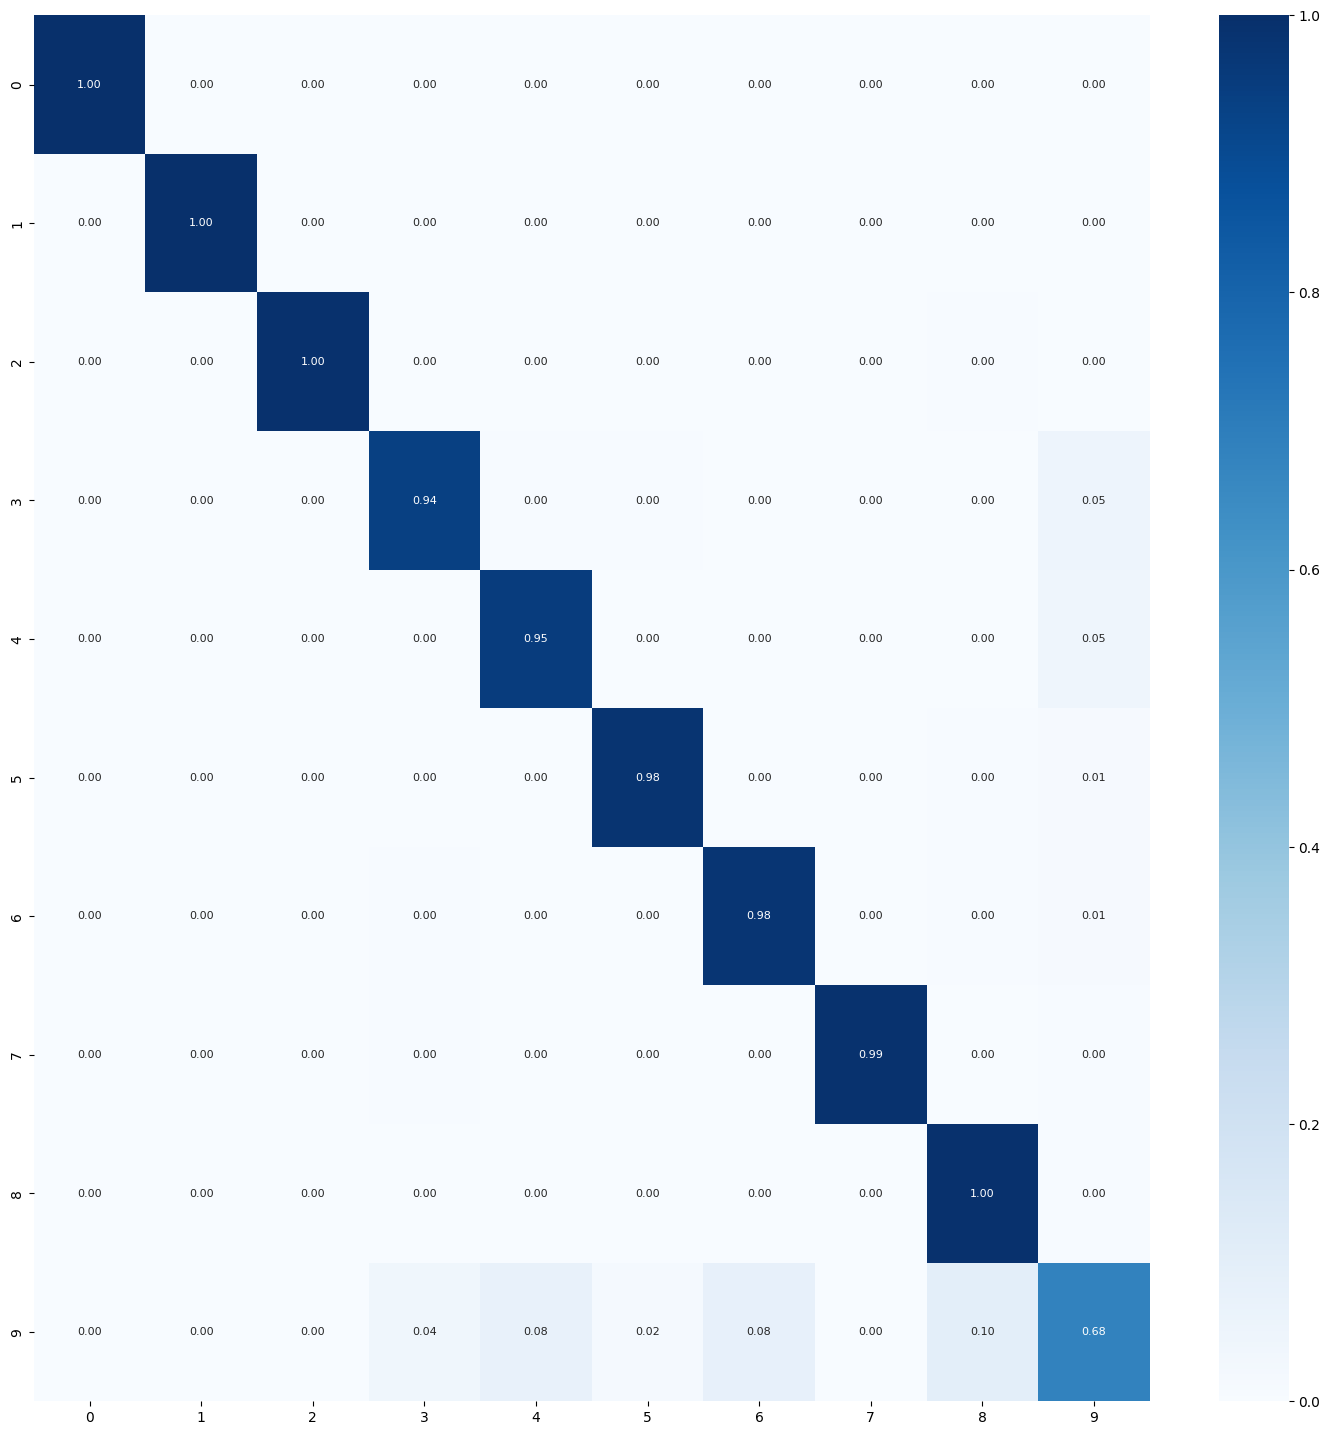


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793898
Trainable params: 2793546
Non-trainable params: 352
Epoch 1/50
328/328 [==============================] - 64s 169ms/step - loss: 1.6414 - accuracy: 0.8541 - val_loss: 2.5880 - val_accuracy: 0.4387
Epoch 2/50
328/328 [==============================] - 54s 164ms/step - loss: 1.1088 - accuracy: 0.9386 - val_loss: 0.9851 - val_accuracy: 0.9471
Epoch 3/50
328/328 [==============================] - 56s 171ms/step - loss: 0.8213 - accuracy: 0.9553 - val_loss: 0.7168 - val_accuracy: 0.9582
Epoch 4/50
328/328 [==============================] - 55s 167ms/step - loss: 0.6167 - accuracy: 0.9630 - val_loss: 0.5742 - val_accuracy: 0.9560
Epoch 5/50
328/328 [==============================] - 56s 172ms/step - loss: 0.4976 - accuracy: 0.9655 - val_loss: 0.5377 - val_accuracy: 0.9453
Epoch 6/50
328/328 [==============================] - 54s 163ms/step - loss: 0.3953 - accuracy: 0.9743 - val_loss: 0.4191 - val_accuracy: 0.9507
Epoch 7/50
328/328

Model and History saved...
329/329 [==============================] - 41s 124ms/step - loss: 0.1865 - accuracy: 0.9934
Train Accuracy: 0.9934285879135132
Train Log Loss: 0.18650583922863007
71/71 [==============================] - 9s 129ms/step - loss: 0.3310 - accuracy: 0.9524
Validation Accuracy: 0.9524444341659546
Validation Log Loss: 0.3310456871986389
71/71 [==============================] - 9s 125ms/step - loss: 0.3807 - accuracy: 0.9453
Test Accuracy: 0.9453333616256714
Test Log Loss: 0.3806988298892975
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   2]
 [  0   0   0   0 207   0   0   0   0  18]
 [  0   0   0   7   0 200   0   0   1  17]
 [  0   0   0   2   0   0 218   0   1   4]
 [  0 

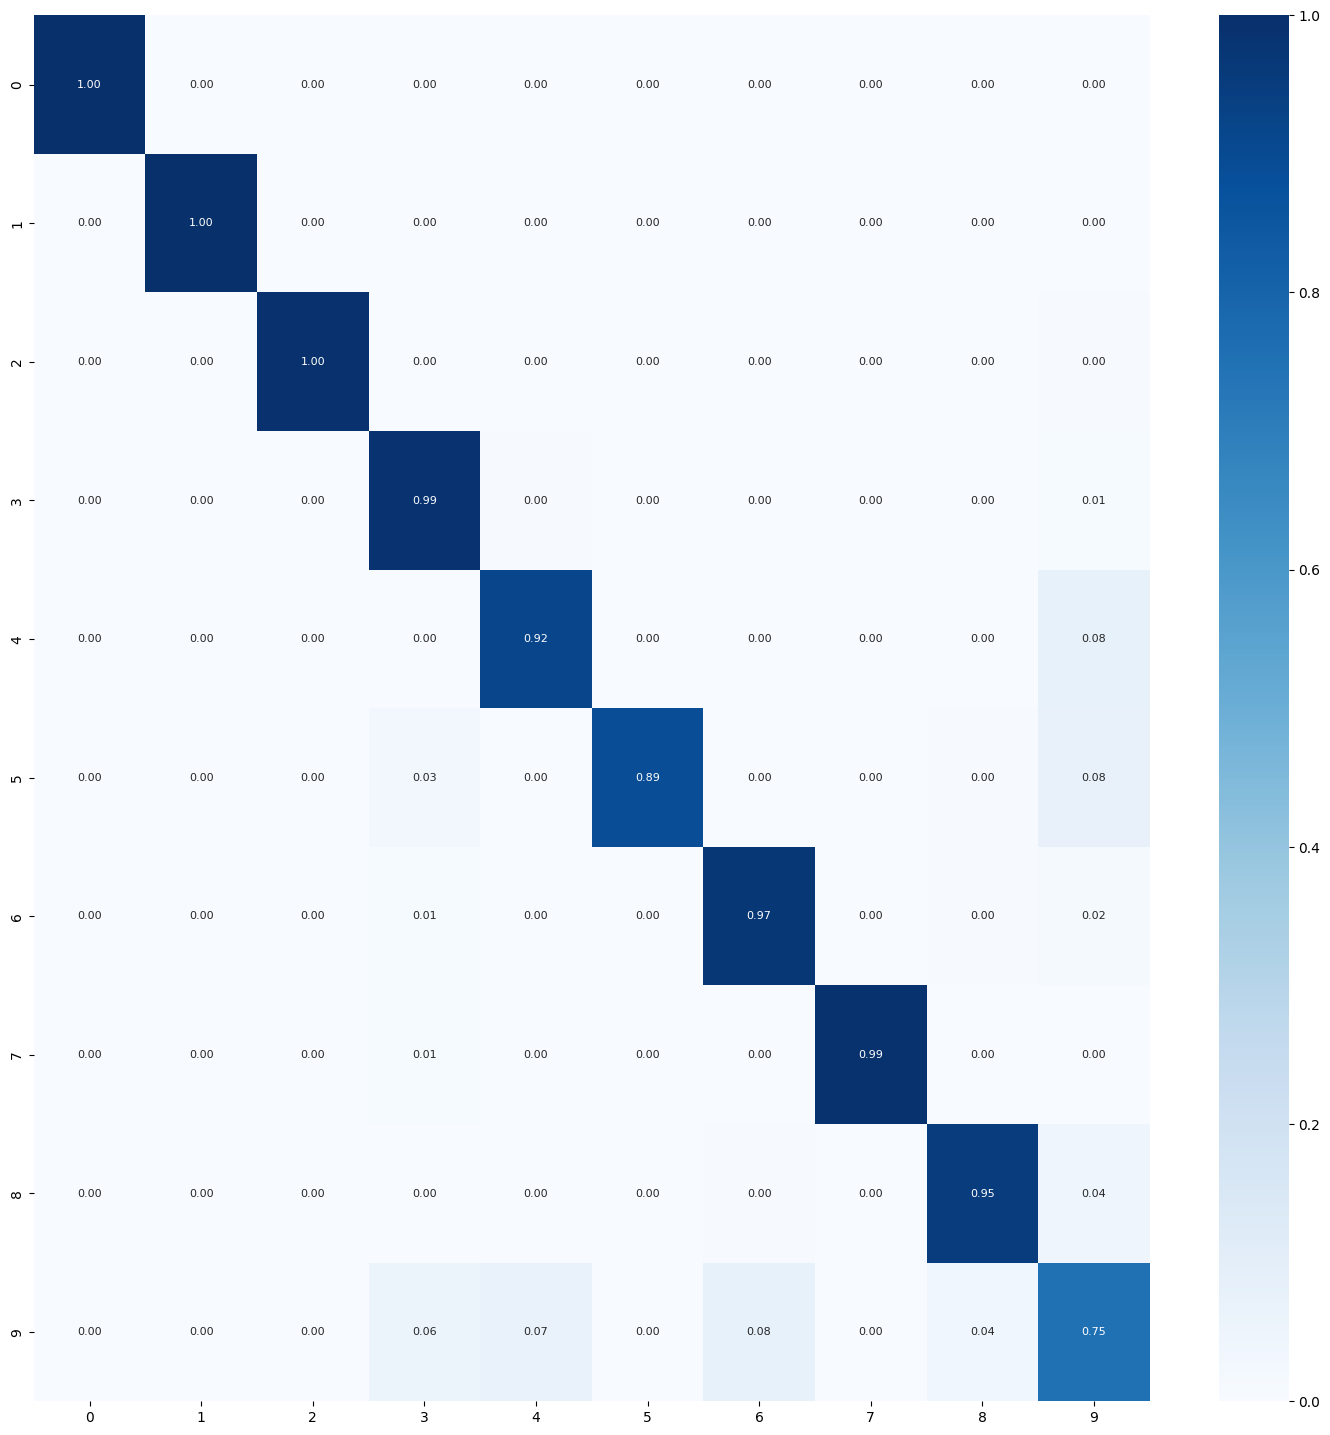


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793898
Trainable params: 2793546
Non-trainable params: 352
Epoch 1/50
328/328 [==============================] - 57s 151ms/step - loss: 1.6483 - accuracy: 0.8589 - val_loss: 2.5985 - val_accuracy: 0.4298
Epoch 2/50
328/328 [==============================] - 51s 156ms/step - loss: 1.1112 - accuracy: 0.9370 - val_loss: 1.0594 - val_accuracy: 0.9013
Epoch 3/50
328/328 [==============================] - 49s 148ms/step - loss: 0.8290 - accuracy: 0.9525 - val_loss: 0.7372 - val_accuracy: 0.9480
Epoch 4/50
328/328 [==============================] - 50s 151ms/step - loss: 0.6093 - accuracy: 0.9596 - val_loss: 0.5637 - val_accuracy: 0.9502
Epoch 5/50
328/328 [==============================] - 50s 153ms/step - loss: 0.4729 - accuracy: 0.9666 - val_loss: 0.6779 - val_accuracy: 0.8667
Epoch 6/50
328/328 [==============================] - 49s 150ms/step - loss: 0.3841 - accuracy: 0.9697 - val_loss: 0.4026 - val_accuracy: 0.9511
Epoch 7/50
328/328

Model and History saved...
329/329 [==============================] - 49s 147ms/step - loss: 0.1708 - accuracy: 0.9941
Train Accuracy: 0.9940952658653259
Train Log Loss: 0.1707579642534256
71/71 [==============================] - 11s 150ms/step - loss: 0.3249 - accuracy: 0.9560
Validation Accuracy: 0.9559999704360962
Validation Log Loss: 0.32485732436180115
71/71 [==============================] - 10s 133ms/step - loss: 0.3530 - accuracy: 0.9507
Test Accuracy: 0.9506666660308838
Test Log Loss: 0.3530447483062744
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 215   1   1   0   0   0   8]
 [  0   0   0   0 213   0   0   0   0  12]
 [  0   0   0   0   0 218   1   0   0   6]
 [  0   0   0   0   0   0 223   0   1   1]
 [  

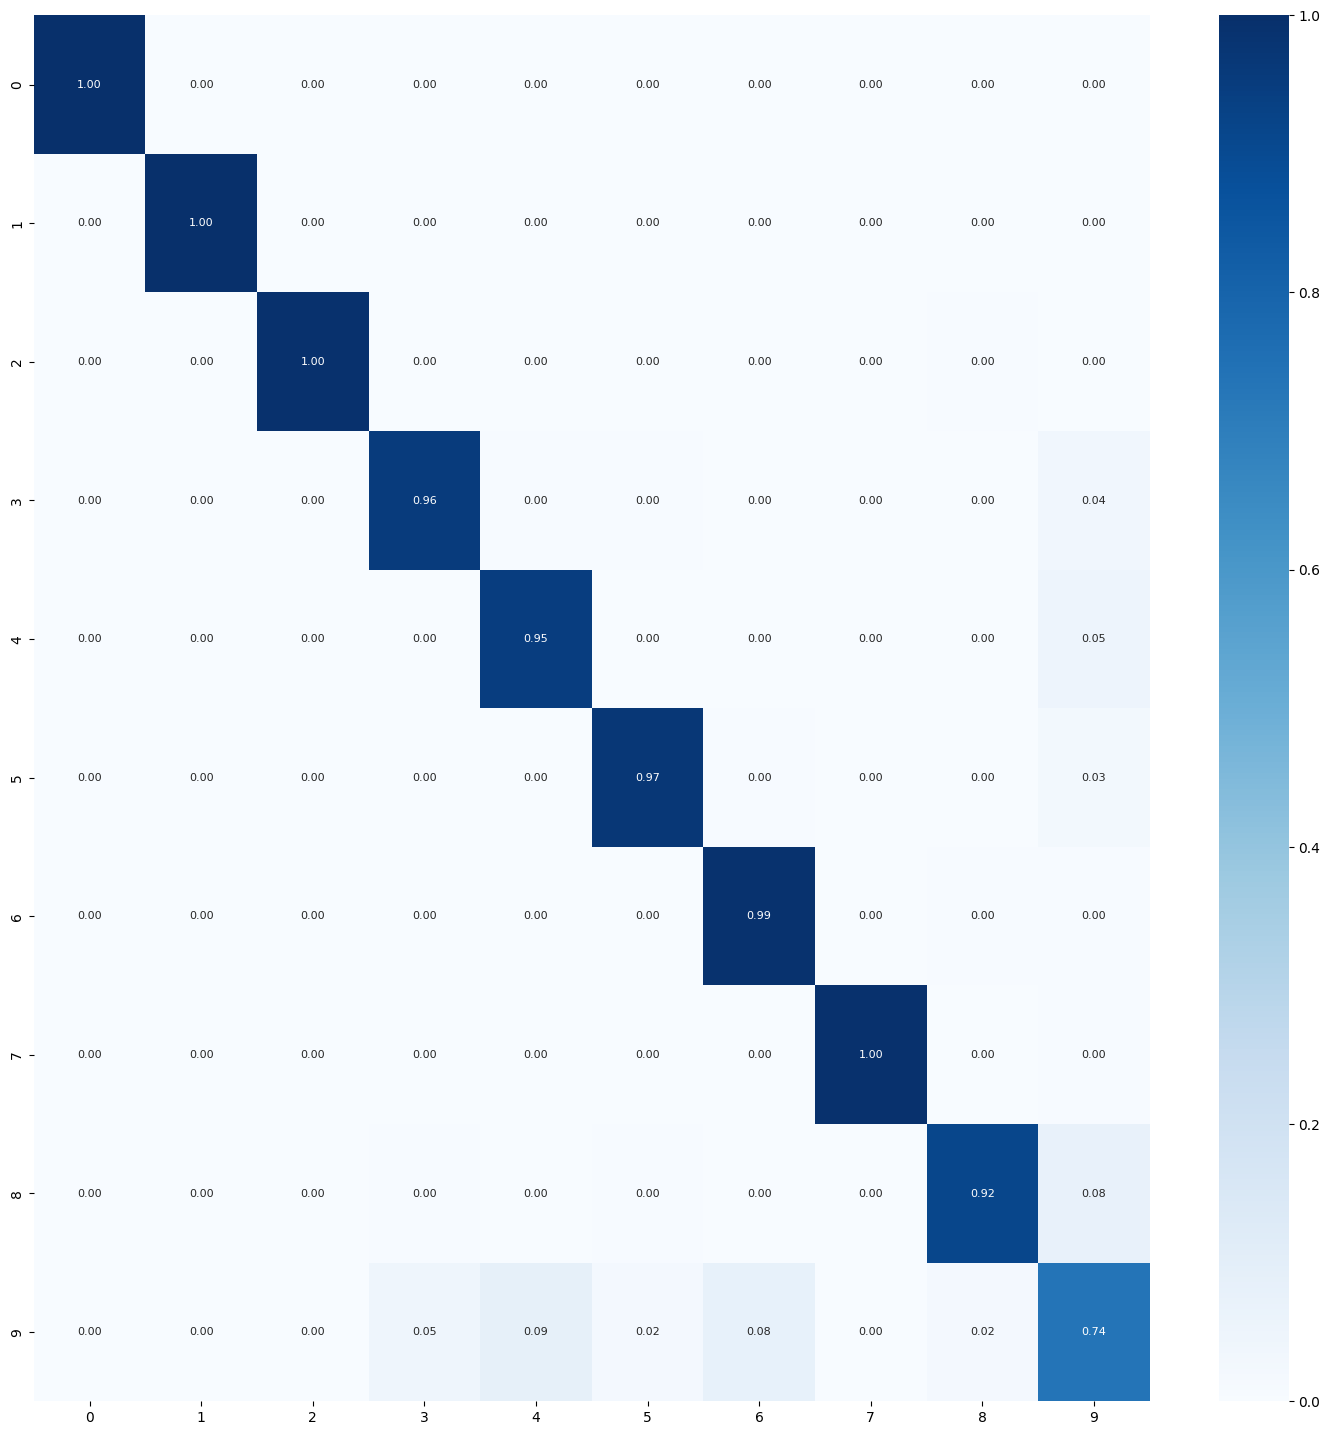


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793898
Trainable params: 2793546
Non-trainable params: 352
Epoch 1/50
328/328 [==============================] - 60s 159ms/step - loss: 1.6210 - accuracy: 0.8637 - val_loss: 2.8549 - val_accuracy: 0.4124
Epoch 2/50
328/328 [==============================] - 51s 154ms/step - loss: 1.1020 - accuracy: 0.9394 - val_loss: 1.0100 - val_accuracy: 0.9427
Epoch 3/50
328/328 [==============================] - 52s 157ms/step - loss: 0.8008 - accuracy: 0.9559 - val_loss: 0.7209 - val_accuracy: 0.9498
Epoch 4/50
328/328 [==============================] - 50s 154ms/step - loss: 0.6241 - accuracy: 0.9594 - val_loss: 0.6219 - val_accuracy: 0.9480
Epoch 5/50
328/328 [==============================] - 51s 156ms/step - loss: 0.4804 - accuracy: 0.9699 - val_loss: 0.5036 - val_accuracy: 0.9516
Epoch 6/50
328/328 [==============================] - 51s 154ms/step - loss: 0.4057 - accuracy: 0.9685 - val_loss: 0.4399 - val_accuracy: 0.9444
Epoch 7/50
328/328

Model and History saved...
329/329 [==============================] - 47s 141ms/step - loss: 0.1668 - accuracy: 0.9946
Train Accuracy: 0.9945714473724365
Train Log Loss: 0.16681820154190063
71/71 [==============================] - 10s 139ms/step - loss: 0.2963 - accuracy: 0.9529
Validation Accuracy: 0.9528889060020447
Validation Log Loss: 0.29632148146629333
71/71 [==============================] - 10s 137ms/step - loss: 0.3384 - accuracy: 0.9471
Test Accuracy: 0.9471111297607422
Test Log Loss: 0.33844873309135437
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 223   0   1   0   0   0   1   0]
 [  0   0   0 218   2   2   0   0   0   3]
 [  0   0   0   0 207   0   0   0   0  18]
 [  0   0   0   1   0 215   1   0   7   1]
 [  0   0   0   0   0   0 221   0   1   3]
 [

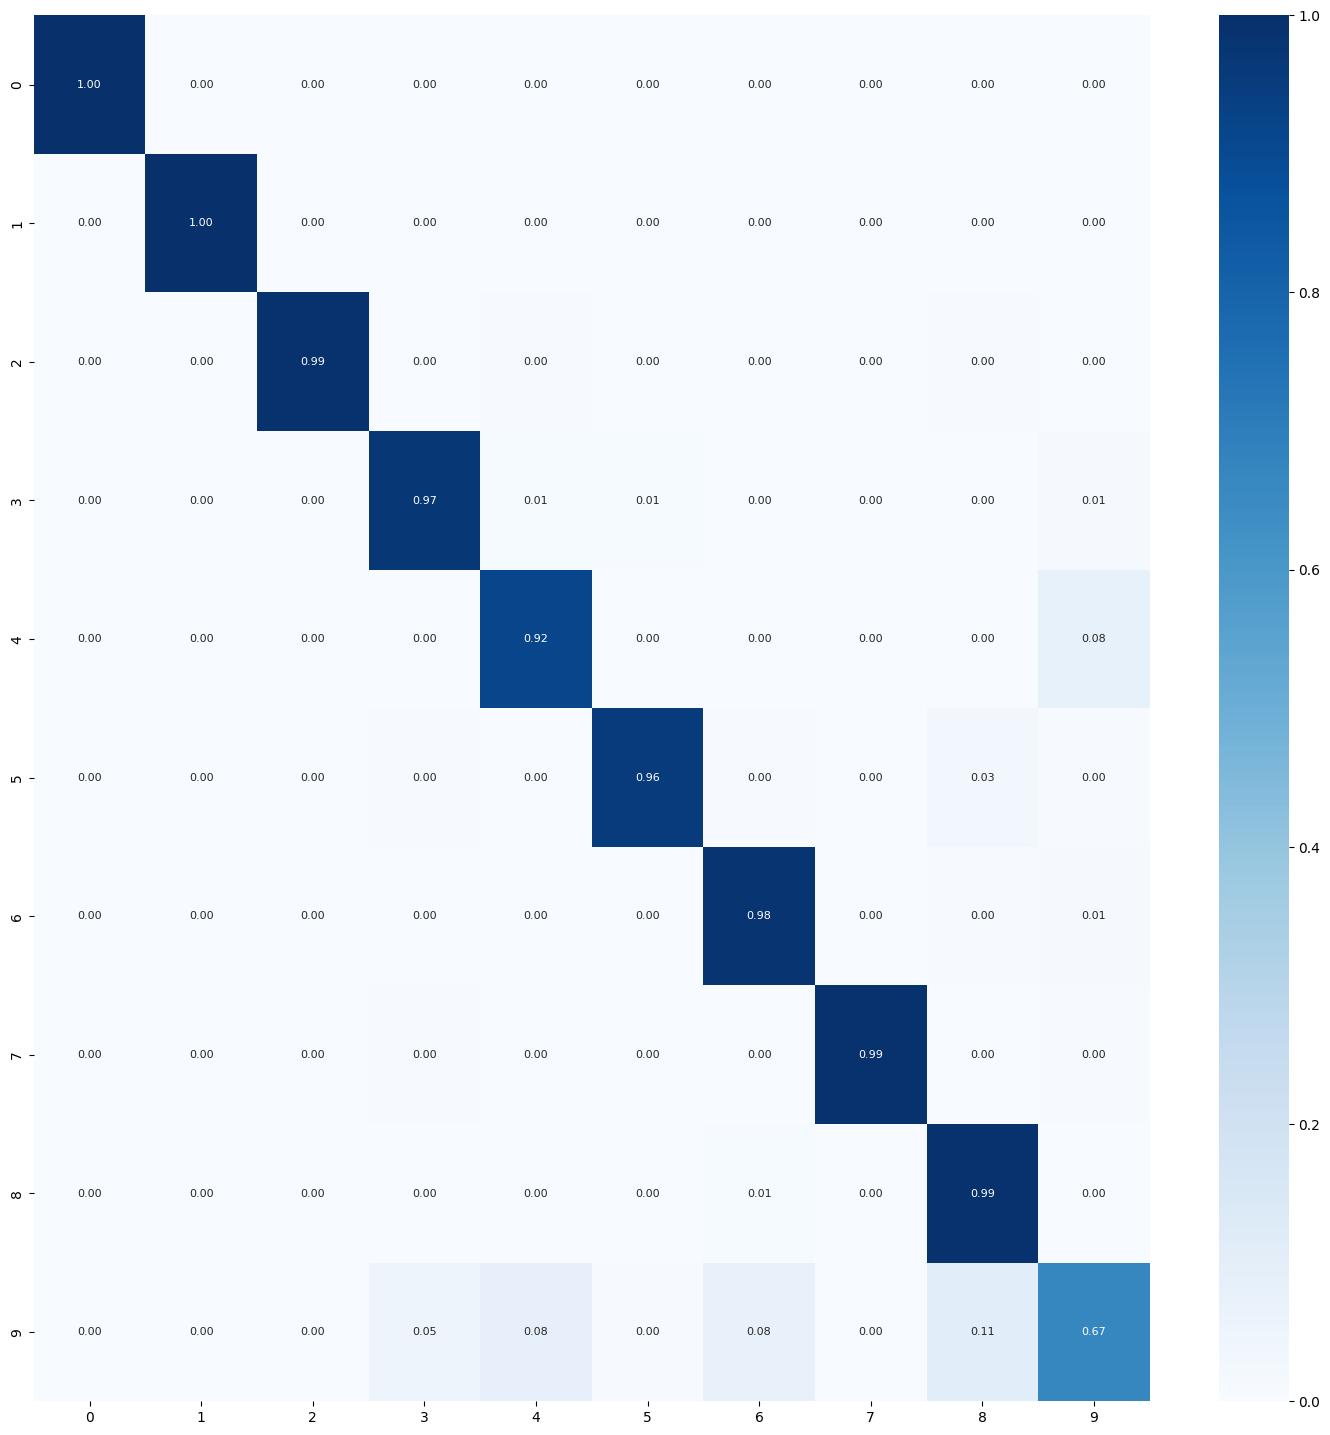

Average training accuracy in 5-fold: 0.9918035864830017
Average validation precision in 5-fold: 0.9622222304344177
/nTest Metrics
test_acc_list: [0.9426666498184204, 0.9515555500984192, 0.9453333616256714, 0.9506666660308838, 0.9471111297607422]
Average Test Accuracy with 5-fold: 0.9474666714668274
test_loss_list: [0.3895278871059418, 0.35176199674606323, 0.3806988298892975, 0.3530447483062744, 0.33844873309135437]
Average Test Log Loss with 5-fold: 0.36269643902778625

Precision List: [0.9427209026948624, 0.9503273267805528, 0.9462786816797134, 0.9501635474382383, 0.9467647908449441]
Average Precision List with 5-fold: 0.9472510498876622
Recall List: [0.9426666666666668, 0.9515555555555556, 0.9453333333333334, 0.9506666666666665, 0.9471111111111112]
Average Recall List with 5-fold: 0.9474666666666668
F1 Score List: [0.940959180463414, 0.9498610200231633, 0.9452011853275197, 0.9501005833925193, 0.9452721307773733]
Average F1 Score List with 5-fold: 0.9462788199967977

Metrics List Stor

In [21]:
%%time

num_classes = 10
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/11
name_save_model: fusion_cnn_basic_150011
Found 11550 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2793963
Trainable params: 2793611
Non-trainable params: 352
Epoch 1/50
360/360 [==============================] - 73s 176ms/step - loss: 1.7206 - accuracy: 0.8338 - val_loss: 2.5676 - val_accuracy: 0.4267
Epoch 2/50
360/360 [==============================] - 71s 197ms/step - loss: 1.1776 - accuracy: 0.9081 - val_loss: 1.0488 - val_accuracy: 0.9091
Epoch 3/50
360/360 [==============================] - 61s 170ms/step - loss: 0.8930 - accuracy: 0.9250 - val_loss: 0.8277 - val_accuracy: 0.9095
Epoch 4/50
360/360 [==============================] - 62

Model and History saved...
361/361 [==============================] - 56s 155ms/step - loss: 0.2168 - accuracy: 0.9881
Train Accuracy: 0.9881385564804077
Train Log Loss: 0.21679721772670746
78/78 [==============================] - 12s 154ms/step - loss: 0.4419 - accuracy: 0.9212
Validation Accuracy: 0.9212121367454529
Validation Log Loss: 0.441883385181427
78/78 [==============================] - 12s 154ms/step - loss: 0.4194 - accuracy: 0.9293
Test Accuracy: 0.9292929172515869
Test Log Loss: 0.41943052411079407
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 222   2   0   0   0   0   0   1   0]
 [  0   0   0 220   0   3   0   1   0   0   1]
 [  0   0   0   2 185  10   0   0   0   0  28]
 [  0   0   0   0  15 201   0   0   0   0   9]
 [  0   0

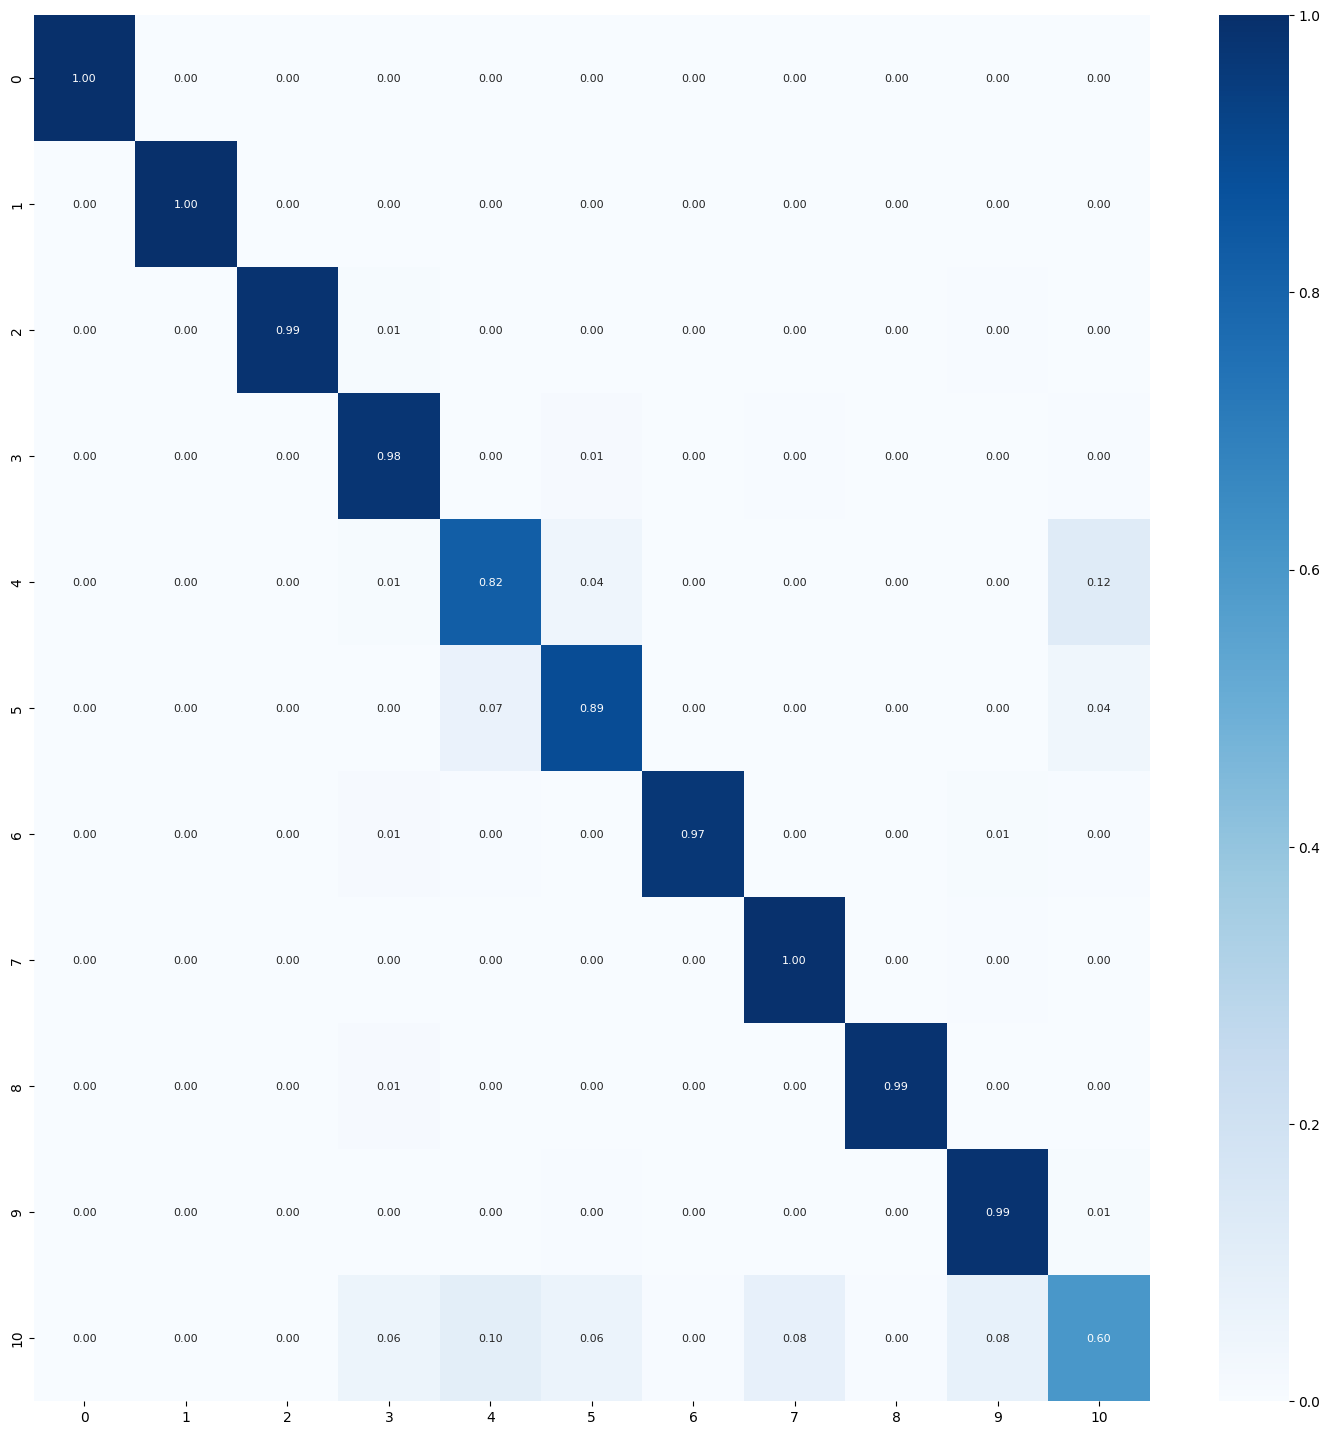


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2793963
Trainable params: 2793611
Non-trainable params: 352
Epoch 1/50
360/360 [==============================] - 80s 194ms/step - loss: 1.6886 - accuracy: 0.8398 - val_loss: 3.0162 - val_accuracy: 0.4287
Epoch 2/50
360/360 [==============================] - 69s 192ms/step - loss: 1.1606 - accuracy: 0.9149 - val_loss: 1.0979 - val_accuracy: 0.8998
Epoch 3/50
360/360 [==============================] - 67s 186ms/step - loss: 0.8550 - accuracy: 0.9371 - val_loss: 0.8008 - val_accuracy: 0.9176
Epoch 4/50
360/360 [==============================] - 62s 173ms/step - loss: 0.6620 - accuracy: 0.9444 - val_loss: 0.6775 - val_accuracy: 0.9196
Epoch 5/50
360/360 [==============================] - 55s 154ms/step - loss: 0.5279 - accuracy: 0.9519 - val_loss: 0.5874 - val_accuracy: 0.9172
Epoch 6/50
360/360 [==============================] - 56s 156ms/step - loss: 0.4342 - accuracy: 0.9599 - val_loss: 0.5504 - val_accuracy: 0.9127
Epoch 7/50
360/360

Model and History saved...
361/361 [==============================] - 46s 126ms/step - loss: 0.2307 - accuracy: 0.9869
Train Accuracy: 0.9869264364242554
Train Log Loss: 0.2307441532611847
78/78 [==============================] - 10s 126ms/step - loss: 0.4839 - accuracy: 0.9228
Validation Accuracy: 0.9228282570838928
Validation Log Loss: 0.48387014865875244
78/78 [==============================] - 10s 123ms/step - loss: 0.4791 - accuracy: 0.9297
Test Accuracy: 0.9296969771385193
Test Log Loss: 0.4790906012058258
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   1 217   0   0   1   0   0   2   4]
 [  0   0   0   1 194   6   0   0   0   0  24]
 [  0   0   0   1  11 201   0   0   0   0  12]
 [  0   0

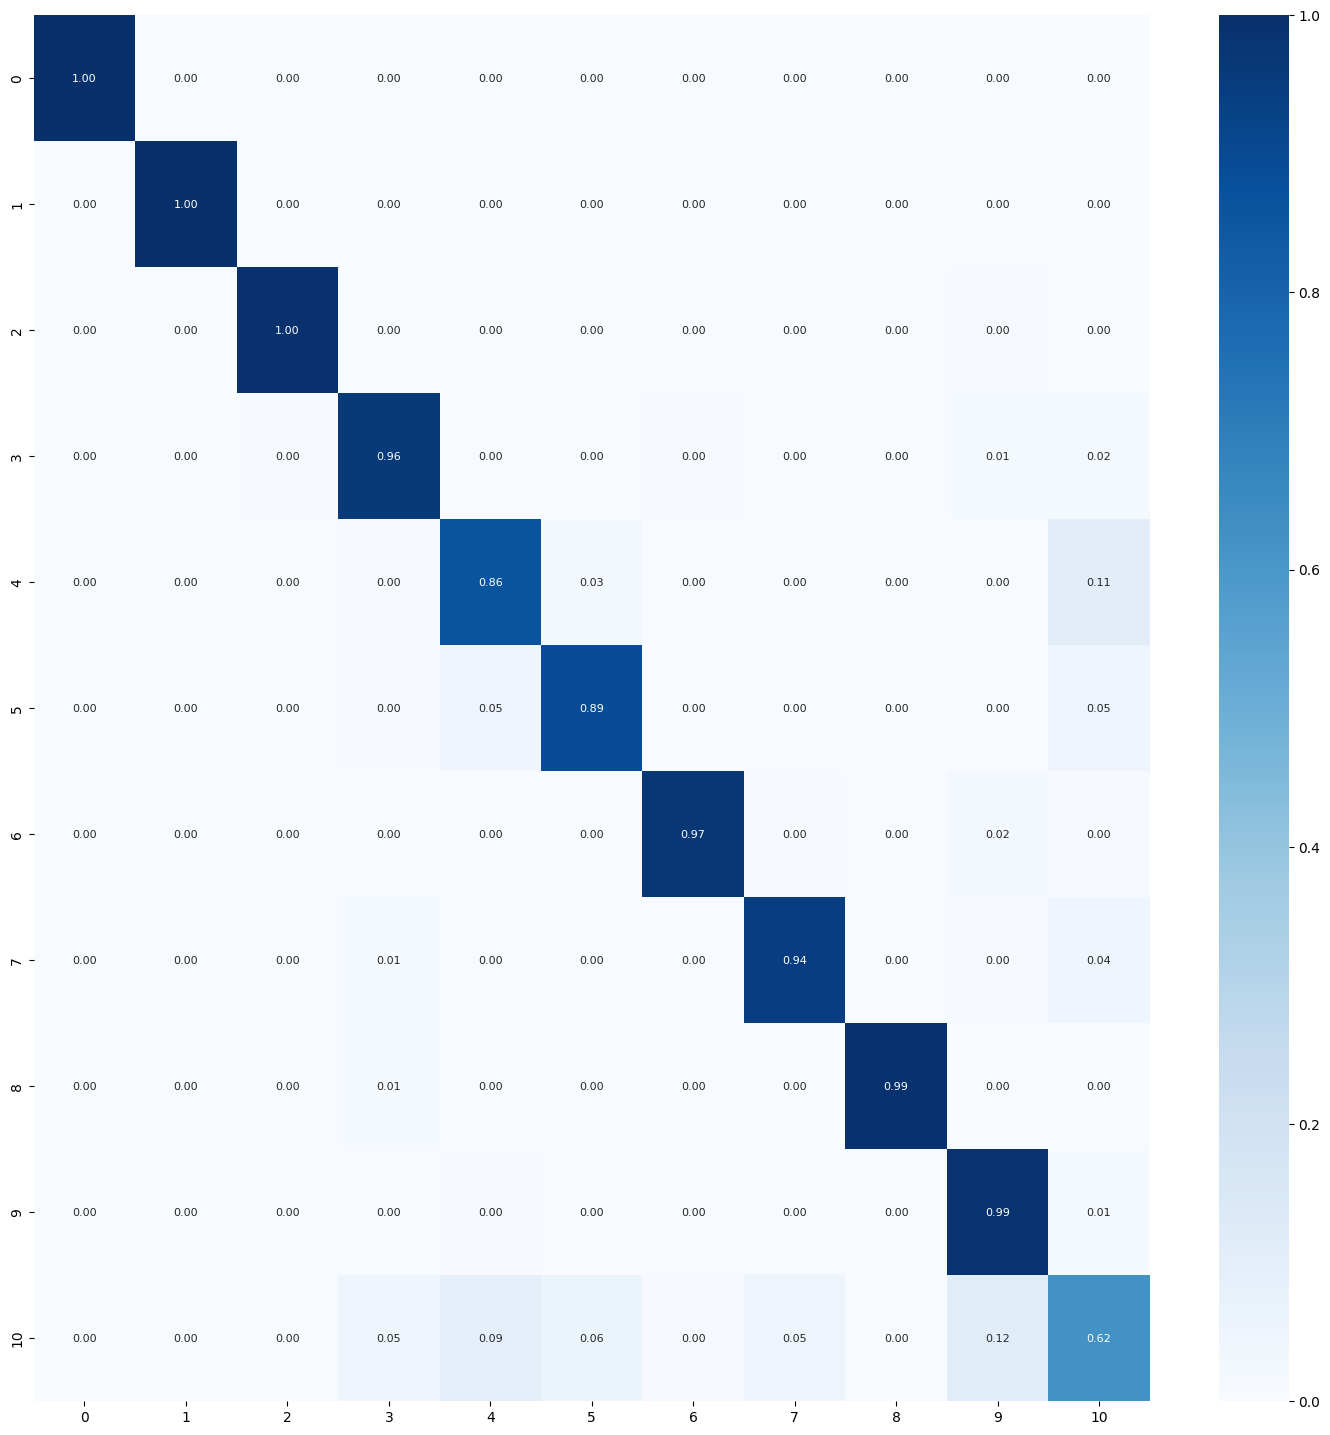


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2793963
Trainable params: 2793611
Non-trainable params: 352
Epoch 1/50
360/360 [==============================] - 66s 163ms/step - loss: 1.7631 - accuracy: 0.8136 - val_loss: 2.2231 - val_accuracy: 0.6255
Epoch 2/50
360/360 [==============================] - 62s 171ms/step - loss: 1.2089 - accuracy: 0.9038 - val_loss: 1.0527 - val_accuracy: 0.9119
Epoch 3/50
360/360 [==============================] - 56s 156ms/step - loss: 0.9008 - accuracy: 0.9236 - val_loss: 0.8354 - val_accuracy: 0.9051
Epoch 4/50
360/360 [==============================] - 54s 150ms/step - loss: 0.6903 - accuracy: 0.9356 - val_loss: 0.6858 - val_accuracy: 0.9103
Epoch 5/50
360/360 [==============================] - 60s 165ms/step - loss: 0.5531 - accuracy: 0.9426 - val_loss: 0.5774 - val_accuracy: 0.9192
Epoch 6/50
360/360 [==============================] - 60s 165ms/step - loss: 0.4767 - accuracy: 0.9426 - val_loss: 0.5363 - val_accuracy: 0.9135
Epoch 7/50
360/360

Model and History saved...
361/361 [==============================] - 45s 125ms/step - loss: 0.2213 - accuracy: 0.9887
Train Accuracy: 0.9887446165084839
Train Log Loss: 0.22129635512828827
78/78 [==============================] - 10s 121ms/step - loss: 0.4732 - accuracy: 0.9228
Validation Accuracy: 0.9228282570838928
Validation Log Loss: 0.4731508493423462
78/78 [==============================] - 10s 129ms/step - loss: 0.4779 - accuracy: 0.9240
Test Accuracy: 0.9240403771400452
Test Log Loss: 0.477939635515213
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 219   0   1   2   1   0   0   2]
 [  0   0   0   1 186  17   0   0   0   0  21]
 [  0   0   0   0  13 200   0   0   0   0  12]
 [  0   0 

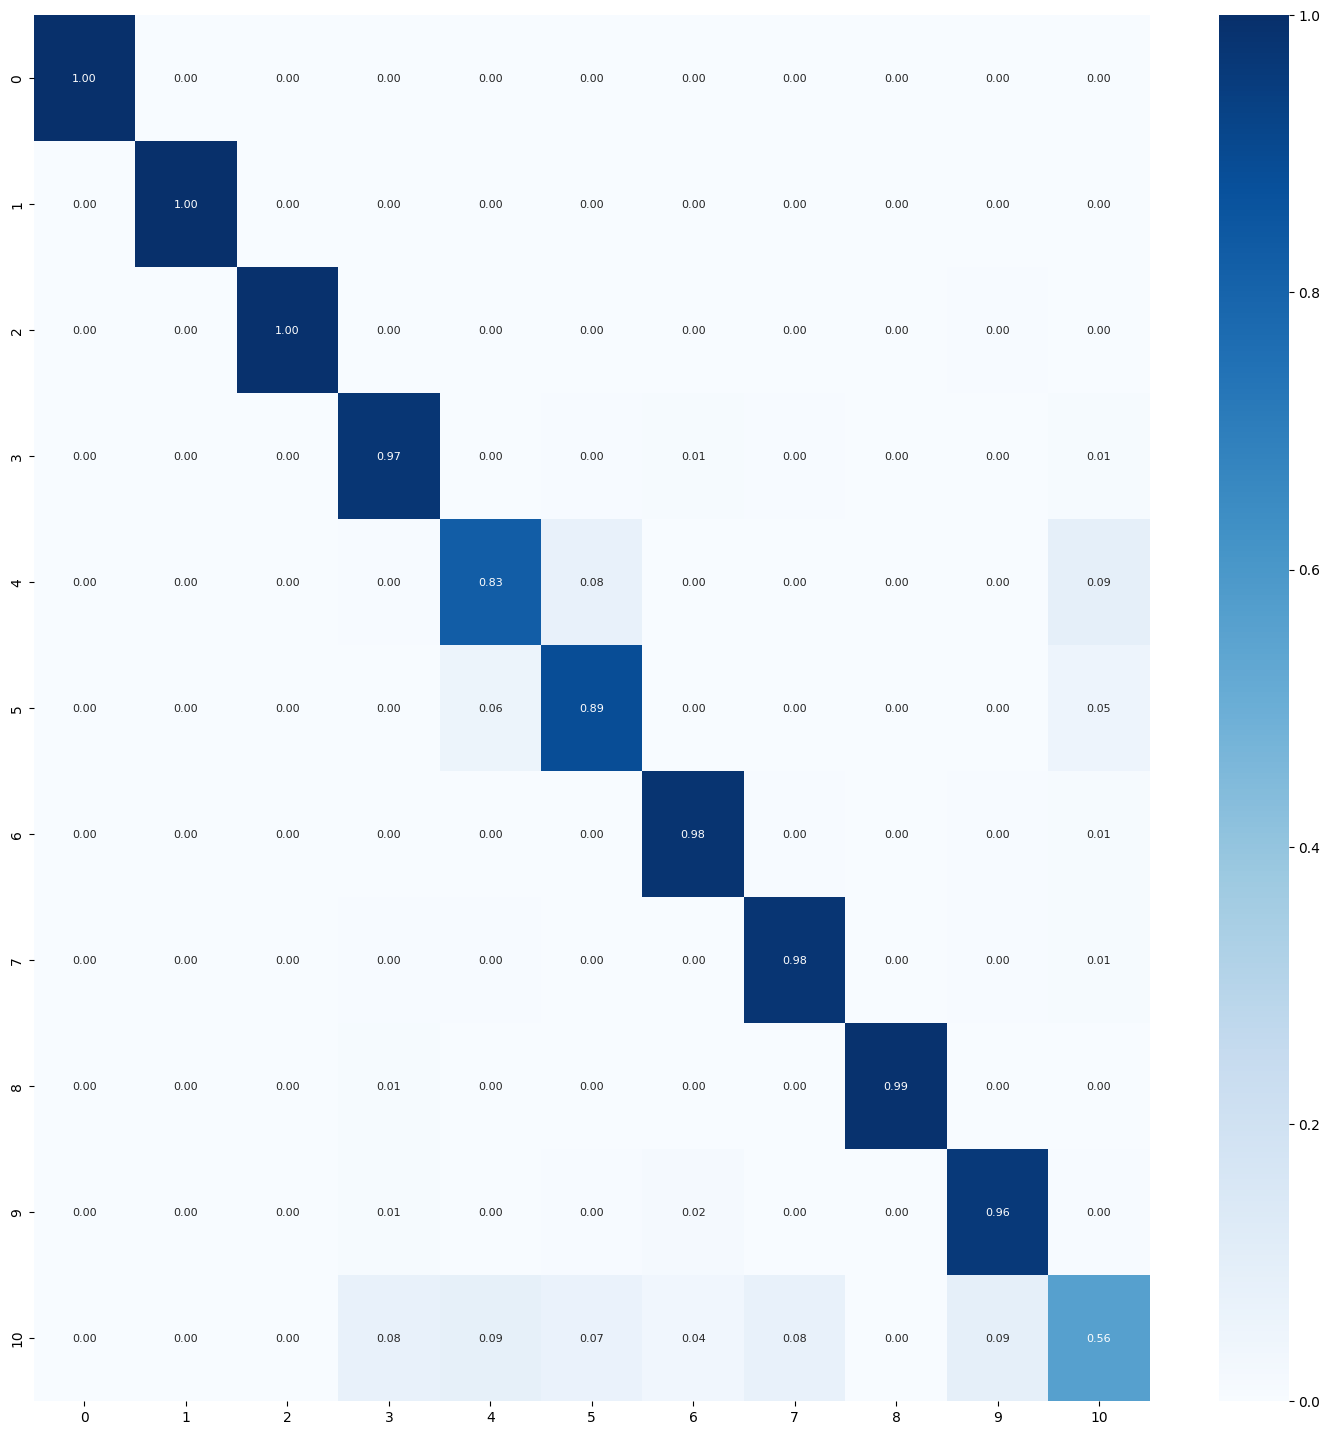


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2793963
Trainable params: 2793611
Non-trainable params: 352
Epoch 1/50
360/360 [==============================] - 62s 151ms/step - loss: 1.7154 - accuracy: 0.8301 - val_loss: 2.1341 - val_accuracy: 0.5830
Epoch 2/50
360/360 [==============================] - 54s 149ms/step - loss: 1.1612 - accuracy: 0.9079 - val_loss: 1.0263 - val_accuracy: 0.9135
Epoch 3/50
360/360 [==============================] - 54s 150ms/step - loss: 0.8670 - accuracy: 0.9265 - val_loss: 0.7840 - val_accuracy: 0.9224
Epoch 4/50
360/360 [==============================] - 55s 152ms/step - loss: 0.6531 - accuracy: 0.9416 - val_loss: 0.6569 - val_accuracy: 0.9160
Epoch 5/50
360/360 [==============================] - 54s 150ms/step - loss: 0.5191 - accuracy: 0.9474 - val_loss: 0.5759 - val_accuracy: 0.9152
Epoch 6/50
360/360 [==============================] - 54s 149ms/step - loss: 0.4478 - accuracy: 0.9494 - val_loss: 0.5472 - val_accuracy: 0.9111
Epoch 7/50
360/360

Model and History saved...
361/361 [==============================] - 56s 154ms/step - loss: 0.2256 - accuracy: 0.9889
Train Accuracy: 0.9889177680015564
Train Log Loss: 0.2256074696779251
78/78 [==============================] - 12s 156ms/step - loss: 0.4595 - accuracy: 0.9228
Validation Accuracy: 0.9228282570838928
Validation Log Loss: 0.45950186252593994
78/78 [==============================] - 12s 156ms/step - loss: 0.4554 - accuracy: 0.9184
Test Accuracy: 0.9183838367462158
Test Log Loss: 0.4554148316383362
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1]
 [  0   0   0 220   0   1   2   0   1   0   1]
 [  0   0   0   1 189  16   0   0   0   0  19]
 [  0   0   0   0  12 209   0   0   0   0   4]
 [  0   0

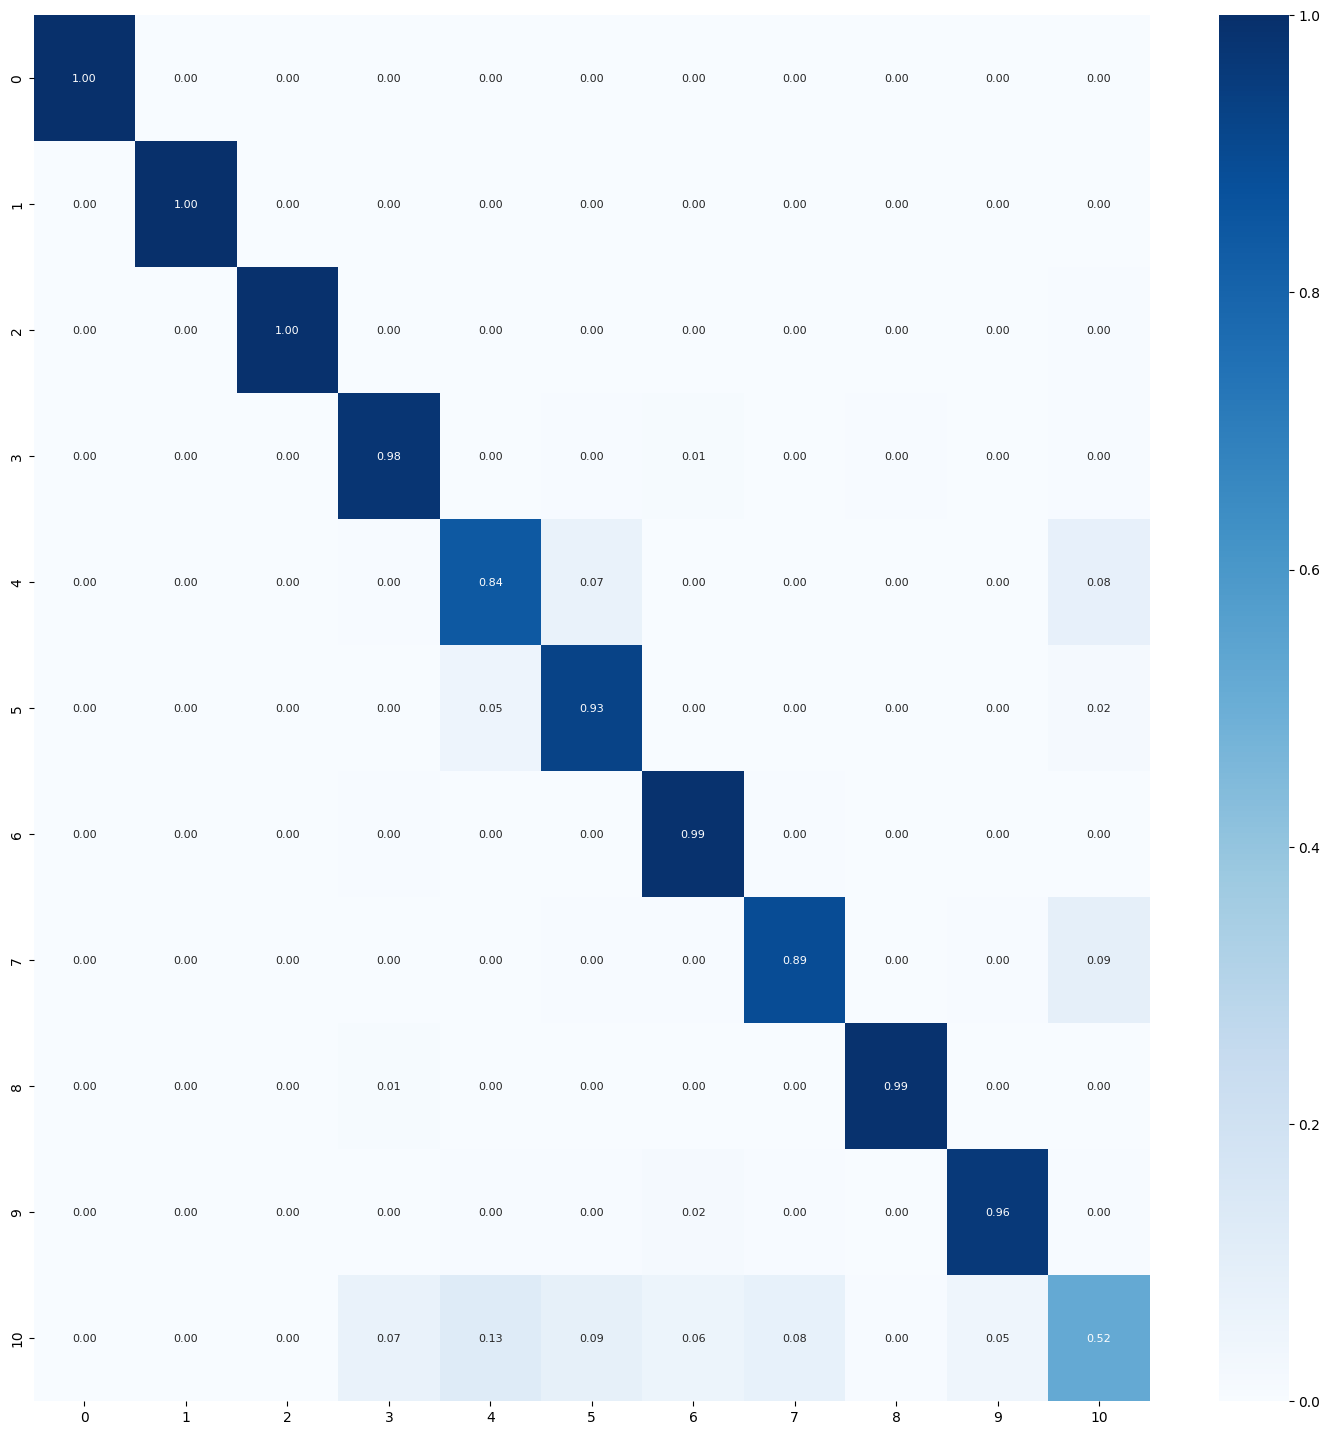


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2793963
Trainable params: 2793611
Non-trainable params: 352
Epoch 1/50
360/360 [==============================] - 67s 159ms/step - loss: 1.7271 - accuracy: 0.8266 - val_loss: 2.9636 - val_accuracy: 0.4396
Epoch 2/50
360/360 [==============================] - 67s 186ms/step - loss: 1.1862 - accuracy: 0.9053 - val_loss: 1.0736 - val_accuracy: 0.9083
Epoch 3/50
360/360 [==============================] - 56s 157ms/step - loss: 0.8790 - accuracy: 0.9269 - val_loss: 0.8120 - val_accuracy: 0.9212
Epoch 4/50
360/360 [==============================] - 66s 184ms/step - loss: 0.6795 - accuracy: 0.9380 - val_loss: 0.7238 - val_accuracy: 0.8804
Epoch 5/50
360/360 [==============================] - 55s 152ms/step - loss: 0.5333 - accuracy: 0.9468 - val_loss: 0.5822 - val_accuracy: 0.9176
Epoch 6/50
360/360 [==============================] - 63s 174ms/step - loss: 0.4488 - accuracy: 0.9513 - val_loss: 0.5244 - val_accuracy: 0.9204
Epoch 7/50
360/360

Model and History saved...
361/361 [==============================] - 46s 127ms/step - loss: 0.1899 - accuracy: 0.9896
Train Accuracy: 0.9896103739738464
Train Log Loss: 0.18989650905132294
78/78 [==============================] - 10s 126ms/step - loss: 0.4249 - accuracy: 0.9354
Validation Accuracy: 0.9353535175323486
Validation Log Loss: 0.42493298649787903
78/78 [==============================] - 10s 125ms/step - loss: 0.4479 - accuracy: 0.9382
Test Accuracy: 0.9381818175315857
Test Log Loss: 0.44790196418762207
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 223   1   0   0   1   0   0   0   0]
 [  0   0   0 217   0   0   4   1   1   1   1]
 [  0   0   0   2 197  10   0   0   0   0  16]
 [  0   0   0   0  15 204   0   0   0   0   6]
 [  0  

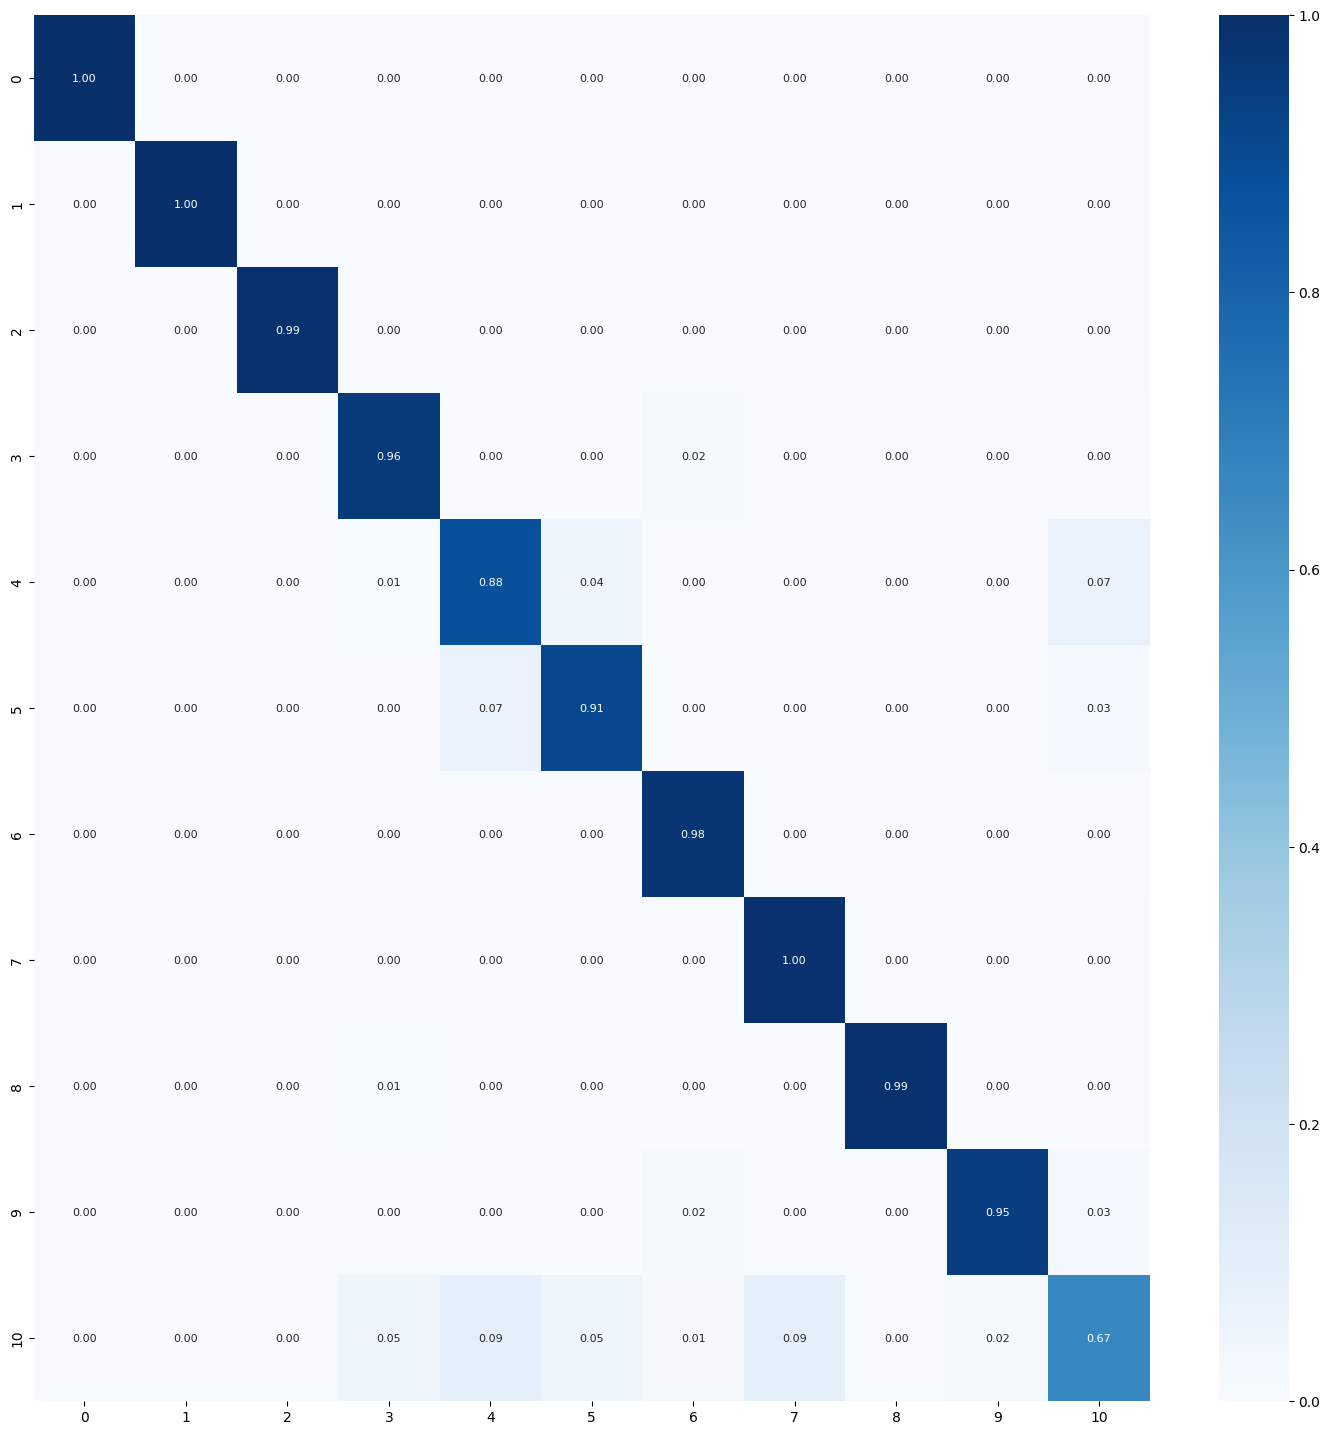

Average training accuracy in 5-fold: 0.9816634893417359
Average validation precision in 5-fold: 0.9314747452735901
/nTest Metrics
test_acc_list: [0.9292929172515869, 0.9296969771385193, 0.9240403771400452, 0.9183838367462158, 0.9381818175315857]
Average Test Accuracy with 5-fold: 0.9279191851615906
test_loss_list: [0.41943052411079407, 0.4790906012058258, 0.477939635515213, 0.4554148316383362, 0.44790196418762207]
Average Test Log Loss with 5-fold: 0.4559555113315582

Precision List: [0.9269228934931804, 0.9281242672499803, 0.9206305164983598, 0.9142647413235804, 0.937171602063011]
Average Precision List with 5-fold: 0.9254228041256225
Recall List: [0.9292929292929292, 0.9296969696969697, 0.924040404040404, 0.9183838383838384, 0.9381818181818182]
Average Recall List with 5-fold: 0.9279191919191918
F1 Score List: [0.9267786218617271, 0.9281266543825155, 0.9206418069049598, 0.9145104631727178, 0.9365667192808249]
Average F1 Score List with 5-fold: 0.9253248531205491

Metrics List Store



In [22]:
%%time


num_classes = 11
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/12
name_save_model: fusion_cnn_basic_150012
Found 12600 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2794028
Trainable params: 2793676
Non-trainable params: 352
Epoch 1/50
393/393 [==============================] - 73s 163ms/step - loss: 1.7862 - accuracy: 0.8222 - val_loss: 1.9978 - val_accuracy: 0.7233
Epoch 2/50
393/393 [==============================] - 60s 152ms/step - loss: 1.1856 - accuracy: 0.9120 - val_loss: 1.0416 - val_accuracy: 0.9137
Epoch 3/50
393/393 [==============================] - 54s 138ms/step - loss: 0.8762 - accuracy: 0.9320 - val_loss: 0.8570 - val_accuracy: 0.9063
Epoch 4/50
393/393 [=========================

Model and History saved...
394/394 [==============================] - 49s 124ms/step - loss: 0.2325 - accuracy: 0.9848
Train Accuracy: 0.9848412871360779
Train Log Loss: 0.2324875146150589
85/85 [==============================] - 11s 127ms/step - loss: 0.5118 - accuracy: 0.9200
Validation Accuracy: 0.9200000166893005
Validation Log Loss: 0.5117637515068054
85/85 [==============================] - 11s 130ms/step - loss: 0.5281 - accuracy: 0.9178
Test Accuracy: 0.9177777767181396
Test Log Loss: 0.5280953049659729
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 210   2   0   0   0   4   0   8   1]
 [  0   0   0   4 208   0   1   4   0   0   5   3]
 [  0   0   0   0   1

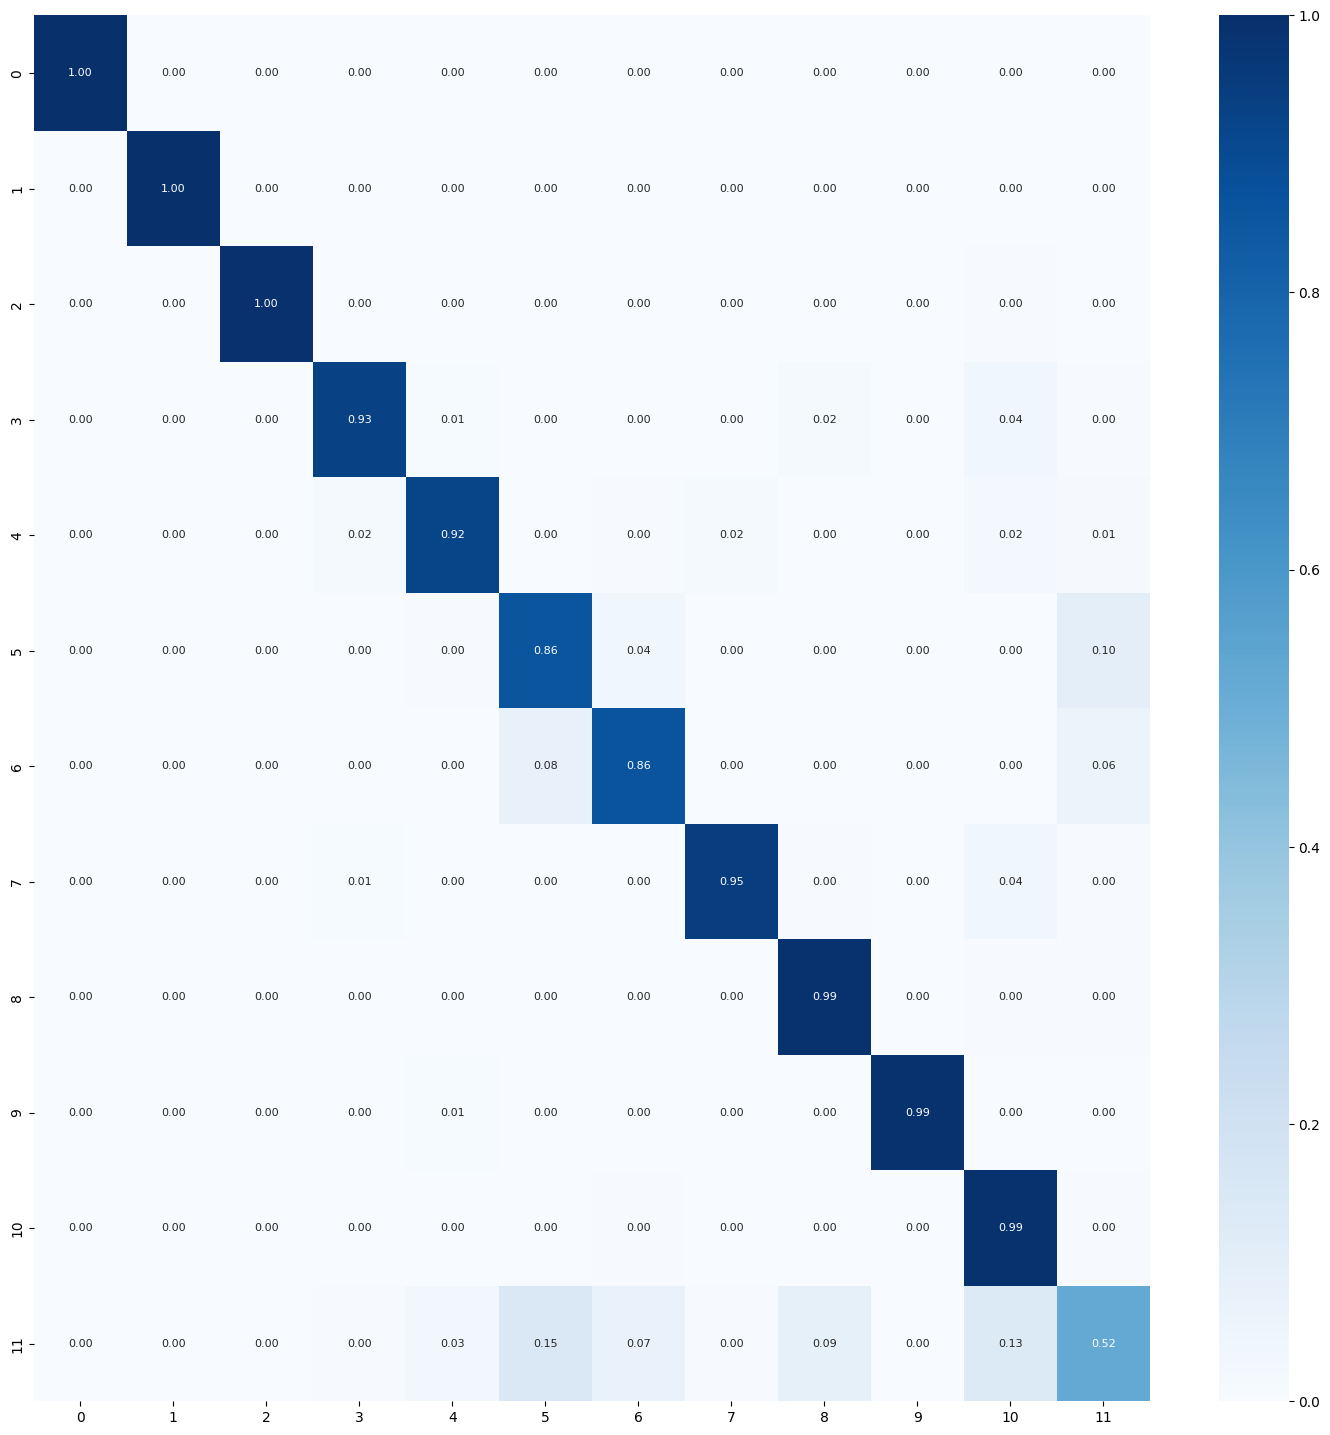


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2794028
Trainable params: 2793676
Non-trainable params: 352
Epoch 1/50
393/393 [==============================] - 69s 156ms/step - loss: 1.7605 - accuracy: 0.8230 - val_loss: 2.3619 - val_accuracy: 0.5648
Epoch 2/50
393/393 [==============================] - 61s 154ms/step - loss: 1.1744 - accuracy: 0.9083 - val_loss: 1.1274 - val_accuracy: 0.8293
Epoch 3/50
393/393 [==============================] - 60s 152ms/step - loss: 0.8659 - accuracy: 0.9278 - val_loss: 0.8425 - val_accuracy: 0.9070
Epoch 4/50
393/393 [==============================] - 60s 152ms/step - loss: 0.6660 - accuracy: 0.9404 - val_loss: 0.6787 - val_accuracy: 0.9148
Epoch 5/50
393/393 [==============================] - 59s 150ms/step - loss: 0.5242 - accuracy: 0.9480 - val_loss: 0.5772 - val_accuracy: 0.9119
Epoch 6/50
393/393 [==============================] - 61s 154ms/step - loss: 0.4347 - accuracy: 0.9566 - val_loss: 0.5854 - val_accuracy: 0.9119
Epoch 7/50
393/393

Model and History saved...
394/394 [==============================] - 52s 131ms/step - loss: 0.3880 - accuracy: 0.9420
Train Accuracy: 0.9419841170310974
Train Log Loss: 0.38796770572662354
85/85 [==============================] - 11s 131ms/step - loss: 0.6311 - accuracy: 0.8763
Validation Accuracy: 0.8762962818145752
Validation Log Loss: 0.6310893893241882
85/85 [==============================] - 12s 134ms/step - loss: 0.6231 - accuracy: 0.8752
Test Accuracy: 0.8751851916313171
Test Log Loss: 0.6231148838996887
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   1   0   0   0   0   0   0   0]
 [  0   0   0 216   4   0   0   1   3   0   0   1]
 [  0   0   0   4 216   0   1   1   0   1   0   2]
 [  0   0   0   0   

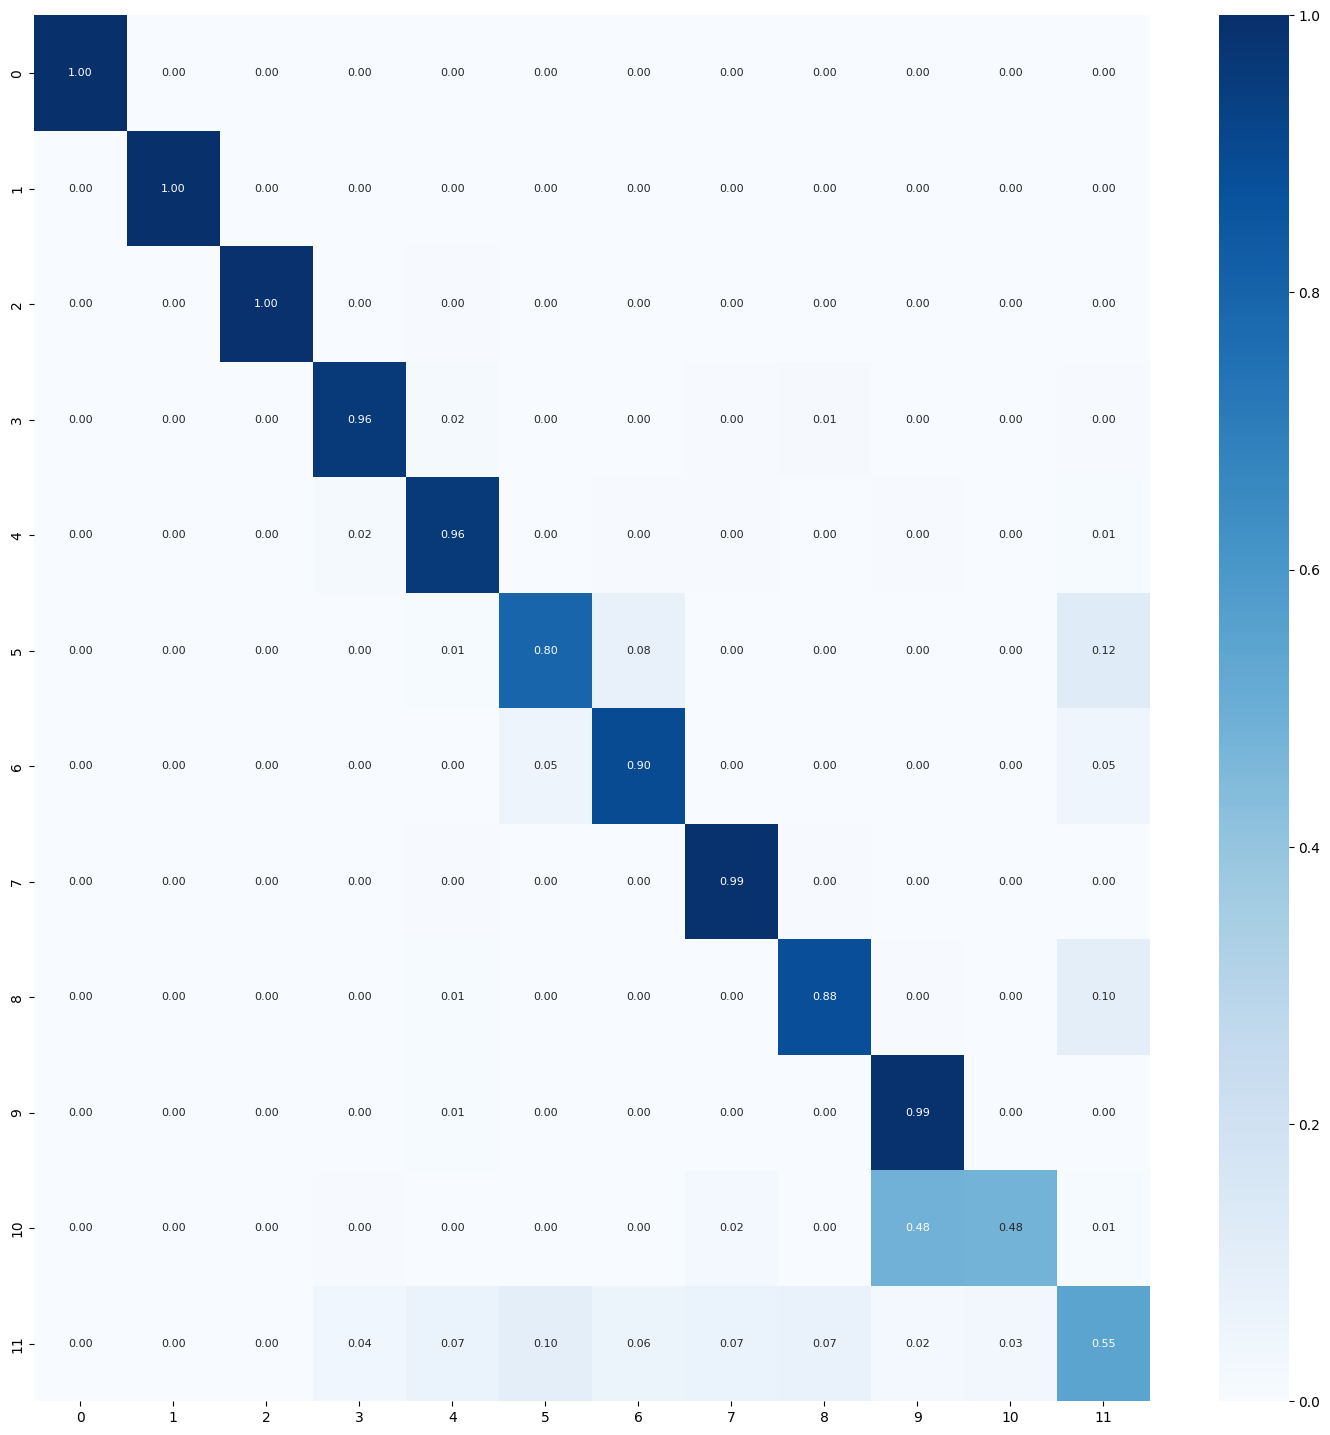


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2794028
Trainable params: 2793676
Non-trainable params: 352
Epoch 1/50
393/393 [==============================] - 70s 158ms/step - loss: 1.7300 - accuracy: 0.8384 - val_loss: 2.0364 - val_accuracy: 0.6996
Epoch 2/50
393/393 [==============================] - 61s 156ms/step - loss: 1.1804 - accuracy: 0.9081 - val_loss: 1.0165 - val_accuracy: 0.9093
Epoch 3/50
393/393 [==============================] - 62s 157ms/step - loss: 0.8693 - accuracy: 0.9319 - val_loss: 0.8242 - val_accuracy: 0.9119
Epoch 4/50
393/393 [==============================] - 61s 154ms/step - loss: 0.6592 - accuracy: 0.9461 - val_loss: 0.6683 - val_accuracy: 0.9196
Epoch 5/50
393/393 [==============================] - 61s 154ms/step - loss: 0.5308 - accuracy: 0.9513 - val_loss: 0.6109 - val_accuracy: 0.9133
Epoch 6/50
393/393 [==============================] - 65s 166ms/step - loss: 0.4467 - accuracy: 0.9562 - val_loss: 0.5725 - val_accuracy: 0.9148
Epoch 7/50
393/393

Model and History saved...
394/394 [==============================] - 53s 133ms/step - loss: 0.2323 - accuracy: 0.9830
Train Accuracy: 0.9830158948898315
Train Log Loss: 0.23232388496398926
85/85 [==============================] - 11s 129ms/step - loss: 0.5164 - accuracy: 0.9215
Validation Accuracy: 0.9214814901351929
Validation Log Loss: 0.5163769721984863
85/85 [==============================] - 12s 137ms/step - loss: 0.5462 - accuracy: 0.9222
Test Accuracy: 0.9222221970558167
Test Log Loss: 0.546230673789978
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 217   2   0   0   0   5   0   1   0]
 [  0   0   1   2 211   0   1   5   0   0   3   2]
 [  0   0   0   0   2

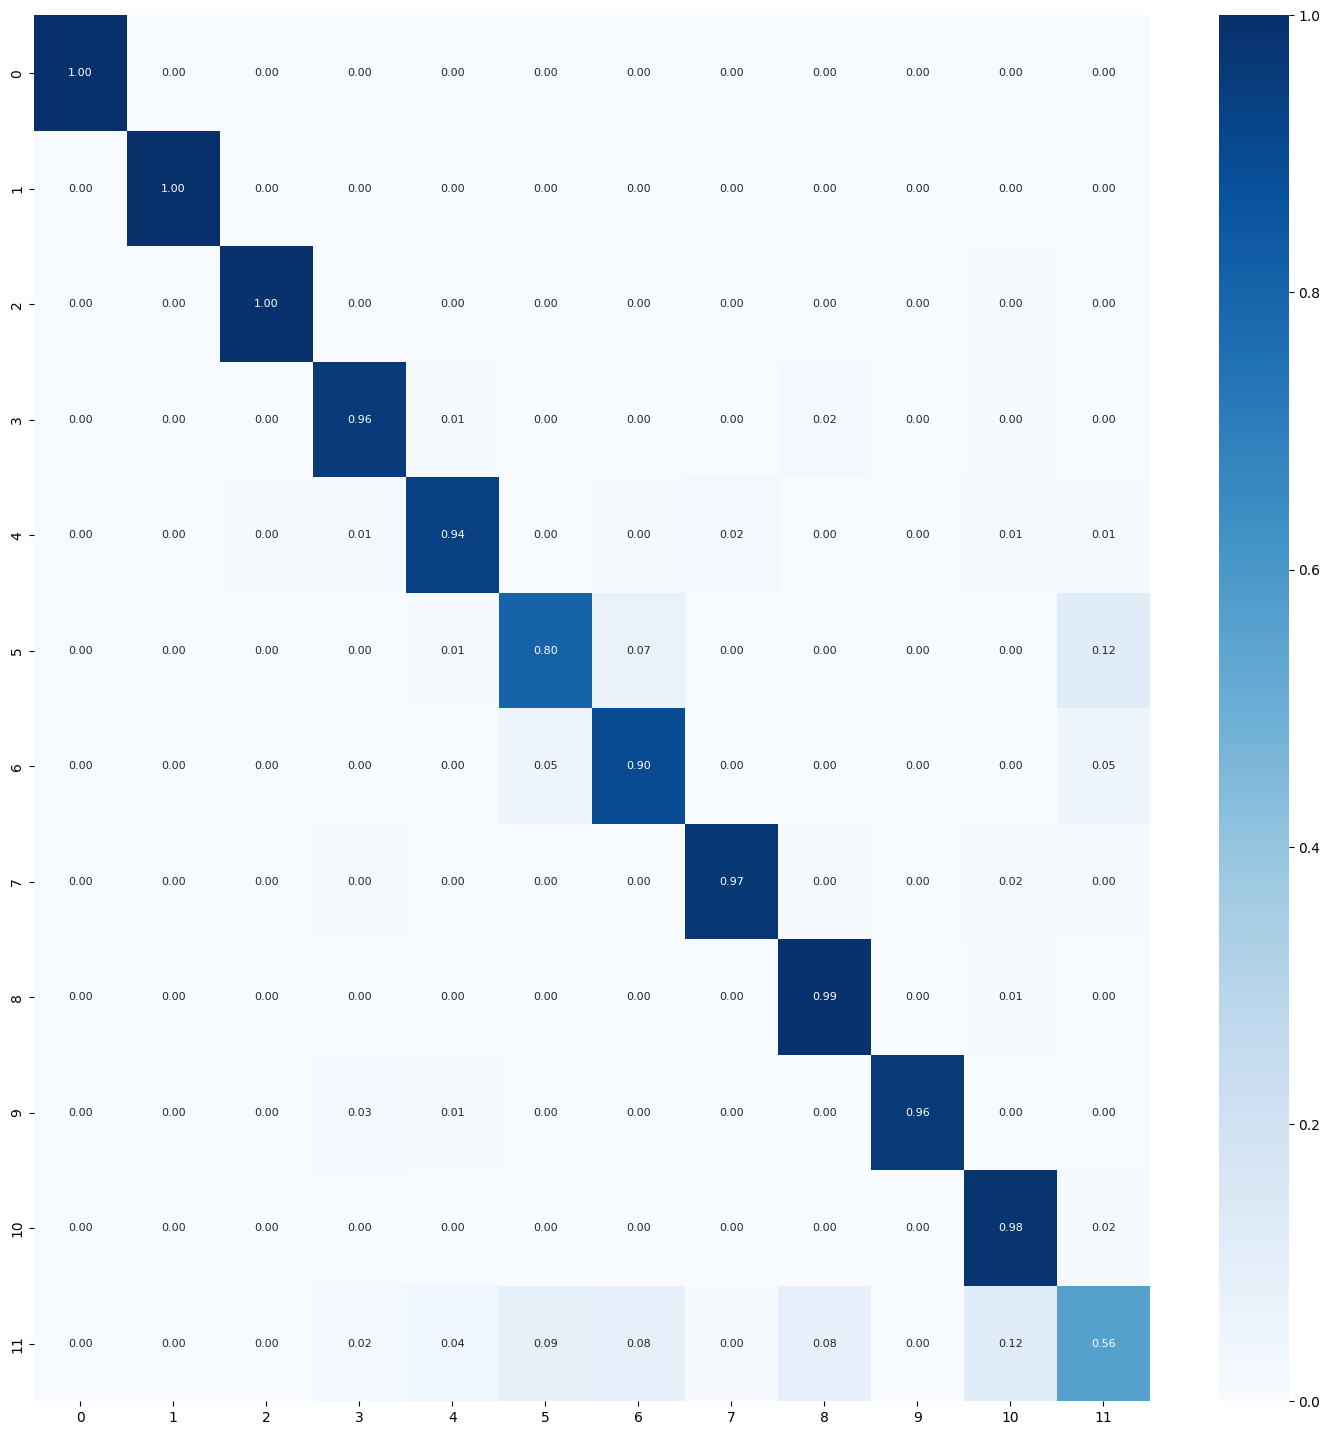


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2794028
Trainable params: 2793676
Non-trainable params: 352
Epoch 1/50
393/393 [==============================] - 71s 161ms/step - loss: 1.7729 - accuracy: 0.8201 - val_loss: 2.6901 - val_accuracy: 0.4963
Epoch 2/50
393/393 [==============================] - 63s 160ms/step - loss: 1.1880 - accuracy: 0.9099 - val_loss: 1.0932 - val_accuracy: 0.8996
Epoch 3/50
393/393 [==============================] - 65s 165ms/step - loss: 0.8784 - accuracy: 0.9308 - val_loss: 0.8199 - val_accuracy: 0.9200
Epoch 4/50
393/393 [==============================] - 62s 159ms/step - loss: 0.6658 - accuracy: 0.9431 - val_loss: 0.6728 - val_accuracy: 0.9144
Epoch 5/50
393/393 [==============================] - 64s 163ms/step - loss: 0.5365 - accuracy: 0.9464 - val_loss: 0.5759 - val_accuracy: 0.9241
Epoch 6/50
393/393 [==============================] - 64s 164ms/step - loss: 0.4379 - accuracy: 0.9563 - val_loss: 0.6088 - val_accuracy: 0.8530
Epoch 7/50
393/393

Model and History saved...
394/394 [==============================] - 51s 129ms/step - loss: 0.2122 - accuracy: 0.9876
Train Accuracy: 0.9876190423965454
Train Log Loss: 0.21215412020683289
85/85 [==============================] - 11s 129ms/step - loss: 0.4673 - accuracy: 0.9285
Validation Accuracy: 0.928518533706665
Validation Log Loss: 0.46727678179740906
85/85 [==============================] - 11s 126ms/step - loss: 0.4902 - accuracy: 0.9352
Test Accuracy: 0.9351851940155029
Test Log Loss: 0.4902208149433136
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 212   3   0   0   0   4   0   4   2]
 [  0   0   0   1 221   0   0   1   0   1   0   1]
 [  0   0   0   0   

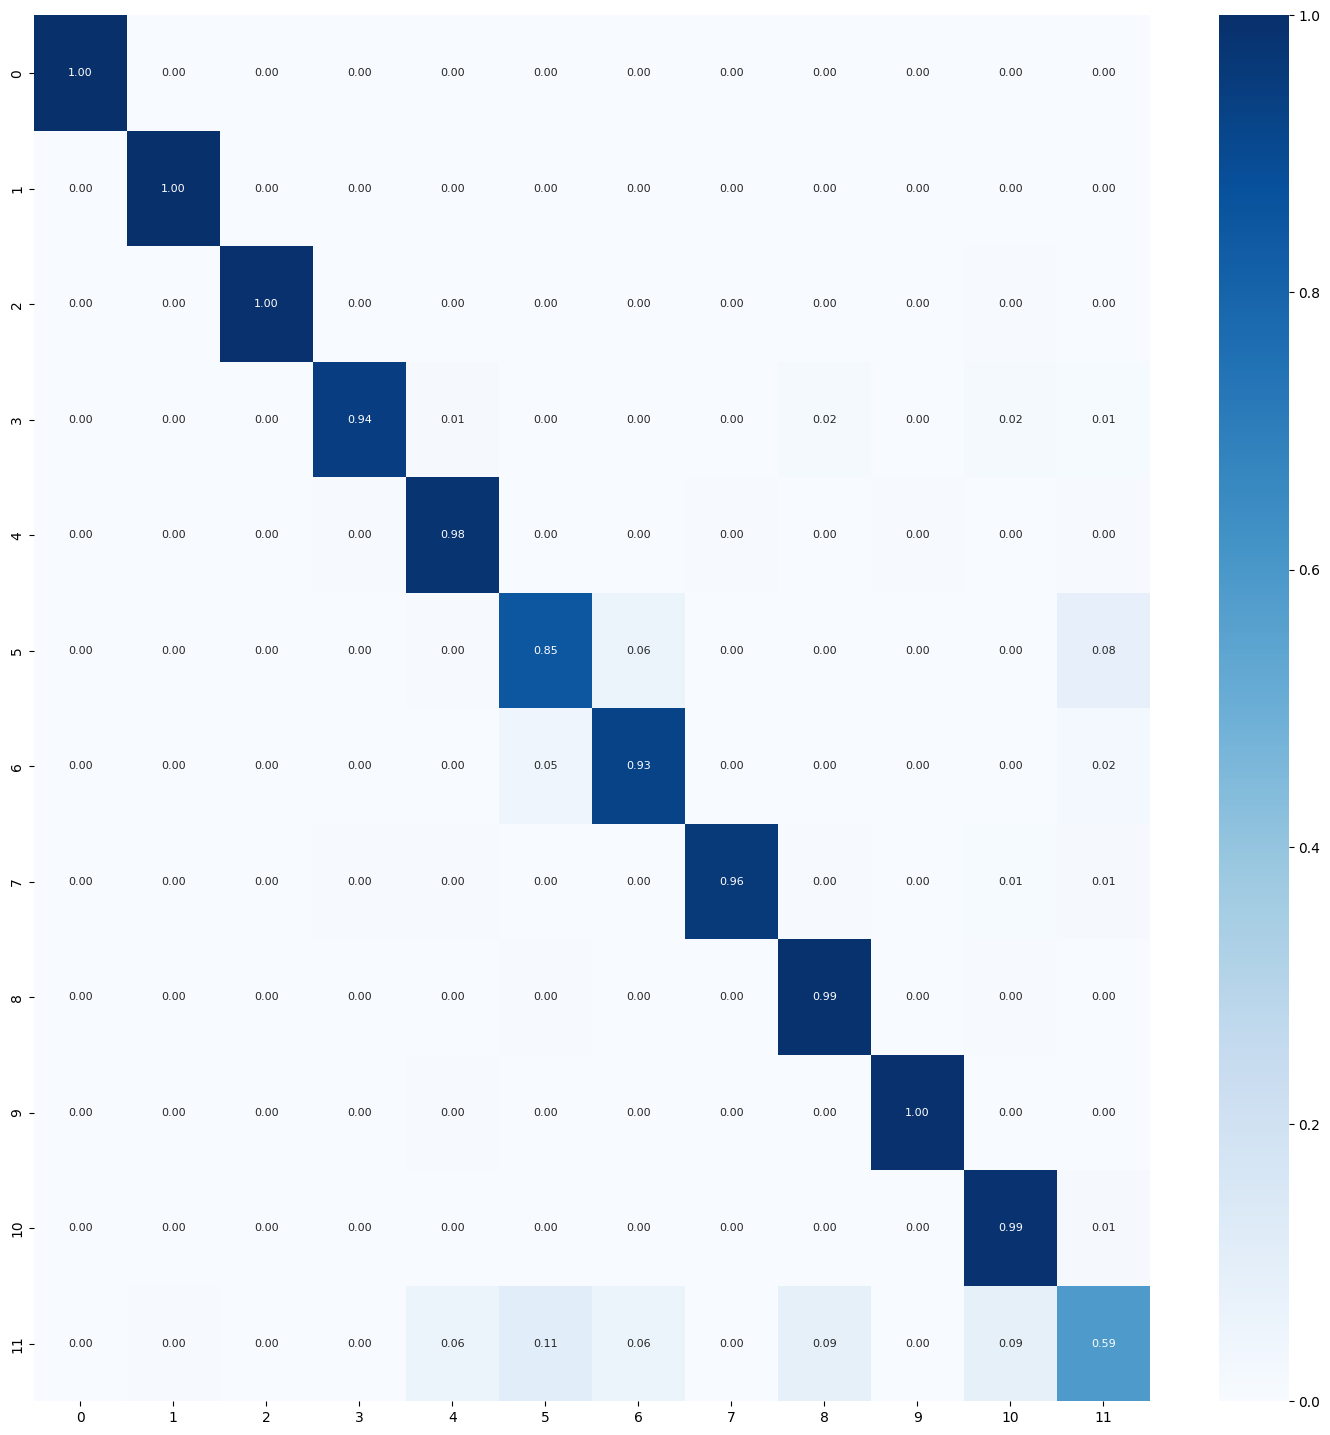


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2794028
Trainable params: 2793676
Non-trainable params: 352
Epoch 1/50
393/393 [==============================] - 69s 156ms/step - loss: 1.7902 - accuracy: 0.8180 - val_loss: 2.0374 - val_accuracy: 0.6656
Epoch 2/50
393/393 [==============================] - 60s 152ms/step - loss: 1.1995 - accuracy: 0.9082 - val_loss: 1.0478 - val_accuracy: 0.9137
Epoch 3/50
393/393 [==============================] - 61s 156ms/step - loss: 0.9007 - accuracy: 0.9256 - val_loss: 0.8317 - val_accuracy: 0.9137
Epoch 4/50
393/393 [==============================] - 60s 153ms/step - loss: 0.6870 - accuracy: 0.9384 - val_loss: 0.6909 - val_accuracy: 0.9133
Epoch 5/50
393/393 [==============================] - 61s 154ms/step - loss: 0.5429 - accuracy: 0.9510 - val_loss: 0.5915 - val_accuracy: 0.9207
Epoch 6/50
393/393 [==============================] - 60s 153ms/step - loss: 0.4556 - accuracy: 0.9549 - val_loss: 0.5479 - val_accuracy: 0.9133
Epoch 7/50
393/393

Model and History saved...
394/394 [==============================] - 60s 153ms/step - loss: 0.2160 - accuracy: 0.9889
Train Accuracy: 0.9888888597488403
Train Log Loss: 0.2159767597913742
85/85 [==============================] - 13s 154ms/step - loss: 0.4816 - accuracy: 0.9248
Validation Accuracy: 0.9248148202896118
Validation Log Loss: 0.4815857410430908
85/85 [==============================] - 13s 156ms/step - loss: 0.4668 - accuracy: 0.9267
Test Accuracy: 0.9266666769981384
Test Log Loss: 0.46681052446365356
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 211   4   0   0   2   8   0   0   0]
 [  0   0   1   1 216   0   0   1   2   0   0   4]
 [  0   0   0   0   

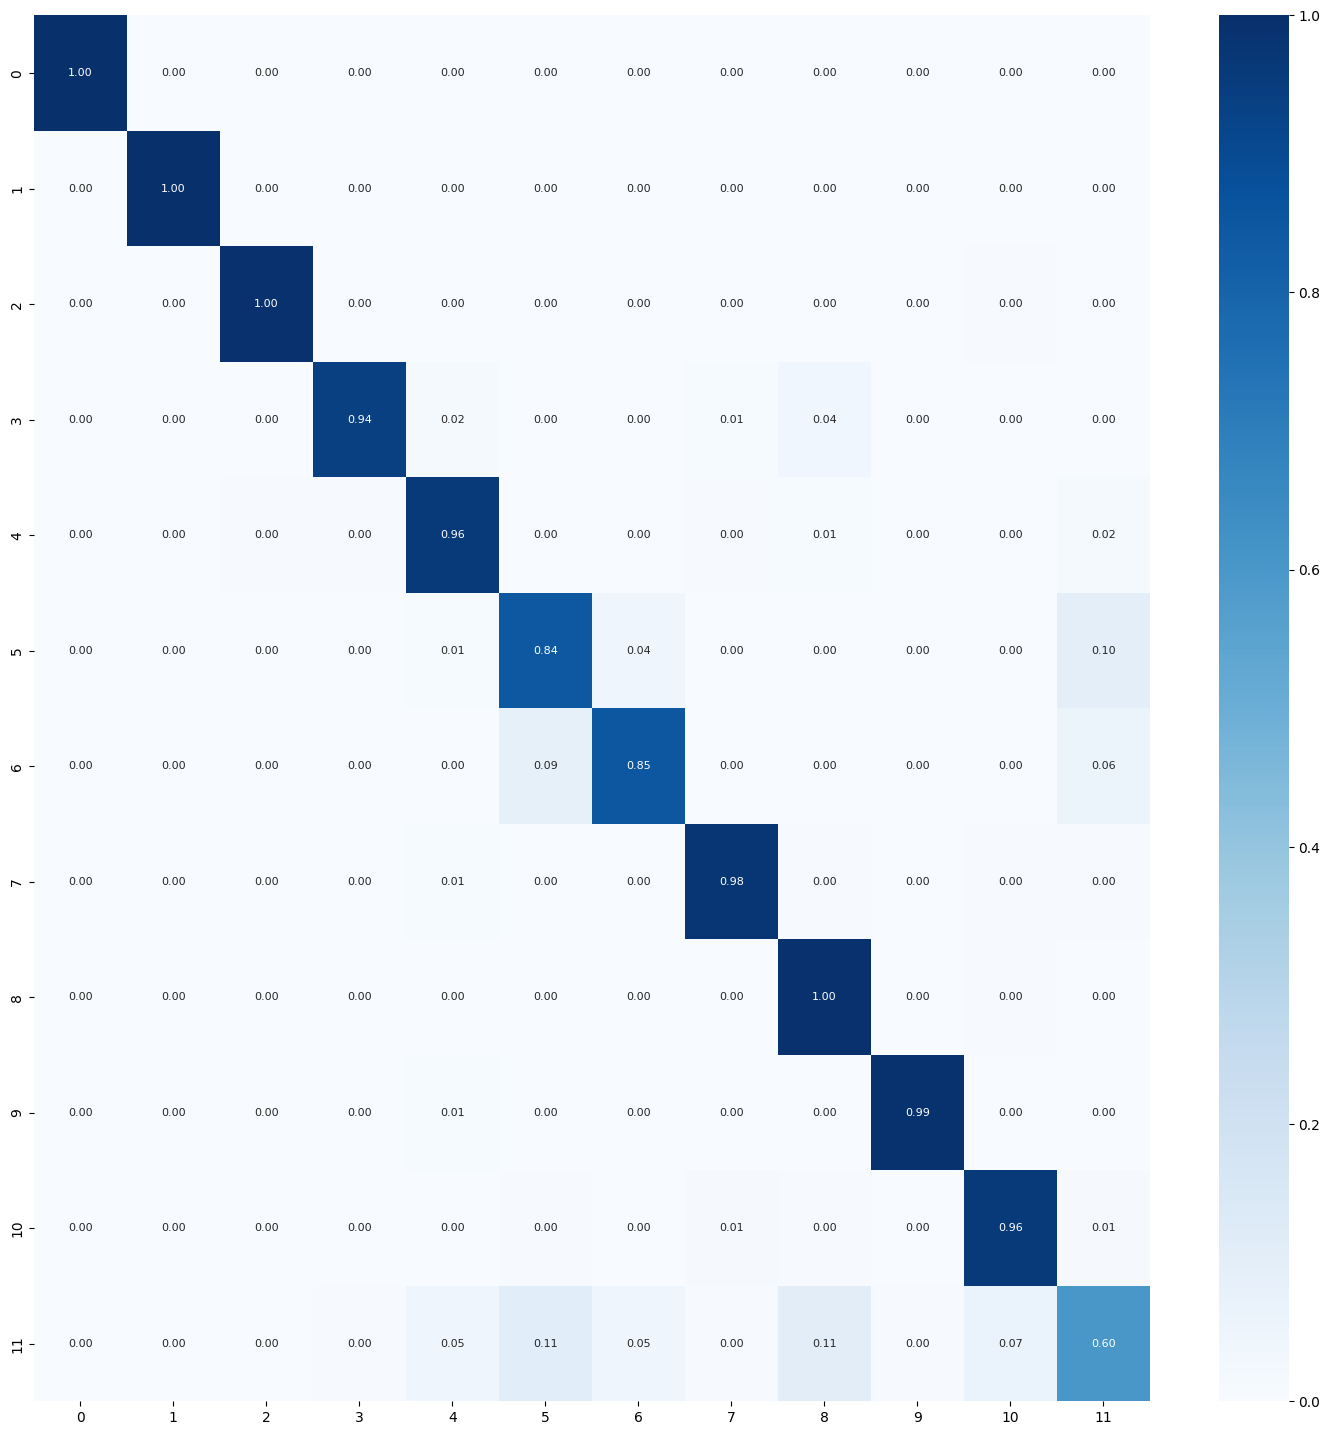

Average training accuracy in 5-fold: 0.9824315667152405
Average validation precision in 5-fold: 0.9314815044403076
/nTest Metrics
test_acc_list: [0.9177777767181396, 0.8751851916313171, 0.9222221970558167, 0.9351851940155029, 0.9266666769981384]
Average Test Accuracy with 5-fold: 0.915407407283783
test_loss_list: [0.5280953049659729, 0.6231148838996887, 0.546230673789978, 0.4902208149433136, 0.46681052446365356]
Average Test Log Loss with 5-fold: 0.5308944404125213

Precision List: [0.9166825169568057, 0.8835304046232882, 0.9198974672846321, 0.9337333788740915, 0.9253840894545102]
Average Precision List with 5-fold: 0.9158455714386655
Recall List: [0.9177777777777778, 0.8751851851851852, 0.9222222222222222, 0.9351851851851851, 0.9266666666666667]
Average Recall List with 5-fold: 0.9154074074074074
F1 Score List: [0.9146702243459783, 0.8696272680473677, 0.9193455641681516, 0.9324808842575121, 0.9247031542067005]
Average F1 Score List with 5-fold: 0.9121654190051421

Metrics List Store



In [23]:
%%time

num_classes = 12
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/13
name_save_model: fusion_cnn_basic_150013
Found 13650 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2794093
Trainable params: 2793741
Non-trainable params: 352
Epoch 1/50
426/426 [==============================] - 82s 171ms/step - loss: 1.7865 - accuracy: 0.8240 - val_loss: 2.4389 - val_accuracy: 0.5791
Epoch 2/50
426/426 [==============================] - 67s 158ms/step - loss: 1.1683 - accuracy: 0.9151 - val_loss: 1.0587 - val_accuracy: 0.9046
Epoch 3/50
426/426 [==============================] - 69s 161ms/step - loss: 0.8533 - accuracy: 0.9347 - val_loss: 0.8312 - val_accuracy: 0.9039
Epoch 4/50
426/426 [================

Model and History saved...
427/427 [==============================] - 56s 130ms/step - loss: 0.2054 - accuracy: 0.9921
Train Accuracy: 0.9920879006385803
Train Log Loss: 0.20539484918117523
92/92 [==============================] - 12s 129ms/step - loss: 0.4260 - accuracy: 0.9299
Validation Accuracy: 0.9299145340919495
Validation Log Loss: 0.42598095536231995
92/92 [==============================] - 12s 129ms/step - loss: 0.4220 - accuracy: 0.9385
Test Accuracy: 0.9384615421295166
Test Log Loss: 0.4219725430011749
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 215   4   0   0   0   1   3   0   0   2]
 [  0   0   0   1 221   0   0   0   1   

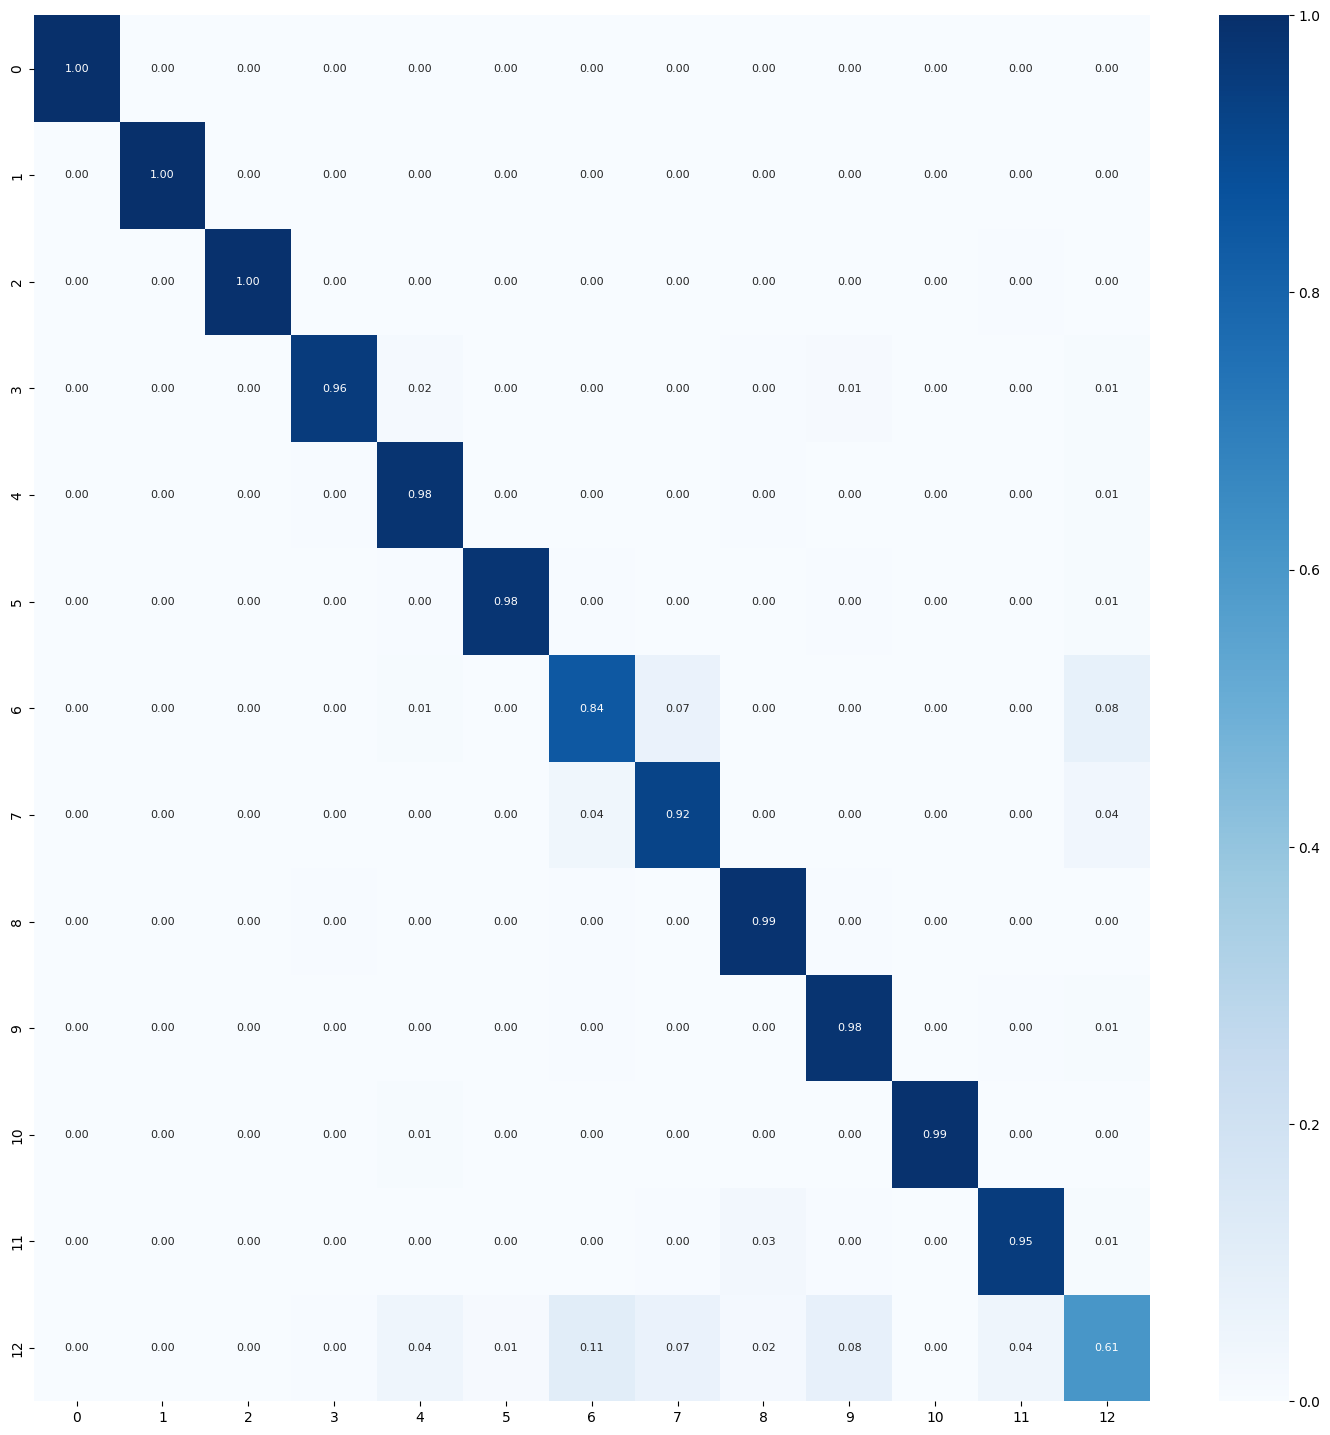


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2794093
Trainable params: 2793741
Non-trainable params: 352
Epoch 1/50
426/426 [==============================] - 73s 153ms/step - loss: 1.7661 - accuracy: 0.8257 - val_loss: 2.2624 - val_accuracy: 0.6882
Epoch 2/50
426/426 [==============================] - 66s 154ms/step - loss: 1.1417 - accuracy: 0.9150 - val_loss: 1.0080 - val_accuracy: 0.8844
Epoch 3/50
426/426 [==============================] - 67s 156ms/step - loss: 0.8176 - accuracy: 0.9355 - val_loss: 0.7674 - val_accuracy: 0.9149
Epoch 4/50
426/426 [==============================] - 68s 158ms/step - loss: 0.6130 - accuracy: 0.9470 - val_loss: 0.6510 - val_accuracy: 0.9285
Epoch 5/50
426/426 [==============================] - 68s 159ms/step - loss: 0.4884 - accuracy: 0.9569 - val_loss: 0.5826 - val_accuracy: 0.9138
Epoch 6/50
426/426 [==============================] - 66s 156ms/step - loss: 0.4117 - accuracy: 0.9620 - val_loss: 0.5329 - val_accuracy: 0.9176
Epoch 7/50
426/426

Model and History saved...
427/427 [==============================] - 66s 155ms/step - loss: 0.2467 - accuracy: 0.9834
Train Accuracy: 0.9833699464797974
Train Log Loss: 0.24671204388141632
92/92 [==============================] - 14s 153ms/step - loss: 0.4820 - accuracy: 0.9244
Validation Accuracy: 0.9244444370269775
Validation Log Loss: 0.4819868803024292
92/92 [==============================] - 14s 152ms/step - loss: 0.4508 - accuracy: 0.9285
Test Accuracy: 0.9285470247268677
Test Log Loss: 0.4507572054862976
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 215   2   0   0   0   0   4   0   2   2]
 [  0   0   1   1 219   1   0   0   0   0

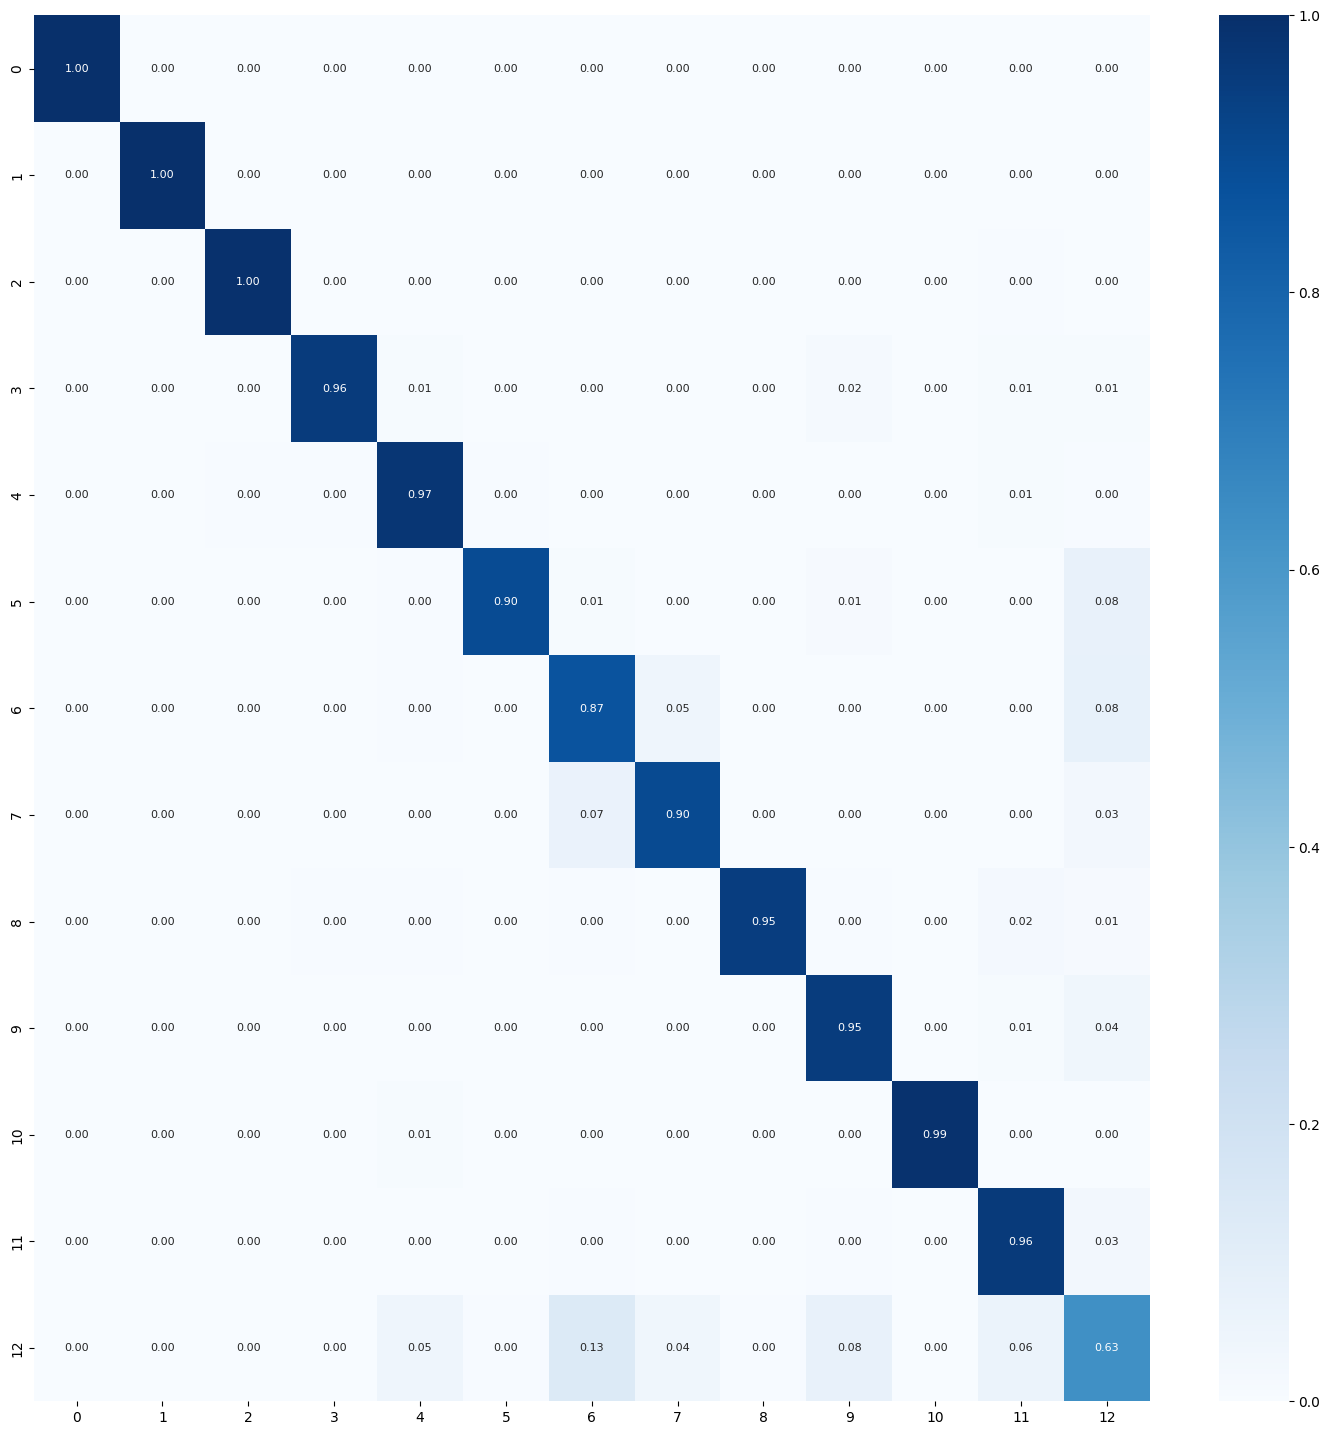


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2794093
Trainable params: 2793741
Non-trainable params: 352
Epoch 1/50
426/426 [==============================] - 92s 191ms/step - loss: 1.7911 - accuracy: 0.8172 - val_loss: 2.2228 - val_accuracy: 0.6444
Epoch 2/50
426/426 [==============================] - 83s 195ms/step - loss: 1.1680 - accuracy: 0.9107 - val_loss: 1.0089 - val_accuracy: 0.9125
Epoch 3/50
426/426 [==============================] - 74s 173ms/step - loss: 0.8396 - accuracy: 0.9344 - val_loss: 0.7884 - val_accuracy: 0.9173
Epoch 4/50
426/426 [==============================] - 62s 145ms/step - loss: 0.6424 - accuracy: 0.9434 - val_loss: 0.6756 - val_accuracy: 0.9118
Epoch 5/50
426/426 [==============================] - 75s 175ms/step - loss: 0.5180 - accuracy: 0.9502 - val_loss: 0.5975 - val_accuracy: 0.9032
Epoch 6/50
426/426 [==============================] - 80s 187ms/step - loss: 0.4260 - accuracy: 0.9570 - val_loss: 0.5435 - val_accuracy: 0.9097
Epoch 7/50
426/426

Model and History saved...
427/427 [==============================] - 56s 131ms/step - loss: 0.2242 - accuracy: 0.9891
Train Accuracy: 0.9890842437744141
Train Log Loss: 0.2241860330104828
92/92 [==============================] - 12s 127ms/step - loss: 0.4525 - accuracy: 0.9275
Validation Accuracy: 0.9275213479995728
Validation Log Loss: 0.45251455903053284
92/92 [==============================] - 13s 135ms/step - loss: 0.4585 - accuracy: 0.9326
Test Accuracy: 0.932649552822113
Test Log Loss: 0.45854151248931885
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 214   2   0   0   0   0   4   0   3   2]
 [  0   0   1   2 215   1   0   0   1   1

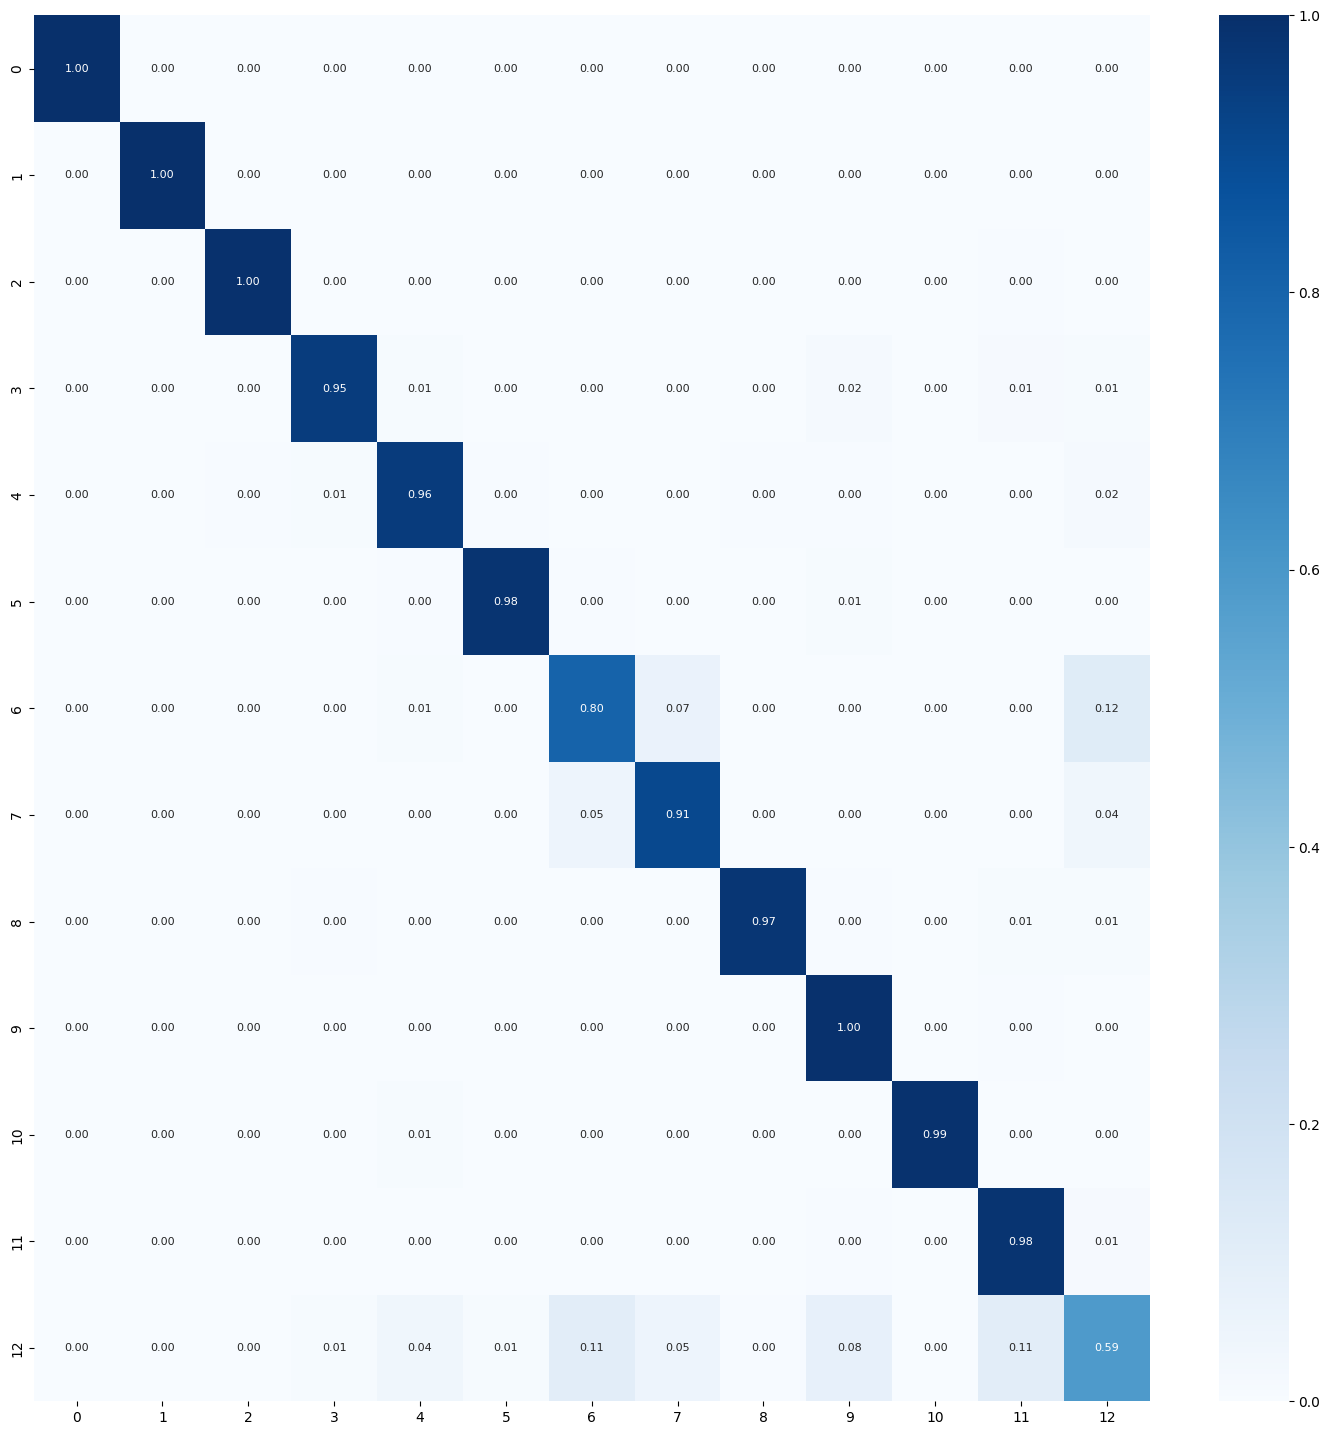


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2794093
Trainable params: 2793741
Non-trainable params: 352
Epoch 1/50
426/426 [==============================] - 76s 158ms/step - loss: 1.7708 - accuracy: 0.8259 - val_loss: 2.0312 - val_accuracy: 0.6393
Epoch 2/50
426/426 [==============================] - 76s 178ms/step - loss: 1.1527 - accuracy: 0.9132 - val_loss: 1.0086 - val_accuracy: 0.9063
Epoch 3/50
426/426 [==============================] - 70s 164ms/step - loss: 0.8304 - accuracy: 0.9319 - val_loss: 0.7671 - val_accuracy: 0.9125
Epoch 4/50
426/426 [==============================] - 71s 166ms/step - loss: 0.6108 - accuracy: 0.9457 - val_loss: 0.6548 - val_accuracy: 0.9159
Epoch 5/50
426/426 [==============================] - 69s 162ms/step - loss: 0.4975 - accuracy: 0.9501 - val_loss: 0.5972 - val_accuracy: 0.9169
Epoch 6/50
426/426 [==============================] - 69s 163ms/step - loss: 0.4194 - accuracy: 0.9536 - val_loss: 0.5633 - val_accuracy: 0.9080
Epoch 7/50
426/426

Model and History saved...
427/427 [==============================] - 59s 138ms/step - loss: 0.2520 - accuracy: 0.9829
Train Accuracy: 0.9828571677207947
Train Log Loss: 0.25198838114738464
92/92 [==============================] - 13s 138ms/step - loss: 0.5457 - accuracy: 0.9197
Validation Accuracy: 0.9196581244468689
Validation Log Loss: 0.5456551909446716
92/92 [==============================] - 13s 142ms/step - loss: 0.5226 - accuracy: 0.9258
Test Accuracy: 0.9258119463920593
Test Log Loss: 0.5226336121559143
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 190   5   0   0   0   0  20   0   7   3]
 [  0   0   1   0 220   0   0   0   0   0

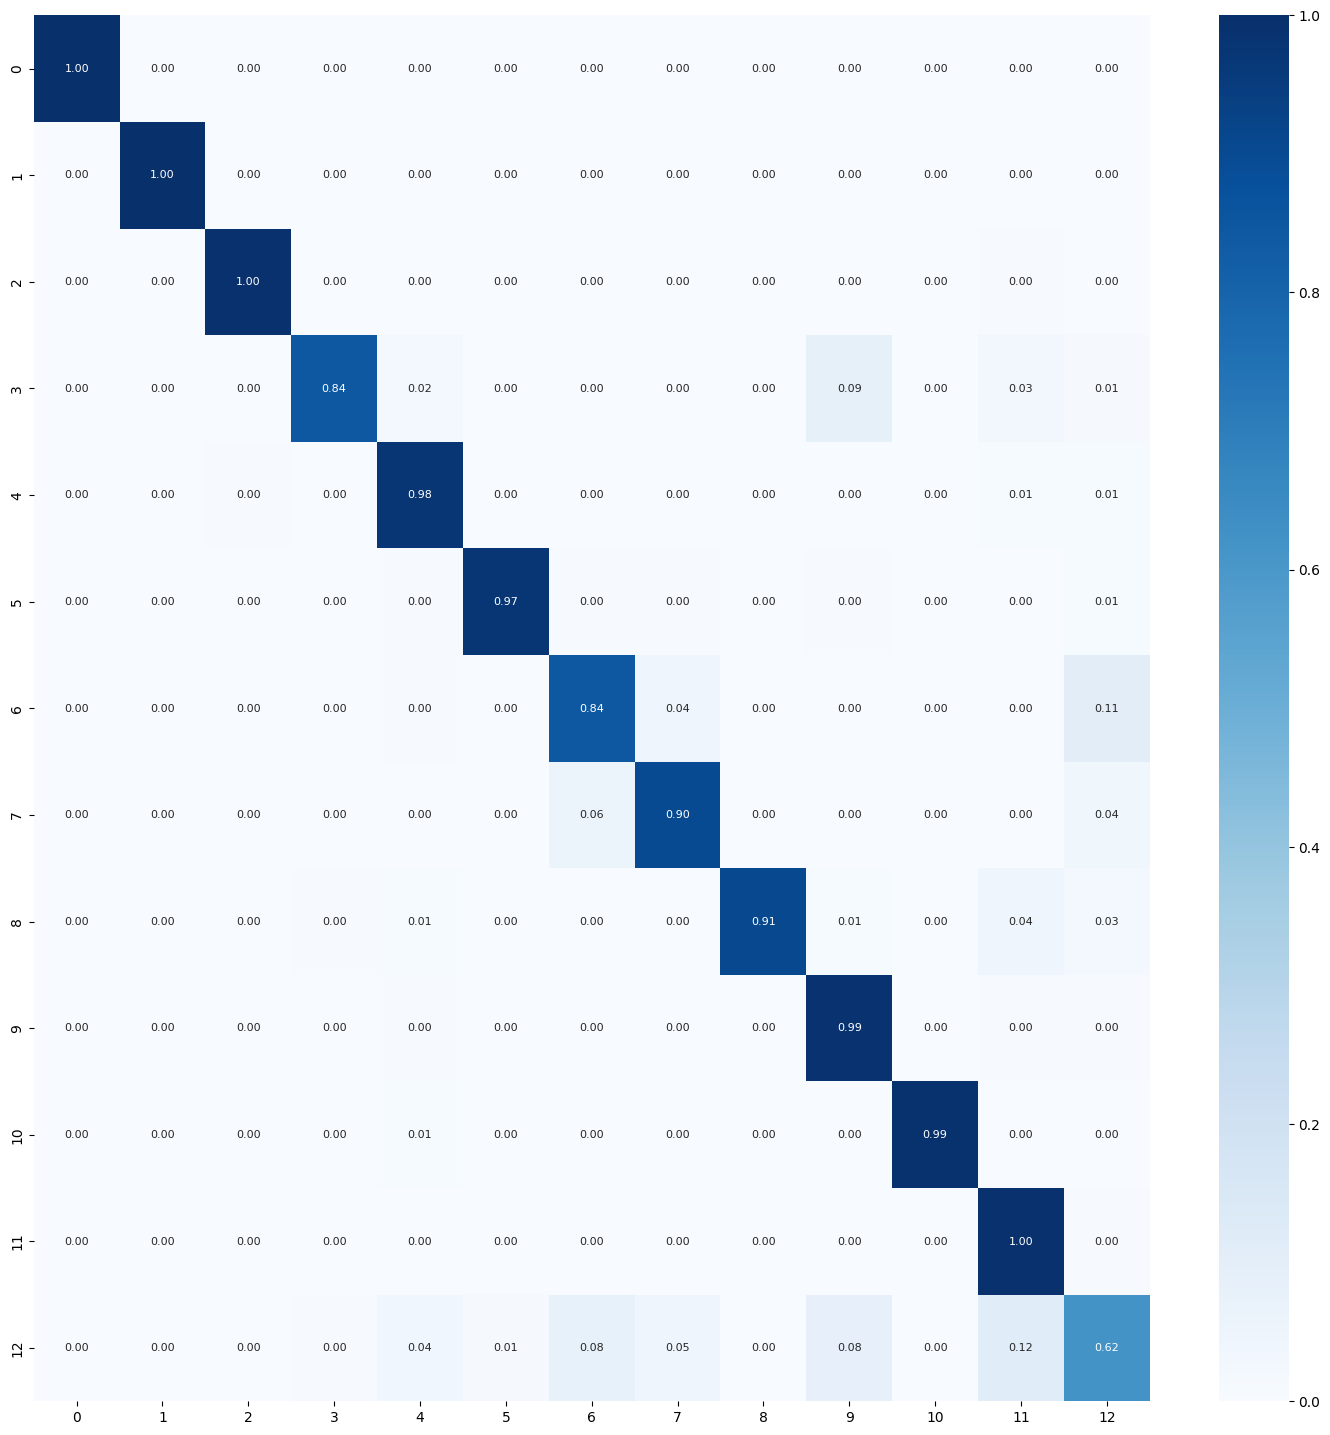


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2794093
Trainable params: 2793741
Non-trainable params: 352
Epoch 1/50
426/426 [==============================] - 80s 168ms/step - loss: 1.7360 - accuracy: 0.8352 - val_loss: 2.0815 - val_accuracy: 0.6509
Epoch 2/50
426/426 [==============================] - 69s 161ms/step - loss: 1.1352 - accuracy: 0.9142 - val_loss: 1.0083 - val_accuracy: 0.9121
Epoch 3/50
426/426 [==============================] - 64s 150ms/step - loss: 0.8098 - accuracy: 0.9353 - val_loss: 0.7681 - val_accuracy: 0.9183
Epoch 4/50
426/426 [==============================] - 72s 169ms/step - loss: 0.6118 - accuracy: 0.9480 - val_loss: 0.6777 - val_accuracy: 0.9084
Epoch 5/50
426/426 [==============================] - 73s 171ms/step - loss: 0.4804 - accuracy: 0.9576 - val_loss: 0.5659 - val_accuracy: 0.9135
Epoch 6/50
426/426 [==============================] - 73s 171ms/step - loss: 0.4126 - accuracy: 0.9577 - val_loss: 0.5590 - val_accuracy: 0.9118
Epoch 7/50
426/426

Model and History saved...
427/427 [==============================] - 63s 147ms/step - loss: 0.2233 - accuracy: 0.9884
Train Accuracy: 0.9883516430854797
Train Log Loss: 0.22329267859458923
92/92 [==============================] - 14s 152ms/step - loss: 0.4817 - accuracy: 0.9238
Validation Accuracy: 0.923760712146759
Validation Log Loss: 0.48172613978385925
92/92 [==============================] - 14s 154ms/step - loss: 0.4823 - accuracy: 0.9296
Test Accuracy: 0.9295726418495178
Test Log Loss: 0.4823387861251831
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 210   5   0   0   0   2   3   0   1   4]
 [  0   0   0   0 217   2   0   1   1   0

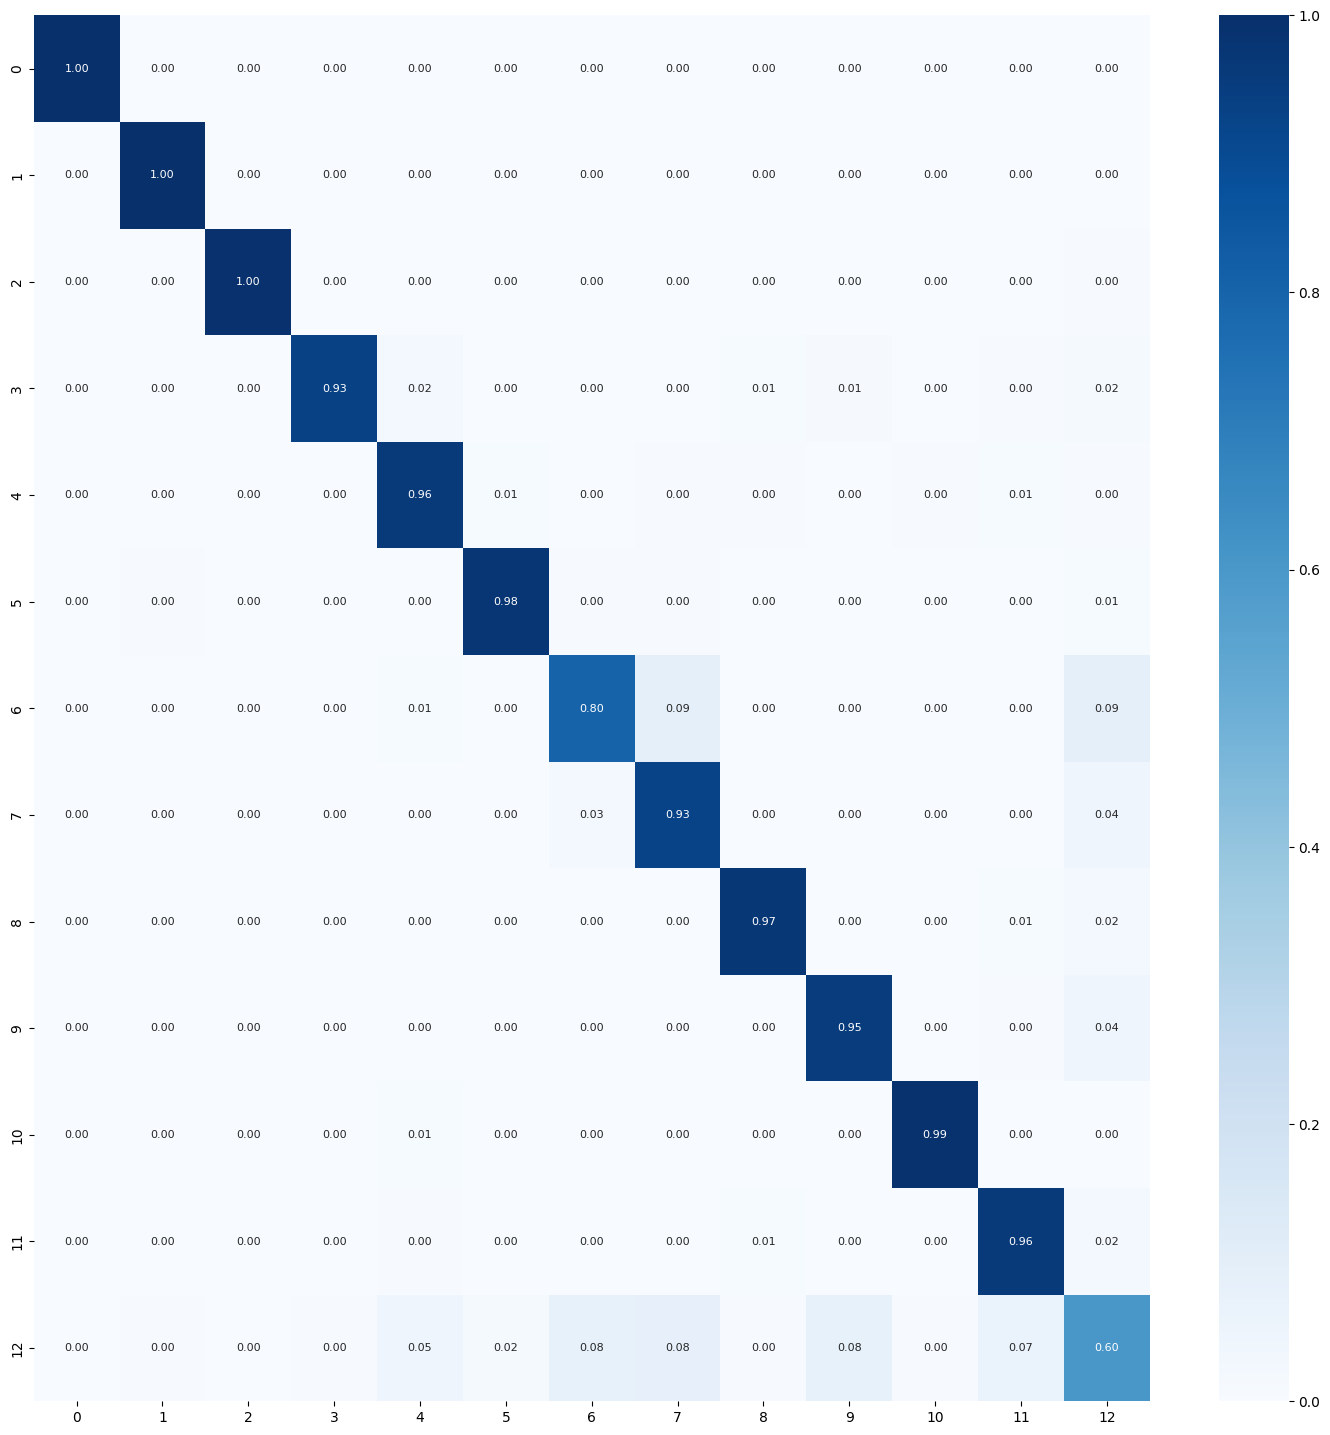

Average training accuracy in 5-fold: 0.9825672030448913
Average validation precision in 5-fold: 0.9342222213745117
/nTest Metrics
test_acc_list: [0.9384615421295166, 0.9285470247268677, 0.932649552822113, 0.9258119463920593, 0.9295726418495178]
Average Test Accuracy with 5-fold: 0.9310085415840149
test_loss_list: [0.4219725430011749, 0.4507572054862976, 0.45854151248931885, 0.5226336121559143, 0.4823387861251831]
Average Test Log Loss with 5-fold: 0.4672487318515778

Precision List: [0.9368291047785007, 0.9291504651955159, 0.9305933154700095, 0.9274740757487123, 0.9282415785815421]
Average Precision List with 5-fold: 0.9304577079548562
Recall List: [0.9384615384615385, 0.9285470085470086, 0.9326495726495726, 0.9258119658119658, 0.9295726495726496]
Average Recall List with 5-fold: 0.931008547008547
F1 Score List: [0.9363769459969679, 0.928179149278452, 0.9304381774507683, 0.9244466278637472, 0.9280969803658418]
Average F1 Score List with 5-fold: 0.9295075761911555

Metrics List Store

t

In [24]:
%%time

num_classes = 13
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/14
name_save_model: fusion_cnn_basic_150014
Found 14700 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2794158
Trainable params: 2793806
Non-trainable params: 352
Epoch 1/50
459/459 [==============================] - 93s 183ms/step - loss: 1.8676 - accuracy: 0.7793 - val_loss: 1.8013 - val_accuracy: 0.7832
Epoch 2/50
459/459 [==============================] - 82s 178ms/step - loss: 1.2584 - accuracy: 0.8576 - val_loss: 1.0930 - val_accuracy: 0.8638
Epoch 3/50
459/459 [==============================] - 80s 174ms/step - loss: 0.9272 - accuracy: 0.8803 - val_loss: 0.8683 - val_accuracy: 0.8692
Epoch 4/50
459/459 [========

Model and History saved...
460/460 [==============================] - 55s 119ms/step - loss: 0.3228 - accuracy: 0.9394
Train Accuracy: 0.9393877387046814
Train Log Loss: 0.32279539108276367
99/99 [==============================] - 14s 141ms/step - loss: 0.5866 - accuracy: 0.8740
Validation Accuracy: 0.873968243598938
Validation Log Loss: 0.5866457223892212
99/99 [==============================] - 12s 123ms/step - loss: 0.5751 - accuracy: 0.8740
Test Accuracy: 0.873968243598938
Test Log Loss: 0.575065016746521
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 211   5   0   0   0   0   6   0   0   0   3]
 [  0   0   0  

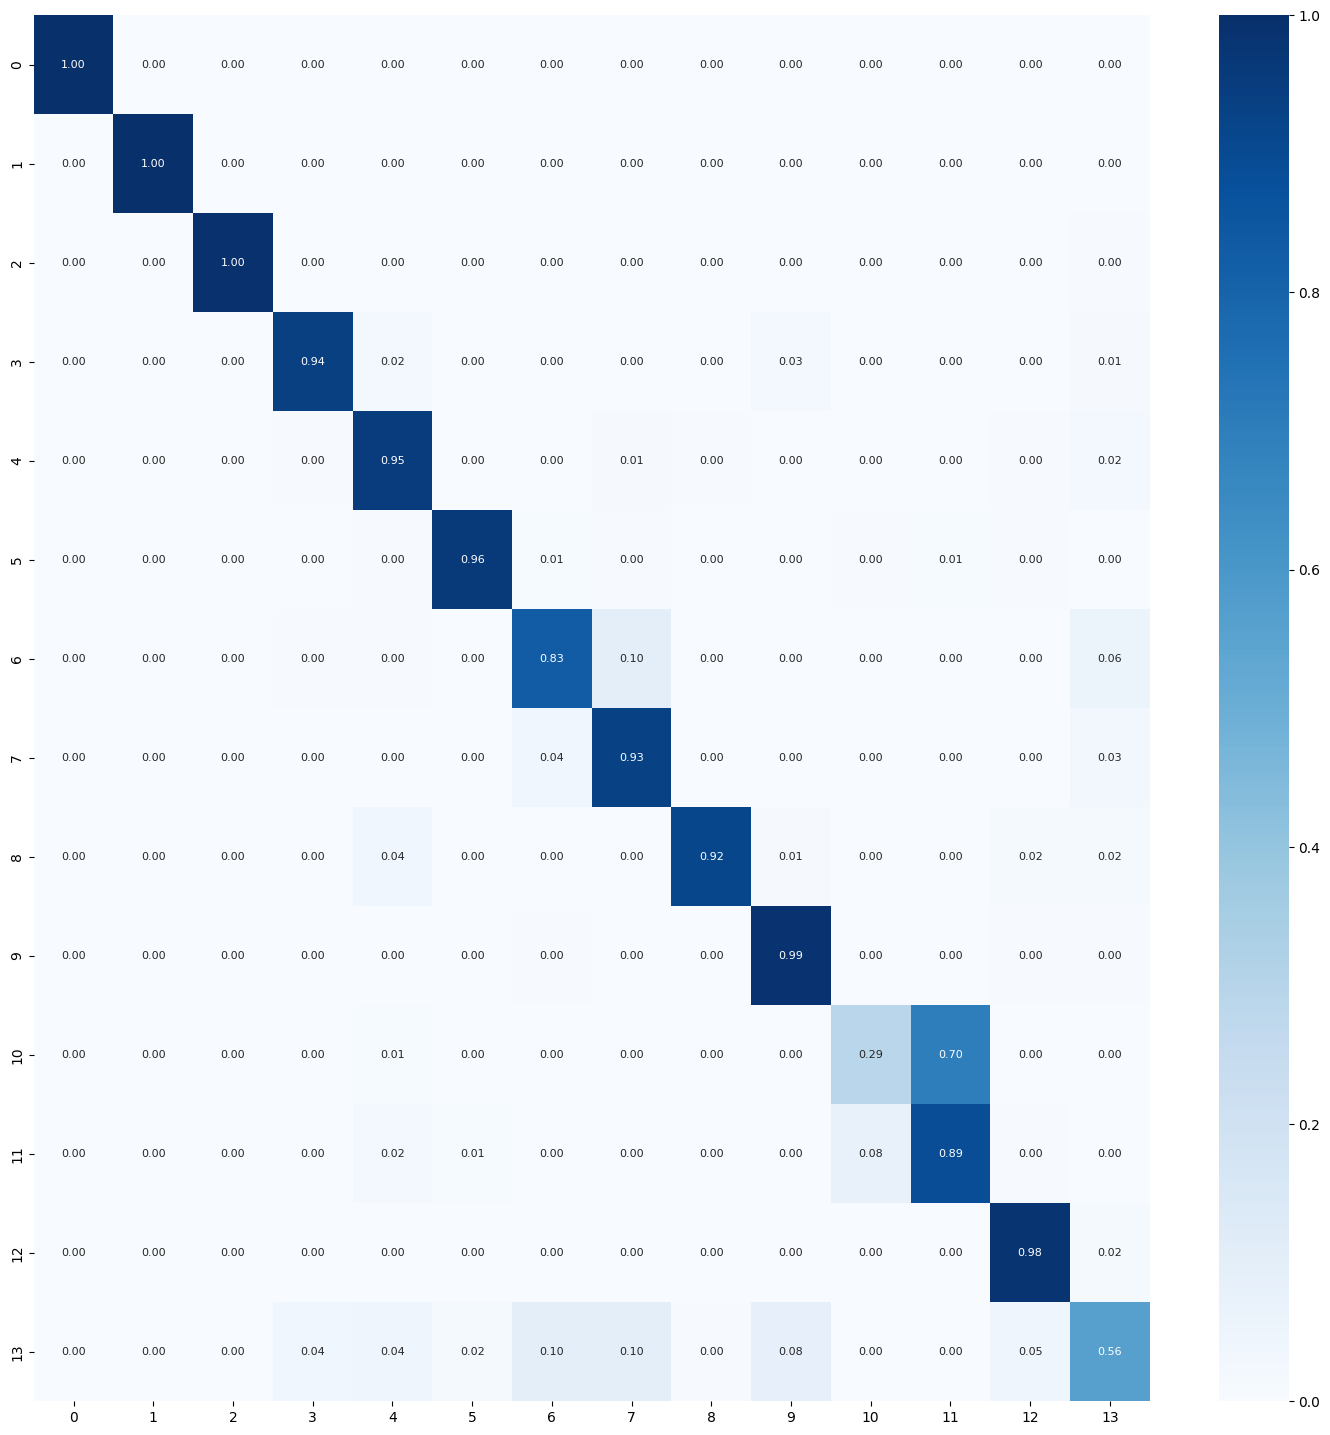


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2794158
Trainable params: 2793806
Non-trainable params: 352
Epoch 1/50
459/459 [==============================] - 78s 153ms/step - loss: 1.8696 - accuracy: 0.7661 - val_loss: 2.9864 - val_accuracy: 0.4514
Epoch 2/50
459/459 [==============================] - 70s 152ms/step - loss: 1.2169 - accuracy: 0.8617 - val_loss: 1.0533 - val_accuracy: 0.8581
Epoch 3/50
459/459 [==============================] - 71s 154ms/step - loss: 0.8854 - accuracy: 0.8835 - val_loss: 0.9805 - val_accuracy: 0.8067
Epoch 4/50
459/459 [==============================] - 72s 156ms/step - loss: 0.6908 - accuracy: 0.8934 - val_loss: 0.7212 - val_accuracy: 0.8524
Epoch 5/50
459/459 [==============================] - 69s 150ms/step - loss: 0.5703 - accuracy: 0.9019 - val_loss: 0.6420 - val_accuracy: 0.8692
Epoch 6/50
459/459 [==============================] - 67s 147ms/step - loss: 0.4890 - accuracy: 0.9079 - val_loss: 0.6127 - val_accuracy: 0.8676
Epoch 7/50
459/459

Model and History saved...
460/460 [==============================] - 44s 96ms/step - loss: 0.3126 - accuracy: 0.9494
Train Accuracy: 0.9493877291679382
Train Log Loss: 0.3126125931739807
99/99 [==============================] - 14s 139ms/step - loss: 0.5631 - accuracy: 0.8835
Validation Accuracy: 0.8834920525550842
Validation Log Loss: 0.5631002187728882
99/99 [==============================] - 14s 136ms/step - loss: 0.6143 - accuracy: 0.8775
Test Accuracy: 0.8774603009223938
Test Log Loss: 0.6142768859863281
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 223   0   1   0   0   0   0   0   0   0   1   0]
 [  0   0   0 217   2   0   0   1   0   2   0   0   0   3]
 [  0   0   0 

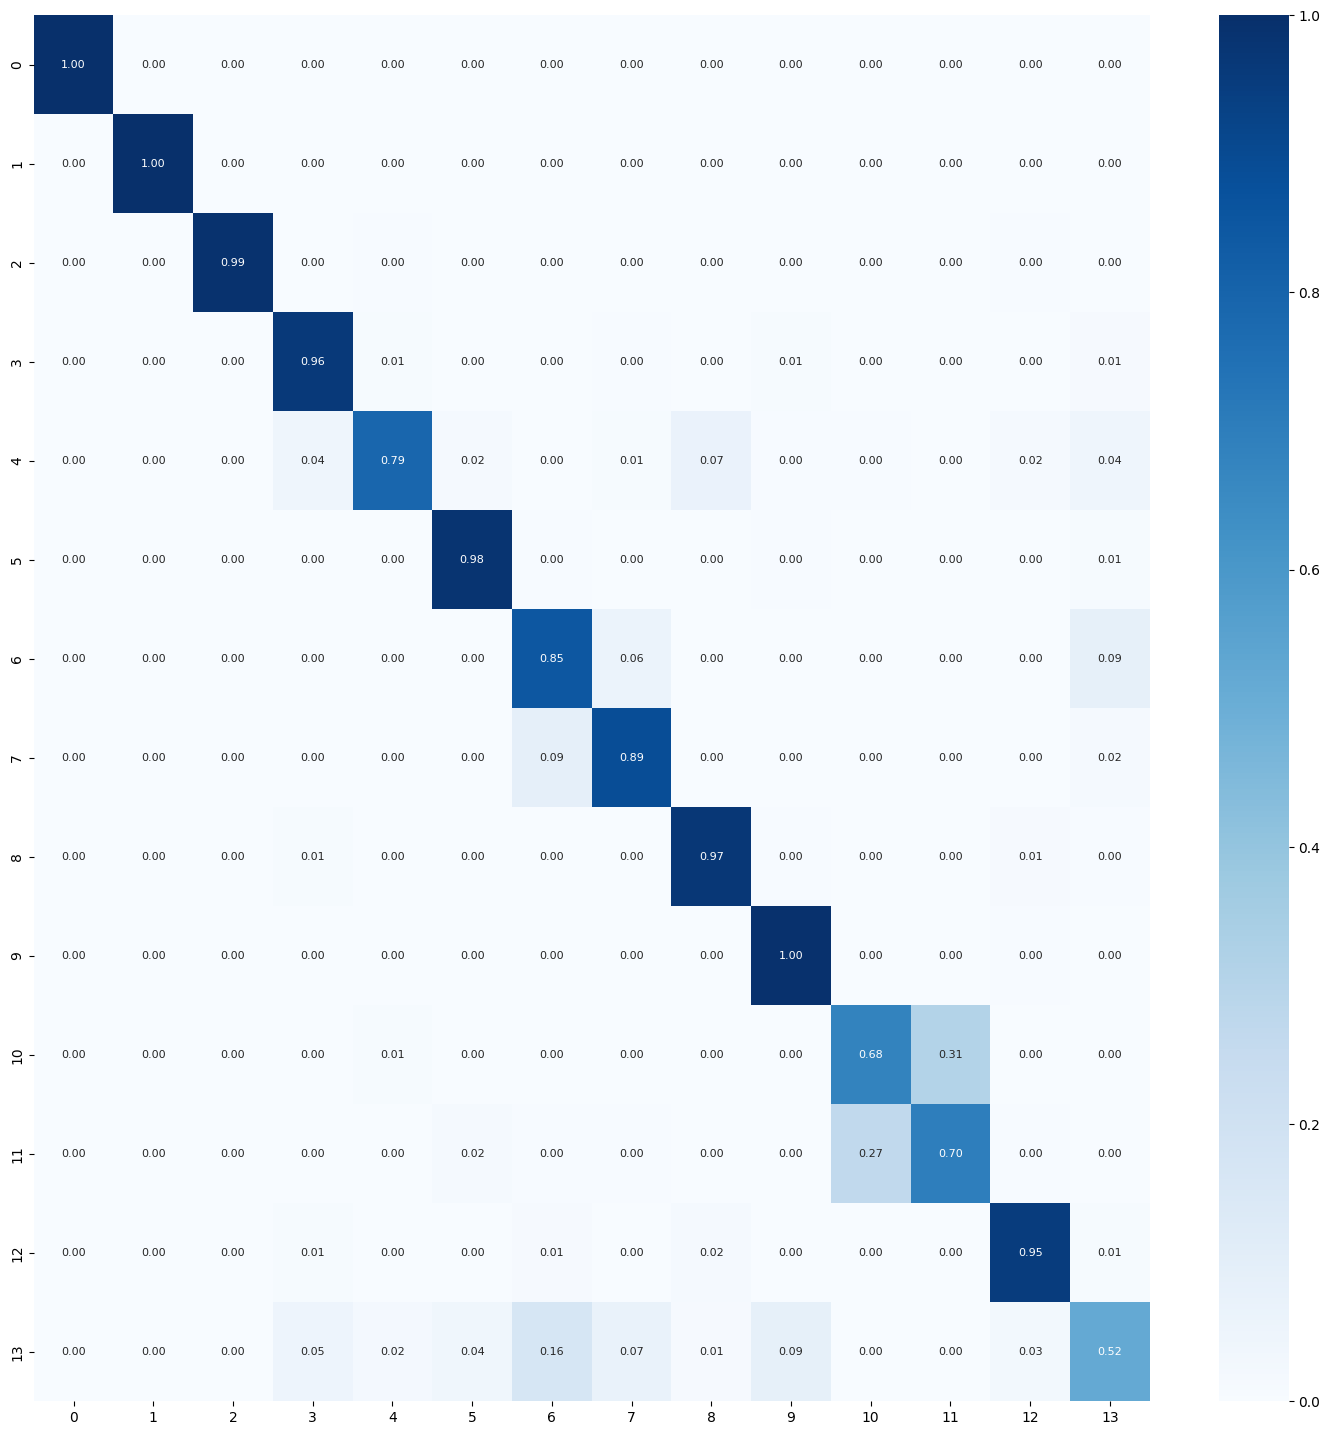


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2794158
Trainable params: 2793806
Non-trainable params: 352
Epoch 1/50
459/459 [==============================] - 92s 180ms/step - loss: 1.8494 - accuracy: 0.7758 - val_loss: 2.8600 - val_accuracy: 0.3984
Epoch 2/50
459/459 [==============================] - 92s 201ms/step - loss: 1.2157 - accuracy: 0.8630 - val_loss: 1.0973 - val_accuracy: 0.8435
Epoch 3/50
459/459 [==============================] - 92s 200ms/step - loss: 0.8932 - accuracy: 0.8831 - val_loss: 0.8486 - val_accuracy: 0.8756
Epoch 4/50
459/459 [==============================] - 91s 198ms/step - loss: 0.6891 - accuracy: 0.8947 - val_loss: 0.6995 - val_accuracy: 0.8721
Epoch 5/50
459/459 [==============================] - 90s 196ms/step - loss: 0.5656 - accuracy: 0.9016 - val_loss: 0.6420 - val_accuracy: 0.8797
Epoch 6/50
459/459 [==============================] - 73s 158ms/step - loss: 0.4850 - accuracy: 0.9146 - val_loss: 0.5706 - val_accuracy: 0.8784
Epoch 7/50
459/459

Model and History saved...
460/460 [==============================] - 62s 134ms/step - loss: 0.3390 - accuracy: 0.9515
Train Accuracy: 0.9514966011047363
Train Log Loss: 0.33899423480033875
99/99 [==============================] - 13s 129ms/step - loss: 0.5370 - accuracy: 0.8905
Validation Accuracy: 0.8904761672019958
Validation Log Loss: 0.5369766354560852
99/99 [==============================] - 13s 131ms/step - loss: 0.5503 - accuracy: 0.8943
Test Accuracy: 0.8942857384681702
Test Log Loss: 0.5502839088439941
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 216   5   0   0   0   1   0   0   0   1   2]
 [  0   0   

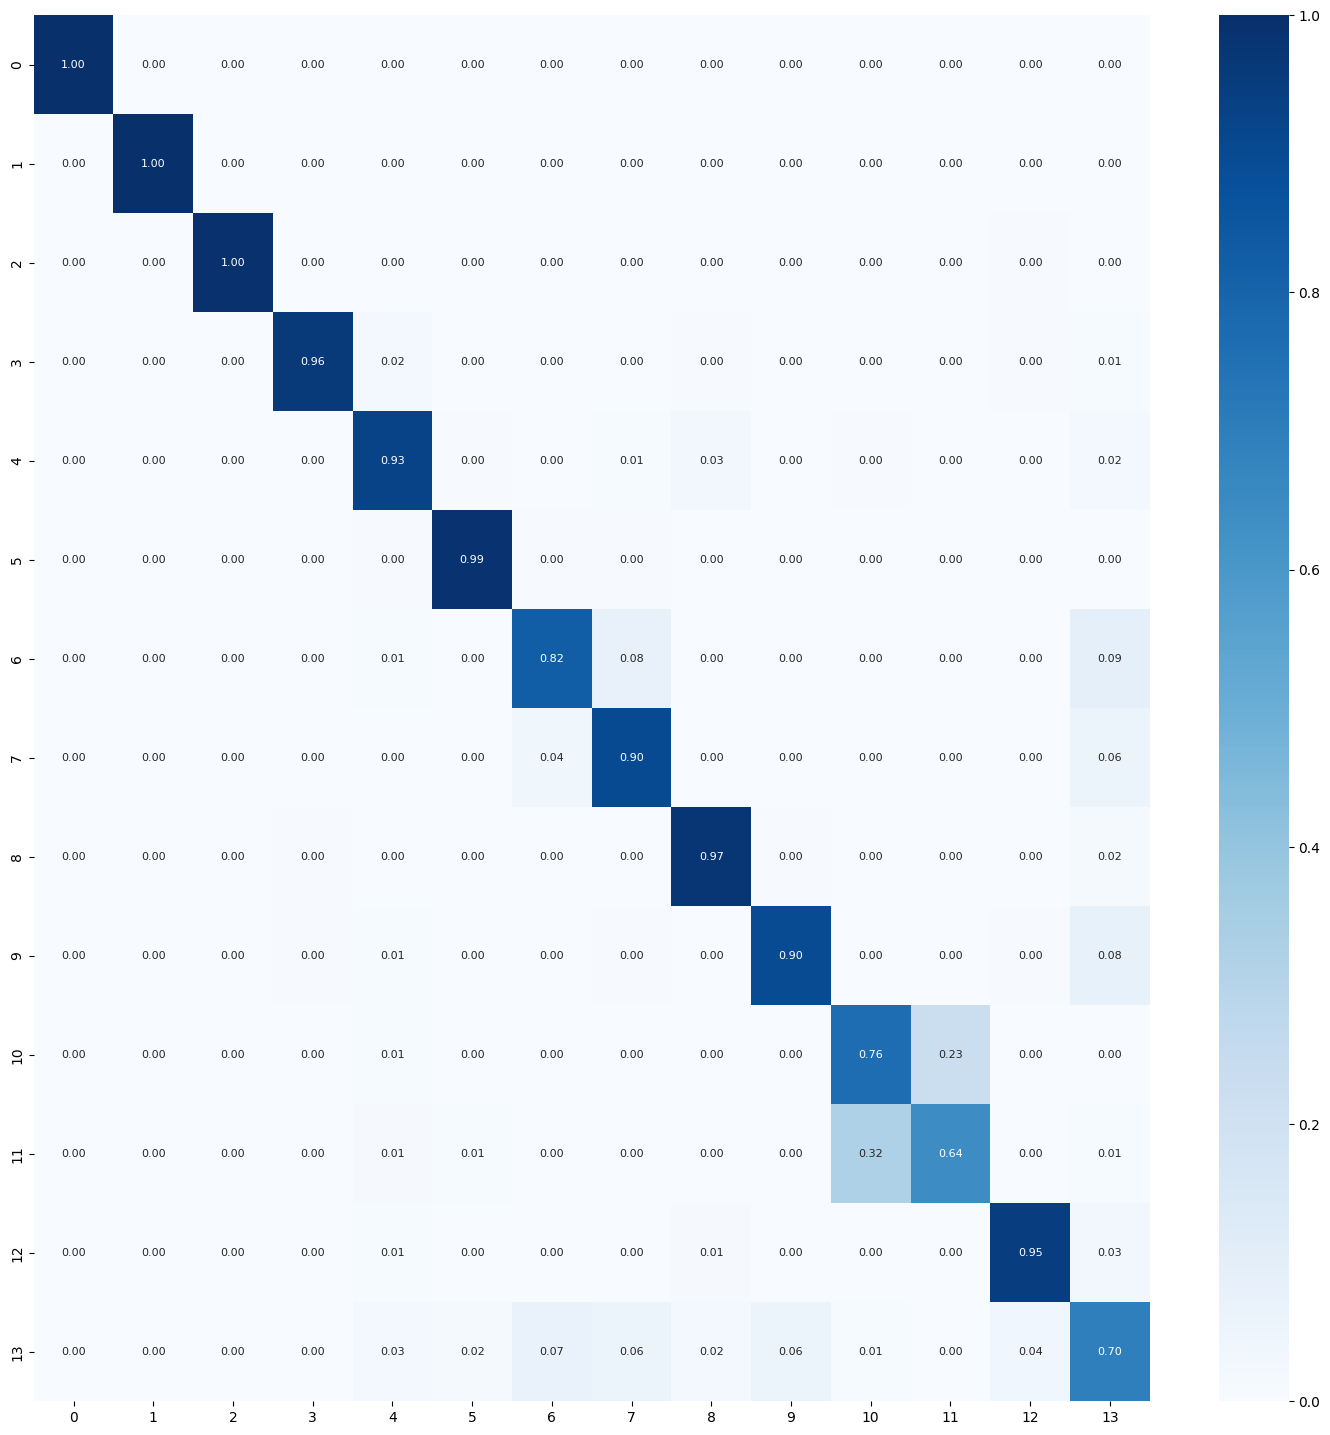


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2794158
Trainable params: 2793806
Non-trainable params: 352
Epoch 1/50
459/459 [==============================] - 78s 147ms/step - loss: 1.8438 - accuracy: 0.7720 - val_loss: 2.2744 - val_accuracy: 0.6368
Epoch 2/50
459/459 [==============================] - 74s 162ms/step - loss: 1.1921 - accuracy: 0.8604 - val_loss: 1.0861 - val_accuracy: 0.8384
Epoch 3/50
459/459 [==============================] - 72s 157ms/step - loss: 0.8725 - accuracy: 0.8814 - val_loss: 0.8484 - val_accuracy: 0.8581
Epoch 4/50
459/459 [==============================] - 75s 164ms/step - loss: 0.6852 - accuracy: 0.8917 - val_loss: 0.7109 - val_accuracy: 0.8654
Epoch 5/50
459/459 [==============================] - 83s 181ms/step - loss: 0.5758 - accuracy: 0.8985 - val_loss: 0.7463 - val_accuracy: 0.8324
Epoch 6/50
459/459 [==============================] - 74s 160ms/step - loss: 0.5077 - accuracy: 0.9030 - val_loss: 0.5768 - val_accuracy: 0.8740
Epoch 7/50
459/459

Model and History saved...
460/460 [==============================] - 62s 135ms/step - loss: 0.3380 - accuracy: 0.9469
Train Accuracy: 0.946870744228363
Train Log Loss: 0.3380388021469116
99/99 [==============================] - 14s 137ms/step - loss: 0.5249 - accuracy: 0.8898
Validation Accuracy: 0.8898412585258484
Validation Log Loss: 0.5249270796775818
99/99 [==============================] - 14s 135ms/step - loss: 0.5240 - accuracy: 0.8927
Test Accuracy: 0.8926984071731567
Test Log Loss: 0.5240188837051392
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 214   3   0   0   0   0   2   0   1   1   4]
 [  0   0   0 

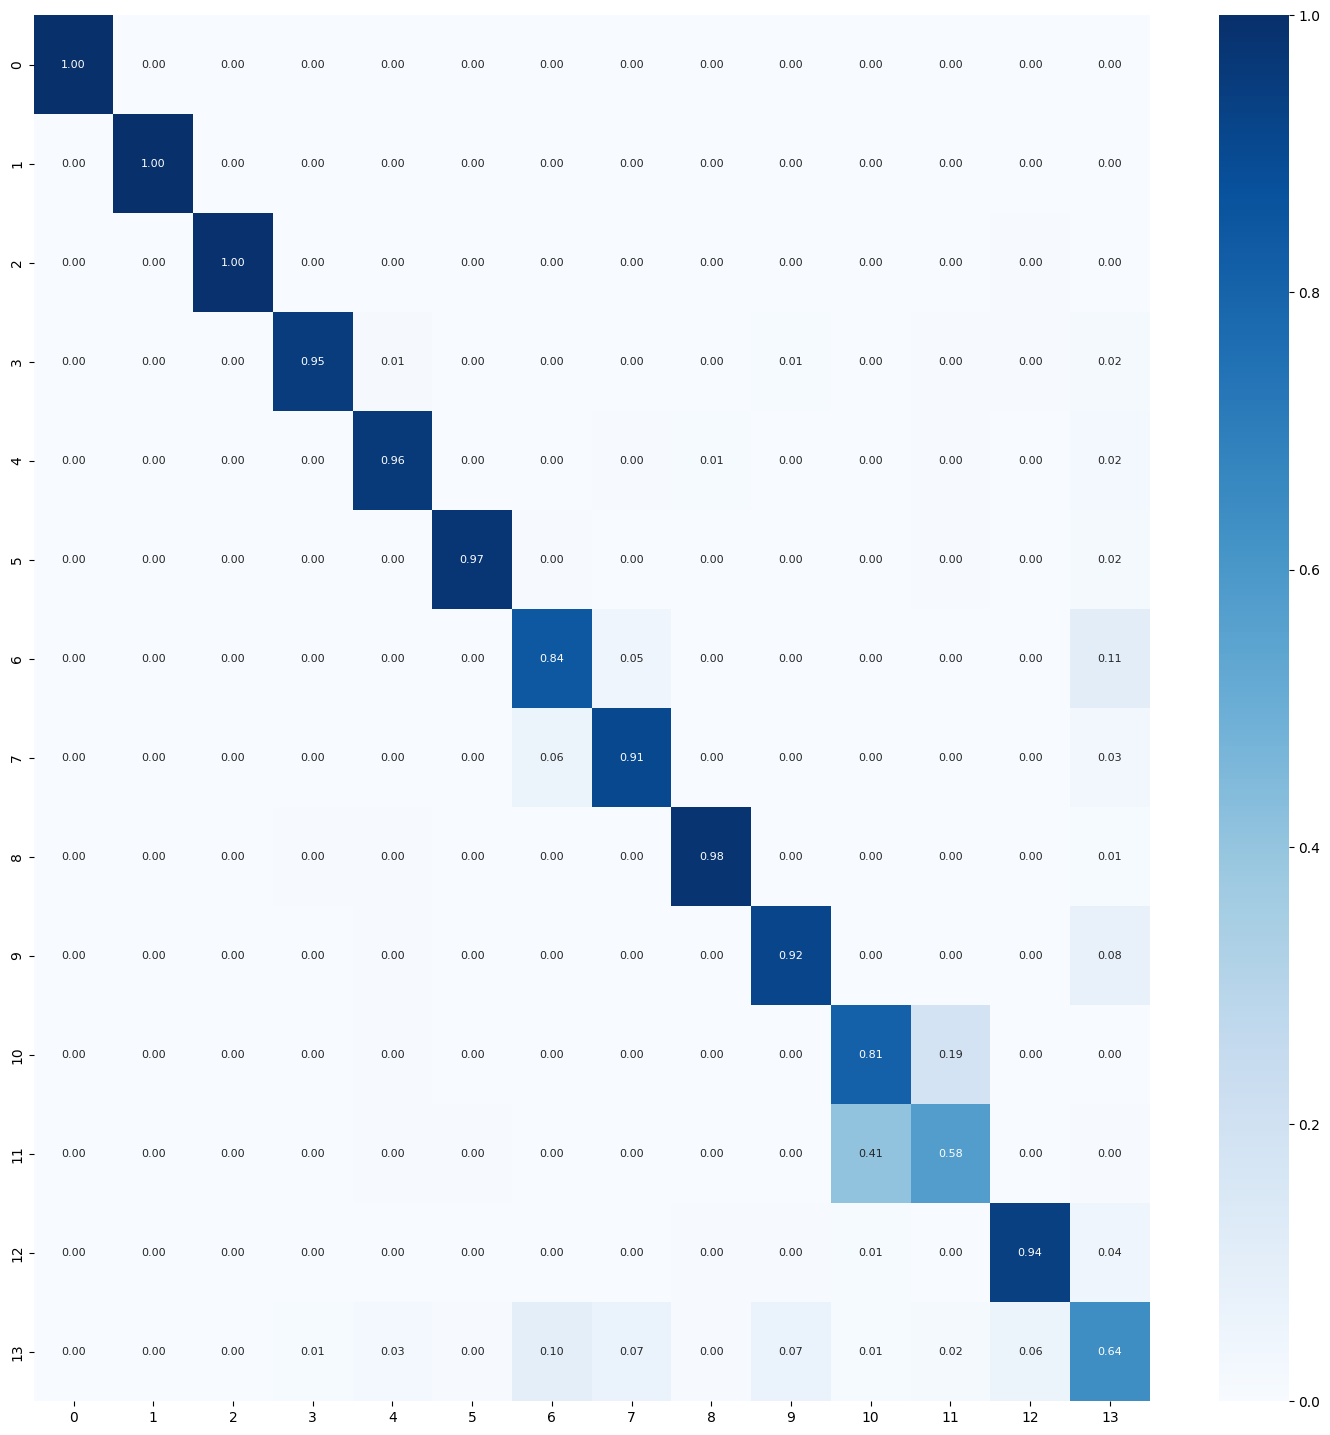


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2794158
Trainable params: 2793806
Non-trainable params: 352
Epoch 1/50
459/459 [==============================] - 81s 159ms/step - loss: 1.8793 - accuracy: 0.7654 - val_loss: 2.9973 - val_accuracy: 0.5451
Epoch 2/50
459/459 [==============================] - 72s 157ms/step - loss: 1.2219 - accuracy: 0.8633 - val_loss: 1.2334 - val_accuracy: 0.7943
Epoch 3/50
459/459 [==============================] - 73s 160ms/step - loss: 0.9044 - accuracy: 0.8820 - val_loss: 0.8440 - val_accuracy: 0.8679
Epoch 4/50
459/459 [==============================] - 72s 157ms/step - loss: 0.6987 - accuracy: 0.8956 - val_loss: 0.7095 - val_accuracy: 0.8683
Epoch 5/50
459/459 [==============================] - 71s 155ms/step - loss: 0.5788 - accuracy: 0.9024 - val_loss: 0.6407 - val_accuracy: 0.8857
Epoch 6/50
459/459 [==============================] - 72s 157ms/step - loss: 0.4992 - accuracy: 0.9108 - val_loss: 0.6039 - val_accuracy: 0.8590
Epoch 7/50
459/459

Model and History saved...
460/460 [==============================] - 67s 146ms/step - loss: 0.3133 - accuracy: 0.9532
Train Accuracy: 0.9531973004341125
Train Log Loss: 0.31325259804725647
99/99 [==============================] - 14s 143ms/step - loss: 0.5379 - accuracy: 0.8883
Validation Accuracy: 0.8882539868354797
Validation Log Loss: 0.5378686785697937
99/99 [==============================] - 14s 144ms/step - loss: 0.5623 - accuracy: 0.8892
Test Accuracy: 0.8892063498497009
Test Log Loss: 0.5623264908790588
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 215   2   0   0   0   3   3   0   0   0   2]
 [  0   0   

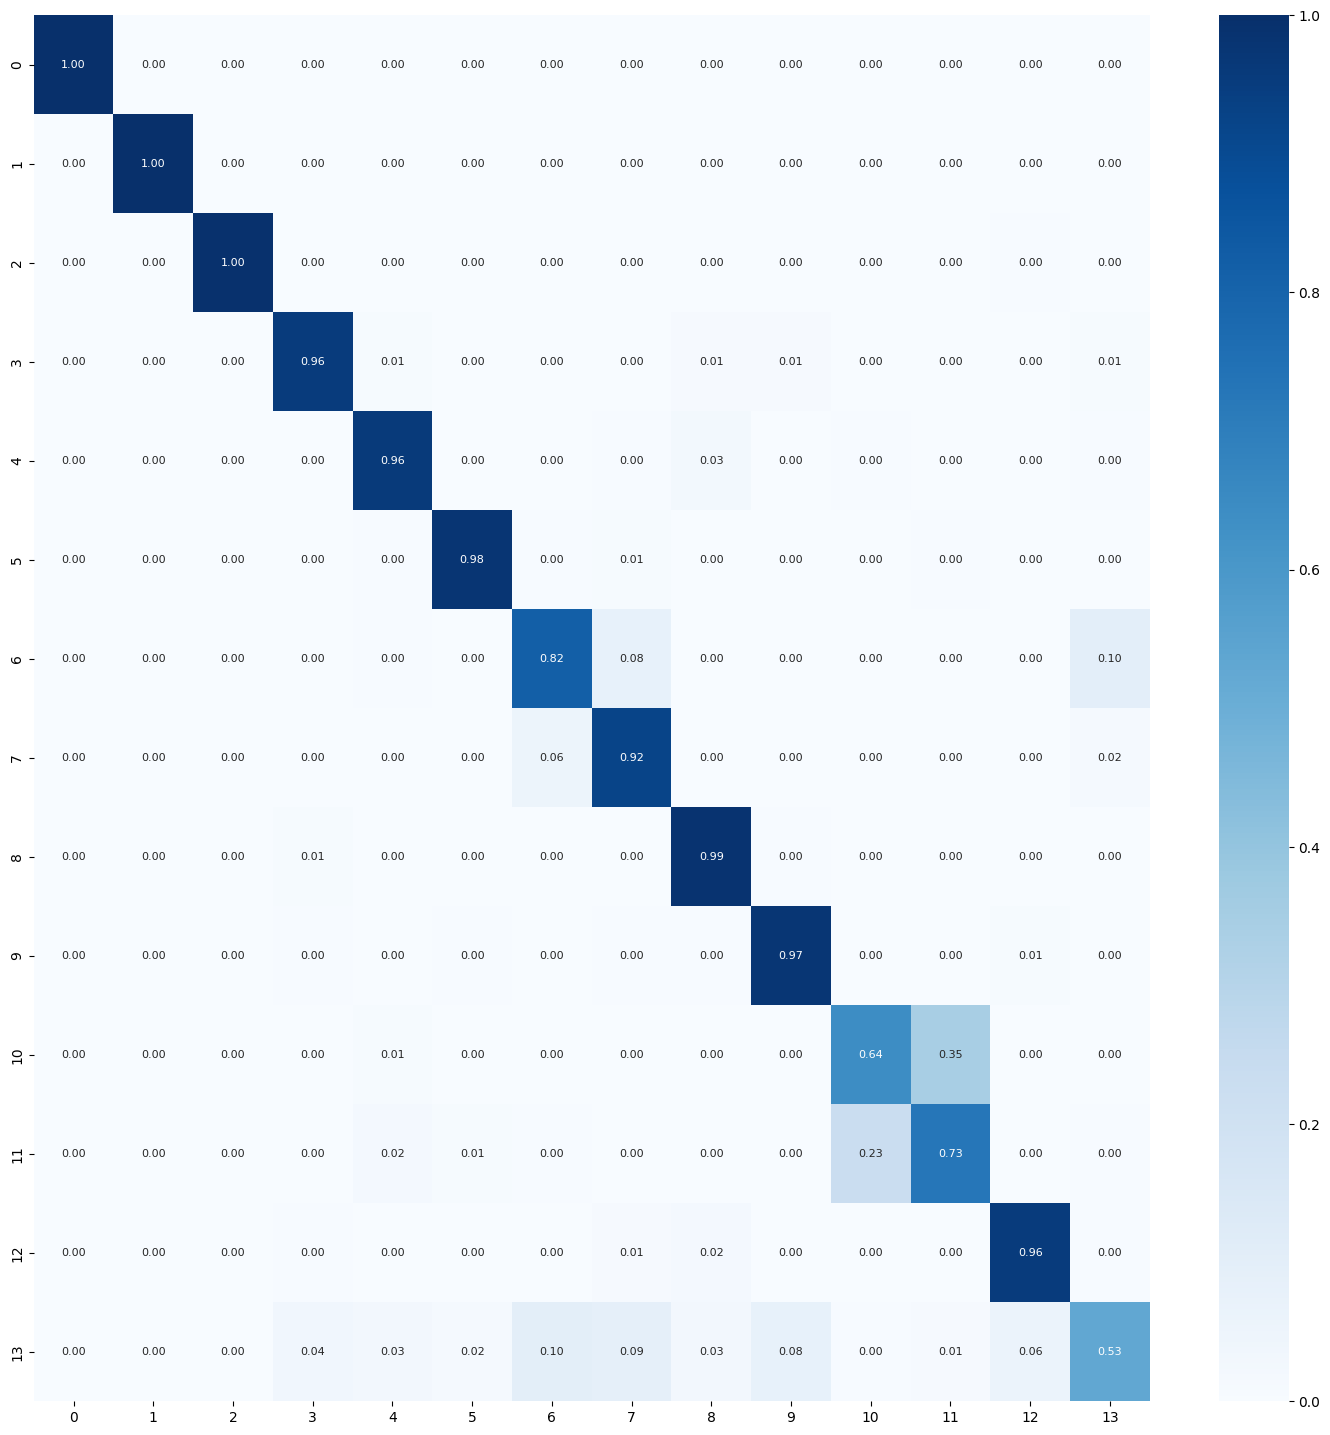

Average training accuracy in 5-fold: 0.9426779270172119
Average validation precision in 5-fold: 0.8956825375556946
/nTest Metrics
test_acc_list: [0.873968243598938, 0.8774603009223938, 0.8942857384681702, 0.8926984071731567, 0.8892063498497009]
Average Test Accuracy with 5-fold: 0.8855238080024719
test_loss_list: [0.575065016746521, 0.6142768859863281, 0.5502839088439941, 0.5240188837051392, 0.5623264908790588]
Average Test Log Loss with 5-fold: 0.5651942372322083

Precision List: [0.8825907897005216, 0.8755146218830296, 0.8947896113524239, 0.8941294509041355, 0.8872157186931183]
Average Precision List with 5-fold: 0.8868480385066458
Recall List: [0.8739682539682541, 0.8774603174603174, 0.8942857142857144, 0.8926984126984127, 0.8892063492063491]
Average Recall List with 5-fold: 0.8855238095238095
F1 Score List: [0.8654655538032657, 0.8739926153551837, 0.89397879759294, 0.8921717144727005, 0.8855727254483148]
Average F1 Score List with 5-fold: 0.8822362813344808

Metrics List Store

tes

In [25]:
%%time

num_classes = 14
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/15
name_save_model: fusion_cnn_basic_150015
Found 15750 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small
- upatre

TRAINING AND EVALUATING FOLD 1/5...

Total params: 2794223
Trainable params: 2793871
Non-trainable params: 352
Epoch 1/50
492/492 [==============================] - 95s 176ms/step - loss: 1.8704 - accuracy: 0.7713 - val_loss: 1.7747 - val_accuracy: 0.7668
Epoch 2/50
492/492 [==============================] - 72s 146ms/step - loss: 1.2019 - accuracy: 0.8691 - val_loss: 1.0537 - val_accuracy: 0.8720
Epoch 3/50
492/492 [==============================] - 77s 156ms/step - loss: 0.8790 - accuracy: 0.8869 - val_loss: 0.8293 - val_accuracy: 0.8747
Epoch 4/50
492/492 

Model and History saved...
493/493 [==============================] - 61s 124ms/step - loss: 0.3096 - accuracy: 0.9535
Train Accuracy: 0.9534603357315063
Train Log Loss: 0.3095892667770386
106/106 [==============================] - 14s 131ms/step - loss: 0.5946 - accuracy: 0.8892
Validation Accuracy: 0.8891851902008057
Validation Log Loss: 0.5946187376976013
106/106 [==============================] - 15s 139ms/step - loss: 0.5779 - accuracy: 0.8936
Test Accuracy: 0.8936296105384827
Test Log Loss: 0.5779474377632141
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 213   1   0   0   0   1   4 

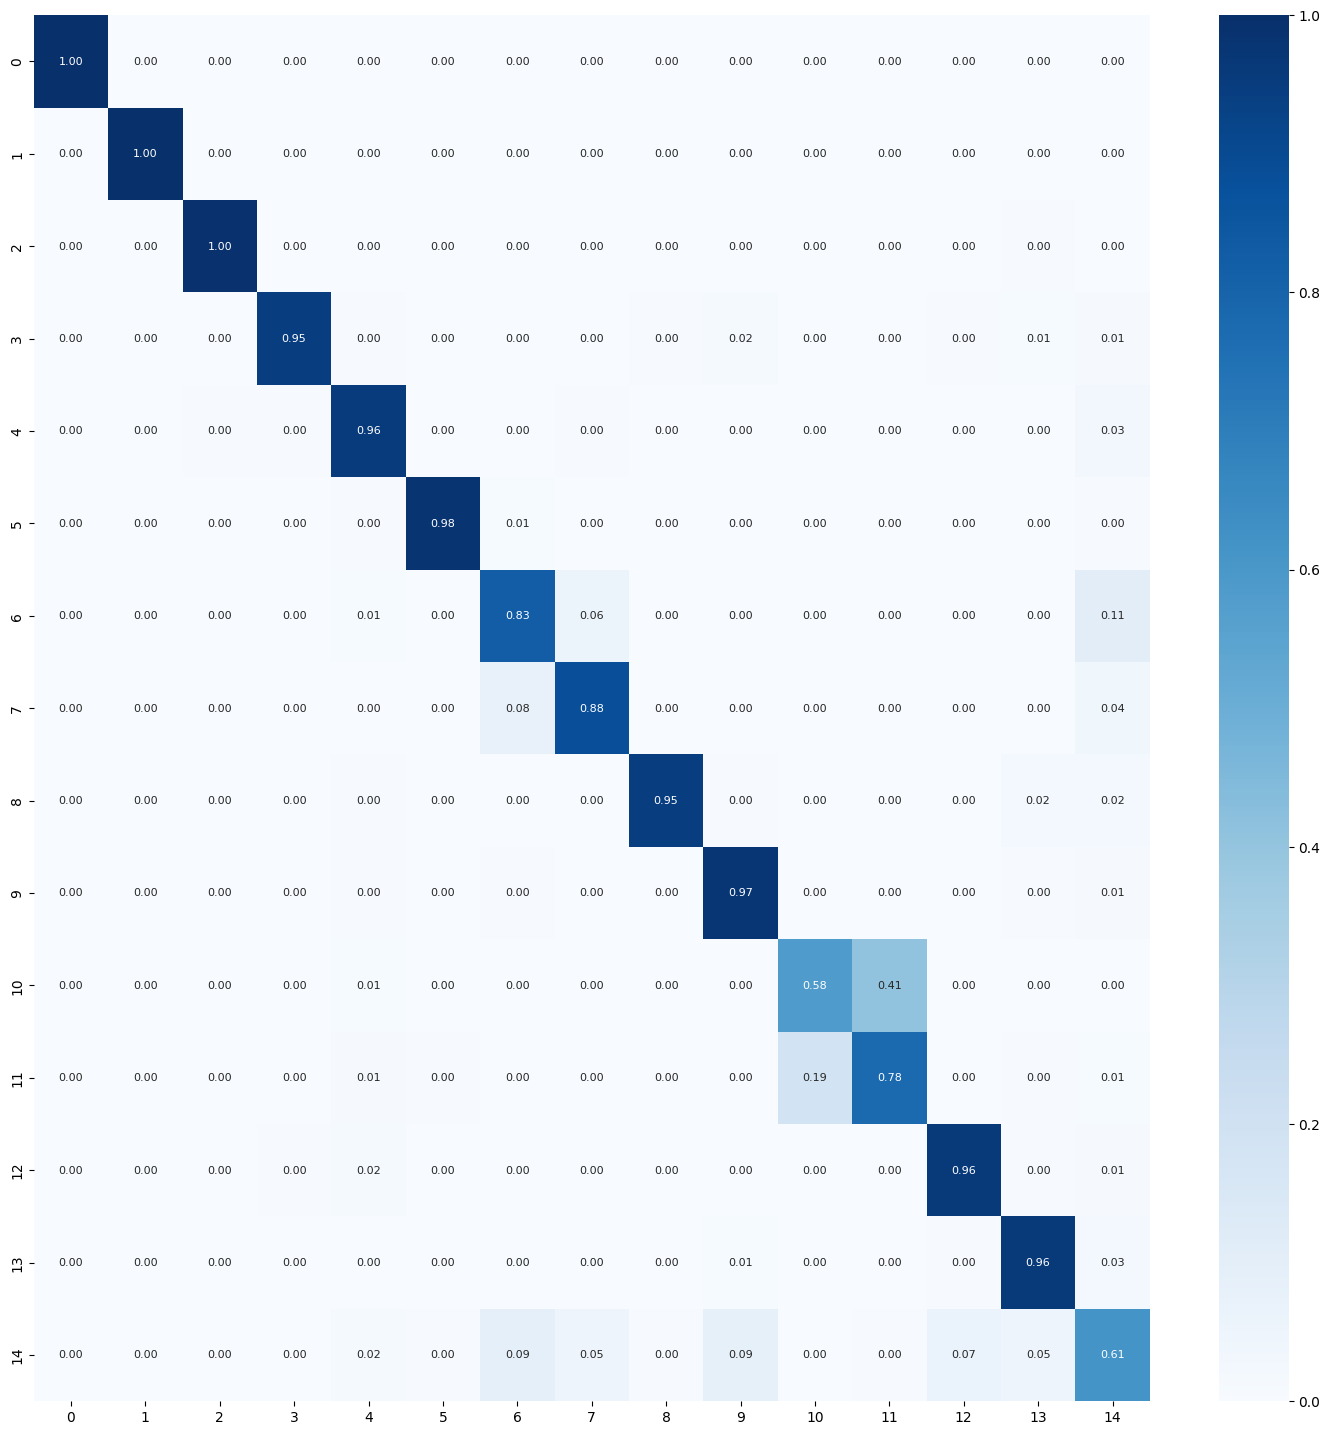


TRAINING AND EVALUATING FOLD 2/5...

Total params: 2794223
Trainable params: 2793871
Non-trainable params: 352
Epoch 1/50
492/492 [==============================] - 84s 154ms/step - loss: 1.8929 - accuracy: 0.7677 - val_loss: 2.2839 - val_accuracy: 0.5766
Epoch 2/50
492/492 [==============================] - 74s 150ms/step - loss: 1.2164 - accuracy: 0.8673 - val_loss: 1.1166 - val_accuracy: 0.8480
Epoch 3/50
492/492 [==============================] - 76s 154ms/step - loss: 0.8863 - accuracy: 0.8920 - val_loss: 0.8437 - val_accuracy: 0.8696
Epoch 4/50
492/492 [==============================] - 78s 158ms/step - loss: 0.6861 - accuracy: 0.9010 - val_loss: 0.7134 - val_accuracy: 0.8741
Epoch 5/50
492/492 [==============================] - 75s 153ms/step - loss: 0.5707 - accuracy: 0.9082 - val_loss: 0.7209 - val_accuracy: 0.8622
Epoch 6/50
492/492 [==============================] - 74s 150ms/step - loss: 0.4980 - accuracy: 0.9154 - val_loss: 0.6172 - val_accuracy: 0.8738
Epoch 7/50
492/492

Model and History saved...
493/493 [==============================] - 61s 123ms/step - loss: 0.3126 - accuracy: 0.9504
Train Accuracy: 0.9504126906394958
Train Log Loss: 0.31260472536087036
106/106 [==============================] - 14s 126ms/step - loss: 0.5835 - accuracy: 0.8898
Validation Accuracy: 0.8897777795791626
Validation Log Loss: 0.5835364460945129
106/106 [==============================] - 13s 124ms/step - loss: 0.5896 - accuracy: 0.8844
Test Accuracy: 0.8844444155693054
Test Log Loss: 0.5895701050758362
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 222   0   0   0   0   0   0   0   0   0   0   1   2]
 [  0   1   0 215   1   0   0   0   0   6

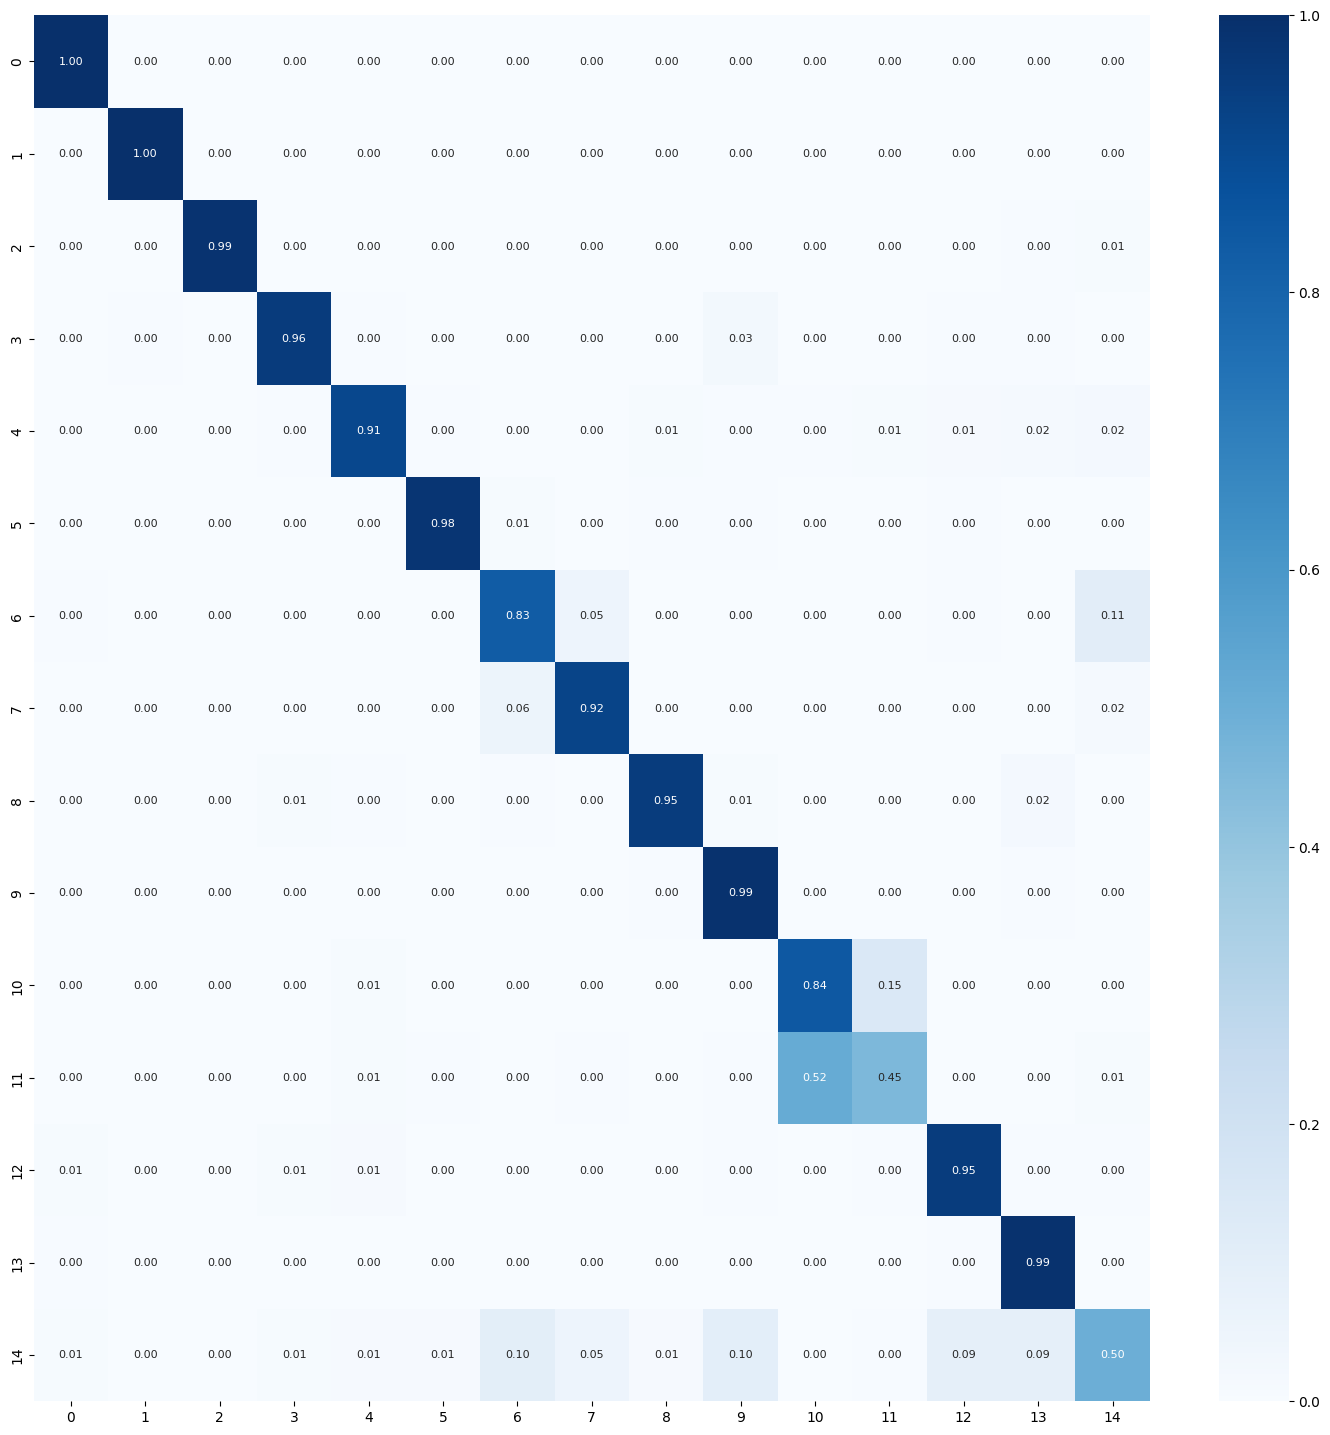


TRAINING AND EVALUATING FOLD 3/5...

Total params: 2794223
Trainable params: 2793871
Non-trainable params: 352
Epoch 1/50
492/492 [==============================] - 85s 157ms/step - loss: 1.8493 - accuracy: 0.7790 - val_loss: 1.8687 - val_accuracy: 0.7141
Epoch 2/50
492/492 [==============================] - 83s 168ms/step - loss: 1.2047 - accuracy: 0.8630 - val_loss: 1.0389 - val_accuracy: 0.8569
Epoch 3/50
492/492 [==============================] - 75s 152ms/step - loss: 0.8711 - accuracy: 0.8887 - val_loss: 0.8468 - val_accuracy: 0.8643
Epoch 4/50
492/492 [==============================] - 75s 152ms/step - loss: 0.6729 - accuracy: 0.8956 - val_loss: 0.6904 - val_accuracy: 0.8747
Epoch 5/50
492/492 [==============================] - 75s 152ms/step - loss: 0.5550 - accuracy: 0.9009 - val_loss: 0.6220 - val_accuracy: 0.8767
Epoch 6/50
492/492 [==============================] - 83s 168ms/step - loss: 0.4781 - accuracy: 0.9096 - val_loss: 0.5723 - val_accuracy: 0.8681
Epoch 7/50
492/492

Model and History saved...
493/493 [==============================] - 57s 115ms/step - loss: 0.3407 - accuracy: 0.9547
Train Accuracy: 0.9547301530838013
Train Log Loss: 0.34074991941452026
106/106 [==============================] - 11s 102ms/step - loss: 0.5558 - accuracy: 0.8987
Validation Accuracy: 0.8986666798591614
Validation Log Loss: 0.5557839274406433
106/106 [==============================] - 10s 89ms/step - loss: 0.5591 - accuracy: 0.8916
Test Accuracy: 0.8915555477142334
Test Log Loss: 0.5591478943824768
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 216   3   0   0   0   0   4 

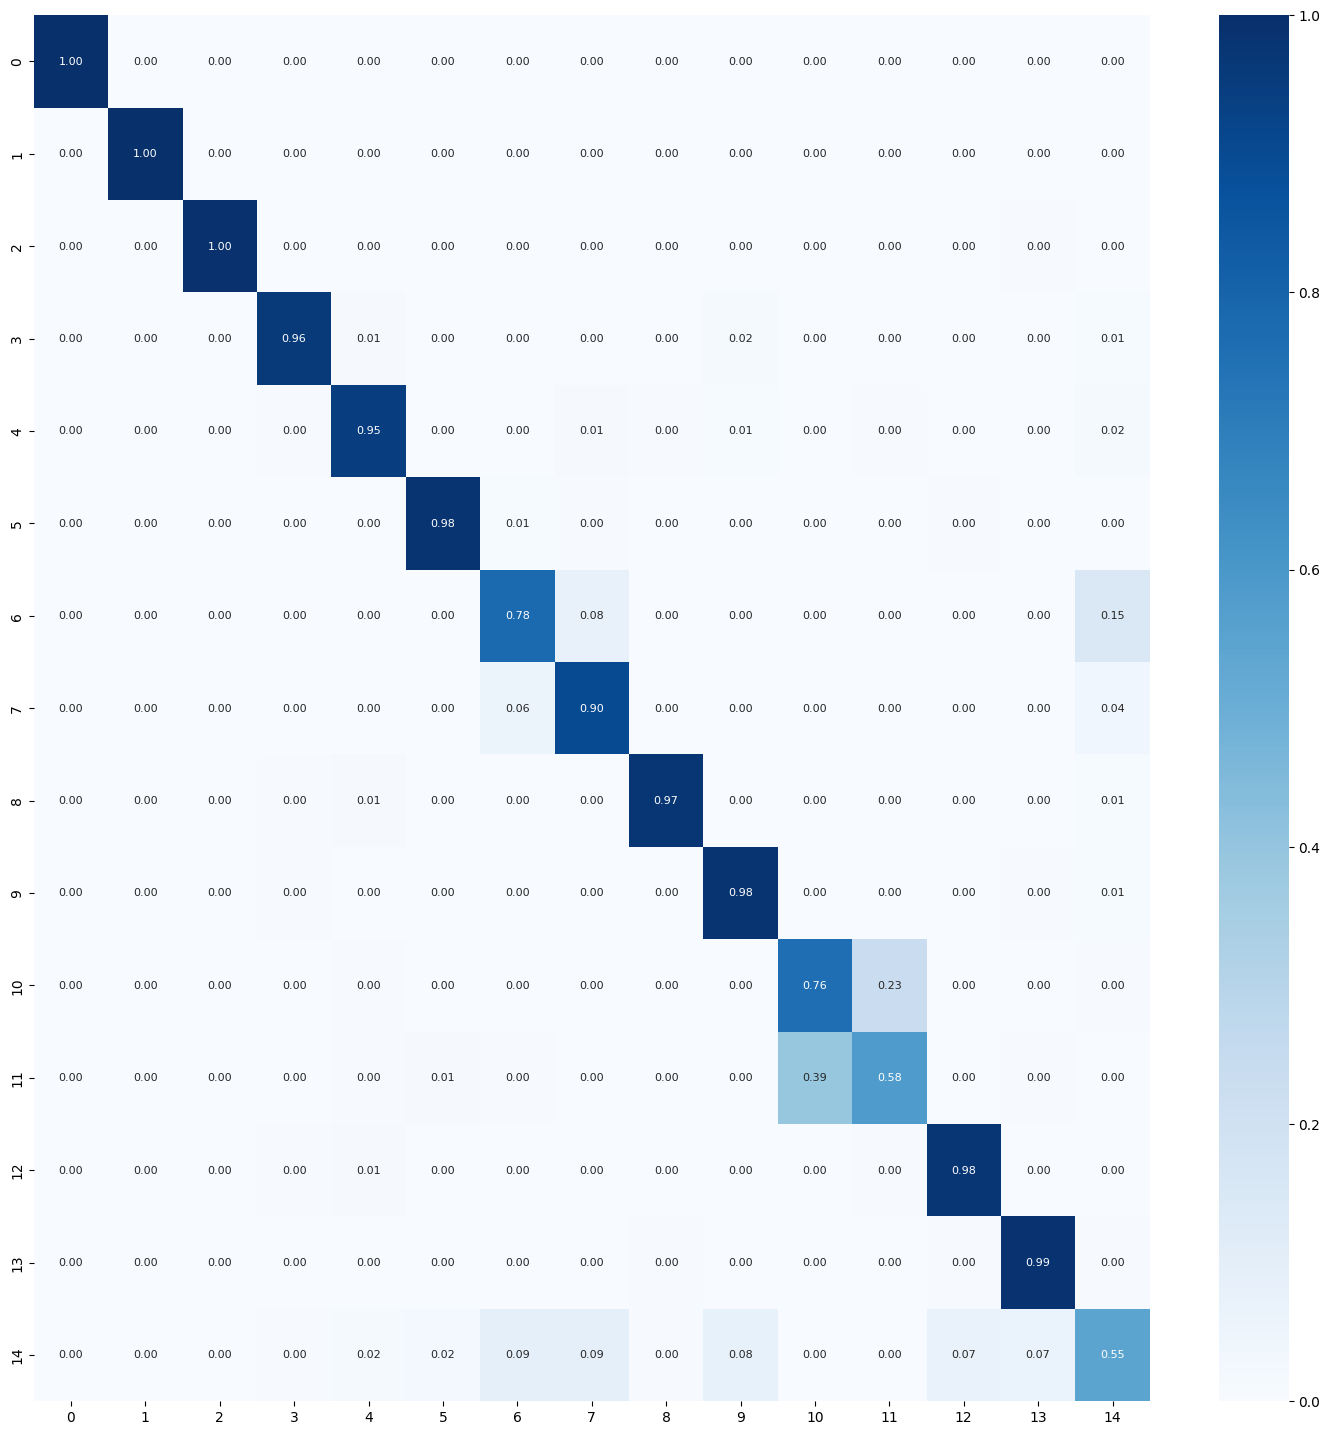


TRAINING AND EVALUATING FOLD 4/5...

Total params: 2794223
Trainable params: 2793871
Non-trainable params: 352
Epoch 1/50
492/492 [==============================] - 83s 153ms/step - loss: 1.8871 - accuracy: 0.7696 - val_loss: 1.7974 - val_accuracy: 0.7606
Epoch 2/50
492/492 [==============================] - 74s 151ms/step - loss: 1.2122 - accuracy: 0.8657 - val_loss: 1.0832 - val_accuracy: 0.8551
Epoch 3/50
492/492 [==============================] - 74s 151ms/step - loss: 0.8734 - accuracy: 0.8909 - val_loss: 0.8395 - val_accuracy: 0.8729
Epoch 4/50
492/492 [==============================] - 83s 169ms/step - loss: 0.6766 - accuracy: 0.9034 - val_loss: 0.7434 - val_accuracy: 0.8619
Epoch 5/50
492/492 [==============================] - 94s 191ms/step - loss: 0.5620 - accuracy: 0.9082 - val_loss: 0.6821 - val_accuracy: 0.8601
Epoch 6/50
492/492 [==============================] - 97s 197ms/step - loss: 0.4845 - accuracy: 0.9178 - val_loss: 0.6588 - val_accuracy: 0.8753
Epoch 7/50
492/492

Model and History saved...
493/493 [==============================] - 64s 129ms/step - loss: 0.5067 - accuracy: 0.9002
Train Accuracy: 0.9001904726028442
Train Log Loss: 0.5066962242126465
106/106 [==============================] - 15s 136ms/step - loss: 0.7218 - accuracy: 0.8370
Validation Accuracy: 0.8370370268821716
Validation Log Loss: 0.7218307256698608
106/106 [==============================] - 15s 136ms/step - loss: 0.7848 - accuracy: 0.8308
Test Accuracy: 0.8308148384094238
Test Log Loss: 0.7847543358802795
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 223   1   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 218   1   0   0   0   0   3 

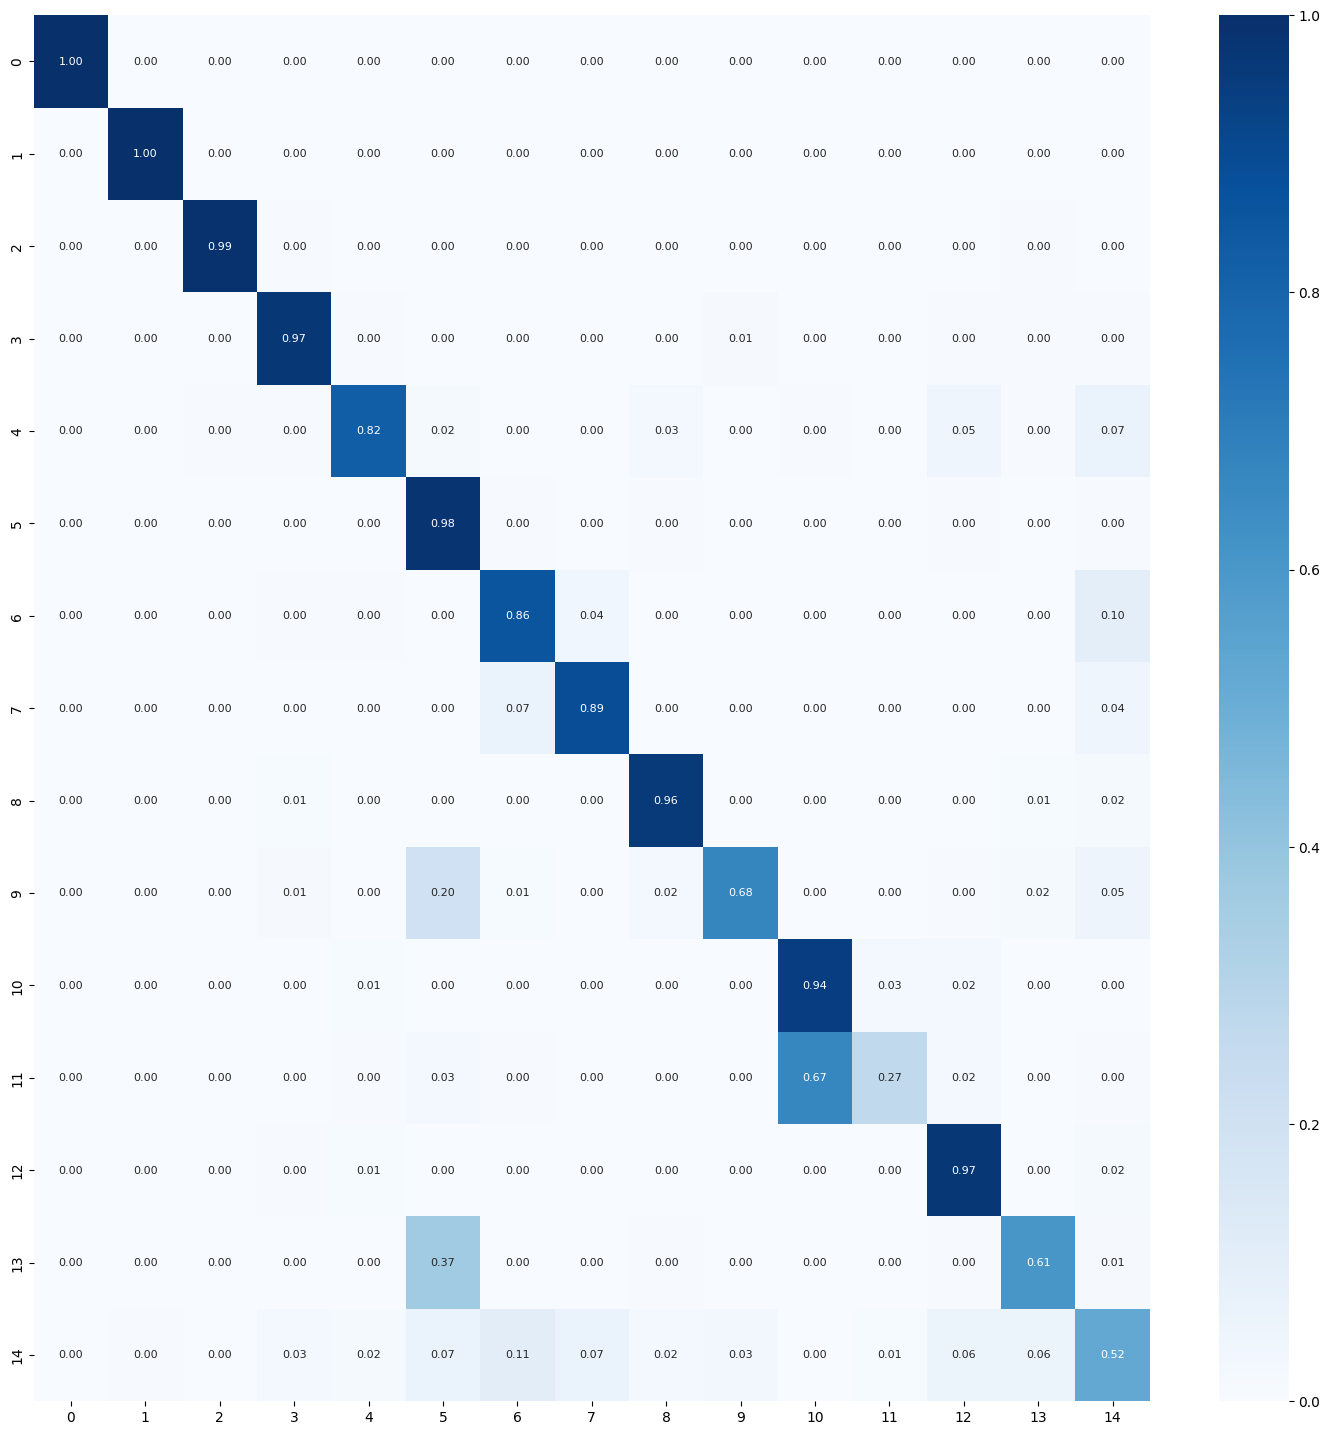


TRAINING AND EVALUATING FOLD 5/5...

Total params: 2794223
Trainable params: 2793871
Non-trainable params: 352
Epoch 1/50
492/492 [==============================] - 98s 182ms/step - loss: 1.8955 - accuracy: 0.7633 - val_loss: 1.6399 - val_accuracy: 0.8210
Epoch 2/50
492/492 [==============================] - 81s 165ms/step - loss: 1.2051 - accuracy: 0.8613 - val_loss: 1.0639 - val_accuracy: 0.8593
Epoch 3/50
492/492 [==============================] - 88s 179ms/step - loss: 0.8808 - accuracy: 0.8847 - val_loss: 0.8417 - val_accuracy: 0.8699
Epoch 4/50
492/492 [==============================] - 82s 166ms/step - loss: 0.6900 - accuracy: 0.8961 - val_loss: 0.7321 - val_accuracy: 0.8634
Epoch 5/50
492/492 [==============================] - 80s 162ms/step - loss: 0.5831 - accuracy: 0.9060 - val_loss: 0.6679 - val_accuracy: 0.8782
Epoch 6/50
492/492 [==============================] - 84s 170ms/step - loss: 0.5050 - accuracy: 0.9111 - val_loss: 0.6074 - val_accuracy: 0.8773
Epoch 7/50
492/492

Model and History saved...
493/493 [==============================] - 80s 162ms/step - loss: 0.3124 - accuracy: 0.9521
Train Accuracy: 0.9521269798278809
Train Log Loss: 0.31244638562202454
106/106 [==============================] - 18s 167ms/step - loss: 0.5289 - accuracy: 0.8927
Validation Accuracy: 0.8927407264709473
Validation Log Loss: 0.5289188623428345
106/106 [==============================] - 18s 165ms/step - loss: 0.5671 - accuracy: 0.8859
Test Accuracy: 0.8859259486198425
Test Log Loss: 0.567052960395813
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 223   1   1   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 213   6   0   0   0   0   4 

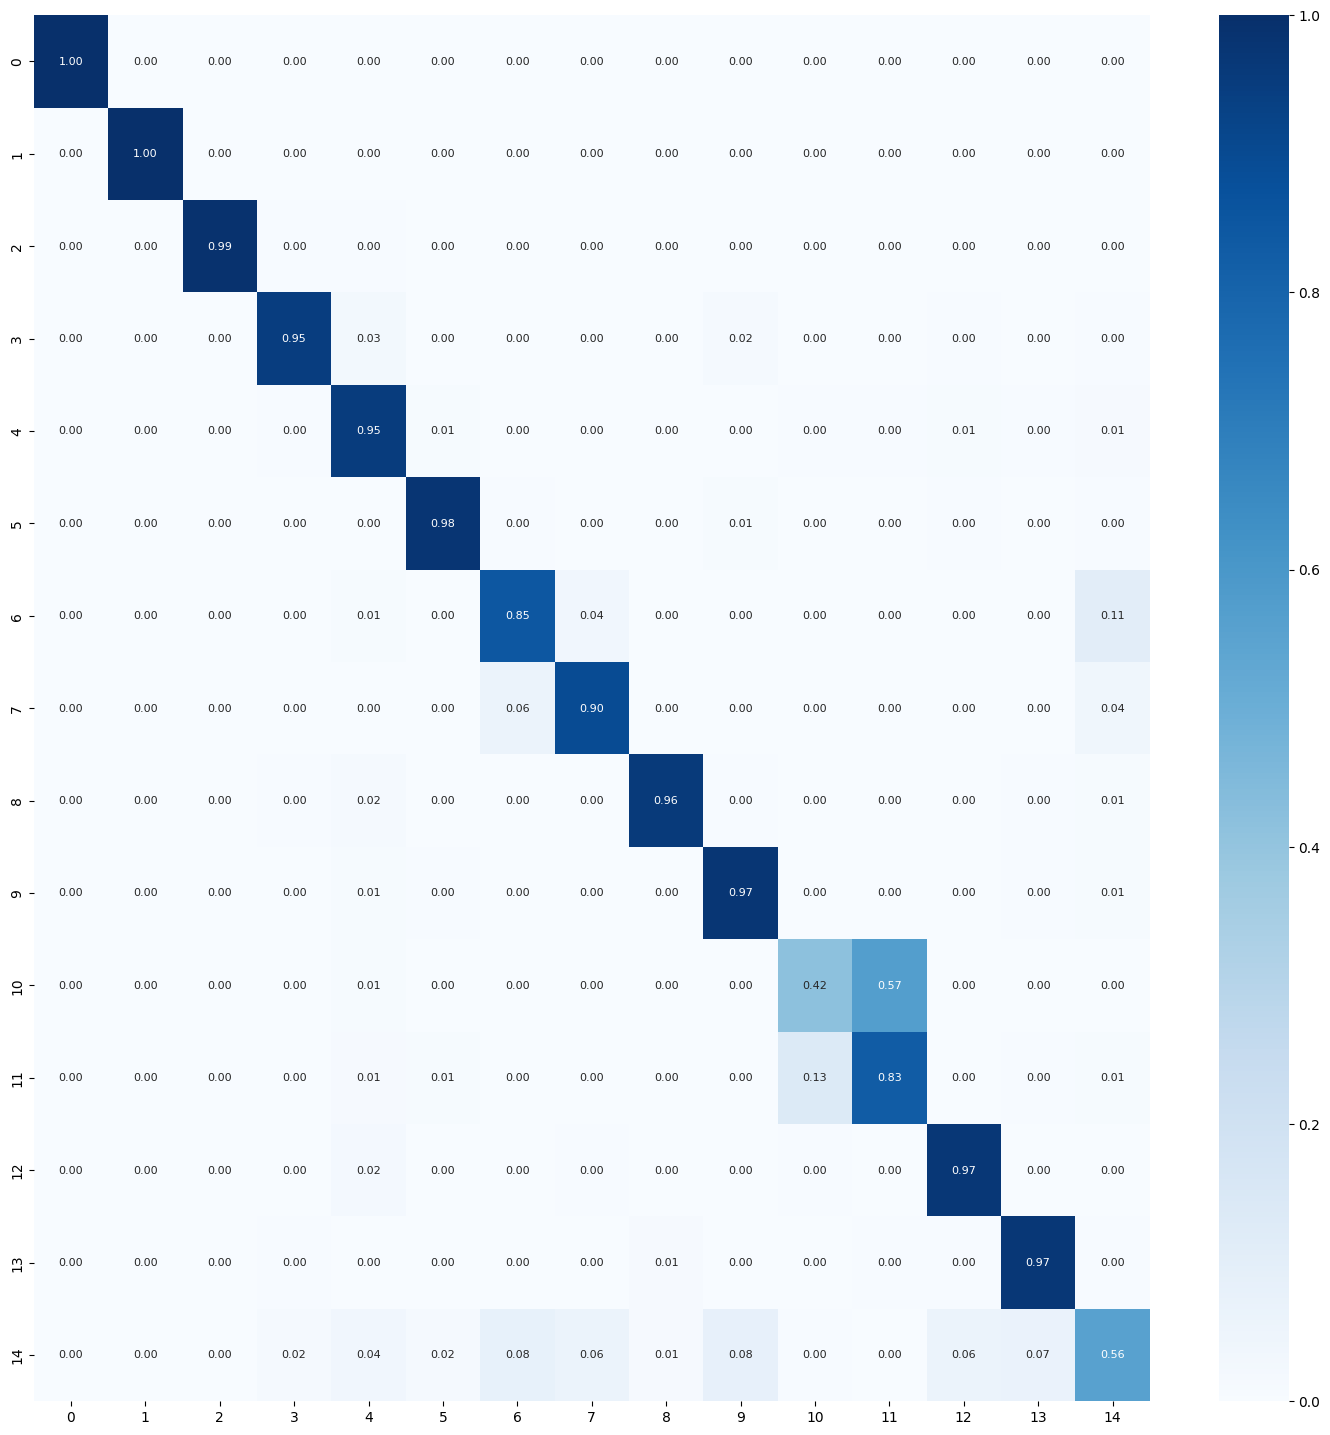

Average training accuracy in 5-fold: 0.9442168235778808
Average validation precision in 5-fold: 0.8984888911247253
/nTest Metrics
test_acc_list: [0.8936296105384827, 0.8844444155693054, 0.8915555477142334, 0.8308148384094238, 0.8859259486198425]
Average Test Accuracy with 5-fold: 0.8772740721702575
test_loss_list: [0.5779474377632141, 0.5895701050758362, 0.5591478943824768, 0.7847543358802795, 0.567052960395813]
Average Test Log Loss with 5-fold: 0.615694546699524

Precision List: [0.8936058292757632, 0.8845392927065401, 0.8887946481485682, 0.8548898794933856, 0.8874245059301238]
Average Precision List with 5-fold: 0.8818508311108761
Recall List: [0.8936296296296298, 0.8844444444444444, 0.8915555555555557, 0.8308148148148149, 0.885925925925926]
Average Recall List with 5-fold: 0.8772740740740741
F1 Score List: [0.892097940430496, 0.8787758265136273, 0.8885214102852103, 0.8220499269935521, 0.8811176506086379]
Average F1 Score List with 5-fold: 0.8725125509663046

Metrics List Store

tes

In [26]:
%%time

num_classes = 15
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

In [27]:
print(f"test_acc_list_all = {test_acc_list_all}")
print(f"test_loss_list_all = {test_loss_list_all}")
print(f"precision_list_all = {precision_list_all}")
print(f"recall_list_all = {recall_list_all}")
print(f"f1_score_list_all = {f1_score_list_all}")

test_acc_list_all = [0.995111095905304, 0.9721481561660766, 0.9968888878822326, 0.9952000141143799, 0.9882962822914123, 0.987936508655548, 0.9903333425521851, 0.9905185103416443, 0.9474666714668274, 0.9279191851615906, 0.915407407283783, 0.9310085415840149, 0.8855238080024719, 0.8772740721702575]
test_loss_list_all = [0.03669021539390087, 0.08600231613963842, 0.04754346758127213, 0.12755179703235625, 0.10859596282243729, 0.12774440497159958, 0.13089682310819625, 0.13384848684072495, 0.36269643902778625, 0.4559555113315582, 0.5308944404125213, 0.4672487318515778, 0.5651942372322083, 0.615694546699524]
precision_list_all = [0.9952390899768316, 0.9799167320115005, 0.9969161960518036, 0.99525577524781, 0.9885509056879045, 0.9881718169508884, 0.9904740107722867, 0.9906964815944266, 0.9472510498876622, 0.9254228041256225, 0.9158455714386655, 0.9304577079548562, 0.8868480385066458, 0.8818508311108761]
recall_list_all = [0.9951111111111111, 0.9721481481481483, 0.9968888888888889, 0.9952, 0.988

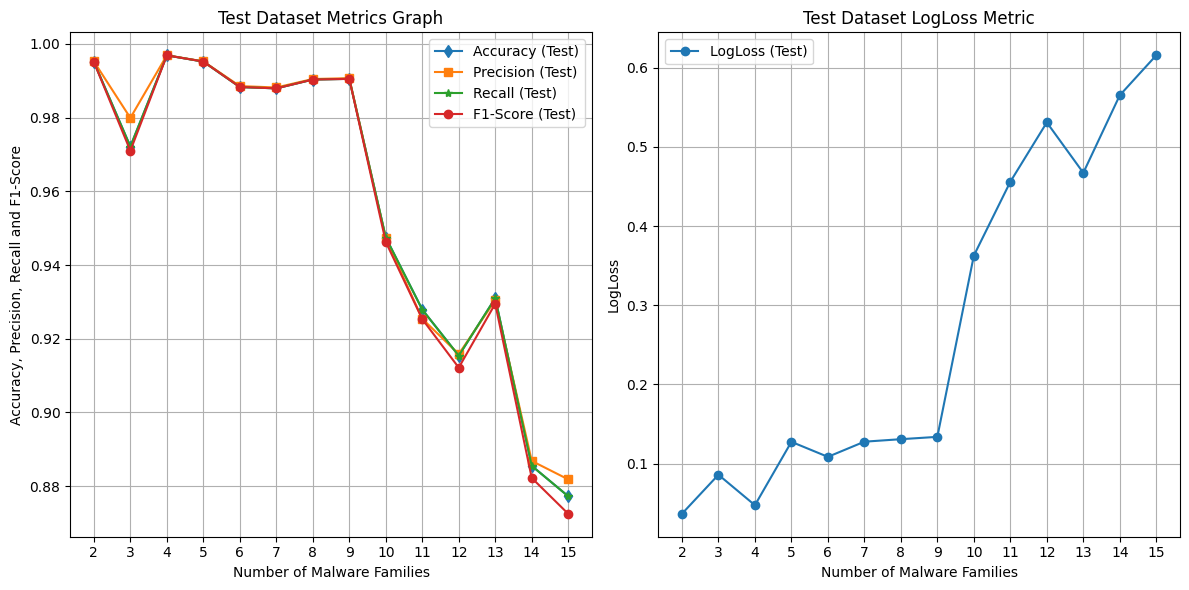

In [28]:
import matplotlib.pyplot as plt

# Datos históricos
strategies = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]

# Crear gráfico para Test Accuracy y Test LogLoss en una fila con dos columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico para Test Accuracy, Precision, Recall and F1-Score
axes[0].plot(strategies, test_acc_list_all, marker='d', label='Accuracy (Test)')
axes[0].plot(strategies, precision_list_all, marker='s', label='Precision (Test)')
axes[0].plot(strategies, recall_list_all, marker='*', label='Recall (Test)')
axes[0].plot(strategies, f1_score_list_all, marker='o', label='F1-Score (Test)')
axes[0].set_title('Test Dataset Metrics Graph')
axes[0].set_xlabel('Number of Malware Families')
axes[0].set_ylabel('Accuracy, Precision, Recall and F1-Score')
axes[0].legend()
axes[0].grid(True)

# Gráfico para Test LogLoss
axes[1].plot(strategies, test_loss_list_all, marker='o', label='LogLoss (Test)')
axes[1].set_title('Test Dataset LogLoss Metric')
axes[1].set_xlabel('Number of Malware Families')
axes[1].set_ylabel('LogLoss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
